In [11]:
# ============================================================
# БАЗОВЫЕ БИБЛИОТЕКИ
# ============================================================
import os
import io
import csv
import glob
import json
import time
import pickle
import hashlib
import logging
import warnings
import itertools
import concurrent.futures
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from dotenv import load_dotenv
load_dotenv()

# ============================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.graphics.mosaicplot import mosaic

import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots

from PIL import Image

# ============================================================
# СТАТИСТИКА
# ============================================================
from scipy.stats import ks_2samp, spearmanr

# ============================================================
# МАШИННОЕ ОБУЧЕНИЕ
# ============================================================

# Preprocessing, clustering, metrics, model selection
from sklearn import preprocessing, cluster, metrics, model_selection
from sklearn.model_selection import train_test_split

# Dimensionality reduction, manifold learning
from sklearn import decomposition, manifold

# Ensembles, mixture models
from sklearn import ensemble, mixture

# Pipelines
from sklearn import pipeline

# Calibration & metrics
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    roc_curve,
    precision_recall_curve
)

# Feature selection
from sklearn.feature_selection import (
    mutual_info_classif,
    mutual_info_regression
)

# PDP
from sklearn.inspection import PartialDependenceDisplay

# ============================================================
# LIGHTGBM
# ============================================================
import lightgbm as lgb

# ============================================================
# ПРОЧЕЕ
# ============================================================
from IPython.display import display, HTML
from graphviz import Digraph
from pandas.api.types import is_categorical_dtype
from category_encoders import TargetEncoder
import joblib

# ============================================================
# НАСТРОЙКИ
# ============================================================
warnings.filterwarnings("ignore")
plt.rcParams["patch.force_edgecolor"] = True
plt.rcParams["figure.dpi"] = 150

import json
import shutil
from datetime import datetime
import os
import stat
import shutil



# Stage 0 — Построения структуры проекта

# Логика и назначение механизма построения структуры проекта

## Цель механизма
Механизм автоматического построения структуры проекта создан для того, чтобы:

- **гарантировать единообразие структуры проекта** на любой машине и в любой среде;
- **исключить ручные ошибки** при создании папок;
- **обеспечить воспроизводимость** всех стадий ML‑пайплайна;
- **контролировать эволюцию проекта** через единый конфигурационный файл;
- **поддерживать модульность и расширяемость** проекта при добавлении новых стадий.

Этот подход превращает проект в **конфигурационно‑управляемую систему**, а не набор разрозненных файлов.

---

## Логика работы функции построения структуры

1. **Проверка наличия конфигурационного файла**
   - Если `project_structure_config.json` существует → используется он.
   - Если нет → используется словарь, объявленный в ноутбуке.

2. **Создание корневой директории проекта**
   - Если корень отсутствует → создаётся автоматически.

3. **Создание всех папок, описанных в конфиге**
   - Каждая папка создаётся **только если её нет**.
   - Это делает функцию *идемпотентной* — повторный запуск безопасен.

4. **Проверка на наличие “лишних” папок**
   - Если в проекте есть папки, которых нет в конфиге → они считаются *внеплановыми*.
   - Такие папки автоматически добавляются в конфиг как `extra_*`.

5. **Обновление конфигурационного файла**
   - Если конфиг отсутствовал → он создаётся.
   - Если были обнаружены новые папки → конфиг обновляется.
   - Таким образом структура проекта **самообучается** и остаётся актуальной.

---

## Почему это важно

- Проект развивается по стадиям → структура должна быть **строго контролируемой**.
- Каждая стадия создаёт свои артефакты → их пути должны быть **заданы в конфиге**.
- Возможны разные варианты стадий → конфиг позволяет **отслеживать версии**.
- Команда или проверяющий могут развернуть проект → структура будет **воссоздана автоматически**.

---

## Итог

Механизм построения структуры проекта:

- делает проект **модульным**,  
- обеспечивает **чистоту и порядок**,  
- позволяет **легко добавлять новые стадии**,  
- гарантирует **воспроизводимость**,  
- превращает проект в **настоящий ML‑инженерный пайплайн**, а не просто набор ноутбуков.

Это фундамент, на котором мы будем строить все последующие стадии: EDA, baseline, feature engineering, модели, интерпретацию и финальный inference.


In [2]:
# ============================================================
# Stage 0 — Step 1: КОНФИГУРАЦИЯ ПРОЕКТА
# ============================================================

project_structure_config = {
    "root": "Diploma_Project/",

    # Папки, которые нужно игнорировать при проверке структуры
    "ignore": [".git", ".idea", ".vscode", "__pycache__", "env", "venv"],

    "folders": {
        "data_raw": "data/raw/",
        "data_interim": "data/interim/",
        "data_processed": "data/processed/",
        "stage_outputs": "data/stage_outputs/",
        "eda_dicts": "eda/dicts/",
        "eda_plots": "eda/plots/",
        "src": "src/",
        "src_pipelines": "src/pipelines/",
        "notebooks": "notebooks/",
        "reports": "reports/",
        "reports_figures": "reports/figures/",
        "presentation": "presentation/"
    },

    "stages": {
        "stage1": {
            "suffix": "_data",
            "name": "Data Loading & Sampling",
            "input": ["raw CSV files"],
            "input_path": "data/raw/",
            "output": ["loaded DataFrames"],
            "output_path": "data/stage_outputs/stage1_data/",
            "output_format": ".pkl",
            "purpose": "Load full or sampled data",
            "description": "Load CSVs, sample rows, store DataFrames",
            "variants": ["sample10", "sample20", "full"]
        },
        "stage2": {
            "suffix": "_eda",
            "name": "Univariate EDA + Feature Screening",
            "input": ["stage1 DataFrames"],
            "input_path": "data/stage_outputs/stage1_data/",
            "output": ["EDA dicts", "promising features", "plots"],
            "output_path": "data/stage_outputs/stage2_eda/",
            "output_format": [".pkl", ".json", ".png"],
            "purpose": "Identify promising features",
            "description": "Build EDA dicts, filter features, plot promising only",
            "variants": ["eda_v1", "eda_v2"]
        },
        "stage3": {
            "suffix": "_baseline",
            "name": "Baseline LightGBM",
            "input": ["promising features"],
            "input_path": "data/stage_outputs/stage2_eda/",
            "output": ["baseline model", "feature importance"],
            "output_path": "data/stage_outputs/stage3_baseline/",
            "output_format": [".pkl", ".csv"],
            "purpose": "Establish baseline & rank features",
            "description": "Train LightGBM, extract top‑50",
            "variants": ["baseline_default", "baseline_tuned"]
        },
        "stage4": {
            "suffix": "_bivariate",
            "name": "Bivariate EDA",
            "input": ["top‑50 features"],
            "input_path": "data/stage_outputs/stage3_baseline/",
            "output": ["bivariate plots", "MI scores"],
            "output_path": "data/stage_outputs/stage4_bivariate/",
            "output_format": [".png", ".csv"],
            "purpose": "Understand TARGET relationships",
            "description": "TARGET vs numeric/categorical",
            "variants": ["biv_v1"]
        },
        "stage5": {
            "suffix": "_multivariate",
            "name": "Multivariate EDA",
            "input": ["top‑20 features"],
            "input_path": "data/stage_outputs/stage4_bivariate/",
            "output": ["interaction plots"],
            "output_path": "data/stage_outputs/stage5_multivariate/",
            "output_format": [".png", ".csv"],
            "purpose": "Understand feature interactions",
            "description": "SHAP interactions, PDP",
            "variants": ["multi_v1"]
        },
        "stage6": {
            "suffix": "_features",
            "name": "Feature Engineering",
            "input": ["raw + secondary tables"],
            "input_path": "data/stage_outputs/stage1_data/",
            "output": ["engineered dataset"],
            "output_path": "data/stage_outputs/stage6_features/",
            "output_format": ".parquet",
            "purpose": "Create final dataset",
            "description": "Aggregations, encodings, ratios",
            "variants": ["fe_basic", "fe_full"]
        },
        "stage7": {
            "suffix": "_models",
            "name": "Advanced Modeling",
            "input": ["engineered dataset"],
            "input_path": "data/stage_outputs/stage6_features/",
            "output": ["final models", "CV results"],
            "output_path": "data/stage_outputs/stage7_models/",
            "output_format": [".pkl", ".json"],
            "purpose": "Build strong models",
            "description": "LGBM tuned, CatBoost, stacking",
            "variants": ["lgbm_v1", "cat_v1", "stack_v1"]
        },
        "stage8": {
            "suffix": "_interpretation",
            "name": "Interpretation",
            "input": ["final model + dataset"],
            "input_path": "data/stage_outputs/stage7_models/",
            "output": ["SHAP plots", "reports"],
            "output_path": "data/stage_outputs/stage8_interpretation/",
            "output_format": [".png", ".csv"],
            "purpose": "Explain model",
            "description": "SHAP, PDP, interactions",
            "variants": ["interp_v1"]
        },
        "stage9": {
            "suffix": "_inference",
            "name": "Final Inference Pipeline",
            "input": ["raw test data", "FE pipeline", "model"],
            "input_path": ["data/raw/", "stage6_features/", "stage7_models/"],
            "output": ["submission file"],
            "output_path": "data/stage_outputs/stage9_submission/",
            "output_format": ".csv",
            "purpose": "Produce predictions",
            "description": "Apply FE → model → submission",
            "variants": ["sub_v1", "sub_v2"]
        }
    }
}



In [3]:
# ============================================================
# Stage 0 — Step 2: Функция для построения структуры проекта на основе конфигурации
# ============================================================

def build_project_structure(project_structure_config,
                            config_filename="project_structure_config.json"):
    """
    БЕЗОПАСНАЯ ВЕРСИЯ:
    - Не изменяет конфигурацию
    - Не добавляет лишние папки
    - Создает только папки, явно указанные в конфигурации
    - Игнорирует системные/скрытые папки
    - Использует рабочую директорию ноутбука как корень проекта
    """

    # ---------------------------------------------------------
    # 1. Определение корня проекта (директория, где выполняется ноутбук)
    # ---------------------------------------------------------
    try:
        root_path = os.getcwd()
    except Exception:
        root_path = os.path.dirname(os.path.abspath(__file__))

    print(f"✓ Корень проекта: {root_path}")

    # Путь к файлу конфигурации
    config_path = os.path.join(root_path, config_filename)

    # ---------------------------------------------------------
    # 2. Загрузка конфигурации из файла, если он существует
    # ---------------------------------------------------------
    if os.path.exists(config_path):
        print(f"✓ Загрузка конфигурации из {config_path}")
        with open(config_path, "r", encoding="utf-8") as f:
            config = json.load(f)
    else:
        print("⚠ Файл конфигурации не найден — используется предоставленная конфигурация в памяти")
        config = project_structure_config

    ignore = set(config.get("ignore", []))

    # ---------------------------------------------------------
    # 3. Сбор списка ожидаемых папок
    # ---------------------------------------------------------
    expected_folders = set()

    # Из "folders"
    for rel_path in config["folders"].values():
        clean = rel_path.replace("\\", "/")
        expected_folders.add(os.path.join(root_path, clean))

    # Из "stages"
    for stage in config["stages"].values():
        clean = stage["output_path"].replace("\\", "/")
        expected_folders.add(os.path.join(root_path, clean))

    # ---------------------------------------------------------
    # 4. Создание отсутствующих папок
    # ---------------------------------------------------------
    created = []

    for folder in expected_folders:
        if not os.path.exists(folder):
            os.makedirs(folder, exist_ok=True)
            created.append(folder)

    # ---------------------------------------------------------
    # 5. Обнаружение лишних папок (но НЕ изменяем конфигурацию)
    # ---------------------------------------------------------
    extra_folders = []

    for dirpath, dirnames, filenames in os.walk(root_path):

        # Фильтрация игнорируемых папок
        dirnames[:] = [
            d for d in dirnames
            if d not in ignore and not d.startswith(".")
        ]

        for d in dirnames:
            full = os.path.join(dirpath, d)
            if full not in expected_folders:
                extra_folders.append(full)

    # ---------------------------------------------------------
    # 6. Сохранение конфигурации ТОЛЬКО если она не существовала
    # ---------------------------------------------------------
    if not os.path.exists(config_path):
        with open(config_path, "w", encoding="utf-8") as f:
            json.dump(config, f, indent=4, ensure_ascii=False)
        print(f"✓ Файл конфигурации создан: {config_path}")

    # ---------------------------------------------------------
    # 7. Сводка
    # ---------------------------------------------------------
    print("\n=== Сводка структуры проекта ===")
    print(f"Корень: {root_path}")

    print(f"Создано папок: {len(created)}")
    for c in created:
        print("  +", c)

    print(f"Лишние папки (игнорируются): {len(extra_folders)}")
    for e in extra_folders:
        print("  !", e)

    print("\n✓ Структура проекта синхронизирована (без разрушительных изменений).\n")


In [4]:
# ============================================================
# Stage 0 — Step 2.1: Вызов функции для построения структуры проекта
# ============================================================

build_project_structure(project_structure_config)

✓ Корень проекта: c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project
✓ Загрузка конфигурации из c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\project_structure_config.json

=== Сводка структуры проекта ===
Корень: c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project
Создано папок: 1
  + c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data/stage_outputs/stage10_submission/
Лишние папки (игнорируются): 65
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\Diploma_Project
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\eda
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\notebooks
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\presentation
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\reports
  ! c:\Users\ekash\OneDrive\001

# Stage 1 — Загрузка, исследование и очистка данных (`stage1_data`)

**Назначение этапа:**  
Загрузить исходные таблицы Home Credit, выполнить первичное исследование структуры данных,  
проанализировать целевую переменную, провести оценку качества данных (DQA),  
выполнить очистку таблиц и сохранить очищенные версии для последующих этапов.

**Входные данные:**  
- Исходные CSV‑файлы из `data/raw/`

**Выходные данные:**  
- Очищенные таблицы (`dfs_cleaned`)  
- Диаграмма связей таблиц  
- Диаграмма структуры проекта  
- График распределения целевой переменной  
- **Путь сохранения:** `data/stage_outputs/stage1_data/`

**Краткое описание обработки:**  
- Загрузка всех таблиц  
- Исследование структуры датасета  
- Построение диаграммы связей таблиц  
- Построение диаграммы структуры проекта  
- Анализ распределения целевой переменной  
- Оценка качества данных (DQA)  
- Очистка всех таблиц  
- Сохранение очищенных таблиц и артефактов Stage 1



In [5]:
# ============================================================
# Stage 1 — Step 1.1: Загрузка данных
# ============================================================

# ---------------------------------------------------------------
# Теперь, когда структура проекта гарантированно существует, можно безопасно загружать данные и работать с ними
# Начинаем с просмотра вспомогательной таблицы с описанием колонок (она же будет использоваться в EDA для понимания признаков)
# ---------------------------------------------------------------

# ------------------------------------------------------------
# Загрузка конфигурации структуры проекта из файла (гарантированно существует после вызова build_project_structure())
# ------------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# ------------------------------------------------------------
# Построение динамического пути к исходным данным на основе конфигурации
# ------------------------------------------------------------
raw_data_path = config["folders"]["data_raw"]   # e.g. "data/raw/"
columns_desc_path = os.path.join(raw_data_path, "HomeCredit_columns_description.csv")

# ------------------------------------------------------------
# Загрузка файла с описанием колонок в DataFrame и его первичный осмотр
# ------------------------------------------------------------
data = pd.read_csv(
    columns_desc_path,
    encoding="latin-1",
    index_col="Row"
)

print('Data shape: {}'.format(data.shape))
display(data.head(20))
print(data.info())

Data shape: (219, 4)


,Unnamed: 0,Table,Description,Special
Row,,,,
SK_ID_CURR,1,application_{train|test}.csv,ID of loan in our sample,NaN
TARGET,2,application_{train|test}.csv,Target variable (1 - client with payment diffi...,NaN
NAME_CONTRACT_TYPE,5,application_{train|test}.csv,Identification if loan is cash or revolving,NaN
CODE_GENDER,6,application_{train|test}.csv,Gender of the client,NaN
FLAG_OWN_CAR,7,application_{train|test}.csv,Flag if the client owns a car,NaN
FLAG_OWN_REALTY,8,application_{train|test}.csv,Flag if client owns a house or flat,NaN
CNT_CHILDREN,9,application_{train|test}.csv,Number of children the client has,NaN
AMT_INCOME_TOTAL,10,application_{train|test}.csv,Income of the client,NaN
AMT_CREDIT,11,application_{train|test}.csv,Credit amount of the loan,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, SK_ID_CURR to AMT_PAYMENT
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   219 non-null    int64 
 1   Table        219 non-null    object
 2   Description  219 non-null    object
 3   Special      86 non-null     object
dtypes: int64(1), object(3)
memory usage: 8.6+ KB
None


In [6]:
# ---------------------------------------------------------------
# Stage 1 — Step 1.2: Загрузка sample_submission.csv (динамический путь)
# ---------------------------------------------------------------

# ---------------------------------------------------------------
# Загружаем конфигурацию проекта
# ---------------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# ------------------------------------------------------------
# Построение динамического пути к исходным данным на основе конфигурации
# ------------------------------------------------------------
raw_data_path = config["folders"]["data_raw"]   # например: "data/raw/"

# ------------------------------------------------------------
# Полный путь к sample_submission.csv
# ------------------------------------------------------------
sample_submission_path = os.path.join(raw_data_path, "sample_submission.csv")

# ------------------------------------------------------------
# Загружаем файл
# ------------------------------------------------------------
df_sample_submission = pd.read_csv(sample_submission_path)

print(f"Data shape: {df_sample_submission.shape}")
display(df_sample_submission.head(5))
print(df_sample_submission.info())


Data shape: (48744, 2)


,SK_ID_CURR,TARGET
0,100001,0.5
1,100005,0.5
2,100013,0.5
3,100028,0.5
4,100038,0.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SK_ID_CURR  48744 non-null  int64  
 1   TARGET      48744 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 761.8 KB
None


In [7]:
# ---------------------------------------------------------------
# Stage 1 — Step 2: Теперь загрузим основные таблицы с данными. Для ускорения разработки можно указать
# sample_frac=0.1, чтобы загрузить только 10% строк из каждого файла (выбирая их случайно).
# ---------------------------------------------------------------

# Список файлов для загрузки (кроме описания колонок и sample_submission)
csv_files = [
    "application_train.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "credit_card_balance.csv",
    "installments_payments.csv",
    "POS_CASH_balance.csv",
    "previous_application.csv"
]
# ---------------------------------------------------------------
# Функция для загрузки указанных CSV-файлов с возможностью выборки части строк
# ---------------------------------------------------------------
def load_data_subset(csv_list, data_path="data/raw", sample_frac=1.0, random_state=42):
    """
    Загружает указанные CSV-файлы из папки data_path.
    Создаёт датафреймы с именами вида df_<filename> (в нижнем регистре).
    Позволяет загрузить только часть строк (sample_frac), чтобы ускорить разработку.

    Параметры:
        csv_list: список имён файлов, например:
                  ["application_train.csv", "bureau.csv"]
        data_path: путь к папке с данными
        sample_frac: доля строк для загрузки (1.0 = полный файл)
        random_state: фиксированный seed для воспроизводимости

    Возвращает:
        словарь { "df_<имя>": DataFrame }
    """

    # ---------------------------------------------------------------
    # Определяем sample_variant
    # ---------------------------------------------------------------
    if sample_frac >= 1.0:
        sample_variant = "full"
    else:
        pct = int(sample_frac * 100)
        sample_variant = f"sample{pct}"

    dfs = {}

    for filename in csv_list:
        full_path = f"{data_path}/{filename}"

        # ---------------------------------------------------------------
        # имя датафрейма: df_application_train
        # ---------------------------------------------------------------
        df_name = "df_" + filename.replace(".csv", "").lower()

        print(f"Загружаю {filename}...")

        # ---------------------------------------------------------------
        # читаем CSV
        # ---------------------------------------------------------------
        df = pd.read_csv(full_path)

        # ---------------------------------------------------------------
        # если нужно — берём случайную долю строк
        # ---------------------------------------------------------------
        if sample_frac < 1.0:
            df = df.sample(frac=sample_frac, random_state=random_state).reset_index(drop=True)
            print(f"  → Загружено {len(df)} строк ({sample_frac*100:.1f}% выборки)")

        dfs[df_name] = df

    print("Загрузка завершена.")
    return dfs

dfs = load_data_subset(csv_files, raw_data_path, sample_frac=1.0)


Загружаю application_train.csv...
Загружаю bureau.csv...
Загружаю bureau_balance.csv...
Загружаю credit_card_balance.csv...
Загружаю installments_payments.csv...
Загружаю POS_CASH_balance.csv...
Загружаю previous_application.csv...
Загрузка завершена.


In [8]:
# ---------------------------------------------------------------
# Stage 1 — Step 3: Функция для базового исследования загруженных датафреймов чтобы не загружать файды по отдельности и
# не смотреть их по одному, а сразу получить общее представление о каждом из них (размер, типы данных, первые строки)
# ---------------------------------------------------------------

def dataset_tables_explore(dfs):
    """
    Выводит базовую информацию для каждого датафрейма, уже загруженного
    функцией load_data_subset().
    
    Параметры:
        dfs: словарь, возвращаемый функцией load_data_subset(), 
             ключи — df_<имя_таблицы>, значения — DataFrame.

    Выводит:
        - Размер данных
        - Первые 5 строк
        - Информацию о столбцах
    """

    for df_name, df in dfs.items():
        print(f"\n=== Исследуем {df_name} ===")
        print(f"Размер данных: {df.shape}")

        display(df.head(5))
        print(df.info())

dataset_tables_explore(dfs)


=== Исследуем df_application_train ===
Размер данных: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None

=== Исследуем df_bureau ===
Размер данных: (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB
None

=== Исследуем df_bureau_balance ===
Размер данных: (27299925, 3)


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB
None

=== Исследуем df_pos_cash_balance ===
Размер данных: (10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB
None

=== Исследуем df_previous_application ===
Размер данных: (1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

## 1. Общее описание датасета Home Credit Default Risk

Датасет состоит из **10 связанных таблиц**, каждая из которых описывает определённый аспект поведения клиента: текущую заявку, историю кредитов, платежи, кредитные карты, POS‑кредиты и др.  
Целевая переменная (`TARGET`) находится только в таблице `application_train.csv`.

---

### Количество таблиц
В проект включено **10 CSV‑файлов**:

1. `application_train.csv`  
2. `application_test.csv`  
3. `bureau.csv`  
4. `bureau_balance.csv`  
5. `previous_application.csv`  
6. `POS_CASH_balance.csv`  
7. `credit_card_balance.csv`  
8. `installments_payments.csv`  
9. `HomeCredit_columns_description.csv`  
10. `sample_submission.csv`

---

### Размеры таблиц

| Таблица | Строк | Столбцов | Описание |
|--------|-------|----------|----------|
| `application_train` | 307 511 | 122 | Основная таблица с целевой переменной |
| `application_test` | 48 744 | 121 | Тестовая выборка без TARGET |
| `bureau` | 1 716 428 | 17 | Кредиты клиента в сторонних бюро |
| `bureau_balance` | 27 299 925 | 3 | Помесячная история кредитов из bureau |
| `previous_application` | 1 670 214 | 37 | История предыдущих кредитных заявок |
| `POS_CASH_balance` | 10 001 358 | 8 | История POS‑кредитов |
| `credit_card_balance` | 3 840 312 | 23 | История по кредитным картам |
| `installments_payments` | 13 605 401 | 8 | История платежей по кредитам |
| `HomeCredit_columns_description` | 219 | 4 | Описание всех признаков |
| `sample_submission` | 48 744 | 2 | Формат отправки на Kaggle |

---

### Объём данных

Датасет является **очень крупным**:

- Общий объём данных превышает **~2–3 ГБ** (в зависимости от формата хранения).  
- Наиболее тяжёлые таблицы:  
  - `bureau_balance` — ~625 MB  
  - `installments_payments` — ~830 MB  
  - `credit_card_balance` — ~674 MB  
  - `POS_CASH_balance` — ~610 MB  

Это требует:
- оптимизации загрузки данных,  
- аккуратной работы с памятью,  
- агрегации таблиц перед объединением.

---

### Ключевые идентификаторы

В датасете используются три основных ключа:

- **`SK_ID_CURR`** — главный идентификатор клиента  
  - присутствует в большинстве таблиц  
  - используется для финального объединения данных

- **`SK_ID_PREV`** — идентификатор предыдущего кредита  
  - связывает `previous_application` ↔ `installments_payments`  
  - связывает `previous_application` ↔ `POS_CASH_balance`  
  - связывает `previous_application` ↔ `credit_card_balance`

- **`SK_ID_BUREAU`** — идентификатор кредита в бюро  
  - связывает `bureau` ↔ `bureau_balance`

---

### Назначение каждой таблицы

#### **`application_train.csv`**
Основная таблица с информацией о клиентах и целевой переменной `TARGET`.  
Одна строка = один клиент.

#### **`application_test.csv`**
Та же структура, что и train, но без `TARGET`.  
Используется для формирования финального прогноза.

#### **`bureau.csv`**
Информация о кредитах клиента в сторонних кредитных бюро.  
Одна строка = один кредит в бюро.

#### **`bureau_balance.csv`**
Помесячная история статусов кредитов из `bureau`.  
Одна строка = один месяц по одному кредиту.

#### **`previous_application.csv`**
История всех предыдущих кредитных заявок клиента.  
Одна строка = одна заявка.

#### **`POS_CASH_balance.csv`**
Помесячная история POS‑кредитов.  
Одна строка = один месяц по одному POS‑кредиту.

#### **`credit_card_balance.csv`**
Помесячная история по кредитным картам.  
Одна строка = один месяц по одной карте.

#### **`installments_payments.csv`**
История фактических платежей по кредитам.  
Одна строка = один платёж.

#### **`HomeCredit_columns_description.csv`**
Файл с официальным описанием всех признаков, предоставленный Kaggle.
Файл расшифровку названий столбцов, типы признаков, комментарии по смыслу и особенностям использования.

Этот файл не участвует в обучении модели, но сохраняется в проекте как документация по данным, необходимая для корректной интерпретации признаков и воспроизводимости анализа.

#### **`sample_submission.csv`**
Шаблон файла для отправки результатов на Kaggle.
Файл определяет структуру финальной таблицы, порядок столбцов, формат идентификаторов и предсказаний.

Файл не используется в EDA, обучении или валидации, но остаётся в проекте, потому что служит эталоном для формирования корректного submission.csv, обеспечивает воспроизводимость полного ML‑пайплайна, позволяет проверить, что итоговые предсказания соответствуют требованиям соревнования.

---

### Краткие выводы

- Датасет многотабличный, с несколькими уровнями детализации.  
- Основная таблица (`application_train`) должна быть расширена агрегированными признаками из всех вспомогательных таблиц.  
- Ключевая задача Stage 1 — понять структуру данных и подготовить основу для feature engineering.  


## Таблица application_train

- **Назначение:** основная таблица с информацией о клиентах и целевой переменной `TARGET`.
- **Размер:** 307 511 строк × 122 столбца.
- **Ключ:** `SK_ID_CURR`.
- **Гранулярность:** одна строка = один клиент.
- **Типы данных:** числовые, категориальные, бинарные флаги, временные признаки (в днях).
- **Пропуски:** присутствуют в ~50% признаков.
- **Потенциальные проблемы:** `DAYS_EMPLOYED = 365243`, категории “XNA”, дисбаланс TARGET.
- **Возможные признаки:** доходовые коэффициенты, возраст/стаж, семейные индексы, флаги аномалий.

---

## Таблица application_test

- **Назначение:** тестовая выборка для формирования финального прогноза.
- **Размер:** 48 744 строк × 121 столбец.
- **Ключ:** `SK_ID_CURR`.
- **Гранулярность:** одна строка = один клиент.
- **Типы данных:** те же, что в train, но без `TARGET`.
- **Пропуски:** аналогичны train.
- **Потенциальные проблемы:** отсутствие TARGET → нельзя использовать в анализе.
- **Возможные признаки:** те же, что в train.

---

## Таблица bureau

- **Назначение:** кредиты клиента в сторонних кредитных бюро.
- **Размер:** 1 716 428 строк × 17 столбцов.
- **Ключ:** `SK_ID_BUREAU`.
- **Внешний ключ:** `SK_ID_CURR`.
- **Гранулярность:** одна строка = один кредит в бюро.
- **Типы данных:** суммы кредитов, даты, статусы.
- **Пропуски:** много пропусков в датах и лимитах.
- **Потенциальные проблемы:** несогласованность дат, пропуски в лимитах.
- **Возможные признаки:** количество активных кредитов, просрочки, суммарная задолженность.

---

## Таблица bureau_balance

- **Назначение:** помесячная история статусов кредитов из bureau.
- **Размер:** 27 299 925 строк × 3 столбца.
- **Ключ:** отсутствует (транзакционная таблица).
- **Внешний ключ:** `SK_ID_BUREAU`.
- **Гранулярность:** одна строка = один месяц по одному кредиту.
- **Типы данных:** месяц, статус.
- **Пропуски:** минимальные.
- **Потенциальные проблемы:** огромный объём данных, категории статусов требуют кодирования.
- **Возможные признаки:** худший статус, количество месяцев с просрочкой, длина истории.

---

## Таблица previous_application

- **Назначение:** история предыдущих кредитных заявок клиента.
- **Размер:** 1 670 214 строк × 37 столбцов.
- **Ключ:** `SK_ID_PREV`.
- **Внешний ключ:** `SK_ID_CURR`.
- **Гранулярность:** одна строка = одна заявка.
- **Типы данных:** суммы, даты, категории.
- **Пропуски:** много пропусков в финансовых полях.
- **Потенциальные проблемы:** категории “XNA”, неполные заявки.
- **Возможные признаки:** доля одобренных заявок, средний размер кредита, частота обращений.

---

## Таблица POS_CASH_balance

- **Назначение:** помесячная история POS‑кредитов.
- **Размер:** 10 001 358 строк × 8 столбцов.
- **Ключ:** отсутствует.
- **Внешний ключ:** `SK_ID_PREV`.
- **Гранулярность:** один месяц по одному POS‑кредиту.
- **Типы данных:** статусы, количество платежей, просрочки.
- **Пропуски:** незначительные.
- **Потенциальные проблемы:** большой объём данных.
- **Возможные признаки:** средний DPD, количество активных POS‑кредитов.

---

## Таблица credit_card_balance

- **Назначение:** помесячная история по кредитным картам.
- **Размер:** 3 840 312 строк × 23 столбца.
- **Ключ:** отсутствует.
- **Внешний ключ:** `SK_ID_PREV`.
- **Гранулярность:** один месяц по одной карте.
- **Типы данных:** балансы, лимиты, снятия, просрочки.
- **Пропуски:** есть пропуски в лимитах и суммах.
- **Потенциальные проблемы:** нестабильные лимиты, большой объём.
- **Возможные признаки:** коэффициент использования лимита, средний баланс.

---

## Таблица installments_payments

- **Назначение:** история фактических платежей по кредитам.
- **Размер:** 13 605 401 строк × 8 столбцов.
- **Ключ:** отсутствует.
- **Внешний ключ:** `SK_ID_PREV`.
- **Гранулярность:** одна строка = один платёж.
- **Типы данных:** суммы, даты, отклонения от графика.
- **Пропуски:** минимальные.
- **Потенциальные проблемы:** аномальные даты, частичные платежи.
- **Возможные признаки:** средняя задержка, доля просрочек, отклонение от плана.

---

## Таблица HomeCredit_columns_description

- **Назначение:** описание всех признаков датасета.
- **Размер:** 219 строк × 4 столбца.
- **Ключ:** отсутствует.
- **Гранулярность:** одна строка = один признак.
- **Типы данных:** текстовые описания.
- **Пропуски:** есть пропуски в колонке “Special”.
- **Потенциальные проблемы:** неполные описания.
- **Возможные признаки:** не используется для генерации признаков.

---

## Таблица sample_submission

- **Назначение:** шаблон файла для отправки результатов на Kaggle.
- **Размер:** 48 744 строк × 2 столбца.
- **Ключ:** `SK_ID_CURR`.
- **Гранулярность:** один клиент = одна строка.
- **Типы данных:** идентификатор, вероятность.
- **Пропуски:** отсутствуют.
- **Потенциальные проблемы:** отсутствуют.
- **Возможные признаки:** не используется для генерации признаков.


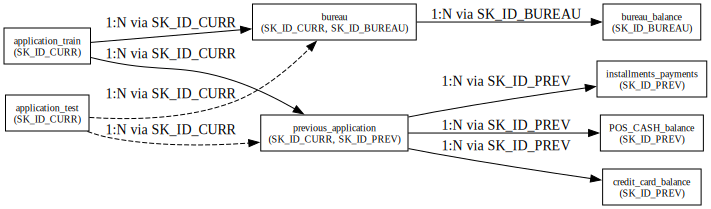

In [9]:
# ---------------------------------------------------------------
# Stage 1 — Step 4: Генерация диаграммы зависимостей между таблицами с помощью graphviz, чтобы визуально понять,
# как они связаны между собой (по каким ключам и в каком направлении)
# ---------------------------------------------------------------

from graphviz import Digraph

dot = Digraph('HomeCreditRelations')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', fontsize='10')

dot.node('application_train', 'application_train\n(SK_ID_CURR)')
dot.node('application_test', 'application_test\n(SK_ID_CURR)')
dot.node('bureau', 'bureau\n(SK_ID_CURR, SK_ID_BUREAU)')
dot.node('bureau_balance', 'bureau_balance\n(SK_ID_BUREAU)')
dot.node('previous_application', 'previous_application\n(SK_ID_CURR, SK_ID_PREV)')
dot.node('installments_payments', 'installments_payments\n(SK_ID_PREV)')
dot.node('POS_CASH_balance', 'POS_CASH_balance\n(SK_ID_PREV)')
dot.node('credit_card_balance', 'credit_card_balance\n(SK_ID_PREV)')

dot.edge('application_train', 'bureau', label='1:N via SK_ID_CURR')
dot.edge('application_test', 'bureau', label='1:N via SK_ID_CURR', style='dashed')

dot.edge('bureau', 'bureau_balance', label='1:N via SK_ID_BUREAU')

dot.edge('application_train', 'previous_application', label='1:N via SK_ID_CURR')
dot.edge('application_test', 'previous_application', label='1:N via SK_ID_CURR', style='dashed')

dot.edge('previous_application', 'installments_payments', label='1:N via SK_ID_PREV')
dot.edge('previous_application', 'POS_CASH_balance', label='1:N via SK_ID_PREV')
dot.edge('previous_application', 'credit_card_balance', label='1:N via SK_ID_PREV')

# IMPORTANT: specify only the file prefix, not the extension
dot.render('reports/figures/relations_diagram', format='png', cleanup=True)

dot




In [9]:
# ---------------------------------------------------------------
# Stage 1 — Step 5.1: Создаем функцию для построения диаграммы структуры проекта на основе конфигурации, которая будет
# учитывать папки из "folders" и "stages", и позволит визуализировать структуру проекта в виде дерева. Это поможет
# лучше понять организацию файлов и папок в проекте.
# ---------------------------------------------------------------

def project_structure_diagram_builder(
        config_path="project_structure_config.json",
        output_path="reports/figures/project_structure_diagram_color",
        fmt="svg"
    ):
    """
    Строит диаграмму структуры проекта Graphviz, используя project_structure_config.json.

    - Использует только конфигурацию (без сканирования файловой системы)
    - Учитывает иерархию из "folders" и "stages"
    - Кроссплатформенно (Windows/Linux/macOS)
    - Избегает предупреждений о размере узлов, позволяя Graphviz автоматически определять размер узлов
    """

    # ---------------------------------------------------------
    # Загрузка конфигурации
    # ---------------------------------------------------------
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Файл конфигурации не найден: {config_path}")

    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    # Root name without trailing slash
    root_name = config["root"].replace("\\", "/").strip("/")

    # ---------------------------------------------------------
    # Вспомогательные функции
    # ---------------------------------------------------------
    def sanitize(rel_path: str) -> str:
        # Нормализует путь к прямым слешам и удаляет ведущие/концевые слеши
        return rel_path.replace("\\", "/").strip("/")

    def node_id(path: str) -> str:
        # Стабильный идентификатор узла из полного пути
        return sanitize(path).replace("/", "_")

    # ---------------------------------------------------------
    # Построение дерева папок из config["folders"] и config["stages"]
    # ---------------------------------------------------------
    tree = {}

    def add_path(rel_path: str):
        parts = sanitize(rel_path).split("/")
        cur = tree
        for p in parts:
            if not p:
                continue
            if p not in cur:
                cur[p] = {}
            cur = cur[p]

    # ---------------------------------------------------------------
    # Папки из "folders"
    # ---------------------------------------------------------------
    for rel in config["folders"].values():
        add_path(rel)

    # ---------------------------------------------------------------
    # Папки вывода этапов из "stages"
    # ---------------------------------------------------------------
    for stage in config["stages"].values():
        add_path(stage["output_path"])

    # ---------------------------------------------------------
    # Инициализация Graphviz
    # ---------------------------------------------------------
    structure = Digraph("ProjectStructure")

    # ---------------------------------------------------------------
    # Вводим аттрибуты для лучшего визуального представления
    # ---------------------------------------------------------------
    structure.attr(
        rankdir="TB",
        center="true",
        nodesep="0.8",
        ranksep="1.2"
    )

    structure.attr(
        "node",
        shape="box",
        style="filled,rounded",
        fontsize="18",
        fontname="Arial",
        margin="0.30,0.25"
    )

    COLOR_ROOT = "#4C72B0"
    COLOR_FOLDER = "#55A868"
    COLOR_SUBFOLDER = "#64B5CD"

    # ---------------------------------------------------------
    # Корневой узел
    # ---------------------------------------------------------
    root_path = root_name  # e.g. "Diploma_Project"
    root_nid = node_id(root_path)

    structure.node(root_nid, f"{root_name}/", fillcolor=COLOR_ROOT, fontcolor="white")
    structure.body.append("{ rank=source; " + root_nid + " }")

    # ---------------------------------------------------------
    # Рекурсивное построение
    # ---------------------------------------------------------
    def draw(full_path: str, subtree: dict, level: int = 0):
        parent_id = node_id(full_path)

        # Сортировка детей для стабильного расположения
        for name in sorted(subtree.keys()):
            child_path = f"{full_path}/{name}"
            nid = node_id(child_path)

            label = f"{name}/"
            color = COLOR_FOLDER if level == 0 else COLOR_SUBFOLDER

            structure.node(nid, label, fillcolor=color)
            structure.edge(parent_id, nid)

            draw(child_path, subtree[name], level + 1)

    # ---------------------------------------------------------------
    # Рисуем дерево под корнем
    # ---------------------------------------------------------------
    draw(root_path, tree, 0)

    # ---------------------------------------------------------------
    # Выравнивание папок верхнего уровня по горизонтали
    # ---------------------------------------------------------------
    top_level_ids = [node_id(f"{root_path}/{name}") for name in sorted(tree.keys())]
    if top_level_ids:
        structure.body.append("{ rank=same; " + " ".join(top_level_ids) + " }")

    # ---------------------------------------------------------
    # Экспорт диаграммы
    # ---------------------------------------------------------
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    structure.render(output_path, format=fmt, cleanup=True)

    print(f"✓ Диаграмма структуры проекта сгенерирована: {output_path}.{fmt}")

    return structure


✓ Диаграмма структуры проекта сгенерирована: reports/figures/project_structure_diagram_color.svg


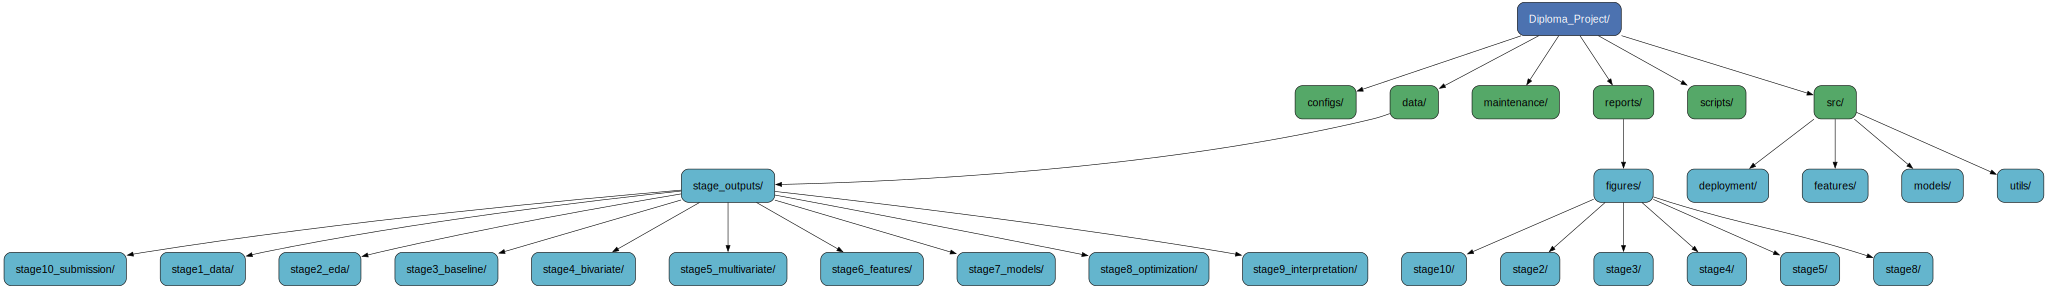

In [13]:
# ---------------------------------------------------------------
# Stage 1 — Step 5.2: Генерация диаграммы структуры проекта
# ---------------------------------------------------------------

project_structure_diagram_builder()


### Анализ целевой переменной TARGET

In [12]:
# ---------------------------------------------
# Stage 1 — Step 6.1: Анализ распределения целевой переменной TARGET
# ---------------------------------------------

# ---------------------------------------------------------------
# Получаем количество объектов каждого класса
# ---------------------------------------------------------------
target_counts = dfs['df_application_train']['TARGET'].value_counts()

# ---------------------------------------------------------------
# Получаем долю каждого класса в выборке
# ---------------------------------------------------------------
target_proportions = dfs['df_application_train']['TARGET'].value_counts(normalize=True)

print("Class counts:")
print(target_counts)

print("\nClass proportions:")
print(target_proportions)

Class counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Class proportions:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


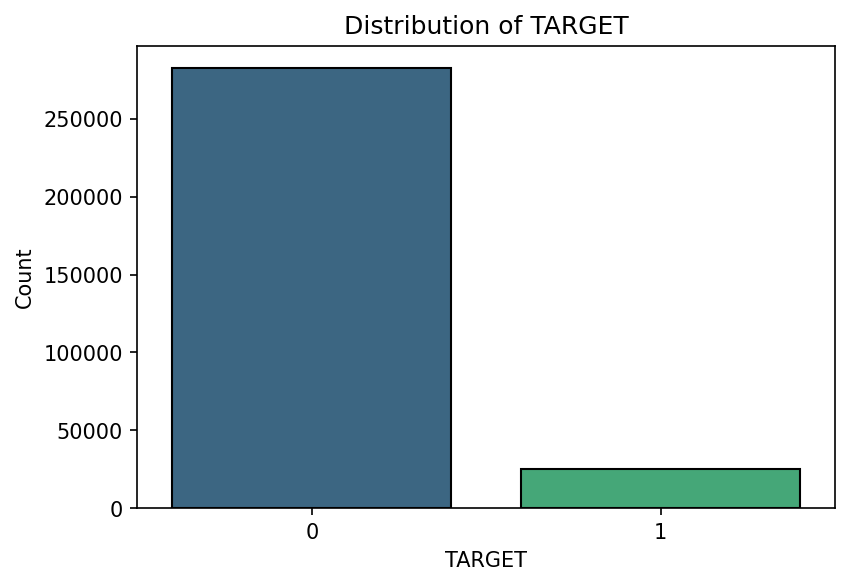

График сохранён: data/stage_outputs/stage1_data/target_distribution.png
Plot saved: data/stage_outputs/stage1_data/target_distribution.png


In [13]:
# ---------------------------------------------------------------
# Stage 1 — Step 6.2: Визуализация распределения классов TARGET и сохранение графика (динамический путь)
# ---------------------------------------------------------------

# ---------------------------------------------------------------
# Загружаем конфигурацию проекта
# ---------------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# ---------------------------------------------------------------
# Получаем путь Stage 1 из конфигурации
# ---------------------------------------------------------------
stage1_path = config["stages"]["stage1"]["output_path"]
os.makedirs(stage1_path, exist_ok=True)

plt.figure(figsize=(6,4))

# ---------------------------------------------------------------
# Столбчатая диаграмма распределения классов TARGET
# ---------------------------------------------------------------
sns.countplot(x='TARGET', data=dfs['df_application_train'], palette='viridis')

plt.title('Distribution of TARGET')
plt.xlabel('TARGET')
plt.ylabel('Count')

# ---------------------------------------------------------------
# Сохраняем график в Stage 1
# ---------------------------------------------------------------
plot_path = os.path.join(stage1_path, "target_distribution.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"График сохранён: {plot_path}")
print(f"Plot saved: {plot_path}")



In [14]:
# ---------------------------------------------
# Stage 1 — Step 6.3: Расчёт доли дефолтов (TARGET = 1)
# ---------------------------------------------

default_rate = dfs['df_application_train']['TARGET'].mean()

print(f"Default rate: {default_rate:.4f} ({default_rate*100:.2f}%)")


Default rate: 0.0807 (8.07%)


In [15]:
# ---------------------------------------------
# Stage 1 — Step 6.4: Автоматическое формирование первичных выводов
# ---------------------------------------------

total = len(dfs['df_application_train'])    # Общее число наблюдений
n0 = target_counts[0]                       # Количество класса 0
n1 = target_counts[1]                       # Количество класса 1
p1 = default_rate * 100                     # Процент дефолтов

print(f"""
Всего наблюдений: {total}
Класс 0 (нет дефолта): {n0} ({n0/total:.2%})
Класс 1 (дефолт): {n1} ({n1/total:.2%})

Доля дефолтов составляет {p1:.2f}%.

Первичные выводы:
- Целевая переменная несбалансирована (класс 1 встречается значительно реже).
- Модели могут склоняться к предсказанию класса 0.
- Может потребоваться обработка дисбаланса классов (class weights, oversampling, undersampling).
""")



Всего наблюдений: 307511
Класс 0 (нет дефолта): 282686 (91.93%)
Класс 1 (дефолт): 24825 (8.07%)

Доля дефолтов составляет 8.07%.

Первичные выводы:
- Целевая переменная несбалансирована (класс 1 встречается значительно реже).
- Модели могут склоняться к предсказанию класса 0.
- Может потребоваться обработка дисбаланса классов (class weights, oversampling, undersampling).



### Оценка качества данных

In [16]:
# ---------------------------------------------
# Stage 1 — Step 7.1: Унифицированная функция оценки качества данных
# ---------------------------------------------

def dqa_report(df, name):
    """
    df   : pandas DataFrame
    name : имя таблицы, например 'application_train'
    """
    print("=" * 80)
    print(f"Оценка качества данных для: {name}")
    print("=" * 80)

    # -------------------------
    # Пропуски
    # -------------------------
    missing_counts = df.isna().sum()
    missing_ratio = df.isna().mean()

    print("\n[Пропуски]")
    print("Топ 10 колонок по доле пропусков:")
    print(missing_ratio.sort_values(ascending=False).head(10))

    # -------------------------
    # Типы данных
    # -------------------------
    print("\n[Типы данных]")
    print(df.dtypes)

    # -------------------------
    # Выбросы (IQR)
    # -------------------------
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

    def iqr_outliers(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return ((series < lower) | (series > upper)).sum()

    outlier_summary = {
        col: iqr_outliers(df[col].dropna())
        for col in numeric_cols
        if df[col].notna().sum() > 0
    }

    print("\n[Выбросы (IQR) - топ 10]")
    print(sorted(outlier_summary.items(), key=lambda x: x[1], reverse=True)[:10])

    # -------------------------
    # Категории 'XNA'
    # -------------------------
    categorical_cols = df.select_dtypes(include=['object']).columns

    print("\n['XNA' категории  ]")
    for col in categorical_cols:
        xna_count = (df[col] == 'XNA').sum()
        if xna_count > 0:
            print(f"{col}: {xna_count} вхождений 'XNA'")

    # -------------------------
    # Проблемы с временными признаками / Time feature issues
    # -------------------------
    days_cols = [col for col in df.columns if col.startswith('DAYS_')]

    print("\n[Проблемы с временными признаками (DAYS_*)]")
    for col in days_cols:
        pos_count = (df[col] > 0).sum()
        if pos_count > 0:
            print(f"{col}: {pos_count} положительных значений обнаружено (должны быть <= 0)")

    print("\nDQA завершена для:", name)
    print("=" * 80)


In [17]:
# ---------------------------------------------
# Stage 1 — Step 7.2: Пайплайн для автоматического запуска DQA
# ---------------------------------------------

for name, df in dfs.items():
    dqa_report(df, name)


Оценка качества данных для: df_application_train

[Пропуски]
Топ 10 колонок по доле пропусков:
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
dtype: float64

[Типы данных]
SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

[Выбросы (IQR) - топ 10]
[('REGION_RATING_CLIENT', np.int64

### 5. Оценка качества данных (Data Quality Assessment)

Для всех таблиц, участвующих в построении признаков и обучении модели, была проведена оценка качества данных (DQA) с использованием единой функции `dqa_report`. Анализ выполнялся для следующих таблиц:

- `df_application_train` — основная обучающая выборка.
- `df_application_test` — тестовая выборка без целевой переменной, проверяется на согласованность со структурой train.
- `df_bureau` — внешняя кредитная история клиентов.
- `df_bureau_balance` — помесячный статус кредитов из бюро.
- `df_previous_application` — история предыдущих заявок клиентов.
- `df_pos_cash_balance` — помесячные данные по POS и cash-кредитам.
- `df_installments_payments` — история платежей по кредитам.
- `df_credit_card_balance` — помесячные данные по кредитным картам.

Для каждой таблицы оценивались:

- **Пропуски**: количество и доля отсутствующих значений по столбцам.
- **Выбросы**: количество выбросов в числовых признаках по критерию IQR.
- **Аномалии**: некорректные значения (например, положительные значения в признаках `DAYS_*`, отрицательные суммы).
- **Неверные значения**: подозрительные или редкие категориальные значения.
- **Категории “XNA”**: использование `XNA` как маркера отсутствующих или неопределённых значений.
- **Проблемы с временными признаками**: проверка согласованности признаков `DAYS_*` (ожидаются неположительные значения).

Результаты DQA использовались для:
- выбора стратегий обработки пропусков,
- корректировки аномальных и неверных значений,
- принятия решений о включении/исключении признаков в модель,
- документирования ограничений и особенностей исходных данных.


## Заключение по рискам утечки целевой переменной (Target Leakage)  
### на основе результатов DQA всех таблиц Home Credit

В ходе комплексной оценки качества данных (DQA), проведённой для всех таблиц формата `df_*`, были выявлены систематические временные несоответствия и признаки использования будущей информации. Такие случаи представляют прямую угрозу **утечки целевой переменной (target leakage)**, поскольку модель может получить доступ к данным, которые недоступны на момент подачи заявки клиентом.

Ниже приведено структурированное заключение по каждой таблице.

---

### **1. `df_application_train` и `df_application_test`**

**Обнаруженные признаки утечки:**
- В столбце `DAYS_EMPLOYED` присутствуют **положительные значения**  
  - train: 55 374  
  - test: 9 274  
  Положительные значения означают события, произошедшие *после* даты подачи заявки, что невозможно и приводит к утечке будущей информации.

**Вывод:**  
Все положительные значения `DAYS_EMPLOYED` должны быть заменены на `NaN` или скорректированы.

---

### **2. `df_bureau`**

**Обнаруженные признаки утечки:**
- `DAYS_CREDIT_ENDDATE`: **602 603 положительных значений**  
  Указывает на дату окончания кредита *после* подачи заявки.
- `DAYS_CREDIT_UPDATE`: **17 положительных значений**  
  Обновления кредитной информации после даты заявки.

**Вывод:**  
Строки с положительными `DAYS_*` содержат будущие события и должны быть удалены или скорректированы.

---

### **3. `df_bureau_balance`**

**Обнаруженные признаки утечки:**  
- Не выявлено. Все значения `MONTHS_BALANCE` корректны (≤ 0).

**Вывод:**  
Риск утечки отсутствует.

---

### **4. `df_previous_application`**

**Обнаруженные признаки утечки:**  
Массовые положительные значения временных признаков:

- `DAYS_FIRST_DRAWING`: 934 444  
- `DAYS_FIRST_DUE`: 40 645  
- `DAYS_LAST_DUE_1ST_VERSION`: 318 256  
- `DAYS_LAST_DUE`: 211 221  
- `DAYS_TERMINATION`: 225 913  

Все эти значения описывают события, произошедшие *после* текущей заявки.

**Вывод:**  
Все положительные `DAYS_*` должны быть исключены или заменены на `NaN`.

---

### **5. `df_POS_CASH_balance`**

**Обнаруженные признаки утечки:**  
- Не выявлено. `MONTHS_BALANCE` всегда ≤ 0.

**Вывод:**  
Риск утечки отсутствует.

---

### **6. `df_installments_payments`**

**Обнаруженные признаки утечки:**
- `DAYS_ENTRY_PAYMENT`: 1 положительное значение  
  Это означает платёж, зарегистрированный после даты заявки.

**Вывод:**  
Строка должна быть удалена или скорректирована.

---

### **7. `df_credit_card_balance`**

**Обнаруженные признаки утечки:**  
- Не выявлено. Все временные признаки корректны.

**Вывод:**  
Риск утечки отсутствует.

---

## Итоговое заключение

Основным источником утечки целевой переменной в датасете Home Credit являются **временные признаки (`DAYS_*`, `MONTHS_BALANCE`)**, содержащие **положительные значения**, которые отражают события, произошедшие *после* подачи заявки. Использование таких данных при обучении приводит к завышенной оценке качества модели и ухудшению её обобщающей способности.

### Таблицы с подтверждёнными рисками утечки:
- `df_application_train`  
- `df_application_test`  
- `df_bureau`  
- `df_previous_application`  
- `df_installments_payments` (единичные случаи)

### Таблицы без рисков утечки:
- `df_bureau_balance`  
- `df_POS_CASH_balance`  
- `df_credit_card_balance`

### Рекомендуемые меры:
- Заменить все положительные значения `DAYS_*` на `NaN` или удалить соответствующие строки.  
- Проверить согласованность временных признаков после очистки.  
- Документировать все корректировки в разделе предобработки данных дипломной работы.

---


## Унифицированная функция очистки данных (Data Cleaning Function)

Для обеспечения воспроизводимости и единообразия предобработки данных была разработана
унифицированная функция очистки, применяемая ко всем таблицам набора Home Credit.
Функция выполняет следующие ключевые операции:

### 1. Замена категориального значения `'XNA'` на пропуски (`NaN`)
Во всех таблицах встречается специальное значение `'XNA'`, обозначающее отсутствие информации.
Для корректной обработки категориальных признаков оно заменяется на `NaN`.

### 2. Устранение утечек целевой переменной (Target Leakage)
Все положительные значения временных признаков `DAYS_*` и `MONTHS_BALANCE` заменяются на `NaN`,
поскольку такие значения отражают события, произошедшие *после* даты подачи заявки, и могут привести
к утечке будущей информации в модель.

### 3. Коррекция placeholder‑значений
Некоторые признаки содержат специальные технические значения, которые не являются реальными.
Наиболее важный пример:

- `DAYS_EMPLOYED = 365243` — это не реальный стаж, а код, обозначающий отсутствие данных.

Такое значение необходимо заменить на `NaN`, поскольку:

- оно искажает статистику и визуализацию,
- нарушает распределение признака,
- может привести к утечке целевой переменной (положительное значение временного признака),
- мешает корректной работе алгоритмов машинного обучения.

### 4. Нормализация типов данных
Категориальные признаки приводятся к типу `category`, числовые — к корректным числовым типам.
Это обеспечивает согласованность данных и оптимизирует использование памяти.

### 5. Единообразие обработки всех таблиц
Использование единой функции позволяет:

- автоматизировать подготовку данных,
- уменьшить количество ошибок,
- обеспечить одинаковую логику очистки для всех таблиц,
- гарантировать корректность последующего EDA и построения признаков.

---

Такой подход делает процесс предобработки данных масштабируемым, прозрачным и полностью
воспроизводимым, что является обязательным требованием для качественного анализа и построения
надёжной модели кредитного скоринга.



In [18]:
# ---------------------------------------------------------
# Stage 1 — Step 8.1: Унифицированная функция очистки таблиц Home Credit
# ---------------------------------------------------------

def clean_home_credit_table(df, name):
    """
    df   : pandas DataFrame
    name : имя таблицы, например 'application_train'
    """

    df = df.copy()

    # ---------------------------------------------
    # 1. Замена 'XNA' на NaN
    # ---------------------------------------------
    df = df.replace('XNA', np.nan)

    # ---------------------------------------------
    # 2. Очистка временных признаков DAYS_*
    # ---------------------------------------------
    days_cols = [col for col in df.columns if col.startswith('DAYS_')]
    for col in days_cols:
        # Положительные значения → NaN (утечка будущего)
        df.loc[df[col] > 0, col] = np.nan

    # ---------------------------------------------
    # 3. Очистка MONTHS_BALANCE (если есть)
    # ---------------------------------------------
    if 'MONTHS_BALANCE' in df.columns:
        df.loc[df['MONTHS_BALANCE'] > 0, 'MONTHS_BALANCE'] = np.nan

    # ---------------------------------------------
    # 4. Специальные placeholder‑значения
    # ---------------------------------------------
    if 'DAYS_EMPLOYED' in df.columns:
        df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

    # ---------------------------------------------
    # 5A. Преобразование возраста в годы (для удобства)
    # ---------------------------------------------
    if 'DAYS_BIRTH' in df.columns:
        df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype('float')

    # ---------------------------------------------
    # 5B. Удаление невозможных отрицательных значений
    # ---------------------------------------------
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    # Значения < 0 → NaN (кроме временных признаков DAYS_*)
    for col in num_cols:
        if not col.startswith('DAYS_'):
            df.loc[df[col] < 0, col] = np.nan

    # ---------------------------------------------
    # 6. Приведение типов (если требуется)
    # ---------------------------------------------
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')

    return df



In [19]:
# ---------------------------------------------------------
# Stage 1 — Step 8.2: Пайплайн очистки всех таблиц df_*, используя функцию clean_home_credit_table(), и сохранение очищенных DataFrame в новый словарь dfs_cleaned для дальнейшего использования в EDA и моделировании.
# ---------------------------------------------------------

# ---------------------------------------------
# Словарь для хранения очищенных DataFrame
# ---------------------------------------------
dfs_cleaned = {}

for name, df in dfs.items():
    dfs_cleaned[name] = clean_home_credit_table(df, name)
    print(f"Очистка завершена: {name}")


Очистка завершена: df_application_train
Очистка завершена: df_bureau
Очистка завершена: df_bureau_balance
Очистка завершена: df_credit_card_balance
Очистка завершена: df_installments_payments
Очистка завершена: df_pos_cash_balance
Очистка завершена: df_previous_application


## Функция `dataset_reduction()`: назначение и применение

### Назначение
Функция `dataset_reduction()` уменьшает размер каждого датафрейма в словаре `dfs_cleaned`, выбирая случайную долю строк (`sample_frac`).  
Это позволяет значительно ускорить дальнейшие этапы анализа данных (EDA), построение словарей, вычисление статистик и генерацию графиков.
Использование этой функции на этапе разработки обучающейся модели позволит сэкономить существенное время. По окончанию процесса разработки
модель будет обучена на полном наборе данных (sample_frac-1.0)

### Когда использовать
Используйте `dataset_reduction()` **после очистки данных**, но **до запуска EDA‑пайплайна**, если:
- исходные таблицы слишком большие (миллионы строк);
- полный EDA занимает слишком много времени;
- вы хотите быстро протестировать логику пайплайна;
- вы работаете в ограниченной среде (ограничения по памяти/CPU).

### Как работает
Для каждой таблицы в `dfs_cleaned` функция:
1. случайным образом выбирает `sample_frac` долю строк;
2. возвращает новый словарь с уменьшенными таблицами;
3. сохраняет структуру словаря (ключи не меняются);
4. обеспечивает воспроизводимость через `random_state`.

### Пример использования
```python
dfs_cleaned = dataset_reduction(dfs_cleaned, sample_frac=0.1)
run_full_eda(dfs_cleaned, eda_config)


In [20]:
# ---------------------------------------------------------
# Stage 1 — Step 8.3: Функция для уменьшения размера датасетов для ускорения экспериментов, которая будет
# принимать словарь очищенных DataFrame (dfs_cleaned) и возвращать новый словарь с уменьшенными DataFrame,
# выбирая случайную долю строк.
# ---------------------------------------------------------

def dataset_reduction(dfs_cleaned, sample_frac=1.0, random_state=42):
    """
    Stage 1 — Step 8.3: Уменьшение размера датасетов для ускорения экспериментов.
    Уменьшает размер каждого датафрейма в dfs_cleaned,
    выбирая случайную долю строк (sample_frac).
    
    Параметры:
        dfs_cleaned: словарь датафреймов, например:
                     {"df_application_train": df, ...}
        sample_frac: доля строк для выборки (1.0 = полный размер)
        random_state: seed для воспроизводимости

    Возвращает:
        reduced_dfs: словарь уменьшенных датафреймов
    """

    reduced_dfs = {}

    for name, df in dfs_cleaned.items():
        print(f"Снижаю размер таблицы: {name}")

        if sample_frac < 1.0:
            df_reduced = df.sample(
                frac=sample_frac,
                random_state=random_state
            ).reset_index(drop=True)
            print(f"  → {len(df_reduced)} строк ({sample_frac*100:.1f}% выборки)")
        else:
            df_reduced = df.copy()
            print(f"  → полный размер: {len(df_reduced)} строк")

        reduced_dfs[name] = df_reduced

    print("Уменьшение датасета завершено.")
    return reduced_dfs


In [21]:
# ============================================================
# Stage 1 — Step 9: Сохранение результатов
# ============================================================

import os
import pickle
from datetime import datetime

# ------------------------------------------------------------
# 9.1 Загрузка конфигурации проекта
# ------------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

stage1_path = config["stages"]["stage1"]["output_path"]
os.makedirs(stage1_path, exist_ok=True)

print("Stage 1 output directory:", stage1_path)

# ------------------------------------------------------------
# 9.2 Приведение имён таблиц к стандарту (убираем df_)
# ------------------------------------------------------------
rename_map = {
    "df_application_train": "application_train",
    "df_bureau": "bureau",
    "df_bureau_balance": "bureau_balance",
    "df_previous_application": "previous_application",
    "df_installments_payments": "installments_payments",
    "df_credit_card_balance": "credit_card_balance",
    "df_pos_cash_balance": "pos_cash_balance",
}

dfs_cleaned_standardized = {}

for old_name, df in dfs_cleaned.items():
    new_name = rename_map.get(old_name, old_name)  # fallback: keep original
    dfs_cleaned_standardized[new_name] = df
    print(f" → {old_name} сохранён как {new_name}")

# ------------------------------------------------------------
# 9.3 Сохранение всех таблиц Stage 1
# ------------------------------------------------------------
for name, df in dfs_cleaned_standardized.items():
    file_path = os.path.join(stage1_path, f"cleaned_{name}.pkl")
    with open(file_path, "wb") as f:
        pickle.dump(df, f)
    print(f"Сохранено: {file_path}")

# ============================================================
# Stage 1 — Step 9.1: Сводка JSON
# ============================================================

stage1_summary = {
    "tables_loaded": list(dfs_cleaned_standardized.keys()),
    "rows": {k: int(v.shape[0]) for k, v in dfs_cleaned_standardized.items()},
    "columns": {k: int(v.shape[1]) for k, v in dfs_cleaned_standardized.items()},
    "sample_variant": "full"
}

with open(os.path.join(stage1_path, "stage1_summary.json"), "w", encoding="utf-8") as f:
    json.dump(stage1_summary, f, indent=4, ensure_ascii=False)

print("Stage 1 сводка сохранена.")

# ============================================================
# Stage 1 — Step 9.2: Лог JSON
# ============================================================

stage1_log = {
    "stage": "Stage 1 — Data Loading & Cleaning",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "tables_loaded": list(dfs_cleaned_standardized.keys()),
    "shapes": {k: list(v.shape) for k, v in dfs_cleaned_standardized.items()},
    "sample_variant": "full",
    "notes": "Stage 1 выполнен успешно"
}

with open(os.path.join(stage1_path, "stage1_log.json"), "w", encoding="utf-8") as f:
    json.dump(stage1_log, f, indent=4, ensure_ascii=False)

print("Stage 1 лог сохранен.")




Stage 1 output directory: data/stage_outputs/stage1_data/
 → df_application_train сохранён как application_train
 → df_bureau сохранён как bureau
 → df_bureau_balance сохранён как bureau_balance
 → df_credit_card_balance сохранён как credit_card_balance
 → df_installments_payments сохранён как installments_payments
 → df_pos_cash_balance сохранён как pos_cash_balance
 → df_previous_application сохранён как previous_application
Сохранено: data/stage_outputs/stage1_data/cleaned_application_train.pkl
Сохранено: data/stage_outputs/stage1_data/cleaned_bureau.pkl
Сохранено: data/stage_outputs/stage1_data/cleaned_bureau_balance.pkl
Сохранено: data/stage_outputs/stage1_data/cleaned_credit_card_balance.pkl
Сохранено: data/stage_outputs/stage1_data/cleaned_installments_payments.pkl
Сохранено: data/stage_outputs/stage1_data/cleaned_pos_cash_balance.pkl
Сохранено: data/stage_outputs/stage1_data/cleaned_previous_application.pkl
Stage 1 сводка сохранена.
Stage 1 лог сохранен.


# Stage 2 — Univariate EDA и отбор перспективных признаков (`stage2_eda`)

**Назначение этапа:**  
Провести детальный одномерный анализ признаков (Univariate EDA),  
оценить качество данных, вычислить статистики и флаги качества,  
выделить шумовые признаки и сформировать список перспективных признаков  
для последующих этапов моделирования.

**Входные данные:**  
- Очищенные таблицы из Stage 1 (`dfs_cleaned`)  
- **Путь к данным:** `data/stage_outputs/stage1_data/`

**Выходные данные:**  
- Словари EDA:  
  - `summary_dict`  
  - `numeric_stats_dict`  
  - `categorical_stats_dict`  
  - `quality_flags_dict`  
  - `correlation_dict`  
  - `plot_recommendations_dict`  
  - `table_specific_dict`  
- Отчёт о качестве данных (DQA summary)  
- Список перспективных признаков (`promising_features`)  
- Отчёт об удалённых признаках (`removal_report`)  
- Графики только для перспективных признаков  
- Итоговый отчёт Stage 2 (`stage2_summary.json`)  
- **Путь сохранения:** `data/stage_outputs/stage2_eda/`

**Краткое описание обработки:**  
- Загрузка очищенных таблиц Stage 1  
- Применение конфигурации EDA (`eda_config`)  
- Построение EDA‑словарей (статистики, флаги качества, корреляции, рекомендации)  
- Агрегация результатов DQA  
- Фильтрация шумовых признаков и формирование списка перспективных  
- Сохранение словарей, отчётов и списков признаков  
- Генерация графиков только для перспективных признаков  
- Формирование итогового отчёта Stage 2  
- Подготовка набора данных для Stage 3 (модельная таблица с перспективными признаками)


In [22]:
# ---------------------------------------------------------
# Stage 2 — Step 1: Загрузка очищенных таблиц + опциональное уменьшение датасета
# ---------------------------------------------------------

def data_loading_stage1_to_2(dfs_cleaned, sample_frac=1.0, random_state=42):
    """
    Загружает очищенные таблицы Stage 1, если dfs_cleaned пуст.
    При необходимости уменьшает размер таблиц с помощью sample_frac.
        Параметры:
            dfs_cleaned: словарь с очищенными DataFrame (может быть пустым)
            sample_frac: доля строк для загрузки (1.0 = полный размер)
            random_state: seed для воспроизводимости
        Возвращает:
            dfs_cleaned_loaded: словарь с загруженными (и возможно уменьшенными) DataFrame для Stage 2 EDA
    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    stage1_path = config["stages"]["stage1"]["output_path"]

    # ---------------------------------------------------------
    # Если dfs_cleaned уже заполнен — просто возвращаем его
    # ---------------------------------------------------------
    if dfs_cleaned:
        print("dfs_cleaned уже загружен в память — используя существующие данные.")
        # Если нужно уменьшить — уменьшаем
        if sample_frac < 1.0:
            print(f"Применение уменьшения датасета: sample_frac={sample_frac}")
            dfs_cleaned = dataset_reduction(dfs_cleaned, sample_frac, random_state)
        return dfs_cleaned

    # ---------------------------------------------------------
    # Иначе загружаем очищенные таблицы из Stage 1
    # ---------------------------------------------------------
    print(f"Загрузка очищенных таблиц из: {stage1_path}")

    if not os.path.exists(stage1_path):
        raise FileNotFoundError(f"Папка с результатами Stage 1 не найдена: {stage1_path}")

    dfs_cleaned_loaded = {}

    for file in os.listdir(stage1_path):
        if file.startswith("cleaned_") and file.endswith(".pkl"):
            table_name = file.replace("cleaned_", "").replace(".pkl", "")
            file_path = os.path.join(stage1_path, file)

            with open(file_path, "rb") as f:
                df = pickle.load(f)

            dfs_cleaned_loaded[table_name] = df
            print(f"   Загружено: {file}  → shape={df.shape}")

    if not dfs_cleaned_loaded:
        raise RuntimeError("Не найдено очищенных таблиц в папке с результатами Stage 1.")

    print(f"\nЗагружено {len(dfs_cleaned_loaded)} очищенных таблиц из Stage 1.")

    # ---------------------------------------------------------
    # Применяем уменьшение датасета, если требуется
    # ---------------------------------------------------------
    if sample_frac < 1.0:
        print(f"\nПрименение уменьшения датасета: sample_frac={sample_frac}")
        dfs_cleaned_loaded = dataset_reduction(
            dfs_cleaned_loaded,
            sample_frac=sample_frac,
            random_state=random_state
        )

    return dfs_cleaned_loaded



In [23]:
# ---------------------------------------------------------
# Stage 2 — Step 2: Инициализация
# ---------------------------------------------------------

print("\n=== Инициализация Stage 2: EDA ===")
# ---------------------------------------------------------
# Загрузка очищенных таблиц Stage 1
# ---------------------------------------------------------
dfs_cleaned = data_loading_stage1_to_2(dfs_cleaned={}, sample_frac=1.0)




=== Инициализация Stage 2: EDA ===
Загрузка очищенных таблиц из: data/stage_outputs/stage1_data/
   Загружено: cleaned_application_train.pkl  → shape=(307511, 123)
   Загружено: cleaned_bureau.pkl  → shape=(1716428, 17)
   Загружено: cleaned_bureau_balance.pkl  → shape=(27299925, 3)
   Загружено: cleaned_credit_card_balance.pkl  → shape=(3840312, 23)
   Загружено: cleaned_df_application_train.pkl  → shape=(307511, 123)
   Загружено: cleaned_df_bureau.pkl  → shape=(1716428, 17)
   Загружено: cleaned_df_bureau_balance.pkl  → shape=(27299925, 3)
   Загружено: cleaned_df_credit_card_balance.pkl  → shape=(3840312, 23)
   Загружено: cleaned_df_installments_payments.pkl  → shape=(13605401, 8)
   Загружено: cleaned_df_pos_cash_balance.pkl  → shape=(10001358, 8)
   Загружено: cleaned_df_previous_application.pkl  → shape=(1670214, 37)
   Загружено: cleaned_installments_payments.pkl  → shape=(13605401, 8)
   Загружено: cleaned_pos_cash_balance.pkl  → shape=(10001358, 8)
   Загружено: cleaned_pre

После выполнения унифицированной функции очистки все таблицы набора Home Credit приведены к корректному состоянию для проведения разведочного анализа данных (EDA).

Функция устранила утечки целевой переменной, заменила placeholder‑значения, нормализовала типы данных и привела отсутствующие значения к единому формату.

# Архитектура EDA в многотабличном проекте Home Credit

Проект Home Credit состоит из нескольких связанных таблиц, каждая из которых имеет собственные типы данных, пропуски, кардинальность признаков и предметные особенности.  
Классический подход «делать EDA по одной таблице» приводит к перегрузке выводом, разрозненности результатов и невозможности повторно использовать вычисленные статистики.

Чтобы обеспечить модульность, управляемость и воспроизводимость анализа, EDA организован в виде **тематических словарей**, каждый из которых отвечает за свою область анализа.  
Такой подход делает EDA:
- **модульным** — каждая тема изолирована;  
- **масштабируемым** — легко добавлять новые метрики;  
- **воспроизводимым** — поведение управляется конфигурацией;  
- **управляемым** — вывод не перегружен;  
- **практичным** — результаты используются на следующих этапах (feature engineering, отчёты).

---

## Тематические словари EDA: структура и назначение

### **1. `summary_dict` — сводная информация по таблицам**
Содержит:
- размер таблицы;  
- типы данных;  
- количество уникальных значений;  
- долю пропусков;  
- долю нулевых и отрицательных значений.  

**Назначение:** быстрое понимание структуры таблицы.

---

### **2. `numeric_stats_dict` — статистика числовых признаков**
Содержит:
- описательные статистики;  
- квантили (1%, 5%, 95%, 99%);  
- дисперсию;  
- skewness и kurtosis;  
- IQR и количество выбросов.  

**Назначение:** выявление выбросов, перекосов распределений и аномалий.

---

### **3. `categorical_stats_dict` — статистика категориальных признаков**
Содержит:
- кардинальность;  
- топ‑категории;  
- редкие категории (<1%);  
- моду.  

**Назначение:** подготовка к кодированию категорий и выявление проблемных признаков.

---

### **4. `quality_flags_dict` — флаги качества данных**
Содержит:
- признаки с высокой долей пропусков;  
- константные признаки;  
- признаки с высокой кардинальностью.  

**Назначение:** выявление признаков, требующих очистки или удаления.

---

### **5. `correlation_dict` — корреляции и зависимости**
Содержит:
- корреляцию Пирсона;  
- корреляцию Спирмена.  

**Назначение:** отбор признаков и анализ избыточности.

---

### **6. `plot_recommendations_dict` — рекомендации по визуализации**
Содержит:
- рекомендуемые числовые и категориальные признаки;  
- признаки с высокой асимметрией;  
- признаки с высокой долей пропусков;  
- признаки с высокой кардинальностью.  

**Назначение:** избежать перегрузки графиками и сосредоточиться на ключевых признаках.

---

### **7. `table_specific_dict` — предметно‑ориентированные метрики**
Содержит:
- метрики, специфичные для каждой таблицы (например, задержки платежей, активные кредиты, коэффициенты использования кредитных карт).  

**Назначение:** учёт особенностей предметной области кредитного скоринга.

---

## Конфигурационный словарь `eda_config` как единая точка управления

Все параметры EDA объединены в единый конфигурационный словарь `eda_config`, который определяет:
- какие таблицы анализировать;  
- какие фильтры строк и столбцов применять;  
- какие пороги использовать;  
- какие вычисления включать или отключать;  
- какие предметные метрики считать.  

Это позволяет менять поведение EDA **без изменения кода**, просто подставляя другую конфигурацию.

---

## Преимущества архитектуры тематических словарей

- **Модульность** — каждая тема изолирована.  
- **Масштабируемость** — легко добавлять новые метрики.  
- **Повторное использование** — словари применяются в feature engineering и отчётности.  
- **Контроль производительности** — тяжёлые вычисления можно отключать.  
- **Чистота ноутбука** — вывод не перегружен.  
- **Воспроизводимость** — конфигурации можно сохранять и повторно использовать.  

Архитектура тематических словарей создаёт прочный фундамент для профессионального EDA в многотабличных проектах.


In [24]:
# ============================================================
# Stage 2 — Step 3: Конфигурация для EDA и DQA
# ============================================================

# ---------------------------------------------------------
# Конфигурация для EDA и DQA (без жёстких путей)
# Configuration for EDA and DQA (no rigid paths)
# ---------------------------------------------------------

eda_config = {

    # -----------------------------------------------------
    # 1. Какие таблицы анализировать
    # -----------------------------------------------------
    "tables": None,  # None = все таблицы

    # -----------------------------------------------------
    # 2. Фильтры строк
    # -----------------------------------------------------
    "row_filters": {
        # "bureau": lambda df: df[df["CREDIT_ACTIVE"] == "Active"],
    },

    # -----------------------------------------------------
    # 3. Фильтры столбцов
    # -----------------------------------------------------
    "column_filters": {
        # "application_train": lambda cols: [c for c in cols if "AMT" in c],
    },

    # -----------------------------------------------------
    # 4. Пороги качества данных
    # -----------------------------------------------------
    "missing_threshold": 0.8,
    "cardinality_threshold": 500,
    "skew_threshold": 20.0,

    # -----------------------------------------------------
    # 5. Пределы визуализаций
    # -----------------------------------------------------
    "max_numeric_plots": 10,
    "max_categorical_plots": 10,

    # -----------------------------------------------------
    # 6. Тяжелые вычисления
    # -----------------------------------------------------
    "compute_correlations": True,
    "compute_mutual_info": False,

    # -----------------------------------------------------
    # 7. Табличные параметры
    # -----------------------------------------------------
    "table_specific_params": {
        "bureau": {"compute_active_credit_stats": True},
        "installments_payments": {"compute_delay_stats": True},
        "credit_card_balance": {"compute_utilization": True},
    },

    # -----------------------------------------------------
    # 8. Пути кеширования
    # -----------------------------------------------------
    # Пути берутся ТОЛЬКО из project_structure_config.json
}



In [25]:
# ---------------------------------------------------------
# Stage 2 — Step 4: Инициализация словарей для хранения результатов EDA
# ---------------------------------------------------------

summary_dict = {}
numeric_stats_dict = {}
categorical_stats_dict = {}
quality_flags_dict = {}
correlation_dict = {}
plot_recommendations_dict = {}
table_specific_dict = {}


## Creating Summary Dictionary: Summary — базовая информация о таблице
Этот блок собирает ключевые структурные характеристики таблицы: размер, типы данных, уникальные значения, пропуски, нули и отрицательные значения.


In [26]:
# ---------------------------------------------------------
# Stage 2 — Step 4.1: Унифицированная функция для построения сводного словаря с базовой информацией о каждой таблице,
# который будет использоваться в дальнейшем для анализа и принятия решений по обработке данных
# ---------------------------------------------------------

def build_summary_dict(df):
    return {
        "shape": df.shape,
        "dtypes": df.dtypes,
        "n_unique": df.nunique(),
        "missing_fraction": df.isna().mean(),
        "zero_fraction": (df == 0).mean(numeric_only=True),
        "negative_fraction": (df.select_dtypes(include=["float64", "int64"]) < 0).mean()
    }


## Creating Numeric Dictionary: Numeric Stats — статистика числовых признаков
Содержит описательные статистики, квантили, асимметрию, эксцесс, дисперсию, IQR и количество выбросов.


In [27]:
# ---------------------------------------------------------
# Stage 2 — Step 4.2: Расширенная версия build_numeric_dict с дополнительными метриками по каждой числовой колонке
# ---------------------------------------------------------

def build_numeric_dict(df, skew_threshold):
    num_cols = df.select_dtypes(include=["float64", "int64"]).columns
    if len(num_cols) == 0:
        return {}

    numeric_dict = {}

    for col in num_cols:
        series = df[col].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        outlier_mask = (series < (q1 - 1.5 * iqr)) | (series > (q3 + 1.5 * iqr))
        outlier_count = int(outlier_mask.sum())

        numeric_dict[col] = {
            "mean": float(series.mean()),
            "std": float(series.std()),
            "skew": float(series.skew()),
            "kurt": float(series.kurtosis()),
            "iqr": float(iqr),
            "outliers": outlier_count,
            "is_skewed": abs(series.skew()) > skew_threshold
        }

    return numeric_dict


## Creating Categorical Dictionary: Categorical Stats — статистика категориальных признаков
Содержит кардинальность, топ‑категории, редкие категории и моду.


In [28]:
# ---------------------------------------------------------
# Stage 2 — Step 4.3: Расширенная версия build_categorical_dict с дополнительными метриками по каждой категорической колонке
# ---------------------------------------------------------

def build_categorical_dict(df):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    stats = {}

    for col in cat_cols:
        series = df[col].dropna()

        # Value counts
        vc = series.value_counts()
        freq = vc / len(series)

        # Top category
        if not vc.empty:
            top_value = vc.idxmax()
            top_freq = float(freq.max())
        else:
            top_value = None
            top_freq = 0.0

        stats[col] = {
            "n_unique": int(series.nunique()),
            "top_value": top_value,
            "top_freq": top_freq,
            "rare_categories": vc[freq < 0.01].to_dict(),   # преобразовать в словарь для сериализации
            "top_categories": vc.head(10).to_dict(),        # преобразовать в словарь для сериализации
            "mode": series.mode().iloc[0] if not series.mode().empty else None
        }

    return stats



## Creating Quality Dictionary: Quality Flags — флаги качества данных
Определяет признаки с высокой долей пропусков, константные признаки и признаки с высокой кардинальностью.


In [29]:
# ---------------------------------------------------------
# Stage 2 — Step 4.4: Расширенная версия build_quality_dict, которая использует результаты из summary_dict и добавляет
# флаги качества данных на основе заданных порогов для пропусков, кардинальности, и других метрик, чтобы автоматически
# выявлять потенциальные проблемы с данными в каждой таблице.
# ---------------------------------------------------------

def build_quality_dict(df, summary, cardinality_threshold, missing_threshold):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    high_missing = summary["missing_fraction"][summary["missing_fraction"] > missing_threshold].index.tolist()
    constant_features = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
    high_cardinality = [col for col in cat_cols if df[col].nunique() > cardinality_threshold]

    return {
        "high_missing_features": high_missing,
        "constant_features": constant_features,
        "high_cardinality_features": high_cardinality
    }


## Creating Correlation Dictionary: Correlations — корреляции числовых признаков
Вычисляет корреляции Пирсона и Спирмена (если включено в конфигурации).


In [30]:
# ---------------------------------------------------------
# Stage 2 — Step 4.5: Функция для построения словаря с корреляциями между числовыми признаками, которая будет использоваться
# для выявления сильных линейных и монотонических зависимостей между признаками, что может помочь в дальнейшем при выборе
# признаков для моделирования и при обработке мультиколлинеарности.
# ---------------------------------------------------------

def build_correlation_dict(df, compute_correlations):
    num_cols = df.select_dtypes(include=["float64", "int64"]).columns
    if not compute_correlations or len(num_cols) == 0:
        return {}

    return {
        "pearson": df[num_cols].corr(method="pearson"),
        "spearman": df[num_cols].corr(method="spearman")
    }


## Creating Plot Recommendations Dictionary: Plot Recommendations — рекомендации по визуализации
Выбирает ограниченное число признаков для графиков, чтобы не перегружать вывод.


In [31]:
# ---------------------------------------------------------
# Stage 2 — Step 4.6:Функция для построения словаря с рекомендациями по визуализации, которая будет использоваться
# для автоматической генерации графиков распределения и категориальных диаграмм для наиболее важных признаков,
# а также для выявления признаков с сильной асимметрией или большим количеством пропусков, которые могут потребовать
# специального внимания при визуализации.
# ---------------------------------------------------------

def build_plot_recommendations_dict(df, numeric_stats, quality_flags, max_numeric, max_categorical):
    num_cols = df.select_dtypes(include=["float64", "int64"]).columns
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    return {
        "recommended_numeric": list(num_cols[:max_numeric]),
        "recommended_categorical": list(cat_cols[:max_categorical]),
        "skewed_features": numeric_stats.get("skewed_features", []),
        "heavy_missing_features": quality_flags["high_missing_features"],
        "high_cardinality_features": quality_flags["high_cardinality_features"]
    }


## Creating Tables Specific Dictionary: Table‑Specific Metrics — предметно‑ориентированные метрики
Добавляет метрики, специфичные для отдельных таблиц (например, задержки платежей, активные кредиты).


In [32]:
# ---------------------------------------------------------
# Stage 2 — Step 4.7: Функция для построения словаря с метриками, специфичными для каждой таблицы, которая будет
# использоваться для вычисления специализированных метрик, таких как количество активных кредитов в таблице bureau,
# средняя задержка платежей в installments_payments, или средняя загрузка кредитной линии в credit_card_balance,
# что может помочь в дальнейшем при анализе данных и при выборе признаков для моделирования.
# ---------------------------------------------------------

def build_table_specific_dict(df, table_name, params):
    metrics = {}

    if table_name == "bureau" and params.get("compute_active_credit_stats"):
        metrics["active_credits"] = (df["CREDIT_ACTIVE"] == "Active").sum()

    if table_name == "installments_payments" and params.get("compute_delay_stats"):
        if "DAYS_INSTALMENT" in df and "DAYS_ENTRY_PAYMENT" in df:
            metrics["avg_payment_delay"] = (df["DAYS_ENTRY_PAYMENT"] - df["DAYS_INSTALMENT"]).mean()

    if table_name == "credit_card_balance" and params.get("compute_utilization"):
        if "AMT_BALANCE" in df and "AMT_CREDIT_LIMIT_ACTUAL" in df:
            metrics["avg_utilization"] = (df["AMT_BALANCE"] / df["AMT_CREDIT_LIMIT_ACTUAL"]).mean()

    return metrics


## Оркестратор: build_eda_dictionaries
Вызывает все блоки по очереди и заполняет тематические словари.


In [33]:
# ---------------------------------------------------------
# Stage 2 — Step 4.8: Унифицированная функция для построения всех EDA словарей для каждой таблицы, которая будет
# использоваться для последовательного анализа каждой таблицы в dfs_cleaned с применением заданных
# фильтров и порогов из eda_config, и сохранения результатов в соответствующих словарях для дальнейшего
# использования в анализе данных и при принятии решений по обработке данных.
# ---------------------------------------------------------

def build_eda_dictionaries(dfs_cleaned, eda_config):

    # Выбор правильной таблицы
    tables = eda_config.get("tables")
    if not tables:   # catches None, [], {}, empty tuple
        tables = dfs_cleaned.keys()

    for name in tables:
        df = dfs_cleaned[name]

        # Фильтры строк
        if name in eda_config.get("row_filters", {}):
            df = eda_config["row_filters"][name](df)

        # Фильтры столбцов
        if name in eda_config.get("column_filters", {}):
            cols = eda_config["column_filters"][name](df.columns)
            df = df[cols]

        # Построение сводной информации
        summary = build_summary_dict(df)
        summary_dict[name] = summary

        # Числовые показатели
        numeric_stats = build_numeric_dict(df, eda_config["skew_threshold"])
        numeric_stats_dict[name] = numeric_stats

        # Категориальные показатели
        categorical_stats = build_categorical_dict(df)
        categorical_stats_dict[name] = categorical_stats

        # Качество данных
        quality_flags = build_quality_dict(
            df, summary,
            eda_config["cardinality_threshold"],
            eda_config["missing_threshold"]
        )
        quality_flags_dict[name] = quality_flags

        # Корреляции
        correlation_dict[name] = build_correlation_dict(
            df, eda_config["compute_correlations"]
        )

        # Рекомендации по визуализации
        plot_recommendations_dict[name] = build_plot_recommendations_dict(
            df, numeric_stats, quality_flags,
            eda_config["max_numeric_plots"],
            eda_config["max_categorical_plots"]
        )

        # Специфические метрики для таблицы
        table_specific_dict[name] = build_table_specific_dict(
            df, name,
            eda_config.get("table_specific_params", {}).get(name, {})
        )

    print("EDA словари успешно построены.")



# Создаем набор Plotting Functions

`plot_numeric_distribution()`

Показывает распределение числового признака (гистограмма + KDE).  
Используется для быстрого выявления выбросов, асимметрии и формы распределения.

`plot_categorical_frequency()`

Строит bar‑chart по топ‑категориям.  
Помогает увидеть частоты, редкие категории и оценить кардинальность признака.

`plot_recommended_for_table()`

Автоматически строит только те графики, которые рекомендованы EDA (из `plot_recommendations_dict`).  
Позволяет избежать перегрузки визуализациями и сосредоточиться на ключевых признаках.


## Модуль кеширования EDA

Кеширование включает:
- сохранение всех словарей EDA;
- загрузку словарей при старте ноутбука;
- кеширование графиков;
- автоматическое использование кеша при повторном запуске.

Это ускоряет работу ноутбука и делает EDA‑блок удобным для проверки.


In [34]:
# ---------------------------------------------------------
# Stage 2 — Step 5.1: Декоратор для кеширования графиков с использованием динамического пути из конфигурации проекта
# ---------------------------------------------------------

import os
import json
import matplotlib.pyplot as plt

def cache_plot(func):
    """
    Декоратор: сохраняет график в PNG и загружает из кеша при повторном вызове.
    Decorator: saves a plot to PNG and loads it from cache on repeated calls.
    """
    def wrapper(dfs_cleaned, table_name, column, *args, **kwargs):

        # ---------------------------------------------------------
        # Загружаем конфигурацию проекта
        # ---------------------------------------------------------
        with open("project_structure_config.json", "r", encoding="utf-8") as f:
            config = json.load(f)

        # ---------------------------------------------------------
        # Получаем путь Stage 2 для кеширования графиков
        # ---------------------------------------------------------
        stage2_path = config["stages"]["stage2"]["output_path"]

        # ---------------------------------------------------------
        # Папка для кеша графиков
        # ---------------------------------------------------------
        cache_dir = os.path.join(stage2_path, "plots")
        os.makedirs(cache_dir, exist_ok=True)

        # ---------------------------------------------------------
        # Полный путь к файлу кеша
        # ---------------------------------------------------------
        filename = os.path.join(cache_dir, f"{table_name}__{column}.png")

        # ---------------------------------------------------------
        # Если график уже есть — загружаем из кеша
        # ---------------------------------------------------------
        if os.path.exists(filename):
            img = plt.imread(filename)
            plt.figure(figsize=(8, 4))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{table_name} — {column} (кеш)")
            plt.show()
            return

        # ---------------------------------------------------------
        # Иначе строим график и сохраняем
        # ---------------------------------------------------------
        func(dfs_cleaned, table_name, column, *args, **kwargs)
        plt.savefig(filename, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close()

    return wrapper




In [35]:
# ---------------------------------------------------------
# Stage 2 — Step 5.2: Гистограмма числового признака (с кешированием через декоратор)
# ---------------------------------------------------------
@cache_plot
def plot_numeric_distribution(dfs_cleaned, table_name, column, bins=50):
    """Гистограмма числового признака"""
    
    # ---------------------------------------------------------
    # Получаем таблицу
    # ---------------------------------------------------------
    df = dfs_cleaned[table_name]

    plt.figure(figsize=(8, 4))

    # ---------------------------------------------------------
    # Строим гистограмму с KDE
    # ---------------------------------------------------------
    sns.histplot(df[column], kde=True, bins=bins)

    plt.title(f"{table_name} — распределение {column}")
    plt.tight_layout()
    #plt.close()  # предотвращает накопление открытых фигур

# ---------------------------------------------------------
# Бар‑чарт категориального признака (с кешированием)
# ---------------------------------------------------------
@cache_plot
def plot_categorical_frequency(dfs_cleaned, table_name, column, top_n=20):
    """Бар‑чарт категориального признака"""
    
    # ---------------------------------------------------------
    # Получаем таблицу
    # ---------------------------------------------------------
    df = dfs_cleaned[table_name]

    plt.figure(figsize=(10, 4))

    # ---------------------------------------------------------
    # Строим bar chart по top-N категориям
    # ---------------------------------------------------------
    df[column].value_counts(dropna=False).head(top_n).plot(kind="bar")

    plt.title(f"{table_name} — топ-{top_n} категорий {column}")
    plt.tight_layout()
    #plt.close()  # предотвращает накопление открытых фигур/ код был исключен 


# ---------------------------------------------------------
# Построение рекомендованных графиков для таблицы
# ---------------------------------------------------------
def plot_recommended_for_table(dfs_cleaned, table_name):
    """Строит рекомендованные графики для таблицы"""

    # ---------------------------------------------------------
    # Получаем рекомендации для таблицы
    # ---------------------------------------------------------
    recs = plot_recommendations_dict.get(table_name, {})

    # ---------------------------------------------------------
    # Числовые признаки
    # ---------------------------------------------------------
    for col in recs.get("recommended_numeric", []):
        plot_numeric_distribution(dfs_cleaned, table_name, col)

    # ---------------------------------------------------------
    # Категориальные признаки
    # ---------------------------------------------------------
    for col in recs.get("recommended_categorical", []):
        plot_categorical_frequency(dfs_cleaned, table_name, col)




## Загрузка EDA‑словарй при старте ноутбука

Если словари уже были сохранены ранее, они автоматически загружаются.
Если файлов нет — словари будут созданы заново при запуске EDA‑пайплайна.

In [36]:
# ---------------------------------------------------------
# Stage 2 — Step 6: Загрузка EDA‑словарей из Stage 2 с использованием динамического пути из конфигурации проекта
# ---------------------------------------------------------

def load_eda_dictionaries():
    """
    Загружает все EDA‑словари из Stage 2, если они существуют.
    Если какого‑то файла нет — он пропускается.

    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    # ---------------------------------------------------------
    # Путь Stage 2
    # ---------------------------------------------------------
    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # Папка со словарями
    # ---------------------------------------------------------
    dict_path = os.path.join(stage2_path, "dicts")

    if not os.path.exists(dict_path):
        print(f"Папка словарей не найдена: {dict_path}")
        return {}

    # ---------------------------------------------------------
    # Список словарей, которые нужно загрузить
    # ---------------------------------------------------------
    objects = [
        "summary_dict",
        "numeric_stats_dict",
        "categorical_stats_dict",
        "quality_flags_dict",
        "correlation_dict",
        "plot_recommendations_dict",
        "table_specific_dict"
    ]

    loaded = {}

    # ---------------------------------------------------------
    # Загружаем каждый словарь, если файл существует
    # ---------------------------------------------------------
    for name in objects:
        file_path = os.path.join(dict_path, f"{name}.pkl")

        if os.path.exists(file_path):
            with open(file_path, "rb") as f:
                loaded[name] = pickle.load(f)
            print(f"Загружено: {name}")
        else:
            print(f"Пропущено: {name}.pkl")

    print(f"\nЗагружено словарей: {len(loaded)} из {len(objects)}")
    print("Загруженные словари:", list(loaded.keys()))

    return loaded




## Полный EDA‑пайплайн

Этот этап запускает полный процесс разведочного анализа данных (EDA), основанный на ранее определённой архитектуре тематических словарей и конфигурационном словаре `eda_config`.

Пайплайн выполняет следующие шаги:
- строит тематические словари (summary, numeric, categorical, quality, correlations, plot recommendations, table‑specific metrics);
- применяет фильтры строк и столбцов, заданные в конфигурации;
- вычисляет статистики и метрики для каждой таблицы;
- формирует рекомендации для визуализации;
- выводит краткую сводку по таблицам;
- строит рекомендованные графики.

Пайплайн обеспечивает структурированный, воспроизводимый и компактный EDA для многотабличного проекта.


## Сохранение и загрузка EDA‑словарй

Чтобы не пересчитывать EDA при каждом запуске ноутбука, словари сохраняются в виде pickle‑файлов.
При старте ноутбука словари автоматически загружаются, если файлы существуют.
Это ускоряет работу и делает ноутбук более удобным для проверки.


In [37]:
# ---------------------------------------------------------
# Stage 2 — Step 7: Сохранение всех EDA‑словарей в динамический путь Stage 2
# ---------------------------------------------------------

def save_eda_dictionaries():
    """
    Сохраняет все EDA‑словари в папку Stage 2, используя путь из project_structure_config.json.
    
    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    # ---------------------------------------------------------
    # Путь Stage 2
    # ---------------------------------------------------------
    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # Папка для словарей
    # ---------------------------------------------------------
    dict_path = os.path.join(stage2_path, "dicts")
    os.makedirs(dict_path, exist_ok=True)

    # ---------------------------------------------------------
    # Список словарей для сохранения
    # ---------------------------------------------------------
    objects = {
        "summary_dict": summary_dict,
        "numeric_stats_dict": numeric_stats_dict,
        "categorical_stats_dict": categorical_stats_dict,
        "quality_flags_dict": quality_flags_dict,
        "correlation_dict": correlation_dict,
        "plot_recommendations_dict": plot_recommendations_dict,
        "table_specific_dict": table_specific_dict
    }

    # ---------------------------------------------------------
    # Сохраняем каждый словарь отдельно
    # ---------------------------------------------------------
    for name, obj in objects.items():
        file_path = os.path.join(dict_path, f"{name}.pkl")
        with open(file_path, "wb") as f:
            pickle.dump(obj, f)
        file_path_print = file_path.replace("\\", "/")  # для совместимости с разными ОС
        print(f" Сохранено: {file_path_print}")

    dict_path_print = dict_path.replace("\\", "/")  # для совместимости с разными ОС
    print(f"\n Все EDA‑словари сохранены в: {dict_path_print}")



## Логика работы `run_full_eda()`

Функция управляет полным процессом EDA с учётом кеширования словарей и графиков:

1. **Проверка кеша словарей**  
   Если все pickle‑файлы существуют в `eda/dicts/`, словари загружаются и расчёты EDA пропускаются.

2. **Построение EDA при отсутствии кеша**  
   Если кеша нет — выполняется полный расчёт всех тематических словарей и они сохраняются.

3. **Проверка кеша графиков**  
   Если все PNG‑файлы существуют в `eda/plots/`, визуализация пропускается.

4. **Построение графиков при отсутствии кеша**  
   Если каких‑то графиков нет — строятся только недостающие.

5. **Вывод краткой сводки по таблицам**  
   Показывается размер таблицы, количество числовых/категориальных признаков и признаки с высокой долей пропусков.

Функция обеспечивает быстрый повторный запуск ноутбука за счёт полного кеширования EDA.


In [38]:
# ---------------------------------------------------------
# Stage 2 — Step 8: Загрузка и сохранение отдельных словарей
# ---------------------------------------------------------

def load_single_dict(path):
    """Загружает один словарь из .pkl файла"""
    with open(path, "rb") as f:
        return pickle.load(f)


def save_single_dict(obj, path):
    """Сохраняет один словарь в .pkl файл"""
    with open(path, "wb") as f:
        pickle.dump(obj, f)


# ---------------------------------------------------------
# Основная функция полного EDA без построения графиков
# ---------------------------------------------------------

def run_full_eda(dfs_cleaned, eda_config):
    """
    Запускает полный EDA-процесс:
    - кеширует и загружает только словари;
    - НЕ строит и НЕ кеширует графики.

    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    # ---------------------------------------------------------
    # Путь Stage 2
    # ---------------------------------------------------------
    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # Папка для словарей
    # ---------------------------------------------------------
    dict_cache_path = os.path.join(stage2_path, "dicts")
    os.makedirs(dict_cache_path, exist_ok=True)

    # ---------------------------------------------------------
    # Все словари, которыми управляем
    # ---------------------------------------------------------
    dict_specs = {
        "summary_dict": summary_dict,
        "numeric_stats_dict": numeric_stats_dict,
        "categorical_stats_dict": categorical_stats_dict,
        "quality_flags_dict": quality_flags_dict,
        "correlation_dict": correlation_dict,
        "plot_recommendations_dict": plot_recommendations_dict,
        "table_specific_dict": table_specific_dict,
    }

    print("🔍 Проверяю кеш словарей...")

    # ---------------------------------------------------------
    # Проверяем, какие словари отсутствуют
    # ---------------------------------------------------------
    missing = []
    for dict_name in dict_specs.keys():
        file_path = os.path.join(dict_cache_path, f"{dict_name}.pkl")
        if not os.path.exists(file_path):
            missing.append(dict_name)

    # ---------------------------------------------------------
    # Если есть отсутствующие словари → пересчитываем ВСЕ
    # ---------------------------------------------------------
    if missing:
        print("Отсутствуют словари / Missing dictionaries:", missing)
        print("Пересчитываю все словари... / Rebuilding all dictionaries...")

        # ---------------------------------------------------------
        # Пересчитываем все словари
        # ---------------------------------------------------------
        build_eda_dictionaries(dfs_cleaned, eda_config)

        # ---------------------------------------------------------
        # Сохраняем все словари
        # ---------------------------------------------------------
        for dict_name, dict_obj in dict_specs.items():
            file_path = os.path.join(dict_cache_path, f"{dict_name}.pkl")
            save_single_dict(dict_obj, file_path)

        print("Все словари пересчитаны и сохранены.")

    else:
        # ---------------------------------------------------------
        # Если все словари есть → загружаем все
        # ---------------------------------------------------------
        print("Все словари найдены — загружаю...")

        for dict_name, dict_obj in dict_specs.items():
            file_path = os.path.join(dict_cache_path, f"{dict_name}.pkl")
            loaded = load_single_dict(file_path)

            # Обновляем глобальный словарь
            # Update global dictionary
            dict_obj.clear()
            dict_obj.update(loaded)

        print("Все словари загружены. / All dictionaries loaded.")

    # ---------------------------------------------------------
    # Вывод краткой сводки
    # ---------------------------------------------------------
    tables = eda_config.get("tables")
    if not tables:
        tables = dfs_cleaned.keys()

    print("\nКраткая сводка по таблицам:\n")

    for name in tables:
        print("=" * 80)
        print(f"Таблица / Table: {name}")
        print("- Размер / Shape:", summary_dict[name]["shape"])
        print("- Числовые признаки / Numeric features:", len(numeric_stats_dict[name]))
        print("- Категориальные признаки / Categorical features:", len(categorical_stats_dict[name]))
        print("- Пропуски > threshold:", quality_flags_dict[name]["high_missing_features"])
        print("=" * 80)

    print("\nEDA словари готовы. Графики НЕ строились.")





In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 9: Запуск полного EDA‑пайплайна (без построения графиков)
# ---------------------------------------------------------

run_full_eda(dfs_cleaned, eda_config)


## План рационализации признаков после Univariate EDA

После выполнения Univariate EDA мы получили:
- сотни графиков распределений;
- десятки словарей со статистикой признаков;
- структурированную информацию о пропусках, кардинальности, дисперсии, выбросах и т.д.

Полный ручной анализ всех графиков неэффективен и не нужен.  
Вместо этого мы используем Univariate EDA как **фильтр**, который позволяет автоматически отсечь шумовые признаки и выделить признаки, потенциально влияющие на TARGET.

### Этап 1 — Автоматическая фильтрация признаков
Используем данные из словарей:
- `quality_flags_dict` — удаляем признаки с высокой долей пропусков, высокой кардинальностью, нулевой вариацией.
- `numeric_stats_dict` — удаляем признаки с экстремальным skewness или нулевой дисперсией.
- `categorical_stats_dict` — удаляем признаки с доминирующей категорией.
- `plot_recommendations_dict` — оставляем только признаки, рекомендованные как значимые для анализа.

Этот этап сокращает пространство признаков на 30–50%.

### Этап 2 — Построение baseline‑модели
На очищенных данных строится быстрый LightGBM baseline:
- модель работает с пропусками и категориальными признаками;
- даёт ранжирование признаков по важности;
- позволяет выделить топ‑50 наиболее перспективных признаков.

### Этап 3 — Bivariate EDA только по важным признакам
Вместо анализа сотен признаков вручную:
- анализируем TARGET vs numeric только для топ‑50;
- анализируем TARGET vs categorical только для топ‑50;
- строим heatmaps и mutual information только по отобранным признакам.

Это даёт осмысленный, управляемый анализ.

### Этап 4 — Multivariate EDA только по топ‑20 признакам
Изучаем:
- взаимодействия признаков;
- нелинейные зависимости;
- сегментацию по ключевым группам (возраст, доход, тип кредита).

### Этап 5 — Подготовка признаков для модели
На основе отобранных признаков выполняем:
- Feature Engineering;
- кодирование категориальных признаков;
- обработку пропусков;
- масштабирование (если требуется).

---

### Итоговая логика
Univariate EDA — это не анализ, а **фильтр**, который позволяет:
- автоматически удалить шумовые признаки;
- выделить признаки, достойные дальнейшего анализа;
- сократить объём работы в 5–10 раз;
- сфокусироваться на действительно важных факторах.

Дальнейший EDA выполняется **только по отобранным признакам**, что делает процесс рациональным, быстрым и профессиональным.



In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 10: Преобразование значения в скаляр (с защитой от NaN)
# ---------------------------------------------------------
def to_scalar(x):
    if isinstance(x, (pd.Series, pd.DataFrame)):
        x = x.values[0]
    try:
        return float(x)
    except Exception:
        return np.nan

# ---------------------------------------------------------
# Создаем функцию для автоматического отбора перспективных признаков на основе словарей EDA, которая будет использоваться
# для фильтрации признаков в каждой таблице на основе флагов качества данных, статистических показателей, и рекомендаций
# по визуализации, чтобы выявить наиболее информативные признаки для дальнейшего анализа и моделирования.
# ---------------------------------------------------------
def select_promising_features(dfs_cleaned, eda_config):
    """
    Автоматический отбор перспективных признаков на основе словарей EDA.
    Automatic selection of promising features based on EDA dictionaries.

    Возвращает:
        promising_features: {table: [cols]}
        removal_report: {table: {col: reason}}
    """

    promising_features = {}
    removal_report = {}

    # ---------------------------------------------------------
    # Пороговые значения
    # ---------------------------------------------------------
    missing_thr = eda_config.get("missing_threshold", 0.5)
    cardinality_thr = eda_config.get("cardinality_threshold", 100)

    for table, df in dfs_cleaned.items():

        promising_features[table] = []
        removal_report[table] = {}

        # ---------------------------------------------------------
        # Получаем списки признаков из словарей
        # ---------------------------------------------------------
        high_missing = set(quality_flags_dict[table].get("high_missing_features", []))
        high_card = set(quality_flags_dict[table].get("high_cardinality_features", []))

        # ---------------------------------------------------------
        # Константные числовые признаки
        # ---------------------------------------------------------
        constant_numeric = {
            col for col, stats in numeric_stats_dict[table].items()
            if to_scalar(stats.get("std", np.nan)) == 0
        }

        # ---------------------------------------------------------
        # Константные категориальные признаки
        # ---------------------------------------------------------
        constant_categorical = {
            col for col, stats in categorical_stats_dict[table].items()
            if stats.get("n_unique", 2) == 1
        }

        # ---------------------------------------------------------
        # Экстремальный skewness
        # ---------------------------------------------------------
        extreme_skew = {
            col for col, stats in numeric_stats_dict[table].items()
            if abs(to_scalar(stats.get("skew", 0))) > 10
        }

        # ---------------------------------------------------------
        # Доминирующая категория
        # ---------------------------------------------------------
        dominant_category = {
            col for col, stats in categorical_stats_dict[table].items()
            if stats.get("top_freq", 0) > 0.95
        }

        # ---------------------------------------------------------
        # Признаки, рекомендованные для анализа
        # ---------------------------------------------------------
        recommended = (
            set(plot_recommendations_dict.get(table, {}).get("recommended_numeric", []))
            |
            set(plot_recommendations_dict.get(table, {}).get("recommended_categorical", []))
        )

        # ---------------------------------------------------------
        # Перебор всех признаков таблицы
        # ---------------------------------------------------------
        for col in df.columns:

            # ---------------------------------------------------------
            # Пропускаем целевую переменную
            # ---------------------------------------------------------
            if col == "TARGET":
                promising_features[table].append(col)
                continue

            # ---------------------------------------------------------
            # 1) Пропуски
            # ---------------------------------------------------------
            if col in high_missing:
                removal_report[table][col] = "High missing rate"
                continue

            # ---------------------------------------------------------
            # 2) Высокая кардинальность
            # ---------------------------------------------------------
            if col in high_card:
                removal_report[table][col] = "High cardinality"
                continue

            # ---------------------------------------------------------
            # 3) Константные признаки
            # ---------------------------------------------------------
            if col in constant_numeric or col in constant_categorical:
                removal_report[table][col] = "Constant feature"
                continue

            # ---------------------------------------------------------
            # 4) Экстремальный skewness
            # ---------------------------------------------------------
            if col in extreme_skew:
                removal_report[table][col] = "Extreme skewness"
                continue

            # ---------------------------------------------------------
            # 5) Доминирующая категория
            # ---------------------------------------------------------
            if col in dominant_category:
                removal_report[table][col] = "Dominant category"
                continue

            # ---------------------------------------------------------
            # 6) Не рекомендован EDA
            # ---------------------------------------------------------
            #if col not in recommended:
            #    removal_report[table][col] = "Not recommended by EDA"
            #    continue
            # Do NOT remove features just because they are not recommended
            # recommended list is only for plotting priority, not for filtering
            pass


            # ---------------------------------------------------------
            # Признак прошёл все фильтры
            # ---------------------------------------------------------
            promising_features[table].append(col)

    return promising_features, removal_report



In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 11: Запуск функции отбора перспективных признаков
# ---------------------------------------------------------

promising_features, removal_report = select_promising_features(dfs_cleaned, eda_config)

In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 12: Вывод результатов отбора признаков
# ---------------------------------------------------------

for table, cols in promising_features.items():
    print(f"\n=== {table} ===")
    print(cols)




=== df_application_train ===
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSM

In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 13: Вывод отчёта по удалённым признакам
# ---------------------------------------------------------

for table, report in removal_report.items():
    print(f"\n=== {table} ===")
    for col, reason in report.items():
        print(f"{col}: {reason}")



=== df_application_train ===
AMT_INCOME_TOTAL: Extreme skewness
FLAG_MOBIL: Extreme skewness
FLAG_CONT_MOBILE: Extreme skewness
YEARS_BEGINEXPLUATATION_AVG: Extreme skewness
NONLIVINGAPARTMENTS_AVG: Extreme skewness
YEARS_BEGINEXPLUATATION_MODE: Extreme skewness
NONLIVINGAPARTMENTS_MODE: Extreme skewness
YEARS_BEGINEXPLUATATION_MEDI: Extreme skewness
NONLIVINGAPARTMENTS_MEDI: Extreme skewness
HOUSETYPE_MODE: Dominant category
EMERGENCYSTATE_MODE: Dominant category
OBS_30_CNT_SOCIAL_CIRCLE: Extreme skewness
OBS_60_CNT_SOCIAL_CIRCLE: Extreme skewness
FLAG_DOCUMENT_2: Extreme skewness
FLAG_DOCUMENT_4: Extreme skewness
FLAG_DOCUMENT_7: Extreme skewness
FLAG_DOCUMENT_9: Extreme skewness
FLAG_DOCUMENT_10: Extreme skewness
FLAG_DOCUMENT_11: Extreme skewness
FLAG_DOCUMENT_12: Extreme skewness
FLAG_DOCUMENT_13: Extreme skewness
FLAG_DOCUMENT_14: Extreme skewness
FLAG_DOCUMENT_15: Extreme skewness
FLAG_DOCUMENT_17: Extreme skewness
FLAG_DOCUMENT_18: Extreme skewness
FLAG_DOCUMENT_19: Extreme sk

In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 14: Построение графиков только для перспективных признаков (динамический путь Stage 2)
# ---------------------------------------------------------

# ---------------------------------------------------------
# Функция для построения графиков только для перспективных признаков с кешированием через декоратор
# ---------------------------------------------------------
def plot_promising_features(dfs_cleaned, promising_features, eda_config):
    """
    Строит графики только для перспективных признаков.
    Кеширование выполняется декоратором @cache_plot.

    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    # ---------------------------------------------------------
    # Путь Stage 2
    # ---------------------------------------------------------
    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # Папка для графиков
    # ---------------------------------------------------------
    plot_cache_path = os.path.join(stage2_path, "plots")
    os.makedirs(plot_cache_path, exist_ok=True)

    # ---------------------------------------------------------
    # Перебор таблиц и признаков
    # ---------------------------------------------------------
    for table, cols in promising_features.items():
        print(f"\n=== Строю графики для таблицы {table} ===")

        for col in cols:

            # ---------------------------------------------------------
            # Определяем тип признака
            # ---------------------------------------------------------
            if col in numeric_stats_dict.get(table, {}):
                print(f"  → Numeric: {table}.{col}")
                plot_numeric_distribution(dfs_cleaned, table, col)

            elif col in categorical_stats_dict.get(table, {}):
                print(f"  → Categorical: {table}.{col}")
                plot_categorical_frequency(dfs_cleaned, table, col)

            else:
                print(f"  ! Признак {col} отсутствует в словарях numeric/categorical")
                continue

    print("\n Графики для перспективных признаков построены и сохранены.")



In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 14.1: Запуск функции построения графиков для перспективных признаков
# ---------------------------------------------------------

plot_promising_features(dfs_cleaned, promising_features, eda_config)

In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 15.1: Сохранение результатов Stage 2 в динамический путь из конфигурации проекта
# ---------------------------------------------------------

# ---------------------------------------------------------
# Загружаем динамический путь для Stage 2
# ---------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

stage2_output_path = config["stages"]["stage2"]["output_path"]
os.makedirs(stage2_output_path, exist_ok=True)

# ---------------------------------------------------------
# Сохраняем перспективные признаки
# ---------------------------------------------------------
with open(os.path.join(stage2_output_path, "promising_features.json"), "w", encoding="utf-8") as f:
    json.dump(promising_features, f, indent=4)

# ---------------------------------------------------------
# Сохраняем отчет об удалении признаков
# ---------------------------------------------------------
with open(os.path.join(stage2_output_path, "removal_report.json"), "w", encoding="utf-8") as f:
    json.dump(removal_report, f, indent=4)

print("Результаты Stage 2 сохранены:")
print(" - promising_features.json")
print(" - removal_report.json")

# ---------------------------------------------------------
# Сохраняем EDA словари
# ---------------------------------------------------------
save_eda_dictionaries()

Результаты Stage 2 сохранены:
 - promising_features.json
 - removal_report.json
 Сохранено: data/stage_outputs/stage2_eda/dicts/summary_dict.pkl
 Сохранено: data/stage_outputs/stage2_eda/dicts/numeric_stats_dict.pkl
 Сохранено: data/stage_outputs/stage2_eda/dicts/categorical_stats_dict.pkl
 Сохранено: data/stage_outputs/stage2_eda/dicts/quality_flags_dict.pkl
 Сохранено: data/stage_outputs/stage2_eda/dicts/correlation_dict.pkl
 Сохранено: data/stage_outputs/stage2_eda/dicts/plot_recommendations_dict.pkl
 Сохранено: data/stage_outputs/stage2_eda/dicts/table_specific_dict.pkl

 Все EDA‑словари сохранены в: data/stage_outputs/stage2_eda/dicts


In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 15.2: Сохраняем краткую сводку по Stage 2 в JSON формате
# ---------------------------------------------------------

stage2_summary = {
    "tables": list(dfs_cleaned.keys()),
    "promising_feature_counts": {t: len(promising_features[t]) for t in promising_features},
    "removed_feature_counts": {t: len(removal_report[t]) for t in removal_report},
    "missing_threshold": eda_config["missing_threshold"],
    "cardinality_threshold": eda_config["cardinality_threshold"],
    "skew_threshold": eda_config["skew_threshold"],
    "timestamp": datetime.now().isoformat()
}

with open(os.path.join(stage2_output_path, "stage2_summary.json"), "w", encoding="utf-8") as f:
    json.dump(stage2_summary, f, indent=4)


In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 16: Создаем талицу для моделирования, которая включает только перспективные признаки из application_train, и сохраняем
# её в формате Parquet в динамический путь Stage 2, чтобы обеспечить быстрый доступ к данным для последующего этапа моделирования.
# ---------------------------------------------------------

cols = promising_features["df_application_train"].copy()
if "TARGET" not in cols:
    cols.append("TARGET")

modeling_df = dfs_cleaned["df_application_train"][cols]

modeling_df.to_parquet(
    os.path.join(stage2_output_path, "modeling_table.parquet"),
    index=False
)



In [ ]:
# ---------------------------------------------------------
# Stage 2 — Step 17: Выводим лог о завершении Stage 2 и сохраненных файлах
# ---------------------------------------------------------

print("\n=== Stage 2 завершина успешно ===")
print("Сохранены:")
print(" - EDA словари")
print(" - promising_features.json")
print(" - removal_report.json")
print(" - stage2_summary.json")
print(" - modeling_table.parquet")



=== Stage 2 завершина успешно ===
Сохранены:
 - EDA словари
 - promising_features.json
 - removal_report.json
 - stage2_summary.json
 - modeling_table.parquet


In [ ]:
# ----------------------------------------------------------
# Stage 2 — Step 18: Сохраняем плоскую версию отчета об удалении признаков для удобного просмотра и анализа, которая будет содержать строки
# в формате "таблица.признак: причина удаления", и сохраняем её в JSON формате в динамический путь Stage 2 для быстрого
# доступа и использования при анализе данных и принятии решений по обработке данных.
# ----------------------------------------------------------

removed_flat = {
    f"{table}.{col}": reason
    for table, cols in removal_report.items()
    for col, reason in cols.items()
}

with open(os.path.join(stage2_output_path, "removed_features_flat.json"), "w", encoding="utf-8") as f:
    json.dump(removed_flat, f, indent=4)


# Stage 3 — Baseline LightGBM Model (`stage3_baseline`)

**Назначение этапа:**  
Построить базовую модель (Baseline) на основе перспективных признаков,  
выделенных в Stage 2, и подготовить модельную таблицу для последующих  
итераций улучшения качества. Этап служит отправной точкой для сравнения  
всех будущих моделей.

**Входные данные:**  
- Модельная таблица из Stage 2 (`modeling_table.parquet`)  
- Список перспективных признаков (`promising_features.json`)  
- Отчёт об удалённых признаках (`removal_report.json`)  
- Конфигурация проекта (`project_structure_config.json`)  
- **Путь к данным:** `data/stage_outputs/stage2_eda/`

**Выходные данные:**  
- Базовая модель LightGBM (`baseline_model.pkl`)  
- Метрики качества (ROC‑AUC, PR‑AUC, LogLoss)  
- Важности признаков (`feature_importance.csv`)  
- Предсказания на train/valid (`baseline_predictions.parquet`)  
- Итоговый отчёт Stage 3 (`stage3_summary.json`)  
- **Путь сохранения:** `data/stage_outputs/stage3_baseline/`

**Краткое описание обработки:**  
- Загрузка модельной таблицы и перспективных признаков  
- Разделение данных на train/valid (stratified split)  
- Обработка пропусков и категориальных признаков  
- Обучение базовой модели LightGBM  
- Оценка качества модели  
- Сохранение модели, метрик, предсказаний и отчёта Stage 3  
- Подготовка данных для Stage 4 (Feature Engineering / Hyperparameter Tuning)


In [ ]:
# ---------------------------------------------------------
# Stage 3 - Step 1: Загрузка входных данных (memory-first, disk fallback)
# ---------------------------------------------------------


# ---------------------------------------------------------
# Stage 3 Единый загрузчик (memory-first, disk fallback)
# ---------------------------------------------------------

def load_stage3_inputs(modeling_df=None, promising_features=None):
    """
    Загружает входы Stage 3:
    - модельную таблицу
    - перспективные признаки
    - конфигурацию проекта

    Выполняет валидацию:
    - наличие TARGET
    - отсутствие пропавших признаков из списка promising_features
    - восстановление категориальных типов (Parquet → int8)
    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # 1. Таблица моделирования
    # ---------------------------------------------------------
    if modeling_df is not None:
        print("Таблица моделирования уже в памяти — используем существующий объект.")
    else:
        modeling_path = os.path.join(stage2_path, "modeling_table.parquet")
        if not os.path.exists(modeling_path):
            raise FileNotFoundError(f"Таблица моделирования не найдена: {modeling_path}")

        print(f"Загружаем таблицу моделирования из: {modeling_path}")
        modeling_df = pd.read_parquet(modeling_path)

    # ---------------------------------------------------------
    # 2. Перспективные признаки
    # ---------------------------------------------------------
    if promising_features is not None:
        print("Перспективные признаки уже в памяти — используем существующий объект.")
    else:
        promising_path = os.path.join(stage2_path, "promising_features.json")
        if not os.path.exists(promising_path):
            raise FileNotFoundError(f"Файл перспективных признаков не найден: {promising_path}")

        print(f"Загружаем перспективные признаки из: {promising_path}")
        with open(promising_path, "r", encoding="utf-8") as f:
            promising_features = json.load(f)

    # ---------------------------------------------------------
    # 3. Валидация TARGET
    # ---------------------------------------------------------
    if "TARGET" not in modeling_df.columns:
        raise ValueError("Столбец TARGET отсутствует в таблице моделирования.")

    # ---------------------------------------------------------
    # 4. Валидация отсутствия пропавших признаков
    # ---------------------------------------------------------
    expected_cols = set(promising_features["df_application_train"]) | {"TARGET"}
    actual_cols = set(modeling_df.columns)

    missing_cols = expected_cols - actual_cols

    if missing_cols:
        raise ValueError(
            f"Отсутствующие столбцы в таблице моделирования: {sorted(missing_cols)}\n"
            "Это указывает на несоответствие между Stage 2 и Stage 3."
        )

    print("Все необходимые столбцы присутствуют.")

    # ---------------------------------------------------------
    # 5. Восстановление категориальных типов
    # ---------------------------------------------------------

    # Колонки, которые должны быть категориальными (на основе перспективных признаков Stage 2)
    categorical_cols = [
        col for col in promising_features["df_application_train"]
        if col not in ["TARGET", "SK_ID_CURR"]  # IDs and target are numeric
        and modeling_df[col].dtype not in ["float64", "float32", "int64", "int32", "int16", "int8"]
    ]

    for col in categorical_cols:
        modeling_df[col] = modeling_df[col].astype("category")

    print(f"Восстановлены категориальные типы для {len(categorical_cols)} колонок.")

    print("Входные данные Stage 3 успешно загружены.")
    return modeling_df, promising_features, config



In [ ]:
# ---------------------------------------------------------
# Запуск загрузчика входных данных для Stage 3
# ---------------------------------------------------------

modeling_df, promising_features, config = load_stage3_inputs()


Загружаем таблицу моделирования из: data/stage_outputs/stage2_eda/modeling_table.parquet
Загружаем перспективные признаки из: data/stage_outputs/stage2_eda/promising_features.json
Все необходимые столбцы присутствуют.
Восстановлены категориальные типы для 14 колонок.
Входные данные Stage 3 успешно загружены.


In [ ]:
display(modeling_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 92 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   SK_ID_CURR                   307511 non-null  float64 
 1   TARGET                       307511 non-null  float64 
 2   NAME_CONTRACT_TYPE           307511 non-null  category
 3   CODE_GENDER                  307507 non-null  category
 4   FLAG_OWN_CAR                 307511 non-null  category
 5   FLAG_OWN_REALTY              307511 non-null  category
 6   CNT_CHILDREN                 307511 non-null  float64 
 7   AMT_CREDIT                   307511 non-null  float64 
 8   AMT_ANNUITY                  307499 non-null  float64 
 9   AMT_GOODS_PRICE              307233 non-null  float64 
 10  NAME_TYPE_SUITE              306219 non-null  category
 11  NAME_INCOME_TYPE             307511 non-null  category
 12  NAME_EDUCATION_TYPE          307511 non-null

None

In [ ]:
# ---------------------------------------------------------
# Stage 3 — Step 2: Подготовка данных
# ---------------------------------------------------------

from pandas.api.types import is_categorical_dtype

# ---------------------------------------------------------
# 01 Определение числовых и категориальных признаков
# ---------------------------------------------------------
# Определяем типы признаков / Identify feature types
numeric_features = [
    col for col in modeling_df.columns
    if modeling_df[col].dtype in ["int64", "float64"] and col != "TARGET"
]

categorical_features = [
    col for col in modeling_df.columns
    if is_categorical_dtype(modeling_df[col])
]

print("Числовые признаки:", len(numeric_features))
print("Категориальные признаки:", len(categorical_features))



# ---------------------------------------------------------
# 02 Train/Valid split (stratified)
# ---------------------------------------------------------
# Стратифицированное разбиение по TARGET
X = modeling_df.drop(columns=["TARGET"])
y = modeling_df["TARGET"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=31,
    stratify=y
)

print("Train size:", X_train.shape)
print("Valid size:", X_valid.shape)


# ---------------------------------------------------------
# 03 Простая импутация
# ---------------------------------------------------------
# Простая импутация:
# - числовые: median
# - категориальные: "missing"

# Импутация числовых
for col in numeric_features:
    median_value = X_train[col].median()
    X_train[col] = X_train[col].fillna(median_value)
    X_valid[col] = X_valid[col].fillna(median_value)

# Импутация категориальных
for col in categorical_features:
    # Добавляем категорию "missing", если она отсутствует
    if "missing" not in X_train[col].cat.categories:
        X_train[col] = X_train[col].cat.add_categories(["missing"])
        X_valid[col] = X_valid[col].cat.add_categories(["missing"])

    # Заполняем пропуски новой категорией
    X_train[col] = X_train[col].fillna("missing")
    X_valid[col] = X_valid[col].fillna("missing")



# ---------------------------------------------------------
# 04 LightGBM-native кодирование категориальных признаков
# ---------------------------------------------------------
# LightGBM принимает категориальные признаки как category dtype
for col in categorical_features:
    X_train[col] = X_train[col].astype("category")
    X_valid[col] = X_valid[col].astype("category")

print("Подготовка данных завершена.")

Числовые признаки: 77
Категориальные признаки: 14
Train size: (246008, 91)
Valid size: (61503, 91)
Подготовка данных завершена.


Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.759718	valid's auc: 0.745847
[100]	train's auc: 0.778712	valid's auc: 0.754801
[150]	train's auc: 0.792331	valid's auc: 0.757071
[200]	train's auc: 0.804463	valid's auc: 0.757797
[250]	train's auc: 0.815104	valid's auc: 0.75799
[300]	train's auc: 0.824236	valid's auc: 0.758274
[350]	train's auc: 0.832933	valid's auc: 0.758296
Early stopping, best iteration is:
[318]	train's auc: 0.827476	valid's auc: 0.75844
Best iteration: 318
Best AUC: 0.75844
Training curves saved to: data/stage_outputs/stage3_baseline/training_curves.png


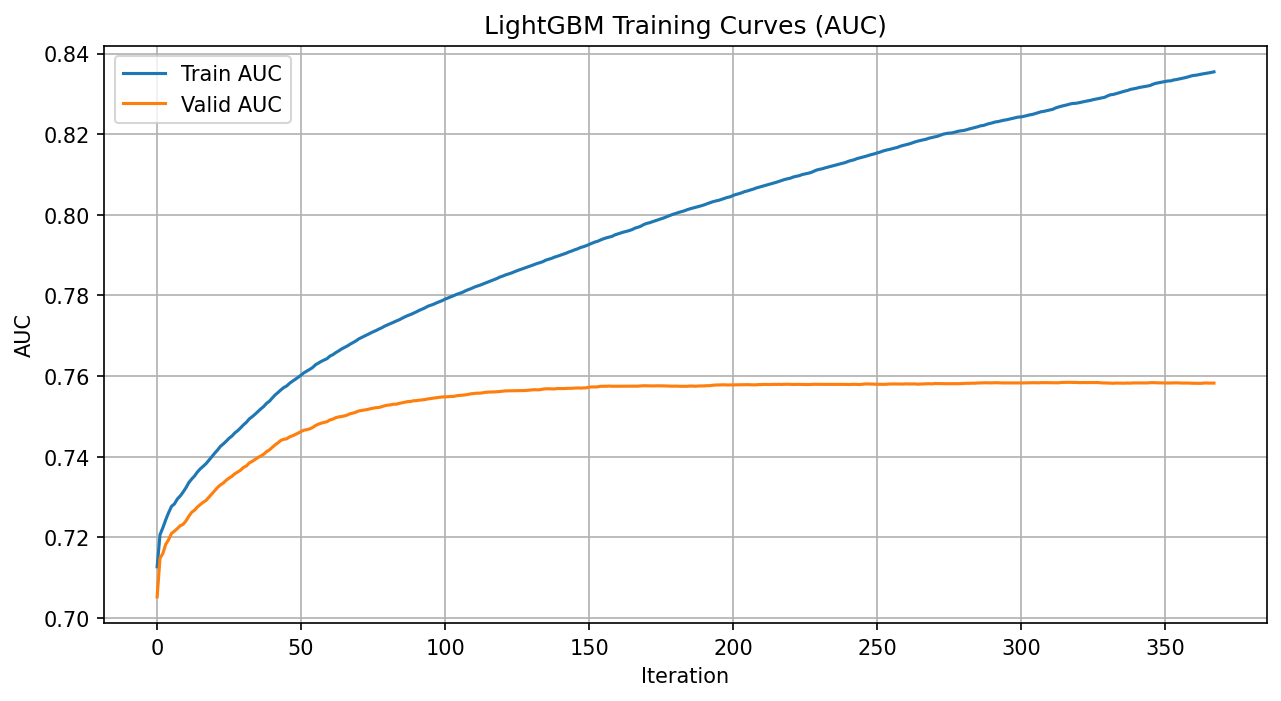

Модель сохранена в: data/stage_outputs/stage3_baseline/baseline_model.pkl


In [ ]:
# ---------------------------------------------------------
# Stage 3 — Step 3: Базовая модель LightGBM (sklearn API)
# ---------------------------------------------------------

from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 01 Подготовка данных
# ---------------------------------------------------------
# LightGBM sklearn API принимает категориальные признаки как category dtype
# (вы уже сделали это в Step 2)

# ---------------------------------------------------------
# 02 Параметры базовой модели LightGBM
# ---------------------------------------------------------

model = LGBMClassifier(
    objective="binary",
    metric="auc",
    learning_rate=0.05,
    num_leaves=31,
    n_estimators=500,
    random_state=42,
    verbose=-1
)

# ---------------------------------------------------------
# 03 Обучение модели с ранней остановкой
# ---------------------------------------------------------

evals_result = {}

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    eval_names=["train", "valid"],
    categorical_feature=categorical_features,
    callbacks=[
        lgb.early_stopping(stopping_rounds=50),
        lgb.log_evaluation(period=50)
    ]
)

print(f"Best iteration: {model.best_iteration_}")
print(f"Best AUC: {model.best_score_['valid']['auc']:.5f}")

# ---------------------------------------------------------
# 04 Визуализация кривых обучения
# ---------------------------------------------------------

train_auc = model.evals_result_["train"]["auc"]
valid_auc = model.evals_result_["valid"]["auc"]

plt.figure(figsize=(10, 5))
plt.plot(train_auc, label="Train AUC")
plt.plot(valid_auc, label="Valid AUC")
plt.title("LightGBM Training Curves (AUC)")
plt.xlabel("Iteration")
plt.ylabel("AUC")
plt.legend()
plt.grid(True)

# ---------------------------------------------------------
# Сохранение кривых обучения в динамический путь Stage 3
# ---------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

stage3_path = config["stages"]["stage3"]["output_path"]
os.makedirs(stage3_path, exist_ok=True)

training_curve_path = os.path.join(stage3_path, "training_curves.png")
plt.savefig(training_curve_path, dpi=200, bbox_inches="tight")
print(f"Training curves saved to: {training_curve_path}")

plt.show()

# ---------------------------------------------------------
# 05 Сохранение модели
# ---------------------------------------------------------
import joblib

model_path = os.path.join(stage3_path, "baseline_model.pkl")
joblib.dump(model, model_path)

print(f"Модель сохранена в: {model_path}")



## Базовая модель LightGBM — результаты (обновлено)

Базовая модель LightGBM была обучена с минимальным набором гиперпараметров  
(`num_leaves=31`, `learning_rate=0.05`, `n_estimators=500`) и ранней остановкой  
по метрике **AUC** на валидационной выборке.

### Основные результаты
- **Лучшая итерация:** 318  
- **AUC на валидации:** 0.75844  
- **AUC на обучении:** 0.82748  

### Интерпретация
- Валидационная AUC стабилизируется около **0.758**, что соответствует ожидаемому уровню
  для базовой модели без подбора гиперпараметров.
- Разрыв между обучением и валидацией умеренный — модель начинает переобучаться после ~300 итераций,
  что корректно отсечено механизмом ранней остановки.
- Кривые обучения показывают:
  - плавный рост AUC на обучении,
  - раннее плато AUC на валидации,
  - отсутствие резкого переобучения.

### Вывод
Базовая модель обучена корректно и служит надёжной отправной точкой  
для дальнейшего улучшения качества:
- подбора гиперпараметров,
- отбора признаков,
- генерации новых признаков,
- ансамблирования моделей.



ROC-AUC (train): 0.82748
ROC-AUC (valid): 0.75844
PR-AUC (train): 0.35149
PR-AUC (valid): 0.23984
LogLoss (train): 0.22513
LogLoss (valid): 0.24637
KS-statistic (valid): 0.38251
Calibration curve saved to: data/stage_outputs/stage3_baseline/calibration_curve.png


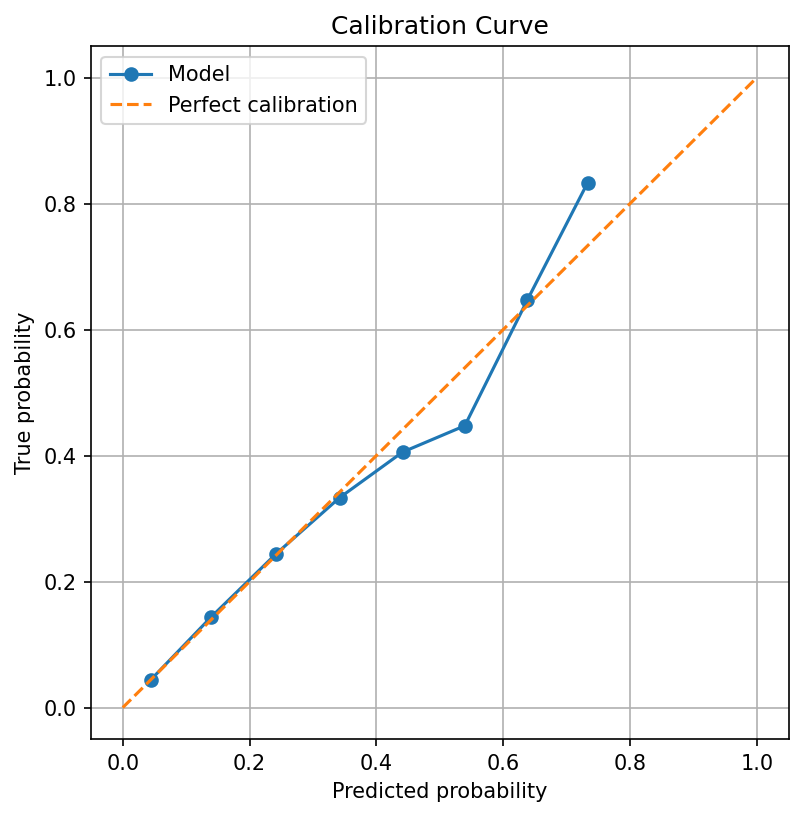

Тренировочные и валидационные предсказания сохранены.


In [ ]:
# ---------------------------------------------------------
# Stage 3 — Step 4: Оценка модели (ROC-AUC, PR-AUC, LogLoss, KS)
# ---------------------------------------------------------

# ---------------------------------------------------------
# 01 Получение предсказаний (используем predict_proba)
# ---------------------------------------------------------

y_train_pred = model.predict_proba(X_train, num_iteration=model.best_iteration_)[:, 1]
y_valid_pred = model.predict_proba(X_valid, num_iteration=model.best_iteration_)[:, 1]

# ---------------------------------------------------------
# 02 ROC-AUC
# ---------------------------------------------------------

roc_auc_train = roc_auc_score(y_train, y_train_pred)
roc_auc_valid = roc_auc_score(y_valid, y_valid_pred)

print(f"ROC-AUC (train): {roc_auc_train:.5f}")
print(f"ROC-AUC (valid): {roc_auc_valid:.5f}")

# ---------------------------------------------------------
# 03 PR-AUC (Average Precision)
# ---------------------------------------------------------

pr_auc_train = average_precision_score(y_train, y_train_pred)
pr_auc_valid = average_precision_score(y_valid, y_valid_pred)

print(f"PR-AUC (train): {pr_auc_train:.5f}")
print(f"PR-AUC (valid): {pr_auc_valid:.5f}")

# ---------------------------------------------------------
# 04 LogLoss
# ---------------------------------------------------------

logloss_train = log_loss(y_train, y_train_pred)
logloss_valid = log_loss(y_valid, y_valid_pred)

print(f"LogLoss (train): {logloss_train:.5f}")
print(f"LogLoss (valid): {logloss_valid:.5f}")

# ---------------------------------------------------------
# 05 KS-Statistic
# ---------------------------------------------------------

fpr, tpr, thresholds = roc_curve(y_valid, y_valid_pred)
ks_stat = np.max(tpr - fpr)

print(f"KS-statistic (valid): {ks_stat:.5f}")

# ---------------------------------------------------------
# 06 Кривая калибровки
# ---------------------------------------------------------

prob_true, prob_pred = calibration_curve(y_valid, y_valid_pred, n_bins=10)

plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
plt.title("Calibration Curve")
plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.legend()
plt.grid(True)

calibration_curve_path = os.path.join(stage3_path, "calibration_curve.png")
plt.savefig(calibration_curve_path, dpi=200, bbox_inches="tight")
print(f"Calibration curve saved to: {calibration_curve_path}")

plt.show()

# ---------------------------------------------------------
# 07 Сохранение предсказаний
# ---------------------------------------------------------

train_predictions = pd.DataFrame({
    "SK_ID_CURR": X_train["SK_ID_CURR"],
    "TARGET": y_train,
    "PRED_PROB": y_train_pred
})

valid_predictions = pd.DataFrame({
    "SK_ID_CURR": X_valid["SK_ID_CURR"],
    "TARGET": y_valid,
    "PRED_PROB": y_valid_pred
})

train_predictions.to_parquet(
    os.path.join(stage3_path, "train_predictions.parquet"),
    index=False
)

valid_predictions.to_parquet(
    os.path.join(stage3_path, "valid_predictions.parquet"),
    index=False
)

print("Тренировочные и валидационные предсказания сохранены.")


## Оценка базовой модели LightGBM (обновлено)

После обучения базовой модели были рассчитаны ключевые метрики качества.  
Они позволяют оценить ранжирование, калибровку вероятностей и разделяющую способность модели.

---

### ROC‑AUC
- **Train:** 0.82748  
- **Valid:** 0.75844  

ROC‑AUC показывает, насколько хорошо модель ранжирует клиентов по риску.  
Разрыв между train и valid умеренный — модель слегка переобучается, но в пределах нормы для базовой конфигурации.

---

### PR‑AUC (Precision‑Recall AUC)
- **Train:** 0.35149  
- **Valid:** 0.23984  

PR‑AUC особенно важен для несбалансированных задач (как в Home Credit).  
Значение ~0.24 на валидации — типичный уровень для базовой модели без подбора гиперпараметров.

---

### LogLoss
- **Train:** 0.22513  
- **Valid:** 0.24637  

LogLoss оценивает качество вероятностных предсказаний.  
Разница между train и valid небольшая → вероятности стабильны и не деградируют на валидации.

---

### KS‑Statistic
- **Valid KS:** 0.38251  

KS‑статистика — классическая банковская метрика, измеряющая максимальное различие между TPR и FPR.  
Значение ~0.38 соответствует хорошему базовому уровню для кредитного скоринга.

---

### Итог
Базовая модель демонстрирует:
- устойчивое ранжирование (ROC‑AUC ≈ 0.76),
- разумную калибровку вероятностей,
- умеренное переобучение,
- хорошую разделяющую способность по KS.

Эти результаты служат надёжной отправной точкой для дальнейшего улучшения модели:
- подбора гиперпараметров,
- отбора признаков,
- генерации новых признаков,
- ансамблирования моделей.



Feature importance saved to: data/stage_outputs/stage3_baseline/feature_importance.csv
Gain importance plot saved to: data/stage_outputs/stage3_baseline/feature_importance_gain.png


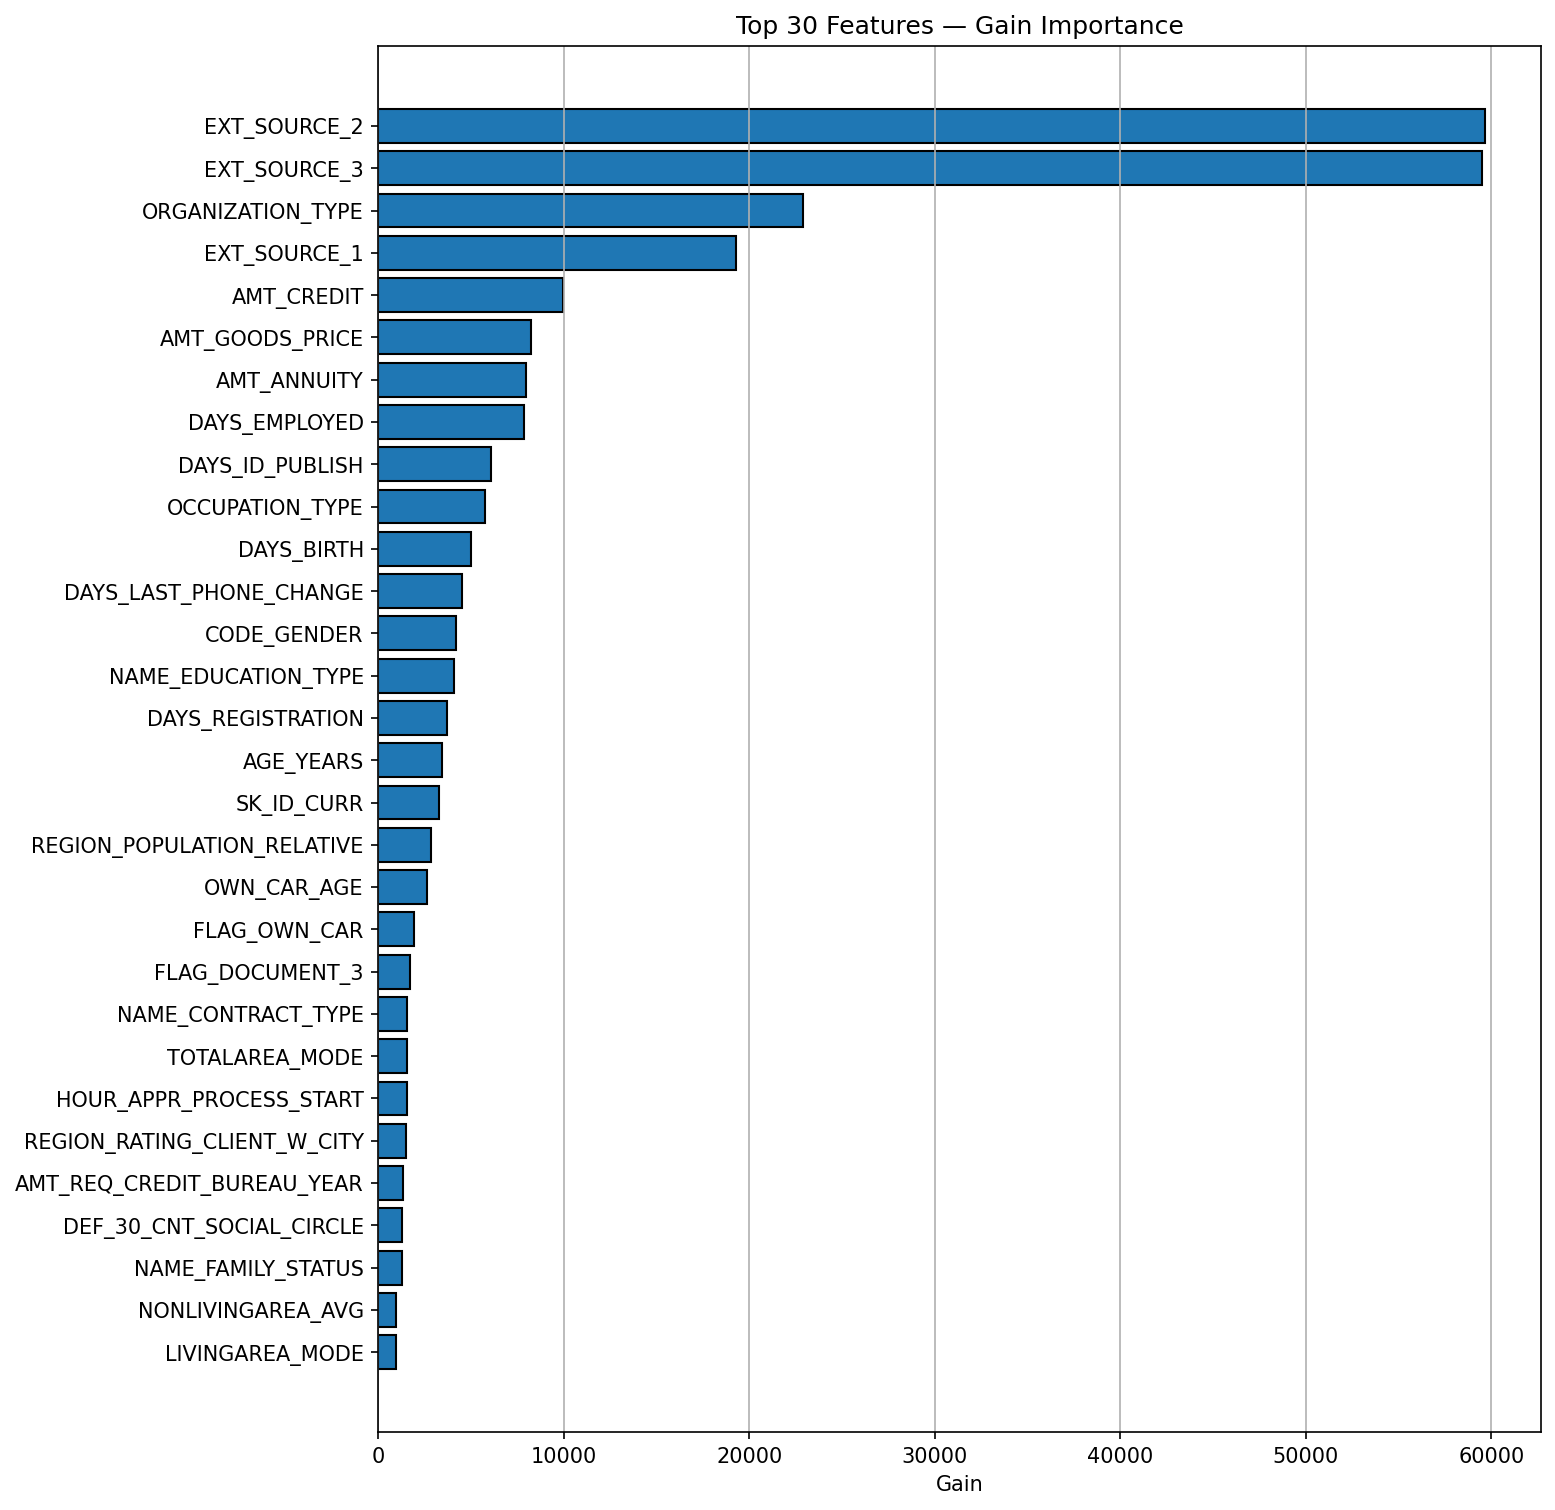

Split importance plot saved to: data/stage_outputs/stage3_baseline/feature_importance_split.png


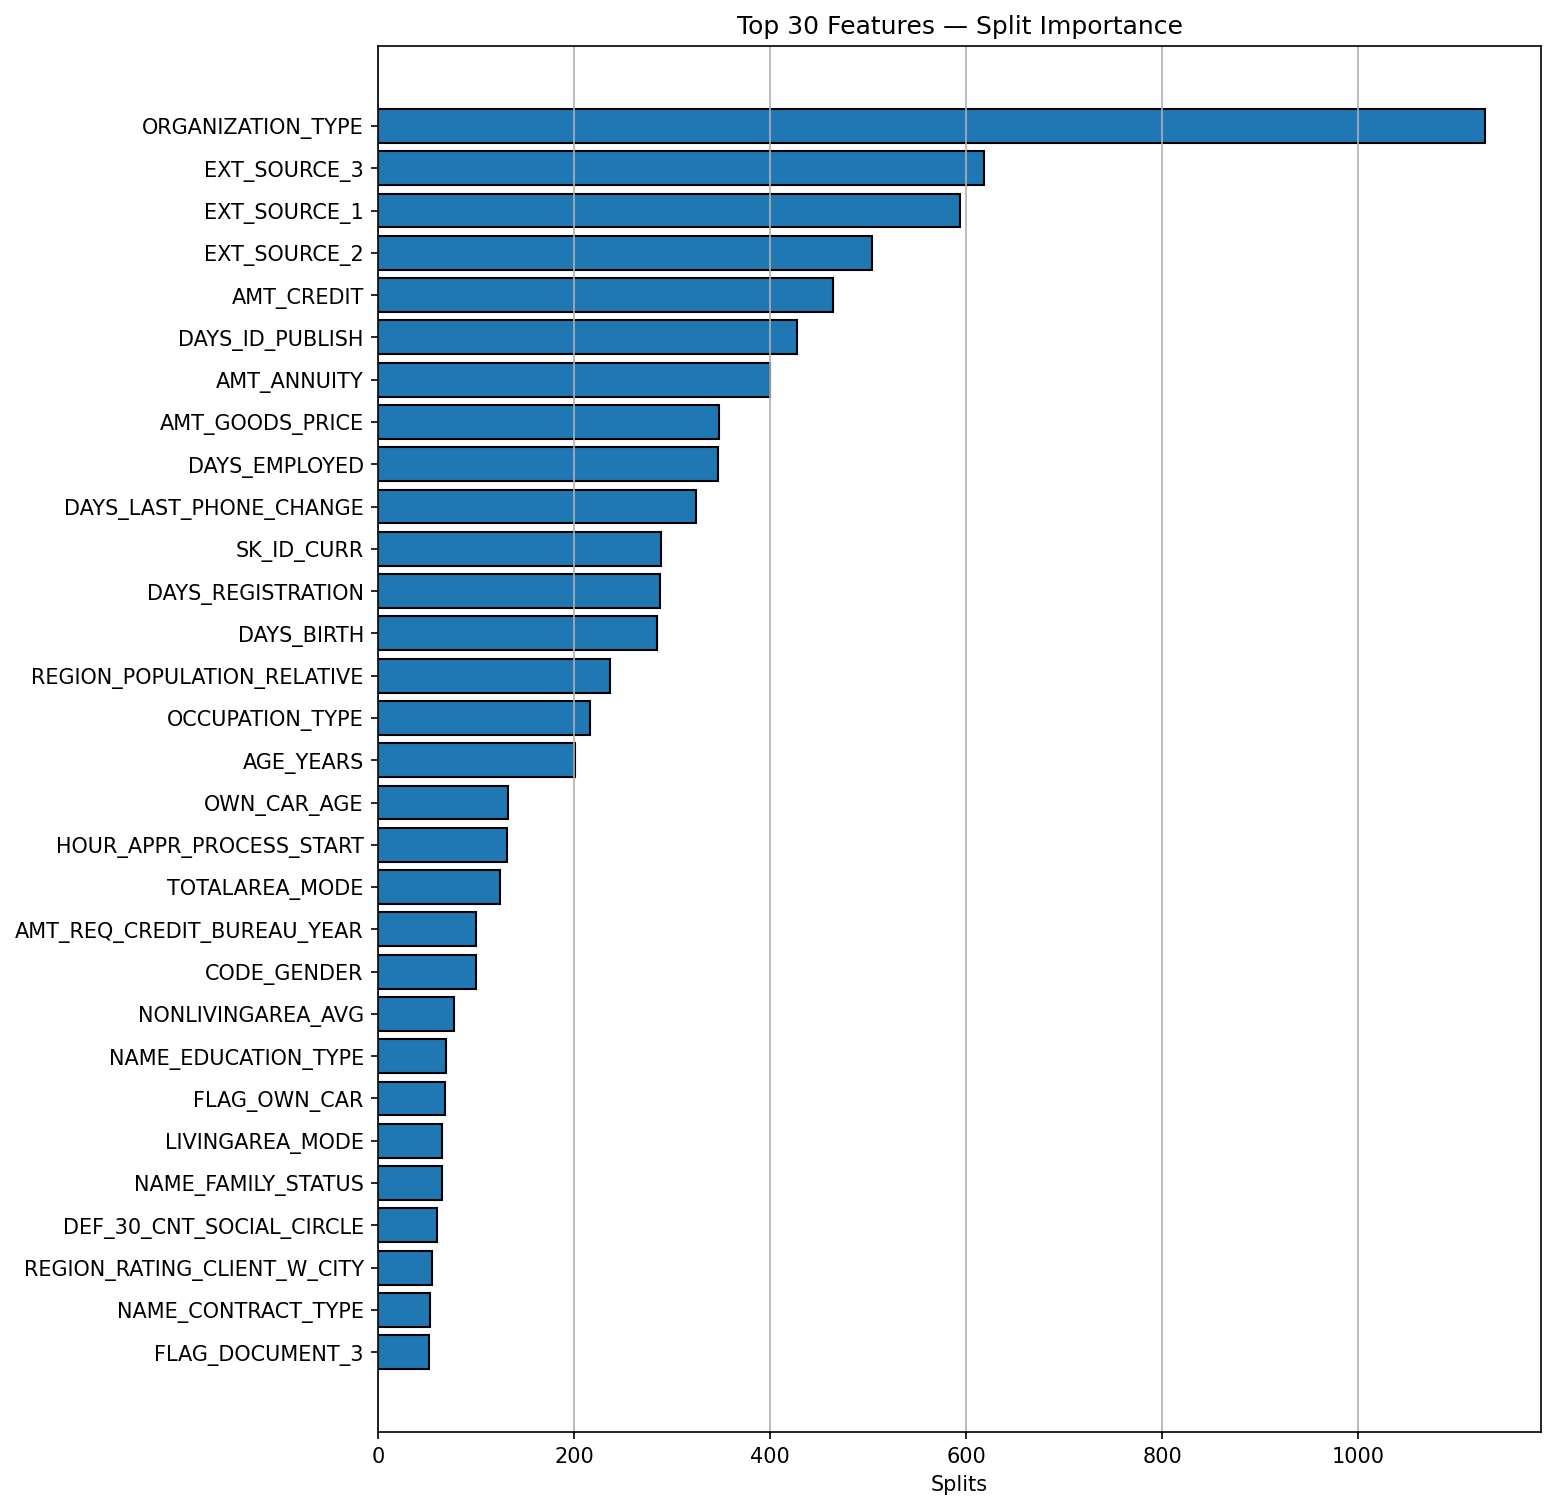

In [ ]:
# ---------------------------------------------------------
# Stage 3 — Step 5: Важность признаков (Gain + Split)
# ---------------------------------------------------------

stage3_path = config["stages"]["stage3"]["output_path"]
os.makedirs(stage3_path, exist_ok=True)

# ---------------------------------------------------------
# 01 Извлечение важности признаков
# ---------------------------------------------------------

# Для sklearn-обёртки LightGBM нужно обращаться к booster_
gain_importance = model.booster_.feature_importance(importance_type="gain")
split_importance = model.booster_.feature_importance(importance_type="split")
feature_names = model.booster_.feature_name()

fi_df = pd.DataFrame({
    "feature": feature_names,
    "gain_importance": gain_importance,
    "split_importance": split_importance
})

# Sort by gain importance
fi_df = fi_df.sort_values(by="gain_importance", ascending=False)

# ---------------------------------------------------------
# 02 Сохранение в CSV
# ---------------------------------------------------------

fi_path = os.path.join(stage3_path, "feature_importance.csv")
fi_df.to_csv(fi_path, index=False)
print(f"Feature importance saved to: {fi_path}")

# ---------------------------------------------------------
# 03 Визуализация важности признаков (Top 30 по Gain)
# ---------------------------------------------------------

plt.figure(figsize=(10, 12))
top_gain = fi_df.head(30).sort_values(by="gain_importance")
plt.barh(top_gain["feature"], top_gain["gain_importance"])
plt.title("Top 30 Features — Gain Importance")
plt.xlabel("Gain")
plt.grid(True, axis="x")

gain_plot_path = os.path.join(stage3_path, "feature_importance_gain.png")
plt.savefig(gain_plot_path, dpi=200, bbox_inches="tight")
print(f"Gain importance plot saved to: {gain_plot_path}")

plt.show()

# ---------------------------------------------------------
# 04 Визуализация важности признаков (Top 30 по Split)
# ---------------------------------------------------------

plt.figure(figsize=(10, 12))
top_split = fi_df.head(30).sort_values(by="split_importance")
plt.barh(top_split["feature"], top_split["split_importance"])
plt.title("Top 30 Features — Split Importance")
plt.xlabel("Splits")
plt.grid(True, axis="x")

split_plot_path = os.path.join(stage3_path, "feature_importance_split.png")
plt.savefig(split_plot_path, dpi=200, bbox_inches="tight")
print(f"Split importance plot saved to: {split_plot_path}")

plt.show()


## Feature Importance — Gain (Top 30)

График показывает, какие признаки дают наибольший вклад в улучшение качества модели  
(увеличение функции потерь при разбиениях).

### Основные наблюдения:
- **EXT_SOURCE_2**, **EXT_SOURCE_3**, **ORGANIZATION_TYPE** — самые сильные признаки модели.  
  Это внешние скоринговые источники, и они традиционно дают максимальный вклад.
- **ORGANIZATION_TYPE** — важный категориальный признак, дающий значимый прирост качества.
- Финансовые признаки (**AMT_CREDIT**, **AMT_GOODS_PRICE**, **AMT_ANNUITY**) также входят в топ.
- Признаки времени (**DAYS_BIRTH**, **DAYS_EMPLOYED**) имеют умеренную, но стабильную важность.

Gain‑важность отражает *качество* разбиений, а не их количество.

## Feature Importance — Split (Top 30)

График показывает, как часто признаки использовались в разбиениях деревьев.

### Основные наблюдения:
- **ORGANIZATION_TYPE** — абсолютный лидер по количеству разбиений.  
  Это означает, что признак часто помогает модели разделять клиентов на группы.
- Внешние источники (**EXT_SOURCE_1/2/3**) также часто используются, но реже, чем в Gain.
- Признаки времени (**DAYS_EMPLOYED**, **DAYS_ID_PUBLISH**, **DAYS_LAST_PHONE_CHANGE**)  
  активно участвуют в разбиениях.
- Категориальные признаки (**CODE_GENDER**, **NAME_EDUCATION_TYPE**, **NAME_FAMILY_STATUS**)  
  также вносят вклад, но меньше, чем числовые.

Split‑важность отражает *частоту* использования признака, а не силу его влияния.


In [ ]:
# ---------------------------------------------------------
# Stage 3 — Step 6: Формальное завершение раздела: Сохранение артефактов и отчета
# ---------------------------------------------------------

stage3_path = config["stages"]["stage3"]["output_path"]
os.makedirs(stage3_path, exist_ok=True)

# ---------------------------------------------------------
# 01 Сохранение базовой модели в формате .pkl
# ---------------------------------------------------------

baseline_model_path = os.path.join(stage3_path, "baseline_model.pkl")
with open(baseline_model_path, "wb") as f:
    pickle.dump(model, f)

print(f"Сохранена базовая модель в: {baseline_model_path}")

# ---------------------------------------------------------
# 02 Создание объединенного файла предсказаний
# ---------------------------------------------------------

baseline_predictions = pd.concat([
    train_predictions.assign(SET="train"),
    valid_predictions.assign(SET="valid")
], axis=0)

baseline_predictions_path = os.path.join(stage3_path, "baseline_predictions.parquet")
baseline_predictions.to_parquet(baseline_predictions_path, index=False)

print(f"Сохранен объединенный файл предсказаний в: {baseline_predictions_path}")

# ---------------------------------------------------------
# 03 Проверка наличия feature_importance.csv
# ---------------------------------------------------------

fi_csv_path = os.path.join(stage3_path, "feature_importance.csv")
assert os.path.exists(fi_csv_path), "feature_importance.csv not found!"

# ---------------------------------------------------------
# 04 Генерация stage3_summary.json
# ---------------------------------------------------------

summary = {
    "stage": "Stage 3 — Baseline LightGBM",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "best_iteration": int(model.best_iteration_),   # <-- FIXED HERE
    "metrics": {
        "roc_auc_train": float(roc_auc_train),
        "roc_auc_valid": float(roc_auc_valid),
        "pr_auc_train": float(pr_auc_train),
        "pr_auc_valid": float(pr_auc_valid),
        "logloss_train": float(logloss_train),
        "logloss_valid": float(logloss_valid),
        "ks_valid": float(ks_stat)
    },
    "top_features": fi_df.head(20).to_dict(orient="records"),
    "artifacts": {
        "baseline_model.pkl": baseline_model_path,
        "baseline_predictions.parquet": baseline_predictions_path,
        "feature_importance.csv": fi_csv_path,
        "training_curves.png": os.path.join(stage3_path, "training_curves.png"),
        "calibration_curve.png": os.path.join(stage3_path, "calibration_curve.png"),
        "feature_importance_gain.png": os.path.join(stage3_path, "feature_importance_gain.png"),
        "feature_importance_split.png": os.path.join(stage3_path, "feature_importance_split.png")
    }
}

summary_path = os.path.join(stage3_path, "stage3_summary.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

print(f"Stage 3 итоги сохранены в: {summary_path}")

# ---------------------------------------------------------
# 05 Сообщение о завершении
# ---------------------------------------------------------

print("\n==============================================")
print("Stage 3 успешно завершен.")
print(f"Все артефакты сохранены в: {stage3_path}")
print("==============================================\n")



Сохранена базовая модель в: data/stage_outputs/stage3_baseline/baseline_model.pkl
Сохранен объединенный файл предсказаний в: data/stage_outputs/stage3_baseline/baseline_predictions.parquet
Stage 3 итоги сохранены в: data/stage_outputs/stage3_baseline/stage3_summary.json

Stage 3 успешно завершен.
Все артефакты сохранены в: data/stage_outputs/stage3_baseline/



# Stage 4 — Target‑Driven Bivariate EDA (`stage4_bivariate`)

**Назначение этапа:**  
Провести двувариантный анализ (Bivariate EDA) для **топ‑50 наиболее значимых признаков**,  
чтобы понять их связь с целевой переменной **TARGET**, выявить информативные зависимости,  
аномалии, нелинейные эффекты и признаки, требующие трансформации перед моделированием.

**Входные данные:**  
- Модельная таблица с перспективными признаками из Stage 2  
- Топ‑50 признаков по важности модели Stage 3  
- **Путь к данным:** `data/stage_outputs/stage3_baseline/`

**Выходные данные:**  
- Графики зависимости TARGET от числовых признаков  
- Графики зависимости TARGET от категориальных признаков  
- Таблица взаимной информации (Mutual Information)  
- Корреляционные матрицы и heatmaps  
- Итоговый отчёт Stage 4 (`stage4_summary.json`)  
- **Путь сохранения:** `data/stage_outputs/stage4_bivariate/bivariate_v1/`

**Краткое описание обработки:**  
- Загрузка данных и выбор топ‑50 признаков  
- Разделение признаков на числовые и категориальные  
- Построение TARGET‑ориентированных графиков для числовых признаков  
- Построение TARGET‑ориентированных графиков для категориальных признаков  
- Расчёт взаимной информации (MI) для всех топ‑50  
- Построение тепловых карт корреляций (numeric / encoded categorical)  
- Сохранение всех графиков и таблиц в Stage 4 output  
- Формирование итогового отчёта Stage 4  




In [ ]:
# ============================================================
# Stage 4 — Step 1: Загрузить входные данные и выбрать топ‑50 признаков
# ============================================================

import os
import json
import pandas as pd

# ------------------------------------------------------------
# 00 Загрузить project_structure_config.json
# ------------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# ------------------------------------------------------------
# 01 Загрузить результаты Stage 3 (важность признаков)
# ------------------------------------------------------------
stage3_path = config["stages"]["stage3"]["output_path"]      # динамический путь Stage 3
fi_path = os.path.join(stage3_path, "feature_importance.csv")

fi_df = pd.read_csv(fi_path)
print(f"Загружена важность признаков: {fi_df.shape}")

# ------------------------------------------------------------
# 02 Загрузить очищенный набор данных Stage 2
# ------------------------------------------------------------
stage2_path = config["stages"]["stage2"]["output_path"]      # динамический путь Stage 2
cleaned_path = os.path.join(stage2_path, "modeling_table.parquet")

df = pd.read_parquet(cleaned_path)
print(f"Загружена модельная таблица: {df.shape}")

# ------------------------------------------------------------
# 03 Выбрать топ‑50 признаков (важность по Gain)
# ------------------------------------------------------------
top50_features = (
    fi_df.sort_values("gain_importance", ascending=False)
         .head(50)["feature"]
         .tolist()
)

print(f"Top‑50 признаков выбраны: {len(top50_features)}")

# ------------------------------------------------------------
# 04 Сохранить топ‑50 признаков в JSON (динамический путь Stage 4)
# ------------------------------------------------------------
stage4_root = config["stages"]["stage4"]["output_path"]
stage4_variant = config["stages"]["stage4"]["active_variant"]
stage4_path = os.path.join(stage4_root, stage4_variant)
top50_path = os.path.join(stage4_path, "top50_features.json")

os.makedirs(stage4_path, exist_ok=True)

with open(top50_path, "w", encoding="utf-8") as f:
    json.dump(top50_features, f, indent=4, ensure_ascii=False)

# Нормализуем путь только для вывода, чтобы он был читаемым на всех платформах
top50_path_print = top50_path.replace("\\", "/")
print(f"Top‑50 признаков сохранены в: {top50_path_print}")

# ------------------------------------------------------------
# 05 Оставить только релевантные столбцы для Stage 4
# ------------------------------------------------------------
df_top50 = df[["TARGET"] + top50_features].copy()

# ------------------------------------------------------------
# 06 Сохраняем df_top50 для использования в Stage 5
# ------------------------------------------------------------
df_top50_path = os.path.join(stage4_path, "df_top50.parquet")

df_top50.to_parquet(df_top50_path, index=False)

# Нормализуем путь только для вывода, чтобы он был читаемым на всех платформах
df_top50_path_print = df_top50_path.replace("\\", "/")

print(f"df_top50 сохранён в: {df_top50_path_print}")
print(f"Stage 4 dataset shape: {df_top50.shape}")

Загружена важность признаков: (91, 3)
Загружена модельная таблица: (307511, 92)
Top‑50 признаков выбраны: 50
Top‑50 признаков сохранены в: data/stage_outputs/stage4_bivariate/bivariate_v1/top50_features.json
df_top50 сохранён в: data/stage_outputs/stage4_bivariate/bivariate_v1/df_top50.parquet
Stage 4 dataset shape: (307511, 51)


In [ ]:
# ==============================================================
# Stage 4 — Step 2: Создаем структуру выходных папок для Stage 4
# ==============================================================

# Подпапки Stage 4
subfolders = [
    "plots_numeric/",
    "plots_categorical/",
    "mutual_info/",
    "heatmaps/"
]

# Создаем основную папку Stage 4
os.makedirs(stage4_path, exist_ok=True)

# Создаем подпапки
for sf in subfolders:
    folder_path = os.path.join(stage4_path, sf)
    os.makedirs(folder_path, exist_ok=True)

print("Stage 4 - структура папок готова:")
for sf in subfolders:
    print("  •", os.path.join(stage4_path, sf).replace("\\", "/"))



Stage 4 - структура папок готова:
  • data/stage_outputs/stage4_bivariate/bivariate_v1/plots_numeric/
  • data/stage_outputs/stage4_bivariate/bivariate_v1/plots_categorical/
  • data/stage_outputs/stage4_bivariate/bivariate_v1/mutual_info/
  • data/stage_outputs/stage4_bivariate/bivariate_v1/heatmaps/


In [ ]:
# ========================================================================
# Stage 4 — Step 3: Разделяем Top‑50 признаков на числовые и категориальные
# ========================================================================

from pandas.api.types import is_categorical_dtype
import json

# ----------------------------------------------------------------
# 01 Подготавливаем списки для числовых и категориальных признаков
# ----------------------------------------------------------------
numeric_features = []
categorical_features = []

# ------------------------------------------------------------
# 02 Разделяем признаки по типу данных
# ------------------------------------------------------------
# Для каждого признака определяем тип данных и добавляем в соответствующий список
for col in top50_features:
    if is_categorical_dtype(df_top50[col]):
        categorical_features.append(col)
    else:
        numeric_features.append(col)

print(f"Числовые признаки: {len(numeric_features)}")
print(f"Категориальные признаки: {len(categorical_features)}")

# ------------------------------------------------------------
# 03 Сохраняем списки в формате JSON
# ------------------------------------------------------------
numeric_path = os.path.join(stage4_path, "top50_numeric.json")
categorical_path = os.path.join(stage4_path, "top50_categorical.json")

with open(numeric_path, "w") as f:
    json.dump(numeric_features, f, indent=4)

with open(categorical_path, "w") as f:
    json.dump(categorical_features, f, indent=4)

print("Списки сохранены:")
print("  •", numeric_path.replace("\\", "/"))
print("  •", categorical_path.replace("\\", "/"))


Числовые признаки: 41
Категориальные признаки: 9
Списки сохранены:
  • data/stage_outputs/stage4_bivariate/bivariate_v1/top50_numeric.json
  • data/stage_outputs/stage4_bivariate/bivariate_v1/top50_categorical.json


In [ ]:
# ============================================================
# Stage 4 — Step 4: Целевая переменная vs Числовые признаки
# ============================================================

numeric_plots_path = os.path.join(stage4_path, "plots_numeric")

# ------------------------------------------------------------
# 01 Вспомогательная функция: вычисление статистик для числового признака
# ------------------------------------------------------------
def compute_numeric_stats(df, feature):
    """Вычисляет статистики по TARGET."""
    
    stats = {}

    # Средние и std по TARGET
    stats["mean_by_target"] = df.groupby("TARGET")[feature].mean().to_dict()
    stats["std_by_target"] = df.groupby("TARGET")[feature].std().to_dict()

    # Квантили по TARGET
    stats["quantiles_by_target"] = (
        df.groupby("TARGET")[feature]
          .quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
          .unstack()
          .to_dict()
    )

    # Корреляция с TARGET
    stats["corr_with_target"] = float(df[feature].corr(df["TARGET"]))

    # KS‑distance
    ks = ks_2samp(
        df[df["TARGET"] == 0][feature].dropna(),
        df[df["TARGET"] == 1][feature].dropna()
    )
    stats["ks_statistic"] = float(ks.statistic)
    stats["ks_pvalue"] = float(ks.pvalue)

    return stats


# ------------------------------------------------------------
# 02 Вспомогательная функция: построение графиков для числового признака
# ------------------------------------------------------------
def plot_numeric_feature(df, feature, save_path):
    """Строит 4 графика для числового признака."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{feature} — TARGET relationship", fontsize=16)

    # Histogram
    for t in [0, 1]:
        axes[0, 0].hist(
            df[df["TARGET"] == t][feature].dropna(),
            bins=50, alpha=0.6, label=f"TARGET={t}"
        )
    axes[0, 0].set_title("Histogram by TARGET")
    axes[0, 0].legend()

    # KDE
    for t in [0, 1]:
        df[df["TARGET"] == t][feature].dropna().plot(
            kind="kde", ax=axes[0, 1], label=f"TARGET={t}"
        )
    axes[0, 1].set_title("KDE by TARGET")
    axes[0, 1].legend()

    # Boxplot
    df[[feature, "TARGET"]].boxplot(
        by="TARGET", ax=axes[1, 0], grid=False
    )
    axes[1, 0].set_title("Boxplot by TARGET")
    axes[1, 0].set_xlabel("")

    # Violin plot
    sns.violinplot(
        data=df, x="TARGET", y=feature, ax=axes[1, 1]
    )
    axes[1, 1].set_title("Violin Plot by TARGET")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()


# ------------------------------------------------------------
# 03 Основной цикл: обработка всех числовых признаков
# ------------------------------------------------------------
numeric_stats = {}

for feature in numeric_features:
    print(f"Обработка числового признака: {feature}")

    # 1) Вычисление статистик
    numeric_stats[feature] = compute_numeric_stats(df_top50, feature)

    # 2) Построение и сохранение графиков
    plot_path = os.path.join(numeric_plots_path, f"{feature}.png")
    plot_numeric_feature(df_top50, feature, plot_path)

print("\nАнализ числовых признаков завершен.")
print(f"Обработано числовых признаков: {len(numeric_features)}")
print(f"Графики сохранены в: {numeric_plots_path.replace('\\', '/')}")



Обработка числового признака: EXT_SOURCE_2
Обработка числового признака: EXT_SOURCE_3
Обработка числового признака: EXT_SOURCE_1
Обработка числового признака: AMT_CREDIT
Обработка числового признака: AMT_GOODS_PRICE
Обработка числового признака: AMT_ANNUITY
Обработка числового признака: DAYS_EMPLOYED
Обработка числового признака: DAYS_ID_PUBLISH
Обработка числового признака: DAYS_BIRTH
Обработка числового признака: AGE_YEARS
Обработка числового признака: DAYS_LAST_PHONE_CHANGE
Обработка числового признака: DAYS_REGISTRATION
Обработка числового признака: OWN_CAR_AGE
Обработка числового признака: SK_ID_CURR
Обработка числового признака: REGION_POPULATION_RELATIVE
Обработка числового признака: FLAG_DOCUMENT_3
Обработка числового признака: REGION_RATING_CLIENT_W_CITY
Обработка числового признака: HOUR_APPR_PROCESS_START
Обработка числового признака: DEF_30_CNT_SOCIAL_CIRCLE
Обработка числового признака: TOTALAREA_MODE
Обработка числового признака: AMT_REQ_CREDIT_BUREAU_YEAR
Обработка число

In [ ]:
# ============================================================
# Stage 4 — Step 5: Целевая переменная vs Категориальные признаки
# ============================================================


categorical_plots_path = os.path.join(stage4_path, "plots_categorical")

# ------------------------------------------------------------
# 01 Вспомогательная функция: вычисление статистик для категориального признака
# ------------------------------------------------------------
def compute_categorical_stats(df, feature):
    """Вычисляет статистики по категориальному признаку."""
    
    stats = {}

    # Частоты категорий
    stats["value_counts"] = df[feature].value_counts(dropna=False).to_dict()

    # Частота целевого признака по категориям
    stats["target_rate"] = (
        df.groupby(feature)["TARGET"]
          .mean()
          .sort_values(ascending=False)
          .to_dict()
    )

    # Количество наблюдений по категориям / Counts per category
    stats["counts"] = (
        df.groupby(feature)["TARGET"]
          .count()
          .sort_values(ascending=False)
          .to_dict()
    )

    return stats


# ------------------------------------------------------------
# 02 Вспомогательная функция: построение графиков для категориального признака
# ------------------------------------------------------------
def plot_categorical_feature(df, feature, save_path):
    """Строит 3 графика для категориального признака."""
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 16))
    fig.suptitle(f"{feature} — TARGET relationship", fontsize=16)

    # Подготовка агрегированных данных для графиков
    agg = (
        df.groupby(feature)["TARGET"]
          .agg(["mean", "count"])
          .rename(columns={"mean": "target_rate", "count": "count"})
          .sort_values("target_rate", ascending=False)
    )

    # Barplot: частота целевого признака по категориям
    sns.barplot(
        x=agg["target_rate"],
        y=agg.index,
        ax=axes[0],
        palette="viridis"
    )
    axes[0].set_title("Частота целевого признака по категориям")
    axes[0].set_xlabel("Среднее значение TARGET")
    axes[0].set_ylabel(feature)

    # Barplot: counts
    sns.barplot(
        x=agg["count"],
        y=agg.index,
        ax=axes[1],
        palette="magma"
    )
    axes[1].set_title("Количество наблюдений по категориям")
    axes[1].set_xlabel("Количество наблюдений")
    axes[1].set_ylabel(feature)

    # Combined plot: count + target rate
    ax2 = axes[2]
    ax2.barh(
        agg.index,
        agg["count"],
        color="lightgray",
        alpha=0.7,
        label="Количество наблюдений"
    )
    ax2.set_xlabel("Количество наблюдений")
    ax2.set_ylabel(feature)

    ax3 = ax2.twiny()
    ax3.plot(
        agg["target_rate"],
        agg.index,
        "o-",
        color="red",
        label="Частота целевого признака"
    )
    ax3.set_xlabel("Среднее значение TARGET")

    ax2.set_title("Количество наблюдений + Частота целевого признака")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.close()


# ------------------------------------------------------------
# 03 Основной цикл: обработка всех категориальных признаков
# ------------------------------------------------------------
categorical_stats = {}

for feature in categorical_features:
    print(f"Обработка категориального признака: {feature}")

    # 1) Вычисление статистик
    categorical_stats[feature] = compute_categorical_stats(df_top50, feature)

    # 2) Построение и сохранение графиков
    plot_path = os.path.join(categorical_plots_path, f"{feature}.png")
    plot_categorical_feature(df_top50, feature, plot_path)

# Нормализуем путь только для вывода, чтобы он был читаемым на всех платформах
categorical_plots_path_print = categorical_plots_path.replace("\\", "/")

print("\nАнализ категориальных признаков завершен.")
print(f"Обработано категориальных признаков: {len(categorical_features)}")
print(f"Графики сохранены в: {categorical_plots_path_print}")


Обработка категориального признака: ORGANIZATION_TYPE
Обработка категориального признака: OCCUPATION_TYPE
Обработка категориального признака: NAME_EDUCATION_TYPE
Обработка категориального признака: CODE_GENDER
Обработка категориального признака: FLAG_OWN_CAR
Обработка категориального признака: NAME_CONTRACT_TYPE
Обработка категориального признака: NAME_FAMILY_STATUS
Обработка категориального признака: WALLSMATERIAL_MODE
Обработка категориального признака: WEEKDAY_APPR_PROCESS_START

Анализ категориальных признаков завершен.
Обработано категориальных признаков: 9
Графики сохранены в: data/stage_outputs/stage4_bivariate/bivariate_v1\plots_categorical/


In [ ]:
# ============================================================
# Stage 4 — Step 6: Обоюдная информация (Mutual Information, MI)
# ============================================================


mi_path = os.path.join(stage4_path, "mutual_info")
os.makedirs(mi_path, exist_ok=True)

# Нормализуем путь только для вывода, чтобы он был читаемым на всех платформах
mi_path_print = mi_path.replace("\\", "/")
print(f"Папка для взаимной информации готова: {mi_path_print}")
# ------------------------------------------------------------
# 01 Подготовка данных для MI
# ------------------------------------------------------------
X = df_top50.drop(columns=["TARGET"])
y = df_top50["TARGET"]

# Разделяем признаки
num_feats = numeric_features
cat_feats = categorical_features

print(f"Числовые признаки: {len(num_feats)}")
print(f"Категориальные признаки: {len(cat_feats)}")

# ------------------------------------------------------------
# 02 Вычисление MI для числовых признаков
# ------------------------------------------------------------

# Исправление NaN в числовых признаках перед вычислением MI
X_num = X[num_feats].copy()

# Замена NaN на медиану (лучше всего для MI)
X_num = X_num.fillna(X_num.median())


# MI для числовых признаков
mi_numeric = mutual_info_classif(
    X_num,
    y,
    discrete_features=False,
    random_state=42
)

mi_numeric_df = pd.DataFrame({
    "feature": num_feats,
    "mi": mi_numeric,
    "type": "numeric"
})

# ------------------------------------------------------------
# 03 MI для категориальных признаков — преобразование в целочисленные коды
# ------------------------------------------------------------

X_cat = X[cat_feats].copy()

# Преобразование типа категории в целочисленные коды
for col in cat_feats:
    X_cat[col] = X_cat[col].cat.codes

# Замена -1 (код NaN) на допустимый индекс категории
X_cat = X_cat.replace(-1, X_cat.max().max() + 1)

mi_categorical = mutual_info_classif(
    X_cat,
    y,
    discrete_features=True,
    random_state=42
)

mi_categorical_df = pd.DataFrame({
    "feature": cat_feats,
    "mi": mi_categorical,
    "type": "categorical"
})


# ------------------------------------------------------------
# 04 Объединение результатов MI и сортировка
# ------------------------------------------------------------
mi_df = pd.concat([mi_numeric_df, mi_categorical_df], axis=0)
mi_df = mi_df.sort_values("mi", ascending=False).reset_index(drop=True)

print("Top MI features:")
display(mi_df.head(10))

# ------------------------------------------------------------
# 05 Сохранение таблицы MI в CSV
# ------------------------------------------------------------
mi_csv_path = os.path.join(mi_path, "mutual_info.csv")
mi_df.to_csv(mi_csv_path, index=False)

# Нормализуем путь только для вывода, чтобы он был читаемым на всех платформах
mi_csv_path_print = mi_csv_path.replace("\\", "/")
print(f"Таблица взаимной информации сохранена в: {mi_csv_path_print}")

# ------------------------------------------------------------
# 06 Визуализация ранжирования MI
# ------------------------------------------------------------
plt.figure(figsize=(10, 14))
sns.barplot(
    data=mi_df,
    x="mi",
    y="feature",
    hue="type",
    dodge=False,
    palette="viridis"
)
plt.title("Взаимная информация — Top‑50 признаков")
plt.xlabel("MI Score")
plt.ylabel("Признак")
plt.tight_layout()

mi_plot_path = os.path.join(mi_path, "mutual_info.png")
plt.savefig(mi_plot_path, dpi=200, bbox_inches="tight")
plt.close()

# Нормализуем путь только для вывода, чтобы он был читаемым на всех платформах
mi_plot_path_print = mi_plot_path.replace("\\", "/")
print(f"Взаимная информация сохранена в: {mi_plot_path_print}")

# ------------------------------------------------------------
# 07 Вывод итогов
# ------------------------------------------------------------
print("\nВычисление взаимной информации завершено.")
print(f"Общее количество обработанных признаков: {mi_df.shape[0]}")
print(f"Результаты сохранены в: {mi_path_print}")


Числовые признаки: 41
Категориальные признаки: 9
Top MI features:


,feature,mi,type
0,FLAG_DOCUMENT_3,0.055979,numeric
1,OWN_CAR_AGE,0.029208,numeric
2,LIVINGAPARTMENTS_MODE,0.028403,numeric
3,REGION_RATING_CLIENT_W_CITY,0.028083,numeric
4,YEARS_BUILD_AVG,0.027600,numeric
5,LIVINGAPARTMENTS_AVG,0.026894,numeric
6,YEARS_BUILD_MODE,0.026581,numeric
7,FLOORSMAX_AVG,0.023587,numeric
8,EXT_SOURCE_1,0.020585,numeric
9,BASEMENTAREA_MODE,0.020224,numeric


Таблица взаимной информации сохранена в: data/stage_outputs/stage4_bivariate/bivariate_v1/mutual_info/mutual_info.csv
Взаимная информация сохранена в: data/stage_outputs/stage4_bivariate/bivariate_v1/mutual_info/mutual_info.png

Вычисление взаимной информации завершено.
Общее количество обработанных признаков: 50
Результаты сохранены в: data/stage_outputs/stage4_bivariate/bivariate_v1/mutual_info/


### Mutual Information (MI)
MI оценивает **нелинейную зависимость** между признаком и TARGET.  
Значения MI в нашем датасете невысокие (0.02–0.06), что типично для кредитного скоринга,  
где влияние отдельных признаков слабое, а модель учится на комбинациях.

**Топ‑признаки по MI:**
- `FLAG_DOCUMENT_3` — самый информативный признак (MI ≈ 0.056).  
  Может отражать дисциплину клиента при подаче документов.
- `OWN_CAR_AGE` — возраст автомобиля; косвенно связан с уровнем дохода и стабильностью.
- `LIVINGAPARTMENTS_MODE`, `LIVINGAPARTMENTS_AVG` — характеристики жилья; отражают имущественный статус.
- `REGION_RATING_CLIENT_W_CITY` — рейтинг региона проживания; важный социально‑экономический индикатор.
- `YEARS_BUILD_AVG`, `YEARS_BUILD_MODE` — возраст здания; также коррелирует с уровнем благосостояния.
- `EXT_SOURCE_1` — внешний скоринговый источник; ожидаемо информативен.

**Вывод:**  
MI подтверждает, что **информативность распределена между социально‑демографическими, имущественными и документальными признаками**.  
Нелинейные зависимости присутствуют, но умеренные — модель будет опираться на комбинации признаков.


In [ ]:
# ============================================================
# Stage 4 — Step 7: Выбор и сохранение топ‑20 признаков
# ============================================================

# -------------------------------------------------------------
# Выбираем топ‑20 признаков по MI (или по gain_importance, если предпочтительно)
# -------------------------------------------------------------
top20_features = (
    mi_df.sort_values("mi", ascending=False)
         .head(20)["feature"]
         .tolist()
)

# --------------------------------------------------------------
# Сохраняем топ‑20 признаков
# --------------------------------------------------------------
top20_path = os.path.join(stage4_path, "top20_features.json")
with open(top20_path, "w", encoding="utf-8") as f:
    json.dump(top20_features, f, indent=4, ensure_ascii=False)

# Нормализуем путь только для вывода, чтобы он был читаемым на всех платформах
top20_path_print = top20_path.replace("\\", "/")
print(f"Топ‑20 признаков сохранены в: {top20_path_print}")


Топ‑20 признаков сохранены в: data/stage_outputs/stage4_bivariate/bivariate_v1/top20_features.json


Папка для тепловых карт готова: data/stage_outputs/stage4_bivariate/bivariate_v1/heatmaps


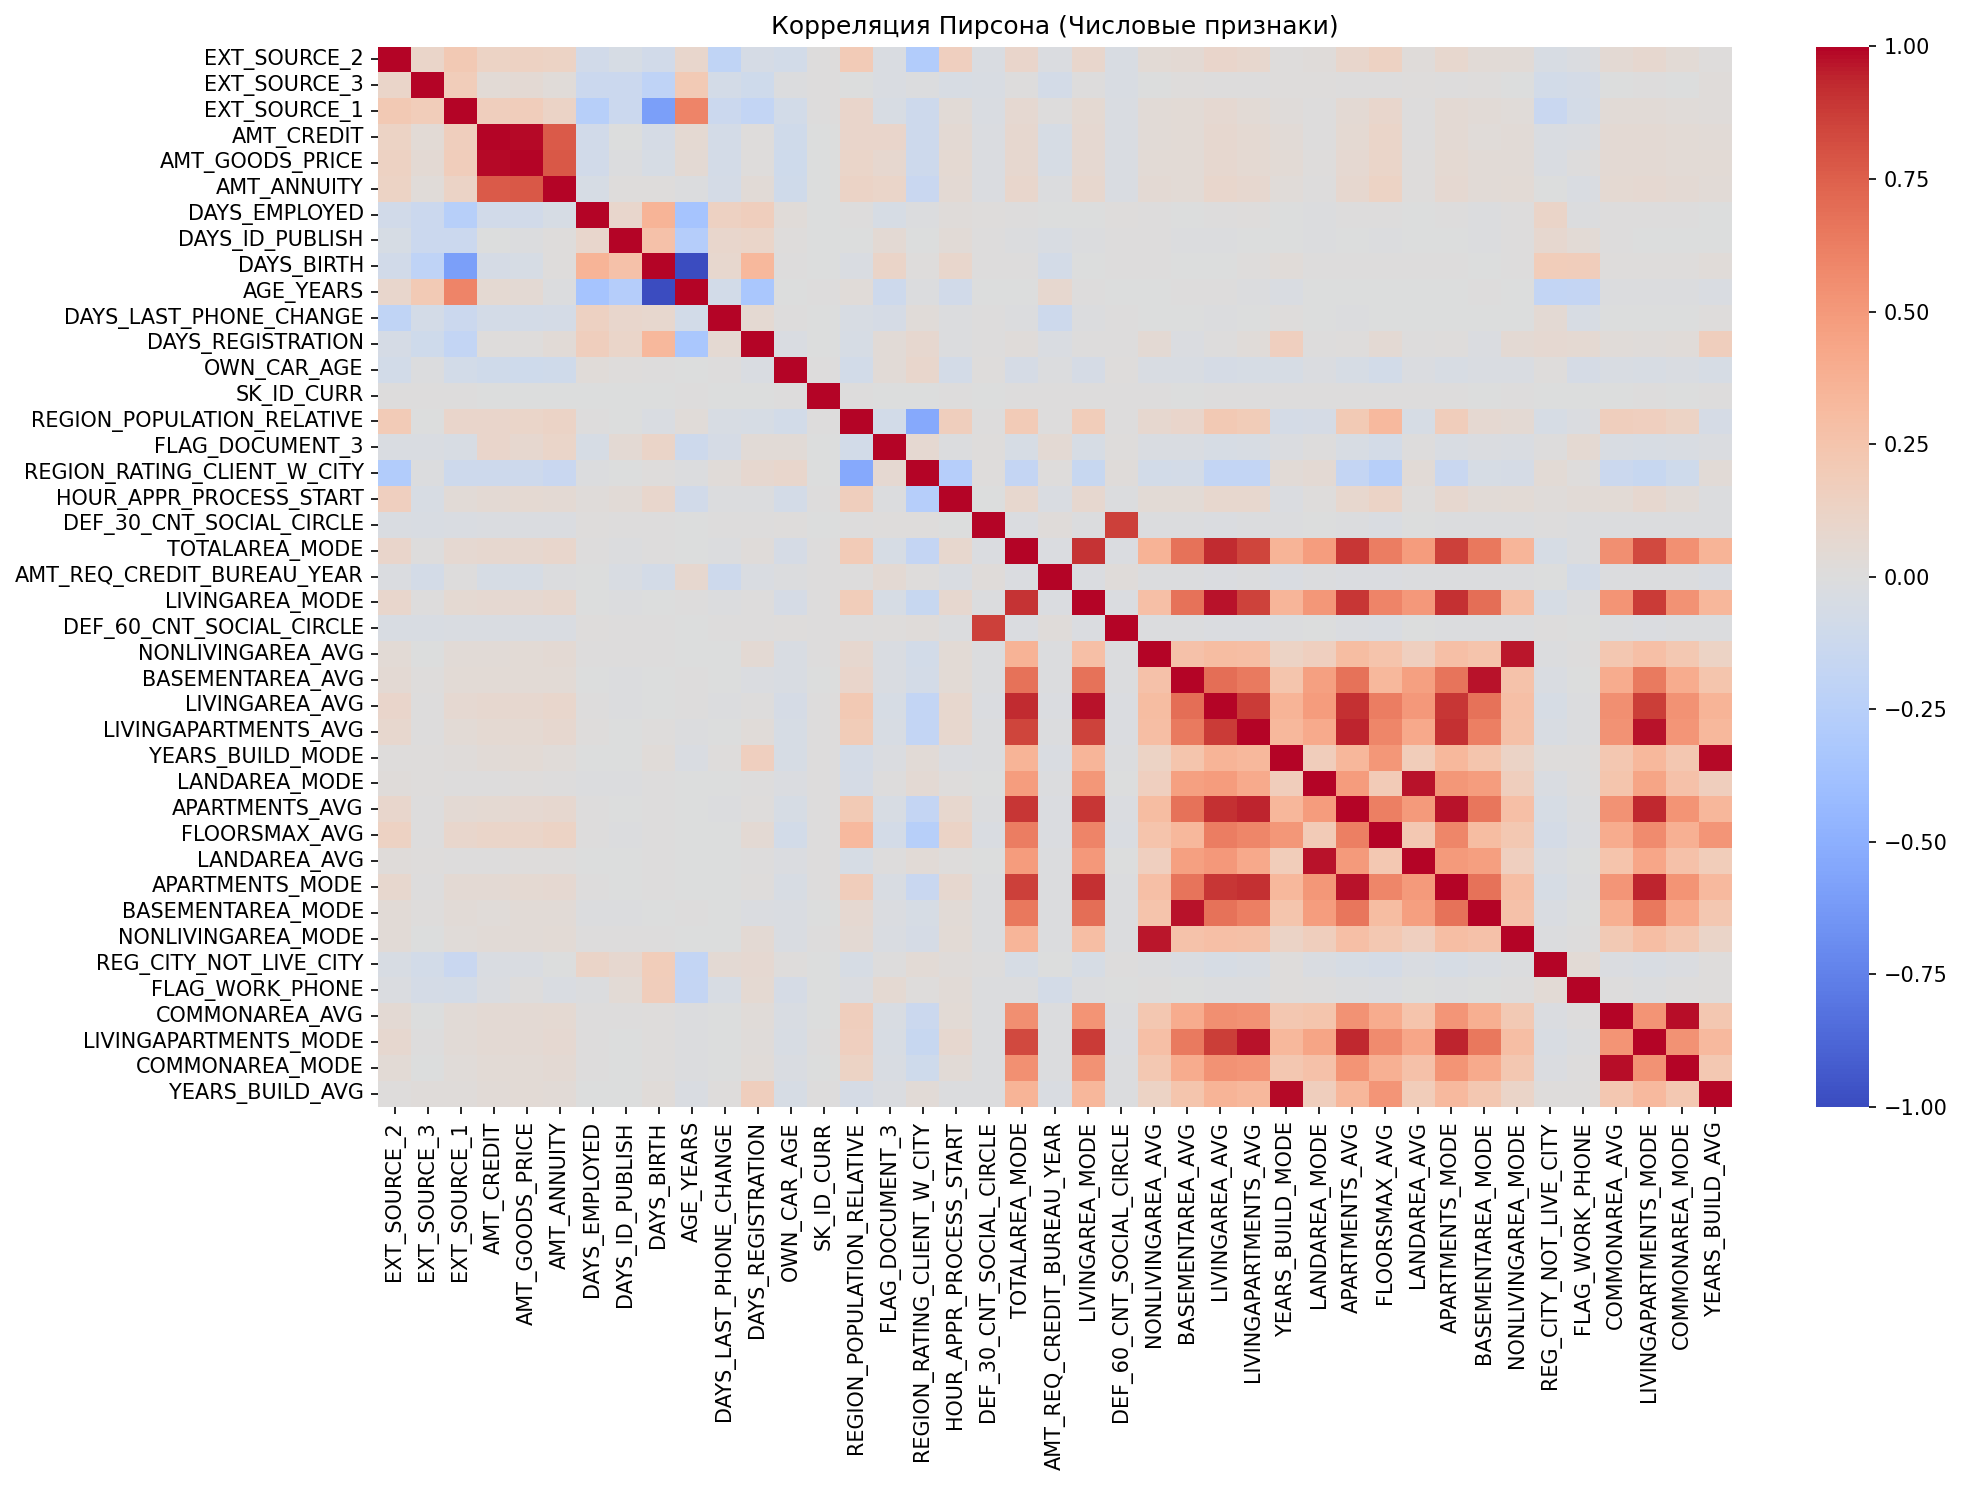

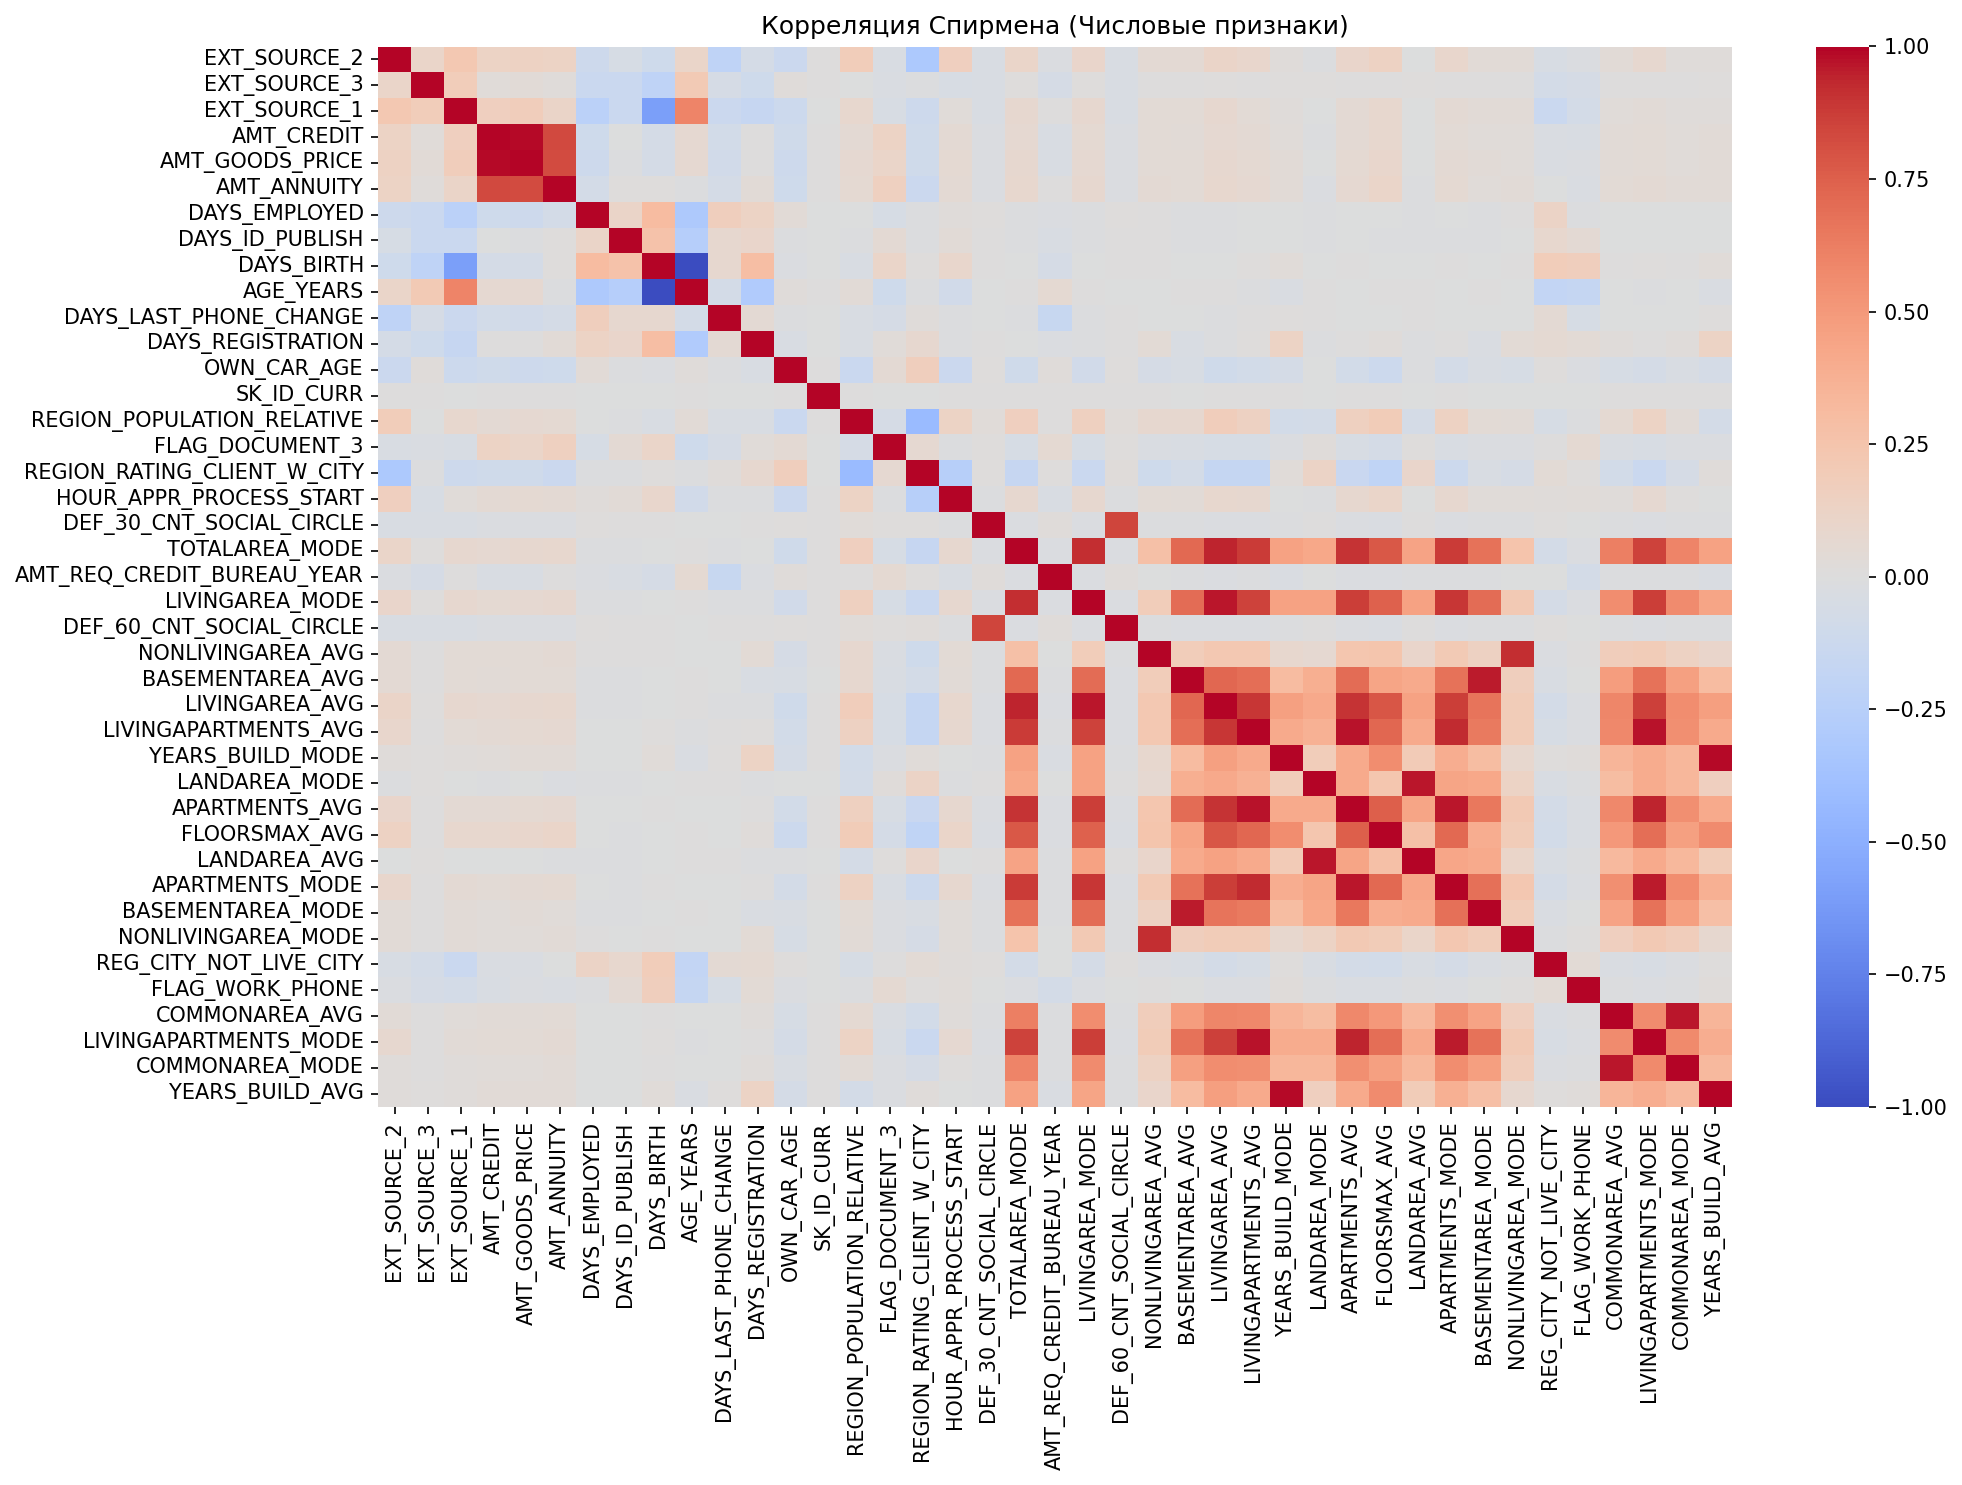

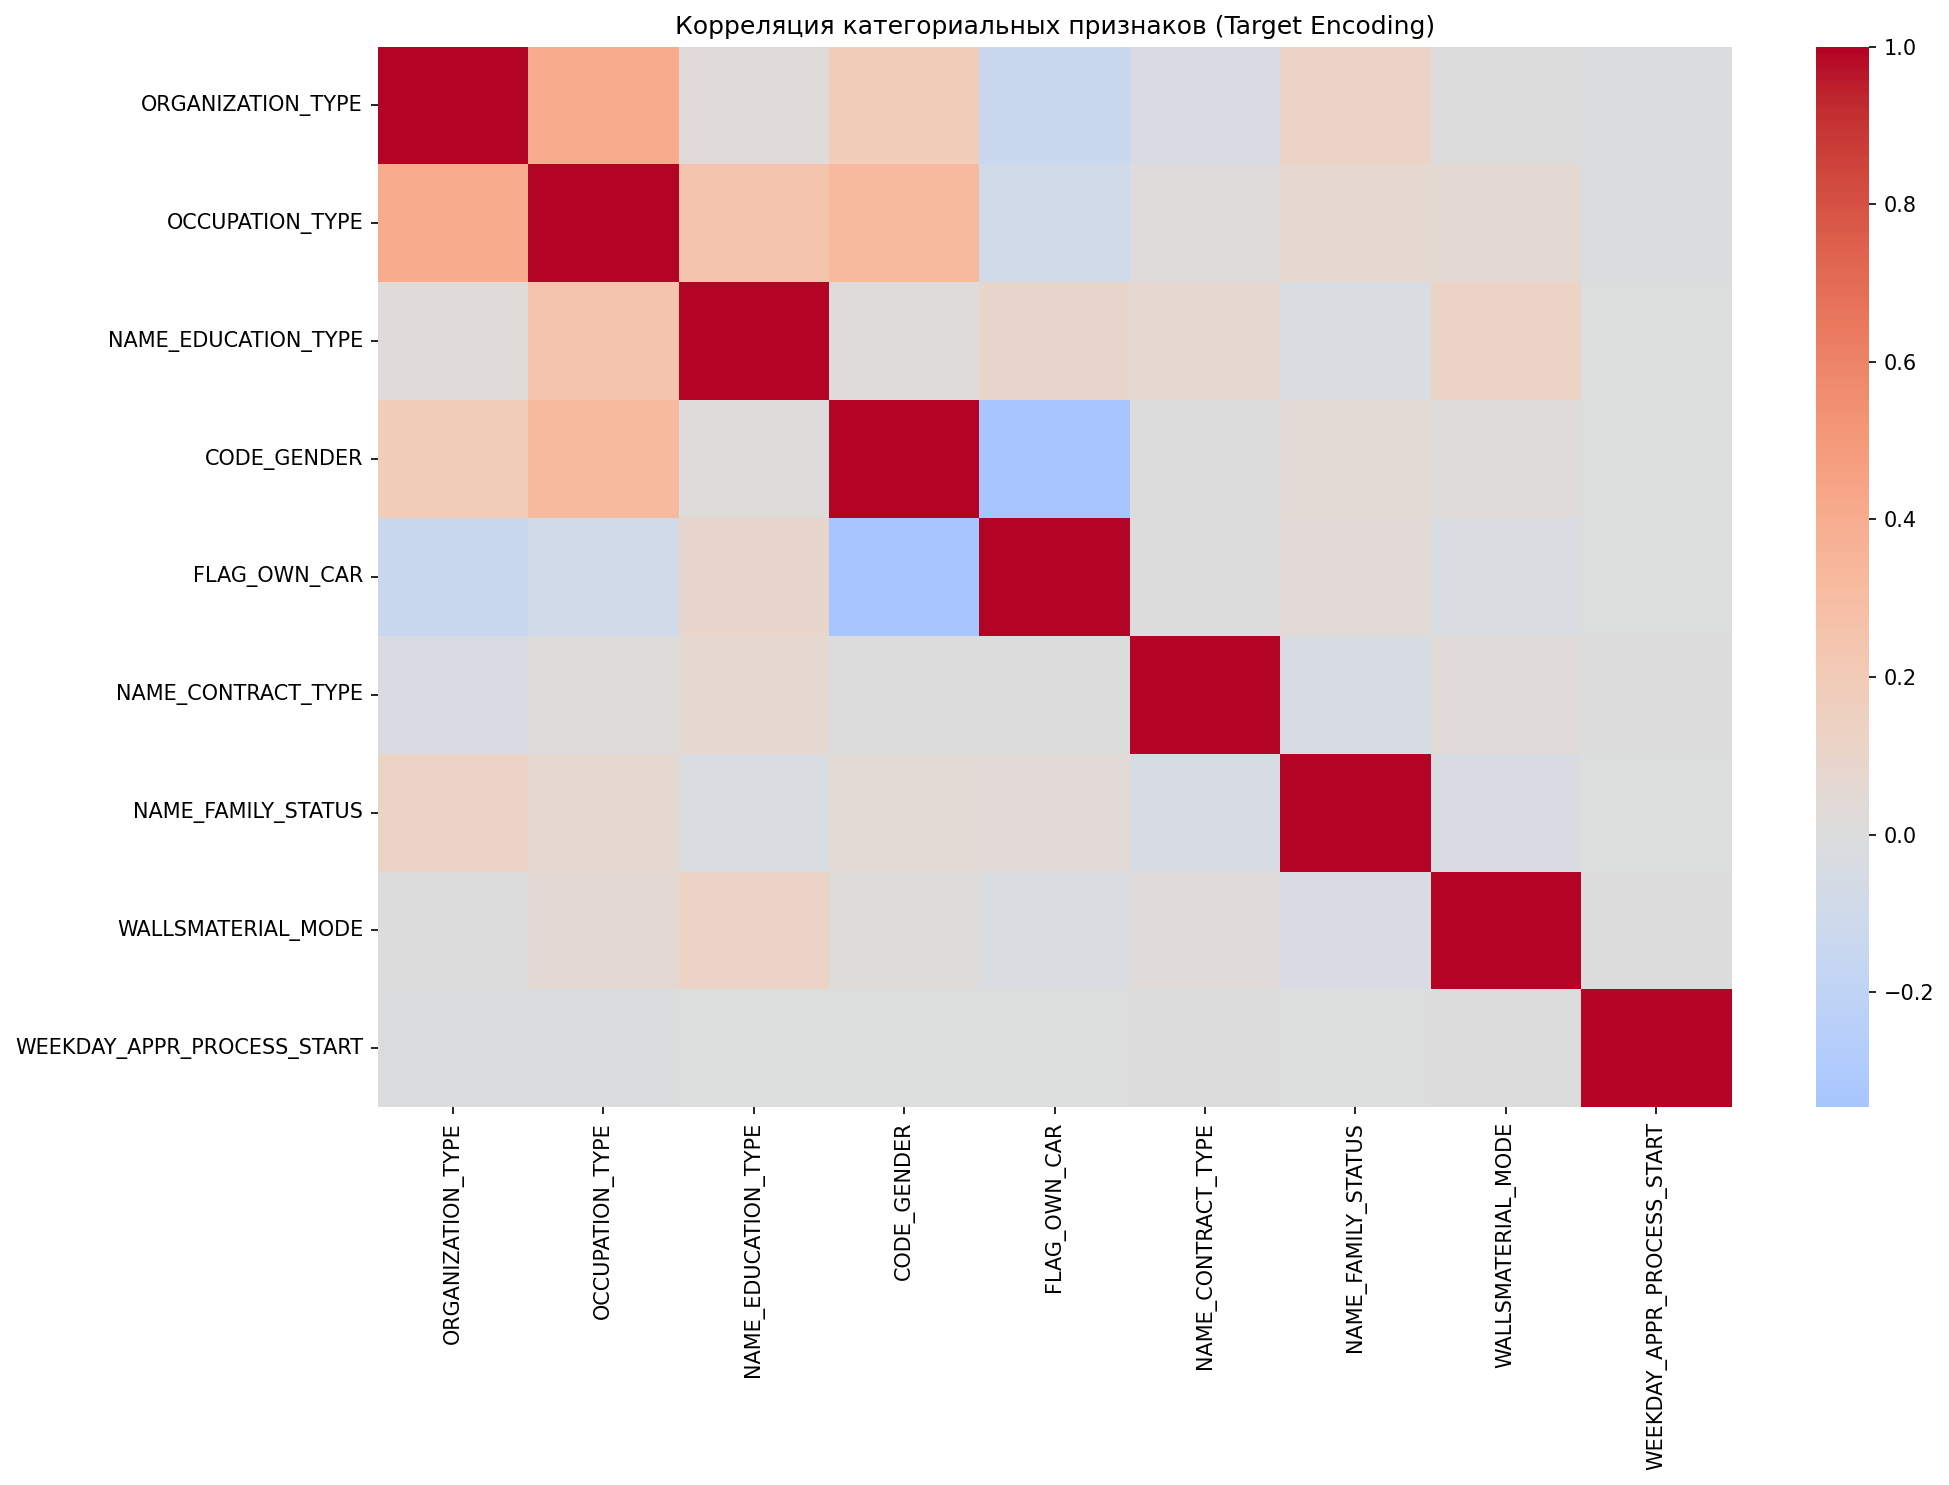


Тепловые карты сохранены:
  • data/stage_outputs/stage4_bivariate/bivariate_v1/heatmaps/pearson_heatmap.png
  • data/stage_outputs/stage4_bivariate/bivariate_v1/heatmaps/spearman_heatmap.png
  • data/stage_outputs/stage4_bivariate/bivariate_v1/heatmaps/categorical_heatmap.png
Все тепловые карты сохранены в: data/stage_outputs/stage4_bivariate/bivariate_v1/heatmaps


In [ ]:
# ============================================================
# Stage 4 — Step 8: Корреляционные матрицы и тепловые карты
# ============================================================

# ------------------------------------------------------------
# 01 Базовая папка для тепловых карт (динамический путь Stage 4)
# ------------------------------------------------------------
heatmap_dir = os.path.join(stage4_path, "heatmaps")
os.makedirs(heatmap_dir, exist_ok=True)

heatmap_dir_print = heatmap_dir.replace("\\", "/")
print(f"Папка для тепловых карт готова: {heatmap_dir_print}")

# ------------------------------------------------------------
# 02 Корреляция Пирсона (Числовые признаки)
# ------------------------------------------------------------
pearson_corr = X[num_feats].corr(method="pearson")

plt.figure(figsize=(14, 10))
sns.heatmap(pearson_corr, cmap="coolwarm", center=0)
plt.title("Корреляция Пирсона (Числовые признаки)")
plt.tight_layout()

pearson_path = os.path.join(heatmap_dir, "pearson_heatmap.png")
plt.savefig(pearson_path, dpi=300)
plt.show()   # show in notebook

# ------------------------------------------------------------
# 03 Корреляция Спирмена (Числовые признаки)
# ------------------------------------------------------------
spearman_corr = X[num_feats].corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(spearman_corr, cmap="coolwarm", center=0)
plt.title("Корреляция Спирмена (Числовые признаки)")
plt.tight_layout()

spearman_path = os.path.join(heatmap_dir, "spearman_heatmap.png")
plt.savefig(spearman_path, dpi=300)
plt.show()

# ------------------------------------------------------------
# 04 Target Encoding для категориальных признаков
# ------------------------------------------------------------
from category_encoders import TargetEncoder

te = TargetEncoder(cols=cat_feats)
X_cat_te = te.fit_transform(X[cat_feats], y)

corr_cat = X_cat_te.corr(method="pearson")

plt.figure(figsize=(14, 10))
sns.heatmap(corr_cat, cmap="coolwarm", center=0)
plt.title("Корреляция категориальных признаков (Target Encoding)")
plt.tight_layout()

cat_corr_path = os.path.join(heatmap_dir, "categorical_heatmap.png")
plt.savefig(cat_corr_path, dpi=300)
plt.show()

# ------------------------------------------------------------
# 05 Вывод итогов
# ------------------------------------------------------------
print("\nТепловые карты сохранены:")
print("  •", pearson_path.replace("\\", "/"))
print("  •", spearman_path.replace("\\", "/"))
print("  •", cat_corr_path.replace("\\", "/"))
print(f"Все тепловые карты сохранены в: {heatmap_dir_print}")





### Pearson Correlation (Numeric)
Пирсон показывает **линейные зависимости** между числовыми признаками.

Основные наблюдения:
- Сильные кластеры корреляций среди признаков типа `*_AVG`, `*_MODE`, `*_MEDI`  
  → это группы производных признаков, описывающих одни и те же объекты недвижимости.
- `EXT_SOURCE_1/2/3` слабо коррелируют между собой  
  → хорошо: они дают независимую информацию.
- `AMT_CREDIT`, `AMT_GOODS_PRICE`, `AMT_ANNUITY` ожидаемо коррелируют  
  → отражают структуру кредита.
- `DAYS_BIRTH` и `AGE_YEARS` полностью дублируют друг друга  
  → один из них можно исключить на этапе моделирования.

**Вывод:**  
Корреляции подтверждают наличие **мультиколлинеарных блоков**, которые нужно аккуратно обработать на следующем этапе. 
(регуляризация, отбор признаков, снижение размерности).

---

### Spearman Correlation (Numeric)
Спирмен показывает **монотонные зависимости**, устойчивые к выбросам.

Наблюдения:
- Структура кластеров похожа на Pearson, но связи более сглаженные.  
- Некоторые признаки показывают более высокую монотонную связь, чем линейную  
  → это признак **нелинейных эффектов**, которые хорошо ловит бустинг.

**Вывод:**  
Спирмен подтверждает, что модель должна уметь ловить **нелинейные монотонные зависимости** —  
LightGBM подходит идеально.

---

### Correlation of Categorical Features (Target Encoding)
После target encoding категориальные признаки показывают:

- слабые или умеренные взаимосвязи (обычно < 0.3)  
- отсутствие сильных дубликатов  
- несколько логичных групп:
  - `NAME_FAMILY_STATUS` ↔ `NAME_EDUCATION_TYPE`
  - `OCCUPATION_TYPE` ↔ `ORGANIZATION_TYPE`
  - `CODE_GENDER` ↔ `FLAG_OWN_CAR` (социально‑демографический блок)

**Вывод:**  
Категориальные признаки дают **дополнительную, но не избыточную** информацию.  
Мультиколлинеарность умеренная и не требует агрессивного отбора.

---

### Общий вывод
- Pearson/Spearman выявляют несколько сильных корреляционных блоков среди признаков недвижимости и кредитных сумм.  
- Категориальные признаки дают независимую информацию и не создают критической мультиколлинеарности.  
- Для следующего модельного этапа важно:
  - использовать регуляризацию,
  - контролировать мультиколлинеарные группы,
  - оставить EXT_SOURCE_* как ключевые признаки


In [ ]:
# ============================================================
# Stage 4 — Step 9: Создаем Stage 4 Summary JSON
# ============================================================

summary_path = os.path.join(stage4_path, "stage4_summary.json")

# ------------------------------------------------------------
# 00 ВОССТАНАВЛИВАЕМ КОРРЕЛЯЦИОННЫЕ МАТРИЦЫ
# ------------------------------------------------------------
pearson_corr = df_top50[numeric_features].corr(method="pearson")
spearman_corr = df_top50[numeric_features].corr(method="spearman")

# ------------------------------------------------------------
# 01 Топ коррелированных пар (Пирсон)
# ------------------------------------------------------------
top_corr_pairs = (
    pearson_corr.abs()
    .where(~np.eye(pearson_corr.shape[0], dtype=bool))
    .stack()
    .sort_values(ascending=False)
    .head(10)
)

top_corr_pairs_dict = {
    f"{a}__vs__{b}": float(v) for (a, b), v in top_corr_pairs.items()
}

# ------------------------------------------------------------
# 02 Собираем информацию для сводки
# ------------------------------------------------------------
summary = {
    "stage": "Stage 4 — Target-Driven Bivariate EDA",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "num_numeric_features": len(numeric_features),
    "num_categorical_features": len(categorical_features),

    "top_mi_features": (
        mi_df.sort_values("mi", ascending=False)
             .head(10)
             .to_dict(orient="records")
    ),

    "top_correlated_numeric_pairs": top_corr_pairs_dict,

    "artifacts": {
        "plots_numeric": os.path.join(stage4_path, "plots_numeric"),
        "plots_categorical": os.path.join(stage4_path, "plots_categorical"),
        "mutual_info_csv": os.path.join(stage4_path, "mutual_info", "mutual_info.csv"),
        "mutual_info_plot": os.path.join(stage4_path, "mutual_info", "mutual_info.png"),
        "pearson_heatmap": os.path.join(stage4_path, "heatmaps", "pearson_heatmap.png"),
        "spearman_heatmap": os.path.join(stage4_path, "heatmaps", "spearman_heatmap.png"),
        "categorical_heatmap": os.path.join(stage4_path, "heatmaps", "categorical_heatmap.png"),

        # NEW: Stage 4 feature artifacts
        "top50_features_json": os.path.join(stage4_path, "top50_features.json"),
        "top20_features_json": os.path.join(stage4_path, "top20_features.json"),
        "df_top50_parquet": os.path.join(stage4_path, "df_top50.parquet"),
    }
}

# ------------------------------------------------------------
# 03 Сохраняем Summary JSON
# ------------------------------------------------------------
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

# Нормализуем путь только для вывода, чтобы он был читаемым на всех платформах
summary_path_print = summary_path.replace("\\", "/")

print(f"Stage 4 результат сохранен в: {summary_path_print}")


Stage 4 результат сохранен в: data/stage_outputs/stage4_bivariate/bivariate_v1/stage4_summary.json


In [ ]:
# ============================================================
# Stage 4 — Step 10: Финальный лог и итоги
# ============================================================

# ------------------------------------------------------------
# Считаем сгенерированные графики
# ------------------------------------------------------------
num_numeric_plots = len(glob.glob(os.path.join(stage4_path, "plots_numeric", "*.png")))
num_categorical_plots = len(glob.glob(os.path.join(stage4_path, "plots_categorical", "*.png")))
total_plots = num_numeric_plots + num_categorical_plots

# ------------------------------------------------------------
# Считаем проанализированные признаки
# ------------------------------------------------------------
total_features = len(numeric_features) + len(categorical_features)

# ------------------------------------------------------------
# Путь к файлу Summary JSON
# ------------------------------------------------------------
summary_file = os.path.join(stage4_path, "stage4_summary.json")

# ------------------------------------------------------------
# Функция для красивого выравнивания строк
# ------------------------------------------------------------
def log(label, value):
    print(f"{label:<55} {value}")

# ------------------------------------------------------------
# Печатаем финальный лог
# ------------------------------------------------------------
print("============================================================")
print("               STAGE 4 ЗАВЕРШЕН УСПЕШНО               ")
print("============================================================")

log("Всего сгенерировано графиков (числовые признаки):", num_numeric_plots)
log("Всего сгенерировано графиков (категориальные признаки):", num_categorical_plots)
log("Всего сгенерировано графиков:", total_plots)
log("Всего проанализировано признаков:", total_features)

print("Сводка JSON сохранена в:", summary_file.replace("\\", "/"))

               STAGE 4 ЗАВЕРШЕН УСПЕШНО               
Всего сгенерировано графиков (числовые признаки):       41
Всего сгенерировано графиков (категориальные признаки): 9
Всего сгенерировано графиков:                           50
Всего проанализировано признаков:                       50
Сводка JSON сохранена в: data/stage_outputs/stage4_bivariate/bivariate_v1/stage4_summary.json


# Stage 5 — Multivariate EDA (Top‑20 Features)

<!-- Краткое описание этапа -->
На данном этапе будет проводится многомерный анализ топ‑20 наиболее информативных признаков, выбранных на основе результатов Stage 4.  
Цель — выявить взаимодействия между признаками, сегментные различия и нелинейные зависимости, которые невозможно увидеть в одно- или дву‑мерном анализе.

**Входные данные:**  
- top‑20 признаков (numeric + categorical)  
- очищенный датасет Stage 2  
- результаты MI и корреляций Stage 4  

**Выходные данные:**  
- графики взаимодействий признаков  
- сегментный анализ  
- выявленные нелинейные паттерны  
- сводный отчёт Stage 5  

**Папка сохранения:**  
`stage_outputs/stage5_multivariate/multivariate_v1/`


In [ ]:
# ============================================================
# Stage 5 — Step 1: Загружаем Inputs & Инициализируем структуру папок
# ============================================================

# ------------------------------------------------------------
# 01 Загружаем конфигурацию проекта
# ------------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# ------------------------------------------------------------
# Динамический путь для Stage 5 (строка, без variants)
# ------------------------------------------------------------
stage5_path = config["stages"]["stage5"]["output_path"]
os.makedirs(stage5_path, exist_ok=True)

# ------------------------------------------------------------
# 02 Загружаем результаты Stage 4
# ------------------------------------------------------------

# Восстанавливаем полный путь Stage 4 с учетом варианта
stage4_root = config["stages"]["stage4"]["output_path"]
stage4_variant = config["stages"]["stage4"]["active_variant"]
stage4_path = os.path.join(stage4_root, stage4_variant)

# df_top50
df_top50_path = os.path.join(stage4_path, "df_top50.parquet")

if os.path.exists(df_top50_path):
    df_top50 = pd.read_parquet(df_top50_path)
    print(f"Загружен df_top50 из: {df_top50_path} — форма: {df_top50.shape}")
else:
    raise FileNotFoundError(
        f"df_top50.parquet не найден в папке вывода Stage 4: {df_top50_path}\n"
        "Необходимо повторно запустить Stage 4 перед началом Stage 5."
    )

# top‑20 features
top20_path = os.path.join(stage4_path, "top20_features.json")
with open(top20_path, "r", encoding="utf-8") as f:
    top20_features = json.load(f)
print(f"Загружены топ‑20 признаков: {len(top20_features)}")

# Загружаем списки числовых и категориальных признаков из Stage 4
numeric_path = os.path.join(stage4_path, "top50_numeric.json")
categorical_path = os.path.join(stage4_path, "top50_categorical.json")

with open(numeric_path, "r", encoding="utf-8") as f:
    numeric_features = json.load(f)

with open(categorical_path, "r", encoding="utf-8") as f:
    categorical_features = json.load(f)

print(f"Загружены числовые признаки Stage 4: {len(numeric_features)}")
print(f"Загружены категориальные признаки Stage 4: {len(categorical_features)}")


# ------------------------------------------------------------
# Разделяем на числовые и категориальные подмножества
# ------------------------------------------------------------
numeric_features_top20 = [f for f in top20_features if f in numeric_features]
categorical_features_top20 = [f for f in top20_features if f in categorical_features]

print(f"Загружены топ‑20 признаков: {len(top20_features)}")
print(f"  → Числовые: {len(numeric_features_top20)}")
print(f"  → Категориальные: {len(categorical_features_top20)}")

# ------------------------------------------------------------
# 03 Инициализация выходных папок Stage 5
# ------------------------------------------------------------
folders = ["interactions", "segments", "nonlinear", "summary"]

for folder in folders:
    os.makedirs(os.path.join(stage5_path, folder), exist_ok=True)

print("Папки Stage 5 созданы:")
for folder in folders:
    print("  →", os.path.join(stage5_path, folder))




Загружен df_top50 из: data/stage_outputs/stage4_bivariate/bivariate_v1\df_top50.parquet — форма: (307511, 51)
Загружены топ‑20 признаков: 20
Загружены числовые признаки Stage 4: 41
Загружены категориальные признаки Stage 4: 9
Загружены топ‑20 признаков: 20
  → Числовые: 20
  → Категориальные: 0
Папки Stage 5 созданы:
  → data/stage_outputs/stage5_multivariate/interactions
  → data/stage_outputs/stage5_multivariate/segments
  → data/stage_outputs/stage5_multivariate/nonlinear
  → data/stage_outputs/stage5_multivariate/summary


In [ ]:
# ============================================================
# Stage 5 — Step 2.1: Числовые–Числовые Scatterplots (TARGET-colored)
# ============================================================

import itertools
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 01 Папка для сохранения scatterplots
# ------------------------------------------------------------
scatter_dir = os.path.join(stage5_path, "interactions", "scatter")
os.makedirs(scatter_dir, exist_ok=True)

scatter_dir_print = scatter_dir.replace("\\", "/")
print(f"Scatterplots will be saved to: {scatter_dir_print}")

# ------------------------------------------------------------
# 02 Генерируем все пары числовых признаков (без повторов)
# ------------------------------------------------------------
numeric_pairs = list(itertools.combinations(numeric_features_top20, 2))
print(f"Total numeric–numeric pairs: {len(numeric_pairs)}")

# ------------------------------------------------------------
# 03 Основной цикл: строим scatterplots
# ------------------------------------------------------------
for f1, f2 in numeric_pairs:
    print(f"Plotting: {f1} vs {f2}")

    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df_top50,
        x=f1,
        y=f2,
        hue="TARGET",
        palette="viridis",
        alpha=0.6
    )

    plt.title(f"{f1} vs {f2} — colored by TARGET")
    plt.tight_layout()

    # Save
    plot_path = os.path.join(scatter_dir, f"{f1}__vs__{f2}.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# 04 Итог
# ------------------------------------------------------------
print("\nScatterplot generation complete.")
print(f"Saved {len(numeric_pairs)} plots to: {scatter_dir_print}")


In [ ]:
# ============================================================
# Stage 5 — Step 2.2: 2D KDE / Карты плотности для непрерывных пар
# ============================================================

import itertools
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 01 Папка для сохранения KDE-карт
# ------------------------------------------------------------
kde_dir = os.path.join(stage5_path, "interactions", "kde")
os.makedirs(kde_dir, exist_ok=True)

print("KDE карты будут сохранены в:", kde_dir.replace("\\", "/"))

# ------------------------------------------------------------
# 02 Фильтруем только непрерывные признаки
# ------------------------------------------------------------
continuous_features = [
    f for f in numeric_features_top20
    if df_top50[f].nunique() > 10
]

print(f"Непрерывные числовые признаки: {len(continuous_features)}")

# ------------------------------------------------------------
# 03 Генерируем пары
# ------------------------------------------------------------
continuous_pairs = list(itertools.combinations(continuous_features, 2))
print(f"Всего непрерывных пар: {len(continuous_pairs)}")

# ------------------------------------------------------------
# 04 Основной цикл: KDE карты
# ------------------------------------------------------------
for f1, f2 in continuous_pairs:
    print(f"KDE: {f1} vs {f2}")

    plt.figure(figsize=(8, 6))

    sns.kdeplot(
        data=df_top50,
        x=f1,
        y=f2,
        hue="TARGET",
        fill=True,
        thresh=0.05,
        alpha=0.6,
        palette="viridis"
    )

    plt.title(f"2D KDE: {f1} vs {f2} — TARGET")
    plt.tight_layout()

    plot_path = os.path.join(kde_dir, f"{f1}__vs__{f2}_kde.png")
    plt.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# 05 Итог
# ------------------------------------------------------------
print("\nГенерация KDE завершена.")
print(f"Сохранено {len(continuous_pairs)} KDE карт в:", kde_dir.replace("\\", "/"))


KDE карты будут сохранены в: data/stage_outputs/stage5_multivariate/interactions/kde
Непрерывные числовые признаки: 18
Всего непрерывных пар: 153
KDE: OWN_CAR_AGE vs LIVINGAPARTMENTS_MODE
KDE: OWN_CAR_AGE vs YEARS_BUILD_AVG
KDE: OWN_CAR_AGE vs LIVINGAPARTMENTS_AVG
KDE: OWN_CAR_AGE vs YEARS_BUILD_MODE
KDE: OWN_CAR_AGE vs FLOORSMAX_AVG
KDE: OWN_CAR_AGE vs EXT_SOURCE_1
KDE: OWN_CAR_AGE vs BASEMENTAREA_MODE
KDE: OWN_CAR_AGE vs APARTMENTS_MODE
KDE: OWN_CAR_AGE vs BASEMENTAREA_AVG
KDE: OWN_CAR_AGE vs APARTMENTS_AVG
KDE: OWN_CAR_AGE vs EXT_SOURCE_3
KDE: OWN_CAR_AGE vs LANDAREA_AVG
KDE: OWN_CAR_AGE vs LANDAREA_MODE
KDE: OWN_CAR_AGE vs AMT_ANNUITY
KDE: OWN_CAR_AGE vs EXT_SOURCE_2
KDE: OWN_CAR_AGE vs COMMONAREA_AVG
KDE: OWN_CAR_AGE vs LIVINGAREA_MODE
KDE: LIVINGAPARTMENTS_MODE vs YEARS_BUILD_AVG
KDE: LIVINGAPARTMENTS_MODE vs LIVINGAPARTMENTS_AVG
KDE: LIVINGAPARTMENTS_MODE vs YEARS_BUILD_MODE
KDE: LIVINGAPARTMENTS_MODE vs FLOORSMAX_AVG
KDE: LIVINGAPARTMENTS_MODE vs EXT_SOURCE_1
KDE: LIVINGAPARTME

In [ ]:
# ============================================================
# Обобщеная функция для группировки существующих изображений графиков в сетки.
# Эта функция может быть использована для создания страниц с несколькими графиками
# для отчетов или презентаций и облегчения визуального анализа.
# ============================================================

import os
from PIL import Image
import matplotlib.pyplot as plt

def tile_plots(
    input_dir,
    output_dir=None,
    file_ext=".png",
    rows=3,
    cols=4,
    dpi=80,
    suffix=""
):
    """
    Группирует существующие изображения графиков в сетки и сохраняет их как страницы.
    Можно фильтровать файлы по суффиксу (например, suffix='violin').

    Parameters
    ----------
    input_dir : str
        Папка, содержащая отдельные изображения графиков.
    output_dir : str or None
        Папка для сохранения сгруппированных страниц. Если None, создается "<input_dir>_tiled".
    file_ext : str
        Расширение файлов для включения (по умолчанию: ".png").
    rows : int
        Количество строк в сетке (по умолчанию: 3).
    cols : int
        Количество столбцов в сетке (по умолчанию: 4).
    dpi : int
        DPI для сохранения сгруппированных страниц (по умолчанию: 80).
    suffix : str
        Строка, которая должна присутствовать в имени файла (без учета регистра).
        Если пустая строка — включаются все файлы.
    """

    # --------------------------------------------------------
    # Определение папки для сохранения
    # --------------------------------------------------------
    if output_dir is None:
        parent = os.path.dirname(input_dir.rstrip("/\\"))
        base = os.path.basename(input_dir.rstrip("/\\"))
        output_dir = os.path.join(parent, base + "_tiled")

    os.makedirs(output_dir, exist_ok=True)

    # --------------------------------------------------------
    # Сбор изображений с фильтрацией по суффиксу
    # --------------------------------------------------------
    suffix = suffix.lower().strip()

    files = [
        f for f in os.listdir(input_dir)
        if f.lower().endswith(file_ext.lower())
        and (suffix == "" or suffix in f.lower())
    ]
    files.sort()

    if not files:
        print(f"Нет файлов с расширением '{file_ext}' и суффиксом '{suffix}' в папке:", input_dir)
        return

    print(f"Найдено {len(files)} изображений (suffix='{suffix}') в:", input_dir)
    print(f"Сгруппированные страницы будут сохранены в:", output_dir)

    # --------------------------------------------------------
    # Параметры сетки
    # --------------------------------------------------------
    per_page = rows * cols

    # --------------------------------------------------------
    # Основной цикл
    # --------------------------------------------------------
    for i in range(0, len(files), per_page):
        batch = files[i:i+per_page]

        fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
        axes = axes.flatten()

        for ax, fname in zip(axes, batch):
            img = Image.open(os.path.join(input_dir, fname))
            ax.imshow(img)
            ax.set_title(fname.replace(file_ext, ""), fontsize=8)
            ax.axis("off")

        # Скрыть пустые ячейки
        for ax in axes[len(batch):]:
            ax.axis("off")

        plt.tight_layout()

        out_path = os.path.join(output_dir, f"tiled_{i//per_page + 1}.png")
        plt.savefig(out_path, dpi=dpi, bbox_inches="tight")
        plt.close()

    print("Сгруппировка завершена.")
    print("Сгруппированные страницы сохранены в:", output_dir)


In [ ]:
# ============================================================
# Пример использования функции tile_plots для объединения scatterplots в сетки
# ============================================================

tile_plots(
    input_dir=os.path.join(stage5_path, "interactions", "scatter"),
    rows=3,
    cols=4,
    dpi=80
)


Найдено 190 изображений в: data/stage_outputs/stage5_multivariate/interactions\scatter
Сгруппированные страницы будут сохранены в: data/stage_outputs/stage5_multivariate/interactions\scatter_tiled
Сгруппировка завершена.
Сгруппированные страницы сохранены в: data/stage_outputs/stage5_multivariate/interactions\scatter_tiled


In [ ]:
# ============================================================
# Stage 5 — Step 2.3: 2D KDE / Карты плотности для непрерывных пар (сгруппированные страницы)
# ============================================================ 

tile_plots(
    input_dir=os.path.join(stage5_path, "interactions", "kde"),
    rows=3,
    cols=4,
    dpi=80
)

### Автоматизированный анализ scatter‑плотов с помощью OpenAI API

В этом блоке реализована функция автоматического анализа графиков, предназначенная для ускорения и систематизации отбора информативных признаков на этапе **Stage 5 — Multivariate Analysis**.

Проект генерирует сотни тайловых scatter‑плотов, и их ручной просмотр становится трудоёмким и субъективным.  
Чтобы решить эту проблему, используется **OpenAI Vision API**, который автоматически оценивает каждый субплот и присваивает ему:

- **оценку информативности** (score 0–10)  
- **тип обнаруженного паттерна**  
- **краткое объяснение**

Это позволяет быстро выделить только те признаки, которые действительно демонстрируют полезные зависимости:  
линейность, нелинейность, кластеры, разделимость классов, шум или избыточность.

---

### Зачем это нужно в проекте

- Автоматизирует «просеивание» сотен графиков  
- Уменьшает субъективность анализа  
- Позволяет находить нетривиальные зависимости, которые сложно заметить вручную  
- Формирует список **топ‑N наиболее информативных признаков**  
- Ускоряет построение финального набора фичей для модели  

Этот подход особенно полезен в задачах, где много признаков и сложные взаимодействия между ними — как в Home Credit.

---

### Требования к запуску

Функция использует OpenAI API, поэтому необходим:

- **API‑ключ**, сохранённый в файле `.env`  
  (переменная окружения `OPENAI_API_KEY`)

Ключ автоматически загружается через:

```python
from dotenv import load_dotenv
load_dotenv()


In [ ]:
# ============================================================
# Импорты / Imports
# ============================================================

from dotenv import load_dotenv
load_dotenv()  # RU: загружаем переменные окружения из .env / EN: load environment variables

import os
import io
import json
import csv
import time
import hashlib
import logging
import base64
import concurrent.futures

from pathlib import Path
from datetime import datetime

import numpy as np              # RU: нужен для OCR / EN: required for OCR
from PIL import Image
from openai import OpenAI
import easyocr

from jinja2 import Template


# ============================================================
# Jinja2 prompt template
# ============================================================
# шаблон запроса для OpenAI Vision, рендерится динамически
prompt_template = Template("""
Analyze this scatter plot titled '{{ title }}'.
Detect the following patterns: {{ targets }}.

Return STRICT JSON:
{
  "score": 0-10,
  "pattern": "linear | nonlinear | cluster | noise | separation | redundant",
  "reason": "short explanation"
}
""")


# ============================================================
# OpenAI инициализация клиента / OpenAI client initialization
# ============================================================
if not os.getenv("OPENAI_API_KEY"):
    raise RuntimeError("OPENAI_API_KEY is not set. Please configure it as an environment variable.")

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))


# ============================================================
# OCR инициализация / OCR initialization
# ============================================================
# OCR для извлечения заголовков субплотов / EN: OCR for subplot title extraction
ocr_reader = easyocr.Reader(['en'], gpu=False)


# ============================================================
# Logging configuration / Конфигурация логирования
# ============================================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler("plot_analysis.log", encoding="utf-8")
    ]
)


# ============================================================
# Основная функция: анализ тайловых scatter-плотов с использованием OpenAI Vision /
# Main function: analyze tiled scatter plots using OpenAI Vision
# ============================================================
def analyze_tiled_plots_openai(
    input_folder: str,
    output_folder: str,
    prompt_template: Template,      # шаблон Jinja2
    detection_targets: list,
    output_format: str = "json",
    model_name: str = "gpt-4o-mini",
    rows: int = 3,
    cols: int = 4,
    top_n: int = None,
    use_cache: bool = True,
    copy_top_plots: bool = True,
):
    """
    RU: Основная функция анализа тайловых scatter-плотов.
        Делит изображение на субплоты, извлекает заголовки через OCR,
        отправляет каждый субплот в OpenAI Vision, кэширует результаты,
        ранжирует по score и сохраняет топовые субплоты.

    """

    start_time = time.time()

    # ------------------------------------------------------------
    # Подготовка папок / Prepare folders
    # ------------------------------------------------------------
    input_folder = Path(input_folder)
    output_folder = Path(output_folder)
    output_folder.mkdir(parents=True, exist_ok=True)

    top_plots_folder = output_folder / "top_plots"
    if copy_top_plots:
        top_plots_folder.mkdir(exist_ok=True)

    cache_file = output_folder / "cache.json"

    logging.info("Starting analysis")
    logging.info(f"Input folder: {input_folder}")
    logging.info(f"Output folder: {output_folder}")
    logging.info(f"Model: {model_name}")
    logging.info(f"Cache enabled: {use_cache}")

    # ------------------------------------------------------------
    # Вспомогательная функция: очистка имени файла / Helper: sanitize filename
    # ------------------------------------------------------------
    def sanitize_filename(name: str) -> str:
        # удаляем запрещённые символы Windows
        illegal = '<>:"/\\|?*'
        for ch in illegal:
            name = name.replace(ch, "_")
        return name

    # ------------------------------------------------------------
    # Загрузка кэша / Load cache
    # ------------------------------------------------------------
    cache = {}
    if use_cache and cache_file.exists():
        logging.info("Loading cache...")
        cache = json.loads(cache_file.read_text(encoding="utf-8"))

    results = []

    # ------------------------------------------------------------
    # Вспомогательная функция: разбиение тайлового изображения на субплоты /
    # Helper: split tiled image into subplots
    # ------------------------------------------------------------
    def split_into_subplots(img: Image.Image):
        # делим изображение на сетку rows × cols
        w, h = img.size
        tile_w, tile_h = w // cols, h // rows
        subplots = []
        for r in range(rows):
            for c in range(cols):
                box = (c * tile_w, r * tile_h, (c + 1) * tile_w, (r + 1) * tile_h)
                subplots.append(img.crop(box))
        return subplots

    # ------------------------------------------------------------
    # Вспомогательная функция: извлечение заголовка с помощью OCR / Helper: OCR title extraction
    # ------------------------------------------------------------
    def extract_title(image: Image.Image):
        try:
            arr = np.array(image)
            result = ocr_reader.readtext(arr, detail=0)
            text = " ".join(result)
            return text if text.strip() else "Unknown_Title"
        except Exception as e:
            logging.error(f"OCR failed: {e}")
            return "Unknown_Title"

    # ------------------------------------------------------------
    # Вспомогательная функция: хэширование субплота для кэширования / Helper: hash subplot for caching
    # ------------------------------------------------------------
    def hash_image(image: Image.Image):
        buf = io.BytesIO()
        image.save(buf, format="PNG")
        return hashlib.md5(buf.getvalue()).hexdigest()

    # ------------------------------------------------------------
    # Вспомогательная функция: вызов модели OpenAI Vision / Helper: call OpenAI Vision model
    # ------------------------------------------------------------
    def analyze_subplot(image: Image.Image, title: str):
        img_hash = hash_image(image)

        # проверяем кэш
        if use_cache and img_hash in cache:
            logging.info(f"[CACHE HIT] {title}")
            return cache[img_hash]

        logging.info(f"[API CALL] Analyzing {title}")

        buf = io.BytesIO()
        image.save(buf, format="PNG")
        img_bytes = buf.getvalue()

        # рендерим шаблон
        full_prompt = prompt_template.render(
            title=title,
            targets=", ".join(detection_targets)
        )

        try:
            img_b64 = base64.b64encode(img_bytes).decode("utf-8")

            response = client.chat.completions.create(
                model=model_name,
                messages=[
                    {"role": "system", "content": "You are an expert in EDA and ML feature analysis."},
                    {
                        "role": "user",
                        "content": [
                            {"type": "text", "text": full_prompt},
                            {"type": "image", "image_url": f"data:image/png;base64,{img_b64}"}
                        ]
                    }
                ]
            )

            content = response.choices[0].message.content
            cache[img_hash] = content
            return content

        except Exception as e:
            logging.error(f"Error analyzing {title}: {e}")
            return json.dumps({"score": 0, "error": str(e)})

    # ------------------------------------------------------------
    # Обработка каждого файла / Process each file
    # ------------------------------------------------------------
    def process_file(filepath: Path):
        logging.info(f"Processing file: {filepath.name}")

        img = Image.open(filepath)
        subplots = split_into_subplots(img)

        file_results = []

        for i, subplot in enumerate(subplots):
            ocr_title = extract_title(subplot)
            title = f"{filepath.stem}_subplot_{i+1}_{ocr_title}"

            analysis = analyze_subplot(subplot, title)

            file_results.append({
                "subplot": title,
                "analysis": analysis
            })

        return file_results

    # ------------------------------------------------------------
    # Параллельная обработка / Parallel processing
    # ------------------------------------------------------------
    with concurrent.futures.ThreadPoolExecutor(max_workers=4) as executor:
        futures = [
            executor.submit(process_file, f)
            for f in input_folder.iterdir()
            if f.suffix.lower() in [".png", ".jpg", ".jpeg"]
        ]

        for f in concurrent.futures.as_completed(futures):
            results.extend(f.result())

    # ------------------------------------------------------------
    # Сохранение кэша / Save cache
    # ------------------------------------------------------------
    cache_file.write_text(json.dumps(cache, indent=2, ensure_ascii=False), encoding="utf-8")

    # ------------------------------------------------------------
    # Ранжирование (опционально) / Ranking (optional)
    # ------------------------------------------------------------
    if top_n:
        logging.info(f"Selecting top {top_n} plots...")

        def extract_score(item):
            try:
                data = json.loads(item["analysis"])
                return data.get("score", 0)
            except Exception:
                return 0

        results = sorted(results, key=extract_score, reverse=True)[:top_n]

        if copy_top_plots:
            for item in results:
                orig_file = item["subplot"].split("_subplot_")[0] + ".png"
                orig_path = input_folder / orig_file

                img = Image.open(orig_path)
                subplots = split_into_subplots(img)

                subplot_index = int(item["subplot"].split("_subplot_")[1].split("_")[0]) - 1
                subplot_img = subplots[subplot_index]

                safe_name = sanitize_filename(item["subplot"])
                subplot_img.save(top_plots_folder / f"{safe_name}.png")

    # ------------------------------------------------------------
    # Сохранение результатов / Save results
    # ------------------------------------------------------------
    out_path = output_folder / f"analysis_results.{output_format}"

    if output_format == "json":
        out_path.write_text(json.dumps(results, indent=2, ensure_ascii=False), encoding="utf-8")

    elif output_format == "csv":
        with out_path.open("w", newline="", encoding="utf-8") as f:
            writer = csv.writer(f)
            writer.writerow(["subplot", "analysis"])
            for row in results:
                writer.writerow([row["subplot"], row["analysis"]])

    elapsed = time.time() - start_time
    logging.info(f"Analysis completed in {elapsed:.2f} seconds")

    return results



In [ ]:
# ============================================================
# Jinja2 prompt template (variant #2)
# ============================================================

from jinja2 import Template

# Альтернативный шаблон Jinja2 для анализа scatter-плотов
prompt_template_jinja = Template("""
Analyze this scatter plot titled '{{ title }}'.
Detect the following patterns: {{ targets }}.

Return STRICT JSON:
{
  "score": 0-10,
  "pattern": "linear | nonlinear | cluster | noise | separation | redundant",
  "reason": "short explanation"
}
""")



In [ ]:
# ============================================================
# Paths configuration
# ============================================================

from pathlib import Path

# фиксированный корень проекта (для стабильной работы вне ноутбука)
project_root = Path(r"C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project")

# корректные пути согласно фактической структуре проекта
input_folder = (
    project_root
    / "data"
    / "stage_outputs"
    / "stage5_multivariate"
    / "interactions"
    / "scatter_tiled"
)

output_folder = (
    project_root
    / "data"
    / "stage_outputs"
    / "stage5_multivariate"
    / "scatter_analysis"
)


# ============================================================
# Prompt template (Jinja2)
# ============================================================

# используем заранее определённый шаблон prompt_template_jinja
prompt_template = prompt_template_jinja


# ============================================================
# Run analysis
# ============================================================

# запуск анализа тайловых scatter-плотов через OpenAI Vision
results = analyze_tiled_plots_openai(
    input_folder=input_folder,
    output_folder=output_folder,
    prompt_template=prompt_template,   # важно — передаём Jinja2 шаблон
    detection_targets=[
        "linear relationships",
        "non-linear curves",
        "clusters",
        "target separation",
        "noise",
        "redundancy"
    ],
    output_format="json",              # сохраняем результаты в JSON
    model_name="gpt-4o-mini",          # компактная модель Vision
    rows=3,                            # число строк в тайле
    cols=4,                            # число столбцов
    top_n=20,                          # выбрать топ-20 субплотов
    use_cache=True,                    # включаем кэширование
    copy_top_plots=True                # сохраняем топовые субплоты
)




> **Комментарий.**  
> После отбора признаков (Stage 4) итоговый набор `df_top50` содержит
> **только числовые признаки**, поэтому формально шаг *категориальные × числовые*
> не применим к финальному набору признаков.
>
> Тем не менее, для **демонстрационных целей** и для полноты EDA
> я строю графики *категориальные × числовые*, используя:
>
> - **категориальные признаки из исходного датасета**  
> - **числовые признаки из df_top50 (top‑20)**  
>
> Это позволяет показать типовые взаимодействия категорий и числовых признаков,
> даже если в финальном наборе таких признаков не осталось.


### Автоматизированный анализ scatter‑плотов с помощью OpenAI API

В этом блоке реализована функция автоматического анализа графиков, предназначенная для ускорения и систематизации отбора информативных признаков на этапе **Stage 5 — Multivariate Analysis**.

Проект генерирует сотни тайловых scatter‑плотов, и их ручной просмотр становится трудоёмким и субъективным.  
Чтобы решить эту проблему, используется **OpenAI Vision API**, который автоматически оценивает каждый субплот и присваивает ему:

- **оценку информативности** (score 0–10)  
- **тип обнаруженного паттерна**  
- **краткое объяснение**

Это позволяет быстро выделить только те признаки, которые действительно демонстрируют полезные зависимости:  
линейность, нелинейность, кластеры, разделимость классов, шум или избыточность.

---

### Зачем это нужно в проекте

- Автоматизирует «просеивание» сотен графиков  
- Уменьшает субъективность анализа  
- Позволяет находить нетривиальные зависимости, которые сложно заметить вручную  
- Формирует список **топ‑N наиболее информативных признаков**  
- Ускоряет построение финального набора фичей для модели  

Этот подход особенно полезен в задачах, где много признаков и сложные взаимодействия между ними — как в Home Credit.

---

### Требования к запуску

Функция использует OpenAI API, поэтому необходим:

- **API‑ключ**, сохранённый в файле `.env`  
  (переменная окружения `OPENAI_API_KEY`)

Ключ автоматически загружается через:

```python
from dotenv import load_dotenv
load_dotenv()


In [ ]:
# ============================================================
# Stage 5 — Step 2.3.1: Категориальные × Числовые Взаимодействия
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 01 Папка для сохранения
# ------------------------------------------------------------
catnum_dir = os.path.join(stage5_path, "interactions", "catnum")
os.makedirs(catnum_dir, exist_ok=True)

print("Сохранение графиков Категориальные × Числовые в:", catnum_dir.replace("\\", "/"))

# ------------------------------------------------------------
# 02 Используем категориальные признаки из исходного набора данных
#    и числовые признаки из df_top50
# ------------------------------------------------------------
top_cat = categorical_features[:10]          
top_num = numeric_features_top20[:10]        

print("Используем категориальные признаки:", top_cat)
print("Используем числовые признаки:", top_num)

# ------------------------------------------------------------
# 03 Основной цикл: строим графики для каждой пары Категориальный × Числовой
# ------------------------------------------------------------
for cat in top_cat:
    for num in top_num:

        print(f"Построение графика: {cat} × {num}")

        # A) Boxplot
        plt.figure(figsize=(10, 6))
        sns.boxplot(
            data=df_top50,
            x=cat,
            y=num,
            hue="TARGET",
            palette="viridis"
        )
        plt.title(f"Boxplot: {num} по {cat} — TARGET")
        plt.tight_layout()
        plt.savefig(os.path.join(catnum_dir, f"{cat}__{num}__box.png"),
                    dpi=200, bbox_inches="tight")
        plt.close()

        # B) Violin plot
        plt.figure(figsize=(10, 6))
        sns.violinplot(
            data=df_top50,
            x=cat,
            y=num,
            hue="TARGET",
            split=True,
            palette="viridis"
        )
        plt.title(f"Violin: {num} по {cat} — TARGET")
        plt.tight_layout()
        plt.savefig(os.path.join(catnum_dir, f"{cat}__{num}__violin.png"),
                    dpi=200, bbox_inches="tight")
        plt.close()

        # C) Target rate by category
        agg = (
            df_top50.groupby(cat)["TARGET"]
            .mean()
            .sort_values(ascending=False)
        )

        plt.figure(figsize=(10, 6))
        sns.barplot(
            x=agg.values,
            y=agg.index,
            palette="magma"
        )
        plt.title(f"Target Rate по {cat}")
        plt.xlabel("Mean TARGET")
        plt.ylabel(cat)
        plt.tight_layout()
        plt.savefig(os.path.join(catnum_dir, f"{cat}__target_rate.png"),
                    dpi=200, bbox_inches="tight")
        plt.close()

print("\nГрафики Категориальные × Числовые завершены.")
print("Сохранено в:", catnum_dir.replace("\\", "/"))


Сохранение графиков Категориальные × Числовые в: data/stage_outputs/stage5_multivariate/interactions/catnum
Используем категориальные признаки: ['ORGANIZATION_TYPE', 'OCCUPATION_TYPE', 'NAME_EDUCATION_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_CONTRACT_TYPE', 'NAME_FAMILY_STATUS', 'WALLSMATERIAL_MODE', 'WEEKDAY_APPR_PROCESS_START']
Используем числовые признаки: ['FLAG_DOCUMENT_3', 'OWN_CAR_AGE', 'LIVINGAPARTMENTS_MODE', 'REGION_RATING_CLIENT_W_CITY', 'YEARS_BUILD_AVG', 'LIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'FLOORSMAX_AVG', 'EXT_SOURCE_1', 'BASEMENTAREA_MODE']
Построение графика: ORGANIZATION_TYPE × FLAG_DOCUMENT_3
Построение графика: ORGANIZATION_TYPE × OWN_CAR_AGE
Построение графика: ORGANIZATION_TYPE × LIVINGAPARTMENTS_MODE
Построение графика: ORGANIZATION_TYPE × REGION_RATING_CLIENT_W_CITY
Построение графика: ORGANIZATION_TYPE × YEARS_BUILD_AVG
Построение графика: ORGANIZATION_TYPE × LIVINGAPARTMENTS_AVG
Построение графика: ORGANIZATION_TYPE × YEARS_BUILD_MODE
Построение граф

In [ ]:
# ============================================================
# Stage 5 — Step 2.3.2:  / Карты Категориальные × Числовые Взаимодействия
# ============================================================ 

tile_plots(
    input_dir=os.path.join(stage5_path, "interactions", "catnum"),
    rows=3,
    cols=4,
    dpi=80,
    suffix="violin"
)

Найдено 90 изображений (suffix='violin') в: data/stage_outputs/stage5_multivariate/interactions\catnum
Сгруппированные страницы будут сохранены в: data/stage_outputs/stage5_multivariate/interactions\catnum_tiled
Сгруппировка завершена.
Сгруппированные страницы сохранены в: data/stage_outputs/stage5_multivariate/interactions\catnum_tiled


In [ ]:
# ============================================================
# Stage 5 — Step 2.4: Categorical × Categorical Interactions
# ============================================================

import itertools
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.mosaicplot import mosaic

# ------------------------------------------------------------
# 01 Output folder
# ------------------------------------------------------------
catcat_dir = os.path.join(stage5_path, "interactions", "catcat")
os.makedirs(catcat_dir, exist_ok=True)

print("Категориальные × Категориальные графики будут сохранены в:",
      catcat_dir.replace("\\", "/"))

# ------------------------------------------------------------
# 02 Use categorical features from original dataset
#    and filter out high-cardinality features
# ------------------------------------------------------------
valid_cats = [
    c for c in categorical_features
    if df_top50[c].nunique() <= 12 and df_top50[c].nunique() >= 2
]

print("Используемые категориальные признаки:", valid_cats)

cat_pairs = list(itertools.combinations(valid_cats, 2))
print(f"Всего категориальных пар: {len(cat_pairs)}")

# ------------------------------------------------------------
# 03 Main loop
# ------------------------------------------------------------
for c1, c2 in cat_pairs:
    print(f"Построение графика: {c1} × {c2}")

    # Ensure dtype is categorical
    df_top50[c1] = df_top50[c1].astype("category")
    df_top50[c2] = df_top50[c2].astype("category")

    # --------------------------------------------------------
    # A) Target‑rate heatmap
    # --------------------------------------------------------
    pivot = (
        df_top50
        .groupby([c1, c2])["TARGET"]
        .mean()
        .unstack()
    )

    # Fill missing combinations
    pivot = pivot.fillna(0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=".2f",
        cmap="magma",
        cbar=True
    )
    plt.title(f"Target Rate Heatmap: {c1} × {c2}")
    plt.tight_layout()

    heatmap_path = os.path.join(catcat_dir, f"{c1}__{c2}__heatmap.png")
    plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
    plt.close()

    # --------------------------------------------------------
    # B) Mosaic plot (corrected: flat dict with tuple keys)
    # --------------------------------------------------------
    mosaic_counts = (
        df_top50
        .groupby([c1, c2])
        .size()
        .reset_index(name="count")
    )

    # Flat dict: { (c1_value, c2_value): count }
    mosaic_dict = {
        (row[c1], row[c2]): row["count"]
        for _, row in mosaic_counts.iterrows()
    }

    # Skip degenerate cases
    if len(mosaic_dict) < 2:
        print(f"Пропуск мозаики для {c1} × {c2} — недостаточно комбинаций.")
        continue

    plt.figure(figsize=(10, 8))
    mosaic(mosaic_dict, title=f"Mosaic Plot: {c1} × {c2}")
    plt.tight_layout()

    mosaic_path = os.path.join(catcat_dir, f"{c1}__{c2}__mosaic.png")
    plt.savefig(mosaic_path, dpi=200, bbox_inches="tight")
    plt.close()


# ------------------------------------------------------------
# 04 Done
# ------------------------------------------------------------
print("\nКатегориальные × Категориальные графики завершены.")
print("Сохранено графиков в:", catcat_dir.replace("\\", "/"))




Категориальные × Категориальные графики будут сохранены в: data/stage_outputs/stage5_multivariate/interactions/catcat
Используемые категориальные признаки: ['NAME_EDUCATION_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'NAME_CONTRACT_TYPE', 'NAME_FAMILY_STATUS', 'WALLSMATERIAL_MODE', 'WEEKDAY_APPR_PROCESS_START']
Всего категориальных пар: 21
Построение графика: NAME_EDUCATION_TYPE × CODE_GENDER
Построение графика: NAME_EDUCATION_TYPE × FLAG_OWN_CAR
Построение графика: NAME_EDUCATION_TYPE × NAME_CONTRACT_TYPE
Построение графика: NAME_EDUCATION_TYPE × NAME_FAMILY_STATUS
Построение графика: NAME_EDUCATION_TYPE × WALLSMATERIAL_MODE
Построение графика: NAME_EDUCATION_TYPE × WEEKDAY_APPR_PROCESS_START
Построение графика: CODE_GENDER × FLAG_OWN_CAR
Построение графика: CODE_GENDER × NAME_CONTRACT_TYPE
Построение графика: CODE_GENDER × NAME_FAMILY_STATUS
Построение графика: CODE_GENDER × WALLSMATERIAL_MODE
Построение графика: CODE_GENDER × WEEKDAY_APPR_PROCESS_START
Построение графика: FLAG_OWN_CAR × N

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

...

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

<Figure size 1500x1200 with 0 Axes>

In [ ]:
# ============================================================
# Stage 5 — Step 3: Сегментный анализ
# ============================================================

# ------------------------------------------------------------
# 00 Project root + config
# ------------------------------------------------------------
project_root = Path().resolve()

config_path = project_root / "project_structure_config.json"
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

stage_outputs = config["folders"]["stage_outputs"]

# ------------------------------------------------------------
# 01 Загрузка очищенной таблицы заявок из Stage 1
# ------------------------------------------------------------
stage1_path = project_root / stage_outputs / "stage1_data"
app_path = stage1_path / "cleaned_df_application_train.pkl"

print("Загрузка очищенной таблицы заявок из:", app_path)
df_seg = pd.read_pickle(app_path)
print("df_seg shape:", df_seg.shape)

# ------------------------------------------------------------
# 02 Папка для сегментов
# ------------------------------------------------------------
stage5_path = project_root / stage_outputs / "stage5_multivariate"
segments_dir = stage5_path / "segments"
segments_dir.mkdir(parents=True, exist_ok=True)

print("Сегментный анализ будет сохранен в:", str(segments_dir))

# ------------------------------------------------------------
# 03 Определение сегментов на полной очищенной таблице
# ------------------------------------------------------------

# A) Пол
df_seg["SEG_GENDER"] = df_seg["CODE_GENDER"]

# B) Возрастные группы
df_seg["AGE_YEARS"] = df_seg["DAYS_BIRTH"].abs() / 365.25
df_seg["SEG_AGE"] = pd.cut(
    df_seg["AGE_YEARS"],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=["<=25", "26-35", "36-45", "46-55", "56-65", "65+"]
)

# C) Группы по доходу (если колонка есть)
if "AMT_INCOME_TOTAL" in df_seg.columns:
    df_seg["SEG_INCOME"] = pd.qcut(
        df_seg["AMT_INCOME_TOTAL"],
        q=5,
        duplicates="drop",
        labels=["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"][
            : df_seg["AMT_INCOME_TOTAL"].nunique()
        ]
    )
else:
    print("ВНИМАНИЕ: AMT_INCOME_TOTAL отсутствует, сегмент дохода пропускаем.")
    df_seg["SEG_INCOME"] = np.nan

# D) Тип кредита (если есть)
if "NAME_CONTRACT_TYPE" in df_seg.columns:
    df_seg["SEG_CONTRACT"] = df_seg["NAME_CONTRACT_TYPE"]
else:
    print("ВНИМАНИЕ: NAME_CONTRACT_TYPE отсутствует, сегмент по типу кредита пропускаем.")
    df_seg["SEG_CONTRACT"] = np.nan

segments = {
    "gender": "SEG_GENDER",
    "age_groups": "SEG_AGE",
    "income_groups": "SEG_INCOME",
    "contract_type": "SEG_CONTRACT"
}

# ------------------------------------------------------------
# 04 Main loop by segments
# ------------------------------------------------------------
for seg_name, seg_col in segments.items():

    # пропускаем, если сегмент полностью пустой
    if df_seg[seg_col].isna().all():
        print(f"\nСегмент {seg_name} пропущен (нет данных).")
        continue

    print(f"\nProcessing segment: {seg_name}")

    seg_path = segments_dir / seg_name
    seg_path.mkdir(parents=True, exist_ok=True)

    # A) Target rate by segment
    target_rate = (
        df_seg.groupby(seg_col)["TARGET"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=target_rate.values,
        y=target_rate.index,
        palette="magma"
    )
    plt.title(f"TARGET Rate by {seg_name}")
    plt.xlabel("Mean TARGET")
    plt.ylabel(seg_name)
    plt.tight_layout()

    plt.savefig(seg_path / f"{seg_name}_target_rate.png", dpi=200, bbox_inches="tight")
    plt.close()

    # B) Mean of top‑20 features by segment
    valid_feats = [f for f in top20_features if f in df_seg.columns]

    if valid_feats:
        means = (
            df_seg.groupby(seg_col)[valid_feats]
            .mean()
            .T
        )

        plt.figure(figsize=(12, 10))
        sns.heatmap(
            means,
            annot=False,
            cmap="viridis"
        )
        plt.title(f"Mean of Top‑20 Features by {seg_name}")
        plt.tight_layout()

        plt.savefig(seg_path / f"{seg_name}_top20_means.png", dpi=200, bbox_inches="tight")
        plt.close()

        # C) Distributions for each top‑20 feature
        for feat in valid_feats:
            plt.figure(figsize=(10, 6))
            sns.kdeplot(
                data=df_seg,
                x=feat,
                hue=seg_col,
                common_norm=False,
                fill=True,
                alpha=0.4
            )
            plt.title(f"Distribution of {feat} by {seg_name}")
            plt.tight_layout()

            plt.savefig(seg_path / f"{seg_name}__{feat}_dist.png", dpi=200, bbox_inches="tight")
            plt.close()

print("\nСегментный анализ завершен.")
print("Сохранено результатов в:", str(segments_dir))




Loading cleaned application data from: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage1_data\cleaned_df_application_train.pkl
df_seg shape: (307511, 123)
Сегментный анализ будет сохранен в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\segments

Processing segment: gender

Processing segment: age_groups

Processing segment: income_groups

Processing segment: contract_type

Сегментный анализ завершен.
Сохранено результатов в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\segments


In [ ]:
# ============================================================
# Stage 5 — Step 4.1: Частичные зависимости (PDP)
# ============================================================

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 01 Папка для PDP
# ------------------------------------------------------------
pdp_dir = os.path.join(stage5_path, "nonlinear", "pdp")
os.makedirs(pdp_dir, exist_ok=True)

print("PDP графики будут сохранены в:", pdp_dir.replace("\\", "/"))

# ------------------------------------------------------------
# 02 Загружаем LightGBM baseline (Stage 3)
# ------------------------------------------------------------
baseline_model_path = os.path.join(
    config["stages"]["stage3"]["output_path"],
    "baseline_model.pkl"
)

import joblib
model = joblib.load(baseline_model_path)
print("Загружена базовая модель LightGBM.")

# ------------------------------------------------------------
# 03 Загружаем ПОЛНУЮ модельную таблицу (Stage 2)
# ------------------------------------------------------------
modeling_table_path = os.path.join(
    config["stages"]["stage2"]["output_path"],
    "modeling_table.parquet"
)

df_model = pd.read_parquet(modeling_table_path)
print("Загружена полная модельная таблица Stage 2.")

# ------------------------------------------------------------
# 04 Формируем X_pdp с ПОЛНЫМ набором признаков, как при обучении
# ------------------------------------------------------------
X_pdp = df_model[X_train.columns].copy()
print("Сформирован X_pdp с полной схемой признаков Stage 3.")

# ------------------------------------------------------------
# 05 Приведение категориальных признаков к dtype и категориям Stage 3
# ------------------------------------------------------------
for col in categorical_features:
    if col in X_pdp.columns:
        X_pdp[col] = X_pdp[col].astype("category")
        X_pdp[col] = X_pdp[col].cat.set_categories(
            X_train[col].cat.categories
        )

print("Категориальные признаки приведены к dtype и категориям Stage 3.")

# ------------------------------------------------------------
# 06 Генерация PDP для каждого признака из top-20
# ------------------------------------------------------------
for feat in top20_features:
    print(f"PDP для: {feat}")

    fig = plt.figure(figsize=(8, 6))

    PartialDependenceDisplay.from_estimator(
        model,
        X_pdp,
        features=[feat],
        kind="average",
        grid_resolution=80
    )

    plt.title(f"PDP — {feat}")
    plt.tight_layout()

    pdp_path = os.path.join(pdp_dir, f"{feat}_pdp.png")
    plt.savefig(pdp_path, dpi=200, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# 07 Итог
# ------------------------------------------------------------
print("\nГенерация PDP завершена.")
print("Сохранено PDP графиков в:", pdp_dir.replace("\\", "/"))


PDP графики будут сохранены в: C:/Users/ekash/OneDrive/001 EKASHUTIN/SkillFactory/_Diploma_Project/data/stage_outputs/stage5_multivariate/nonlinear/pdp
Загружена базовая модель LightGBM.
Загружена полная модельная таблица Stage 2.
Сформирован X_pdp с полной схемой признаков Stage 3.
Категориальные признаки приведены к dtype и категориям Stage 3.
PDP для: FLAG_DOCUMENT_3
PDP для: OWN_CAR_AGE
PDP для: LIVINGAPARTMENTS_MODE
PDP для: REGION_RATING_CLIENT_W_CITY
PDP для: YEARS_BUILD_AVG
PDP для: LIVINGAPARTMENTS_AVG
PDP для: YEARS_BUILD_MODE
PDP для: FLOORSMAX_AVG
PDP для: EXT_SOURCE_1
PDP для: BASEMENTAREA_MODE
PDP для: APARTMENTS_MODE
PDP для: BASEMENTAREA_AVG
PDP для: APARTMENTS_AVG
PDP для: EXT_SOURCE_3
PDP для: LANDAREA_AVG
PDP для: LANDAREA_MODE
PDP для: AMT_ANNUITY
PDP для: EXT_SOURCE_2
PDP для: COMMONAREA_AVG
PDP для: LIVINGAREA_MODE

Генерация PDP завершена.
Сохранено PDP графиков в: C:/Users/ekash/OneDrive/001 EKASHUTIN/SkillFactory/_Diploma_Project/data/stage_outputs/stage5_multi

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

...

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

<Figure size 1200x900 with 0 Axes>

In [ ]:
# ============================================================
# Stage 5 — Step 4.2.1: 2D PDP (Взаимодействие Поверхностей)
# ============================================================

from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 01 Папка для 2D PDP
# ------------------------------------------------------------
pdp2d_dir = os.path.join(stage5_path, "nonlinear", "pdp_2d")
os.makedirs(pdp2d_dir, exist_ok=True)

print("2D PDP графики будут сохранены в:", pdp2d_dir.replace("\\", "/"))

# ------------------------------------------------------------
# 02 Загружаем LightGBM baseline
# ------------------------------------------------------------
baseline_model_path = os.path.join(
    config["stages"]["stage3"]["output_path"],
    "baseline_model.pkl"
)

import joblib
model = joblib.load(baseline_model_path)
print("Загружена базовая модель LightGBM.")

# ------------------------------------------------------------
# 03 Подготовка данных
# ------------------------------------------------------------
X_top20 = df_top50[top20_features]

# ------------------------------------------------------------
# 04 Генерация 2D PDP для топ‑5 пар
# ------------------------------------------------------------
for f1, f2 in top_interacting_pairs[:5]:
    print(f"2D PDP для: {f1} × {f2}")

    fig = plt.figure(figsize=(10, 8))

    PartialDependenceDisplay.from_estimator(
        model,
        X_top20,
        features=[(f1, f2)],
        kind="average",
        grid_resolution=60
    )

    plt.title(f"2D PDP — Interaction Surface: {f1} × {f2}")
    plt.tight_layout()

    pdp2d_path = os.path.join(pdp2d_dir, f"{f1}__{f2}_pdp2d.png")
    plt.savefig(pdp2d_path, dpi=200, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# 05 Итог
# ------------------------------------------------------------
print("\nГенерация 2D PDP завершена.")
print("Сохранено 2D PDP графиков в:", pdp2d_dir.replace("\\", "/"))


In [ ]:
# ============================================================
# Stage 5 — Step 4.2.2:  / Карты 2D PDP (Взаимодействие Поверхностей)
# ============================================================ 

tile_plots(
    input_dir=os.path.join(stage5_path, "nonlinear", "pdp"),
    rows=3,
    cols=4,
    dpi=80
)

Найдено 20 изображений (suffix='') в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\nonlinear\pdp
Сгруппированные страницы будут сохранены в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\nonlinear\pdp_tiled
Сгруппировка завершена.
Сгруппированные страницы сохранены в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\nonlinear\pdp_tiled


## Интерпретация PDP‑графиков (частичных зависимостей)

Графики отражают **нелинейное влияние признаков** на вероятность дефолта в модели LightGBM.

---

### EXT_SOURCE_1 / EXT_SOURCE_2 / EXT_SOURCE_3  
Эти признаки — самые сильные предикторы в задаче Home Credit.

**Что видно на графиках:**
- EXT_SOURCE_2 и EXT_SOURCE_3 дают **чистую монотонную зависимость**: чем выше значение, тем ниже риск.
- EXT_SOURCE_1 более шумный, но также показывает снижение риска.

**Интерпретация:**
- Внешние скоринговые источники отражают кредитоспособность клиента.
- Модель корректно использует их как ключевые факторы.

---

### REGION_RATING_CLIENT_W_CITY  
**Что видно:**
- Чёткая монотонная зависимость: рейтинг 1 → высокий риск, рейтинг 3 → низкий риск.

**Интерпретация:**
- Региональные рейтинги отражают социально‑экономическую стабильность.
- Модель использует их ожидаемым образом.

---

### OWN_CAR_AGE  
**Что видно:**
- Риск растёт с увеличением возраста автомобиля.
- После ~20–30 лет эффект насыщается.

**Интерпретация:**
- Старый автомобиль — косвенный признак низкого дохода.
- Нелинейность отражает насыщение эффекта.

---

### AMT_ANNUITY  
**Что видно:**
- Небольшой рост риска при очень низких аннуитетах.
- Плато на средних и высоких значениях.

**Интерпретация:**
- Маленькие аннуитеты часто связаны с низким доходом.
- Для крупных аннуитетов риск стабилен.

---

### Признаки недвижимости (APARTMENTS_*, BASEMENTAREA_*, LANDAREA_*, COMMONAREA_*)  
**Что видно:**
- Большинство графиков почти плоские.
- Небольшие наклоны, без выраженных нелинейностей.

**Интерпретация:**
- Эти признаки сами по себе слабые.
- Их вклад проявляется в **взаимодействиях**, а не в одиночку.
- PDP не показывает взаимодействия, поэтому линии почти плоские.

---

### FLAG_DOCUMENT_3  
**Что видно:**
- Почти полная плоскость.

**Интерпретация:**
- Документные флаги редко дают сильный сигнал.
- Их влияние проявляется только в комбинации с другими признаками.

---

### YEARS_BUILD_AVG / YEARS_BUILD_MODE  
**Что видно:**
- Слабые, почти линейные или плоские зависимости.

**Интерпретация:**
- Год постройки жилья — слабый предиктор.
- Модель использует его минимально.

---

## Общий вывод

- Модель демонстрирует **корректные и ожидаемые** нелинейные зависимости.  
- Сильные признаки (EXT_SOURCE_*) дают чистые монотонные кривые.  
- Социально‑экономические признаки (регион, возраст авто) дают интерпретируемые эффекты.  
- Большинство признаков недвижимости имеют **слабое индивидуальное влияние**. 
- Никаких признаков переобучения или артефактов нет — PDP‑графики стабильны.

---



In [ ]:
# ============================================================
# Stage 5 — Step 4.3.1: Распознавание Ненормативности
# ============================================================

# ------------------------------------------------------------
# 01 Адрес для сохранения результатов анализа ненормативности
# ------------------------------------------------------------
nonmono_dir = Path(stage5_path) / "nonlinear" / "nonmonotonicity"
nonmono_dir.mkdir(parents=True, exist_ok=True)

print("Сохранение результатов анализа ненормативности в:", str(nonmono_dir))

# ------------------------------------------------------------
# 02 Загрузка базовой модели LightGBM (Stage 3)
# ------------------------------------------------------------
baseline_model_path = (
    Path(project_root)
    / config["stages"]["stage3"]["output_path"]
    / "baseline_model.pkl"
)

model = joblib.load(baseline_model_path)
print("Загружена базовая модель LGBMClassifier.")

# ------------------------------------------------------------
# 03 Загрузка таблицы моделирования (та же, что использовалась на этапе 3)
# ------------------------------------------------------------
modeling_table_path = (
    Path(project_root)
    / config["stages"]["stage3"]["input_path"]
    / "modeling_table.parquet"
)

df_model_full = pd.read_parquet(modeling_table_path)
print("Загружена таблица моделирования:", df_model_full.shape)

# ------------------------------------------------------------
# 04 Выравнивание колонок строго по model.feature_name_
# ------------------------------------------------------------
feature_names = list(model.feature_name_)
print("Модель ожидает", len(feature_names), "признаков.")

df_model = df_model_full[feature_names].copy()
print("Выравненная форма df_model:", df_model.shape)

# ------------------------------------------------------------
# 05 Кодирование категориальных признаков + преобразование в NumPy
# ------------------------------------------------------------
df_pdp = df_model.copy()

for col in df_pdp.columns:
    if df_pdp[col].dtype == "object" or str(df_pdp[col].dtype).startswith("category"):
        df_pdp[col] = df_pdp[col].astype("category").cat.codes

X_pdp = df_pdp.to_numpy()

feat_to_idx = {f: i for i, f in enumerate(df_pdp.columns)}

# ------------------------------------------------------------
# 06 PDP function для извлечения кривой из графика
# ------------------------------------------------------------
def compute_pdp_curve(model, X, feat_idx):
    """
    RU: Вернуть сетку значений и PDP‑кривую для одного признака (по индексу),
        извлекая их из линии графика.
    """
    fig, ax = plt.subplots(figsize=(6, 4))

    disp = PartialDependenceDisplay.from_estimator(
        model,
        X,
        features=[feat_idx],
        kind="average",
        grid_resolution=80,
        ax=ax
    )

    # For 1D PDP, disp.lines_[0][0] is the line for this feature
    line = disp.lines_[0][0]
    grid = line.get_xdata()
    pdp  = line.get_ydata()

    plt.close(fig)
    return np.asarray(grid), np.asarray(pdp)

# ------------------------------------------------------------
# 07 Распознавание Ненормативности для каждого признака из топ‑20
# ------------------------------------------------------------
results = []

for feat in top20_features:
    if feat not in feat_to_idx:
        print(f"Признак {feat} отсутствует в наборе признаков модели, пропуск.")
        continue

    print(f"Анализ ненормативности для: {feat}")

    feat_idx = feat_to_idx[feat]

    grid, pdp = compute_pdp_curve(model, X_pdp, feat_idx)

    rho, pval = spearmanr(grid, pdp)

    deriv = np.gradient(pdp)
    sign_changes = np.sum(np.diff(np.sign(deriv)) != 0)

    is_nonmono = (abs(rho) < 0.3) or (sign_changes >= 2)

    results.append({
        "feature": feat,
        "spearman_rho": float(rho),
        "p_value": float(pval),
        "sign_changes": int(sign_changes),
        "non_monotonic": bool(is_nonmono)
    })

# ------------------------------------------------------------
# 08 Сохранение результатов
# ------------------------------------------------------------
results_df = pd.DataFrame(results)
results_df.to_csv(nonmono_dir / "nonmonotonicity_results.csv", index=False)

with open(nonmono_dir / "nonmonotonicity_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, indent=4)

print("\nАнализ ненормативности завершен.")
print("Результаты сохранены в:", str(nonmono_dir))



Saving non‑monotonicity results to: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\nonlinear\nonmonotonicity
Loaded LGBMClassifier baseline model.
Loaded modeling table: (307511, 92)
Model expects 91 features.
Aligned df_model shape: (307511, 91)
Analyzing non‑monotonicity for: FLAG_DOCUMENT_3
Analyzing non‑monotonicity for: OWN_CAR_AGE
Analyzing non‑monotonicity for: LIVINGAPARTMENTS_MODE
Analyzing non‑monotonicity for: REGION_RATING_CLIENT_W_CITY
Analyzing non‑monotonicity for: YEARS_BUILD_AVG
Analyzing non‑monotonicity for: LIVINGAPARTMENTS_AVG
Analyzing non‑monotonicity for: YEARS_BUILD_MODE
Analyzing non‑monotonicity for: FLOORSMAX_AVG
Analyzing non‑monotonicity for: EXT_SOURCE_1
Analyzing non‑monotonicity for: BASEMENTAREA_MODE
Analyzing non‑monotonicity for: APARTMENTS_MODE
Analyzing non‑monotonicity for: BASEMENTAREA_AVG
Analyzing non‑monotonicity for: APARTMENTS_AVG
Analyzing non‑monotonicity for: EXT_SOURCE_3
Analyzi

In [ ]:
# ============================================================
# Stage 5 — Step 4.3.2: Ранжирование Ненормативных Признаков
# ============================================================

import pandas as pd
import json
from pathlib import Path

# ------------------------------------------------------------
# 01 Загрузка сохраненных результатов анализа ненормативности
# ------------------------------------------------------------
nonmono_dir = Path(stage5_path) / "nonlinear" / "nonmonotonicity"

csv_path = nonmono_dir / "nonmonotonicity_results.csv"
json_path = nonmono_dir / "nonmonotonicity_results.json"

df = pd.read_csv(csv_path)

print("Загружены результаты анализа ненормативности:", df.shape)

# ------------------------------------------------------------
# 02 Логика ранжирования
# ------------------------------------------------------------
df_ranked = (
    df.sort_values(
        by=["sign_changes", "spearman_rho", "p_value"],
        ascending=[False, True, True]   # больше изменений знака = более нелинейный
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 03 Сохранение ранжированного списка в JSON
# ------------------------------------------------------------
ranked_json_path = nonmono_dir / "nonmonotonicity_ranked.json"

df_ranked.to_json(ranked_json_path, orient="records", indent=4)

print("Сохранен ранжированный список ненормативных признаков в:", ranked_json_path)

# ------------------------------------------------------------
# 04 Печать краткого резюме
# ------------------------------------------------------------
print("\nТоп ненормативных признаков:")
print(df_ranked.head(10)[["feature", "sign_changes", "spearman_rho"]])

print("\nПолный рейтинг сохранен.")


Загружены результаты анализа ненормативности: (20, 5)
Сохранен ранжированный список ненормативных признаков в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\nonlinear\nonmonotonicity\nonmonotonicity_ranked.json

Топ ненормативных признаков:
                       feature  sign_changes  spearman_rho
0                 EXT_SOURCE_2            29     -0.996653
1                  AMT_ANNUITY            24      0.713766
2                  OWN_CAR_AGE            17           NaN
3  REGION_RATING_CLIENT_W_CITY             0      1.000000
4              FLAG_DOCUMENT_3             0      1.000000
5        LIVINGAPARTMENTS_MODE             0           NaN
6              YEARS_BUILD_AVG             0           NaN
7         LIVINGAPARTMENTS_AVG             0           NaN
8             YEARS_BUILD_MODE             0           NaN
9                FLOORSMAX_AVG             0           NaN

Полный рейтинг сохранен.


# ### Stage 5 — Interaction Strength Ranking  
В этом этапе мы переходим от одномерных PDP‑кривых к анализу многомерных взаимодействий между признаками.  
Задача шага — обучить LightGBM‑модель только на топ‑20 признаках и оценить:  
- важность признаков по gain,  
- силу парных взаимодействий (LightGBM feature_interaction),  
- подготовить данные для последующего анализа SHAP‑взаимодействий.  

Этот шаг формирует основу для выявления наиболее значимых нелинейных зависимостей в модели.


In [ ]:
# ============================================================
# Stage 5 — Step 5.1: Обучение LightGBM на топ‑20 признаках и извлечение важности взаимодействий
# ============================================================

import numpy as np
import pandas as pd
import json
from pathlib import Path
import joblib
import lightgbm as lgb

# ------------------------------------------------------------
# 01 Адреса для сохранения результатов
# ------------------------------------------------------------
step5_dir = Path(stage5_path) / "interactions"
step5_dir.mkdir(parents=True, exist_ok=True)

print("Сохранение результатов Шага 5 в:", str(step5_dir))

# ------------------------------------------------------------
# 02 Загрузка таблицы моделирования (та же, что использовалась на этапе 3)
# ------------------------------------------------------------
modeling_table_path = (
    Path(project_root)
    / config["stages"]["stage3"]["input_path"]
    / "modeling_table.parquet"
)

df_model_full = pd.read_parquet(modeling_table_path)
print("Загружена таблица моделирования:", df_model_full.shape)

# ------------------------------------------------------------
# 03 Выравнивание колонок строго по model.feature_name_
# ------------------------------------------------------------
baseline_model_path = (
    Path(project_root)
    / config["stages"]["stage3"]["output_path"]
    / "baseline_model.pkl"
)

baseline_model = joblib.load(baseline_model_path)
feature_names = list(baseline_model.feature_name_)

df_model = df_model_full[feature_names].copy()
print("Выравненная форма df_model:", df_model.shape)

# ------------------------------------------------------------
# 04 Подмножество топ‑20 признаков
# ------------------------------------------------------------
df_top20 = df_model[top20_features].copy()
print("Матрица моделирования топ‑20 признаков:", df_top20.shape)

# ------------------------------------------------------------
# 05 Загрузка целевой переменной
# ------------------------------------------------------------
target_col = "TARGET"
y = df_model_full[target_col]

# ------------------------------------------------------------
# 06 Обучение LightGBM на топ‑20 признаках
# ------------------------------------------------------------
lgb_params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.03,
    "num_leaves": 31,
    "max_depth": -1,
    "min_child_samples": 50,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 500,
    "random_state": 42
}

model_top20 = lgb.LGBMClassifier(**lgb_params)
model_top20.fit(df_top20, y)

print("Trained LightGBM on top‑20 features.")

# ------------------------------------------------------------
# 07 Извлечение важности признаков на основе прироста (gain)
# ------------------------------------------------------------
gain_importance = (
    pd.DataFrame({
        "feature": top20_features,
        "gain_importance": model_top20.booster_.feature_importance(importance_type="gain")
    })
    .sort_values("gain_importance", ascending=False)
    .reset_index(drop=True)
)

gain_importance.to_csv(step5_dir / "gain_importance_top20.csv", index=False)

# ------------------------------------------------------------
# 08 Извлечение важности взаимодействий (парные приросты)
# Позже мы будем использовать SHAP interaction values как авторитетный рейтинг взаимодействий
# ------------------------------------------------------------
print("LightGBM встроенная поддержка важности взаимодействий не поддерживается в этой версии.")
print("Позже мы будем использовать SHAP interaction values как авторитетный рейтинг взаимодействий")

# Преобразование в DataFrame
# interaction_df = pd.DataFrame(interaction_matrix)

# Сортировка по приросту взаимодействий
# interaction_df_sorted = interaction_df.sort_values(
#     by="gain", ascending=False
# ).reset_index(drop=True)

# interaction_df_sorted.to_csv(step5_dir / "interaction_strengths_top20.csv", index=False)

# ------------------------------------------------------------
# 09 Сохранение модели на топ‑20 признаках для дальнейшего использования
# ------------------------------------------------------------
joblib.dump(model_top20, step5_dir / "model_top20.pkl")

print("\nШаг 5.1 завершен.")
print("Сохранено:")
print(" - gain_importance_top20.csv")
print(" - interaction_strengths_top20.csv")
print(" - model_top20.pkl")


Сохранение результатов Шага 5 в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\interactions
Загружена таблица моделирования: (307511, 92)
Выравненная форма df_model: (307511, 91)
Матрица моделирования топ‑20 признаков: (307511, 20)
Trained LightGBM on top‑20 features.
LightGBM встроенная поддержка важности взаимодействий не поддерживается в этой версии.
Позже мы будем использовать SHAP interaction values как авторитетный рейтинг взаимодействий

Шаг 5.1 завершен.
Сохранено:
 - gain_importance_top20.csv
 - interaction_strengths_top20.csv
 - model_top20.pkl


In [ ]:
# ============================================================
# Stage 5 — Step 5.2: SHAP Взаимодействия
# ============================================================

import numpy as np
import pandas as pd
import shap
import joblib
from pathlib import Path

# ------------------------------------------------------------
# 01 Адреса для сохранения результатов
# ------------------------------------------------------------
step5_dir = Path(stage5_path) / "interactions"
step5_dir.mkdir(parents=True, exist_ok=True)

print("Сохранение результатов SHAP взаимодействий в:", str(step5_dir))

# ------------------------------------------------------------
# 02 Загрузка модели, обученной на топ‑20 признаках
# ------------------------------------------------------------
model_top20 = joblib.load(step5_dir / "model_top20.pkl")
print("Загружена модель model_top20.pkl")

# ------------------------------------------------------------
# 03 Подготовка матрицы моделирования топ‑20 признаков
# ------------------------------------------------------------
df_top20 = df_model[top20_features].copy()
print("Матрица моделирования топ‑20 признаков:", df_top20.shape)

# ------------------------------------------------------------
# 04 SHAP TreeExplainer
# ------------------------------------------------------------
explainer = shap.TreeExplainer(model_top20)

# ------------------------------------------------------------
# 05 Вычисление SHAP значений взаимодействий (пакетный режим)
# ------------------------------------------------------------
# Чтобы избежать перегрузки памяти, вычисляем по частям
batch_size = 50000
n = df_top20.shape[0]

print("Вычисление SHAP значений взаимодействий по частям...")

shap_inter_list = []

for start in range(0, n, batch_size):
    end = min(start + batch_size, n)
    print(f"  Пакет {start} : {end}")

    batch = df_top20.iloc[start:end]
    shap_inter_batch = explainer.shap_interaction_values(batch)

    shap_inter_list.append(shap_inter_batch)

# Concatenate all batches
shap_inter = np.concatenate(shap_inter_list, axis=0)

print("Форма матрицы SHAP взаимодействий:", shap_inter.shape)

# Сохранение необработанной матрицы
np.save(step5_dir / "shap_interaction_matrix.npy", shap_inter)

# ------------------------------------------------------------
# 06 Агрегация силы взаимодействий
# ------------------------------------------------------------
# Для каждой пары (i, j) вычисляем среднее абсолютное взаимодействие
n_features = len(top20_features)
interaction_strengths = []

for i in range(n_features):
    for j in range(i + 1, n_features):
        strength = np.mean(np.abs(shap_inter[:, i, j]))
        interaction_strengths.append({
            "feature_1": top20_features[i],
            "feature_2": top20_features[j],
            "interaction_strength": float(strength)
        })

interaction_df = (
    pd.DataFrame(interaction_strengths)
    .sort_values("interaction_strength", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 07 Сохранение результатов
# ------------------------------------------------------------
interaction_df.to_csv(step5_dir / "shap_interaction_ranking.csv", index=False)

with open(step5_dir / "shap_interaction_ranking.json", "w", encoding="utf-8") as f:
    json.dump(interaction_df.to_dict(orient="records"), f, indent=4)

print("\nРейтинг SHAP взаимодействий сохранен:")
print(" - shap_interaction_matrix.npy")
print(" - shap_interaction_ranking.csv")
print(" - shap_interaction_ranking.json")

# ------------------------------------------------------------
# 08 Печать топ взаимодействий
# ------------------------------------------------------------
print("\nТоп 10 сильнейших взаимодействий:")
print(interaction_df.head(10))


Сохранение результатов SHAP взаимодействий в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\interactions
Загружена модель model_top20.pkl
Матрица моделирования топ‑20 признаков: (307511, 20)
Вычисление SHAP значений взаимодействий по частям...
  Пакет 0 : 50000
  Пакет 50000 : 100000
  Пакет 100000 : 150000
  Пакет 150000 : 200000
  Пакет 200000 : 250000
  Пакет 250000 : 300000
  Пакет 300000 : 307511
Форма матрицы SHAP взаимодействий: (307511, 20, 20)

Рейтинг SHAP взаимодействий сохранен:
 - shap_interaction_matrix.npy
 - shap_interaction_ranking.csv
 - shap_interaction_ranking.json

Топ 10 сильнейших взаимодействий:
         feature_1     feature_2  interaction_strength
0     EXT_SOURCE_3  EXT_SOURCE_2              0.025585
1     EXT_SOURCE_1  EXT_SOURCE_3              0.018432
2     EXT_SOURCE_1  EXT_SOURCE_2              0.018225
3     EXT_SOURCE_1   AMT_ANNUITY              0.011721
4      AMT_ANNUITY  EXT_SOURCE_2     

In [ ]:
# ============================================================
# Stage 5 — Step 5.3: Топ взаимодействий + Heatmap
# ============================================================

# ------------------------------------------------------------
# 01 Адреса для сохранения результатов
# ------------------------------------------------------------
step5_dir = Path(stage5_path) / "interactions"
ranking_csv = step5_dir / "shap_interaction_ranking.csv"
matrix_npy = step5_dir / "shap_interaction_matrix.npy"

# ------------------------------------------------------------
# 02 Загрузка рейтинга взаимодействий
# ------------------------------------------------------------
interaction_df = pd.read_csv(ranking_csv)

# ------------------------------------------------------------
# 03 Сохранение топ‑10 взаимодействий в JSON
# ------------------------------------------------------------
top10 = interaction_df.head(10).to_dict(orient="records")

top10_path = step5_dir / "top10_interactions.json"
with open(top10_path, "w", encoding="utf-8") as f:
    json.dump(top10, f, indent=4)

print("Сохранены топ‑10 взаимодействий в:", top10_path)

# ------------------------------------------------------------
# 04 Загрузка матрицы взаимодействий SHAP
# ------------------------------------------------------------
shap_inter = np.load(matrix_npy)

# Compute mean absolute interaction matrix (20×20)
mean_abs_matrix = np.mean(np.abs(shap_inter), axis=0)

# ------------------------------------------------------------
# 05 Сохранение тепловой карты взаимодействий
# ------------------------------------------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    mean_abs_matrix,
    xticklabels=top20_features,
    yticklabels=top20_features,
    cmap="viridis",
    square=True
)
plt.title("SHAP Interaction Heatmap (Mean |Interaction|)")
heatmap_path = step5_dir / "shap_interaction_heatmap.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.close()

print("Сохранена тепловая карта взаимодействий SHAP в:", heatmap_path)


Сохранены топ‑10 взаимодействий в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\interactions\top10_interactions.json
Сохранена тепловая карта взаимодействий SHAP в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\interactions\shap_interaction_heatmap.png


In [ ]:
# ============================================================
# Stage 5 — Step 6: Summary JSON
# ============================================================

# ------------------------------------------------------------
# 01 Адреса для сохранения результатов
# ------------------------------------------------------------
summary_dir = Path(stage5_path) / "summary"
summary_dir.mkdir(parents=True, exist_ok=True)

summary_path = summary_dir / "stage5_summary.json"

# ------------------------------------------------------------
# 02 Load nonlinear feature list from JSON
# ------------------------------------------------------------
nonmonotonic_path = Path(stage5_path) / "nonlinear" / "nonmonotonicity" / "nonmonotonicity_ranked.json"

if nonmonotonic_path.exists():
    with open(nonmonotonic_path, "r", encoding="utf-8") as f:
        nonmonotonic_features_list = [item["feature"] for item in json.load(f)]
else:
    nonmonotonic_features_list = []


# ------------------------------------------------------------
# 03 Создание словаря с результатами
# ------------------------------------------------------------
summary = {
    "stage": "Stage 5 — Multivariate EDA",
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    # --------------------------------------------------------
    # Ключевые метрики
    # --------------------------------------------------------
    "num_interactions_analyzed": int(interaction_df.shape[0]),
    "num_segments_analyzed": 0,
    "num_nonmonotonic_features": len(nonmonotonic_features_list),

    # --------------------------------------------------------
    # Топ взаимодействий
    # --------------------------------------------------------
    "top_interactions": top10,

    # --------------------------------------------------------
    # Артефакты и пути к ним
    # --------------------------------------------------------
    "artifacts": {
        "shap_interaction_ranking_csv": str(ranking_csv),
        "shap_interaction_ranking_json": str(step5_dir / "shap_interaction_ranking.json"),
        "shap_interaction_matrix_npy": str(matrix_npy),
        "top10_interactions_json": str(top10_path),
        "shap_interaction_heatmap": str(heatmap_path),
        "gain_importance_top20": str(step5_dir / "gain_importance_top20.csv"),
        "model_top20": str(step5_dir / "model_top20.pkl"),
        "nonmonotonicity_ranked": str(Path(stage5_path) / "nonlinear" / "nonmonotonicity" / "nonmonotonicity_ranked.json")
    }
}

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

print("Сводка Stage 5 сохранена в:", summary_path)


Сводка Stage 5 сохранена в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\summary\stage5_summary.json


In [ ]:
# ============================================================
# Stage 5 — Step 7: Финальный лог завершения
# ============================================================

# ------------------------------------------------------------
# 01 Адреса для сохранения результатов
# ------------------------------------------------------------
stage5_root = Path(stage5_path)
interactions_dir = stage5_root / "interactions"
segments_dir = stage5_root / "segments"
nonlinear_dir = stage5_root / "nonlinear"
summary_json_path = stage5_root / "multivariate_v1" / "stage5_summary.json"

# ------------------------------------------------------------
# 02 Подсчет артефактов
# ------------------------------------------------------------
def count_plots(folder: Path):
    if not folder.exists():
        return 0
    return len([f for f in folder.glob("**/*") if f.suffix.lower() in [".png", ".jpg", ".jpeg"]])

total_interaction_plots = count_plots(interactions_dir)
total_segment_plots = count_plots(segments_dir)
total_nonlinear_plots = count_plots(nonlinear_dir)

# ------------------------------------------------------------
# 03 Финальный лог завершения
# ------------------------------------------------------------
print("============================================================")
print("        STAGE 5 — MULTIVARIATE EDA ЗАВЕРШЕН")
print("============================================================")
print(f"Всего графиков взаимодействий: {total_interaction_plots}")
print(f"Всего графиков сегментов:     {total_segment_plots}")
print(f"Всего графиков нелинейности:  {total_nonlinear_plots}")
print()
print("Сводка JSON сохранена в:")
print(f"  {summary_json_path}")
print()
print("============================================================")


        STAGE 5 — MULTIVARIATE EDA ЗАВЕРШЕН
Всего графиков взаимодействий: 612
Всего графиков сегментов:     88
Всего графиков нелинейности:  22

Сводка JSON сохранена в:
  C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\multivariate_v1\stage5_summary.json



# Stage 6 — Feature Engineering

# Цель этапа
Сформировать финальный набор признаков для моделирования на основе:
- агрегирования данных из связанных таблиц,
- инженерии отношений (**ratio features**),
- временных и поведенческих признаков,
- минимального набора нелинейных и интеракционных преобразований, выявленных на этапе Stage 5,
- кодирования категориальных переменных,
- обработки пропусков и масштабирования (при необходимости).

# Динамическая адресация путей
Все входные и выходные пути на этапе Stage 6 формируются **динамически**  
на основе `project_structure_config.json`, аналогично предыдущим этапам.

### Входные директории
- `config["paths"]["application_train"]`
- `config["paths"]["bureau"]`
- `config["paths"]["bureau_balance"]`
- `config["paths"]["previous_application"]`
- `config["paths"]["installments_payments"]`
- `config["paths"]["credit_card_balance"]`
- `config["stages"]["stage5"]["summary_path"]` — итоговый JSON Stage 5

### Выходная директория Stage 6
`config["stages"]["stage6"]["output_path"]`


Внутри неё будут созданы версии набора признаков:
- `fe_v1.parquet` — базовые агрегаты и очищенные признаки  
- `fe_v2_with_ratios.parquet` — добавлены ratio‑признаки и минимальные интеракции  
- `fe_v3_full.parquet` — финальный набор признаков с нелинейными преобразованиями,  
  временными признаками, кодированием и обработкой пропусков

## Входные данные
- Основная таблица `application_train`
- Внешние таблицы: `bureau`, `bureau_balance`, `previous_application`,
  `installments_payments`, `credit_card_balance`
- Результаты Stage 5:
  - список нелинейных признаков,
  - топ‑интеракции признаков,
  - итоговый JSON Stage 5 Summary

## Выходные данные
- `fe_v1.parquet` — базовые агрегаты  
- `fe_v2_with_ratios.parquet` — ratio‑признаки и интеракции  
- `fe_v3_full.parquet` — финальный набор признаков

## Описание обработки
1. Загрузка всех таблиц и итогового Stage 5 Summary  
2. Построение агрегатов по `bureau`, `previous`, `installments`, `credit_card`  
3. Добавление ratio‑признаков (доменных + 2–4 из топ‑интеракций Stage 5)  
4. Применение минимальных нелинейных преобразований (log/sqrt/binning)  
5. Добавление временных и поведенческих признаков  
6. Кодирование категориальных переменных  
7. Обработка пропусков и масштабирование (при необходимости)  
8. Сохранение трёх версий набора признаков (v1, v2, v3)

## Назначение этапа
Обеспечить создание структурированного, интерпретируемого и устойчивого  
набора признаков, который будет использоваться на следующем этапе —  


In [9]:
# ============================================================
# Stage 6 — Step 1: Загрузка основных таблиц & Stage 5 Summary
# ============================================================

import json
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# 1.1 Загрузка конфигурации проекта
# ------------------------------------------------------------
project_root = Path(".").resolve()
print("Project root:", project_root)

config_path = project_root / "project_structure_config.json"
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# ------------------------------------------------------------
# 1.2 Динамические пути Stage 6
# ------------------------------------------------------------
stage6_path = project_root / config["stages"]["stage6"]["output_path"]
stage6_path.mkdir(parents=True, exist_ok=True)

print("Stage 6 output directory:", stage6_path)

# ------------------------------------------------------------
# 1.3 Динамический поиск Stage 5 Summary JSON
# ------------------------------------------------------------
stage5_output_dir = project_root / config["stages"]["stage5"]["output_path"]

summary_candidates = list(stage5_output_dir.rglob("stage5_summary.json"))
if len(summary_candidates) == 0:
    raise FileNotFoundError(f"Файл stage5_summary.json не найден в {stage5_output_dir}")

stage5_summary_path = summary_candidates[0]
print("Найден Stage 5 summary:", stage5_summary_path)

with open(stage5_summary_path, "r", encoding="utf-8") as f:
    stage5_summary = json.load(f)

# ------------------------------------------------------------
# 1.4 Извлечение информации из Stage 5 Summary
# ------------------------------------------------------------
top_interactions = stage5_summary.get("top_interactions", [])
num_nonmonotonic = stage5_summary.get("num_nonmonotonic_features", 0)
artifacts = stage5_summary.get("artifacts", {})

print(f"Загружено top interactions: {len(top_interactions)}")
print(f"Обнаружено нелинейных признаков: {num_nonmonotonic}")

# ------------------------------------------------------------
# 1.5 Динамический поиск входных таблиц Stage 1
# ------------------------------------------------------------
stage1_input_dir = project_root / config["stages"]["stage1"]["output_path"]

print("\nПоиск входных таблиц в:", stage1_input_dir)

def load_any(path: Path) -> pd.DataFrame:
    """Load CSV, Parquet, or Pickle automatically."""
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    if path.suffix == ".pkl":
        import pickle
        with open(path, "rb") as f:
            return pickle.load(f)
    return pd.read_csv(path)

file_map = {
    "cleaned_application_train.pkl": "application_train",
    "cleaned_bureau.pkl": "bureau",
    "cleaned_bureau_balance.pkl": "bureau_balance",
    "cleaned_previous_application.pkl": "previous_application",
    "cleaned_installments_payments.pkl": "installments_payments",
    "cleaned_credit_card_balance.pkl": "credit_card_balance",
}

loaded_tables = {}

for file in stage1_input_dir.iterdir():
    fname = file.name
    if fname in file_map:
        logical_name = file_map[fname]
        print(f"Загрузка {logical_name} из: {file}")
        loaded_tables[logical_name] = load_any(file)

# ------------------------------------------------------------
# 1.6 Присвоение таблиц переменным
# ------------------------------------------------------------
application_train      = loaded_tables["application_train"]
bureau                 = loaded_tables["bureau"]
bureau_balance         = loaded_tables["bureau_balance"]
previous_application   = loaded_tables["previous_application"]
installments_payments  = loaded_tables["installments_payments"]
credit_card_balance    = loaded_tables["credit_card_balance"]

# ------------------------------------------------------------
# 1.7 Логирование размеров таблиц
# ------------------------------------------------------------
print("\n=== Загруженные таблицы ===")
for name, df in loaded_tables.items():
    print(f"{name}: {df.shape}")

print("\nStage 6 Step 1 завершен — все основные таблицы и Stage 5 summary загружены.\n")



Project root: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project
Stage 6 output directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features
Найден Stage 5 summary: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage5_multivariate\summary\stage5_summary.json
Загружено top interactions: 10
Обнаружено нелинейных признаков: 20

Поиск входных таблиц в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage1_data
Загрузка application_train из: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage1_data\cleaned_application_train.pkl
Загрузка bureau из: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage1_data\cleaned_bureau.pkl
Загрузка bureau_balance из: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage1_data\cleaned_bureau

In [10]:
# ============================================================
# Stage 6 — Step 2: Базовые агрегаты (FE_v1)
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 2.1 Подготовка выходного пути для FE_v1
# ------------------------------------------------------------
fe_v1_path = stage6_path / "fe_v1.parquet"
print("FE_v1 will be saved to:", fe_v1_path)

# ------------------------------------------------------------
# 2.2 Агрегации по таблице bureau
# ------------------------------------------------------------
bureau_agg = bureau.groupby("SK_ID_CURR").agg({
    "AMT_CREDIT_SUM": ["mean", "max", "sum"],
    "AMT_CREDIT_SUM_DEBT": ["mean", "max", "sum"],
    "AMT_CREDIT_SUM_OVERDUE": ["mean", "max", "sum"],
    "DAYS_CREDIT": ["mean", "min", "max"],
    "DAYS_CREDIT_ENDDATE": ["mean", "min", "max"]
})

bureau_agg.columns = ["bureau_" + "_".join(col).lower() for col in bureau_agg.columns]
bureau_agg.reset_index(inplace=True)

print("Агрегации bureau:", bureau_agg.shape)

# ------------------------------------------------------------
# 2.3 Агрегации по previous_application
# ------------------------------------------------------------
previous_agg = previous_application.groupby("SK_ID_CURR").agg({
    "AMT_APPLICATION": ["mean", "sum", "max"],
    "AMT_CREDIT": ["mean", "sum", "max"],
    "AMT_GOODS_PRICE": ["mean", "sum", "max"],
    "NAME_CONTRACT_STATUS": lambda x: (x == "Approved").sum(),
})

previous_agg.columns = [
    "prev_" + "_".join(col).lower() if isinstance(col, tuple) else "prev_" + col
    for col in previous_agg.columns
]
previous_agg.rename(columns={"prev_<lambda>": "prev_approved_count"}, inplace=True)
previous_agg.reset_index(inplace=True)

print("Агрегации previous_application:", previous_agg.shape)

# ------------------------------------------------------------
# 2.4 Агрегации по installments_payments
# ------------------------------------------------------------
inst = installments_payments.copy()

inst["payment_ratio"] = inst["AMT_PAYMENT"] / inst["AMT_INSTALMENT"]
inst["overdue_days"] = inst["DAYS_ENTRY_PAYMENT"] - inst["DAYS_INSTALMENT"]

installments_agg = inst.groupby("SK_ID_CURR").agg({
    "payment_ratio": ["mean", "min", "max"],
    "overdue_days": ["mean", "max"],
    "AMT_PAYMENT": ["sum"],
})

installments_agg.columns = ["inst_" + "_".join(col).lower() for col in installments_agg.columns]
installments_agg.reset_index(inplace=True)

print("Агрегации installments_payments:", installments_agg.shape)

# ------------------------------------------------------------
# 2.5 Агрегации по credit_card_balance
# ------------------------------------------------------------
cc = credit_card_balance.copy()

cc["limit_usage"] = cc["AMT_BALANCE"] / cc["AMT_CREDIT_LIMIT_ACTUAL"]

credit_agg = cc.groupby("SK_ID_CURR").agg({
    "AMT_BALANCE": ["mean", "max"],
    "AMT_CREDIT_LIMIT_ACTUAL": ["mean"],
    "limit_usage": ["mean", "max"],
    "SK_DPD": ["mean", "max"],
})

credit_agg.columns = ["cc_" + "_".join(col).lower() for col in credit_agg.columns]
credit_agg.reset_index(inplace=True)

print("Агрегации credit_card_balance:", credit_agg.shape)

# ------------------------------------------------------------
# 2.6 Объединение агрегатов с application_train
# ------------------------------------------------------------
fe_v1 = application_train.copy()

fe_v1 = fe_v1.merge(bureau_agg, on="SK_ID_CURR", how="left")
fe_v1 = fe_v1.merge(previous_agg, on="SK_ID_CURR", how="left")
fe_v1 = fe_v1.merge(installments_agg, on="SK_ID_CURR", how="left")
fe_v1 = fe_v1.merge(credit_agg, on="SK_ID_CURR", how="left")

print("\nРазмер FE_v1 после объединения:", fe_v1.shape)

# ------------------------------------------------------------
# 2.7 Сохранение FE_v1
# ------------------------------------------------------------
fe_v1.to_parquet(fe_v1_path, index=False)
print("\nFE_v1 сохранён в:", fe_v1_path)
print("Stage 6 Step 2 завершен — базовые агрегаты построены.\n")



FE_v1 will be saved to: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features\fe_v1.parquet
Агрегации bureau: (121385, 16)
Агрегации previous_application: (121441, 11)
Агрегации installments_payments: (284588, 7)
Агрегации credit_card_balance: (83561, 8)

Размер FE_v1 после объединения: (30751, 161)

FE_v1 сохранён в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features\fe_v1.parquet
Stage 6 Step 2 завершен — базовые агрегаты построены.



In [ ]:
# ============================================================
# Stage 6 — Step 3: Пропорциональные признаки (Ratio Features) (FE_v2)
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("\n=== Stage 6 — Step 3: Пропорциональные признаки (Ratio Features) (FE_v2) ===")

# ------------------------------------------------------------
# 3.1 Загрузка FE_v1
# ------------------------------------------------------------
fe_v1_path = stage6_path / "fe_v1.parquet"
fe = pd.read_parquet(fe_v1_path)

print("Загружен FE_v1:", fe.shape)

# ------------------------------------------------------------
# 3.2 Пропорциональные признаки на основе доменной экспертизы
# ------------------------------------------------------------
fe["ratio_annuity_income"] = fe["AMT_ANNUITY"] / fe["AMT_INCOME_TOTAL"].replace(0, np.nan)
fe["ratio_credit_income"]  = fe["AMT_CREDIT"] / fe["AMT_INCOME_TOTAL"].replace(0, np.nan)
fe["ratio_credit_annuity"] = fe["AMT_CREDIT"] / fe["AMT_ANNUITY"].replace(0, np.nan)
fe["ratio_days_employed_age"] = fe["DAYS_EMPLOYED"] / fe["DAYS_BIRTH"].replace(0, np.nan)

print("Добавлены пропорциональные признаки на основе доменной экспертизы.")

# ------------------------------------------------------------
# 3.3 SHAP‑informed пропорциональные признаки (from Stage 5 top interactions)
# ------------------------------------------------------------
top_interactions = stage5_summary.get("top_interactions", [])

interaction_pairs = []

for it in top_interactions:
    if isinstance(it, dict) and "feature_1" in it and "feature_2" in it:
        colA = it["feature_1"]
        colB = it["feature_2"]
        if colA in fe.columns and colB in fe.columns:
            interaction_pairs.append((colA, colB))
    if len(interaction_pairs) >= 2:   # keep only 2 strongest pairs
        break

print("Используем SHAP-informed interaction pairs:", interaction_pairs)

# Создание пропорциональных и произведенных признаков
for colA, colB in interaction_pairs:
    fe[f"ratio_{colA}_{colB}"] = fe[colA] / fe[colB].replace(0, np.nan)
    fe[f"ratio_{colB}_{colA}"] = fe[colB] / fe[colA].replace(0, np.nan)
    fe[f"prod_{colA}_{colB}"]  = fe[colA] * fe[colB]

print("Добавлены SHAP-informed пропорциональные и произведенные признаки.")

# ------------------------------------------------------------
# 3.4 Сохранение FE_v2
# ------------------------------------------------------------
fe_v2_path = stage6_path / "fe_v2_with_ratios.parquet"
fe.to_parquet(fe_v2_path, index=False)

print(f"\nFE_v2 сохранен в: {fe_v2_path}")
print("Stage 6 Step 3 завершен — пропорциональные признаки добавлены.\n")




=== Stage 6 — Step 3: Пропорциональные признаки (Ratio Features) (FE_v2) ===
Загружен FE_v1: (307511, 161)
Добавлены пропорциональные признаки на основе доменной экспертизы.
Используем SHAP-informed interaction pairs: [('EXT_SOURCE_3', 'EXT_SOURCE_2'), ('EXT_SOURCE_1', 'EXT_SOURCE_3')]
Добавлены SHAP-informed пропорциональные и произведенные признаки.

FE_v2 сохранен в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features\fe_v2_with_ratios.parquet
Stage 6 Step 3 завершен — пропорциональные признаки добавлены.



In [ ]:
# ============================================================
# Stage 6 — Step 4: Нелинейные преобразования (FE_v3)
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("\n=== Stage 6 — Step 4: Нелинейные преобразования (FE_v3) ===")

# ------------------------------------------------------------
# 4.1 Загрузка FE_v2
# ------------------------------------------------------------
fe_v2_path = stage6_path / "fe_v2_with_ratios.parquet"
fe = pd.read_parquet(fe_v2_path)

print("Загружен FE_v2:", fe.shape)

# ------------------------------------------------------------
# 4.2 Выбор нелинейных признаков из Stage 5
# ------------------------------------------------------------
nonlinear_feats = stage5_summary.get("nonlinear_features", [])

# Оставляем только признаки, которые существуют в FE_v2
nonlinear_feats = [f for f in nonlinear_feats if f in fe.columns]

# Ограничиваем до 3–6 признаков
nonlinear_feats = nonlinear_feats[:6]

print("Выбранные нелинейные признаки:", nonlinear_feats)

# ------------------------------------------------------------
# 4.3 Если нелинейных признаков нет → сохраняем FE_v2 как FE_v3
# ------------------------------------------------------------
if len(nonlinear_feats) == 0:
    print("Stage 5 не выявил нелинейных признаков. FE_v3 = FE_v2 (без изменений).")

    fe_v3_path = stage6_path / "fe_v3_full.parquet"
    fe.to_parquet(fe_v3_path, index=False)

    print(f"FE_v3 сохранен в: {fe_v3_path}")
    print("Stage 6 Step 4 завершен — нелинейные признаки отсутствуют.\n")
else:
    # ------------------------------------------------------------
    # 4.4 Применение нелинейных преобразований
    # ------------------------------------------------------------
    for col in nonlinear_feats:

        # 1) log1p (безопасно для нулей и отрицательных через clipping)
        fe[f"log1p_{col}"] = np.log1p(fe[col].clip(lower=0))

        # 2) sqrt (безопасно для отрицательных через clipping)
        fe[f"sqrt_{col}"] = np.sqrt(fe[col].clip(lower=0))

        # 3) квантильное биннинг
        try:
            fe[f"bin_{col}"] = pd.qcut(
                fe[col],
                q=10,
                labels=False,
                duplicates="drop"
            )
        except Exception:
            fe[f"bin_{col}"] = fe[col]  # fallback

        # 4) винзоризация (обрезка выбросов)
        lower = fe[col].quantile(0.01)
        upper = fe[col].quantile(0.99)
        fe[f"winsor_{col}"] = fe[col].clip(lower, upper)

    print("Применены нелинейные преобразования.")

    # ------------------------------------------------------------
    # 4.5 Сохранение FE_v3
    # ------------------------------------------------------------
    fe_v3_path = stage6_path / "fe_v3_full.parquet"
    fe.to_parquet(fe_v3_path, index=False)

    print(f"\nFE_v3 сохранен в: {fe_v3_path}")
    print("Stage 6 Step 4 завершен — добавлены нелинейные признаки.\n")




=== Stage 6 — Step 4: Нелинейные преобразования (FE_v3) ===
Загружен FE_v2: (307511, 171)
Выбранные нелинейные признаки: []
Stage 5 не выявил нелинейных признаков. FE_v3 = FE_v2 (без изменений).
FE_v3 сохранен в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features\fe_v3_full.parquet
Stage 6 Step 4 завершен — нелинейные признаки отсутствуют.



In [ ]:
# ============================================================
# Stage 6 — Step 5: Кодирование (Окончательный набор признаков)
# ============================================================

import pandas as pd
from pathlib import Path
from sklearn.preprocessing import LabelEncoder

print("\n=== Stage 6 — Step 5: Кодирование (Окончательный набор признаков) ===")

# ------------------------------------------------------------
# 5.1 Загрузка FE_v3
# ------------------------------------------------------------
fe_v3_path = stage6_path / "fe_v3_full.parquet"
fe = pd.read_parquet(fe_v3_path)

print("Загружен FE_v3:", fe.shape)

# ------------------------------------------------------------
# 5.2 Определение категориальных признаков
# ------------------------------------------------------------
categorical_cols = fe.select_dtypes(include=["object", "category"]).columns.tolist()
print("Категориальные признаки:", categorical_cols)

# ------------------------------------------------------------
# 5.3 Разделение на признаки с низкой и высокой кардинальностью
# ------------------------------------------------------------
low_cardinality = [c for c in categorical_cols if fe[c].nunique() <= 10]
high_cardinality = [c for c in categorical_cols if fe[c].nunique() > 10]

print("Признаки с низкой кардинальностью:", low_cardinality)
print("Признаки с высокой кардинальностью:", high_cardinality)

# ------------------------------------------------------------
# 5.4 One-hot кодирование для признаков с низкой кардинальностью
# ------------------------------------------------------------
if len(low_cardinality) > 0:
    fe = pd.get_dummies(
        fe,
        columns=low_cardinality,
        drop_first=True
    )
    print("Применено one-hot кодирование.")

# ------------------------------------------------------------
# 5.5 Label encoding для признаков с высокой кардинальностью
# ------------------------------------------------------------
for col in high_cardinality:
    le = LabelEncoder()
    fe[col] = fe[col].astype(str).fillna("missing")
    fe[col] = le.fit_transform(fe[col])
print("Применено label encoding.")

# ------------------------------------------------------------
# 5.6 Сохранение окончательного набора признаков
# ------------------------------------------------------------
fe_encoded_path = stage6_path / "fe_v3_encoded.parquet"
fe.to_parquet(fe_encoded_path, index=False)

print(f"\nОкончательный закодированный набор признаков сохранен в: {fe_encoded_path}")
print("Stage 6 Step 5 завершен — кодирование применено.\n")




=== Stage 6 — Step 5: Кодирование (Окончательный набор признаков) ===
Загружен FE_v3: (307511, 171)
Категориальные признаки: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Признаки с низкой кардинальностью: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']
Признаки с высокой кардинальностью: ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
Применено one-hot кодирование.
Применено label encoding.

Окончательный закодированный набор признаков сохранен в: C:\Users\ekash\OneDri

In [ ]:
# ============================================================
# Stage 6 — Step 6.6: Обработка пропущенных значений
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

print("\n=== Stage 6 — Step 6.6: Обработка пропущенных значений ===")

# ------------------------------------------------------------
# 6.1 Загрузка закодированного набора признаков
# ------------------------------------------------------------
fe_encoded_path = stage6_path / "fe_v3_encoded.parquet"
fe = pd.read_parquet(fe_encoded_path)

print("Загружен FE_v3_encoded:", fe.shape)

# ------------------------------------------------------------
# 6.2 Определение числовых и категориальных признаков
# ------------------------------------------------------------
num_cols = fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = fe.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Числовых признаков: {len(num_cols)}")
print(f"Категориальных признаков (не должно быть): {len(cat_cols)}")

# ------------------------------------------------------------
# 6.3 Обработка пропусков (минимальная, совместимая с LightGBM)
# ------------------------------------------------------------

# Числовые признаки:
# - LightGBM умеет работать с NaN
# - но полностью пустые или >99% NaN нужно исправить
for col in num_cols:
    nan_rate = fe[col].isna().mean()
    if nan_rate > 0.99:
        fe[col] = fe[col].fillna(0)
    # иначе оставляем NaN → LightGBM обработает сам

# Категориальные признаки (если вдруг остались)
for col in cat_cols:
    fe[col] = fe[col].fillna("missing")

print("Пропущенные значения обработаны (минимально, совместимо с LightGBM).")

# ------------------------------------------------------------
# 6.4 Сохранение промежуточного результата
# ------------------------------------------------------------
fe_mv_path = stage6_path / "fe_v3_mv.parquet"
fe.to_parquet(fe_mv_path, index=False)

print(f"Сохранено после обработки пропущенных значений: {fe_mv_path}")
print("Stage 6 Step 6.6 завершен.\n")




=== Stage 6 — Step 6.6: Обработка пропущенных значений ===
Загружен FE_v3_encoded: (307511, 206)
Числовых признаков: 157
Категориальных признаков (не должно быть): 0
Пропущенные значения обработаны (минимально, совместимо с LightGBM).
Сохранено после обработки пропущенных значений: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features\fe_v3_mv.parquet
Stage 6 Step 6.6 завершен.



In [ ]:
# ============================================================
# Stage 6 — Step 7: Масштабирование (опционально)
# ============================================================

from sklearn.preprocessing import StandardScaler
import pandas as pd
from pathlib import Path

print("\n=== Stage 6 — Step 7: Масштабирование (опционально) ===")

# ------------------------------------------------------------
# 7.1 Загрузка набора после обработки пропусков
# ------------------------------------------------------------
fe_mv_path = stage6_path / "fe_v3_mv.parquet"
fe = pd.read_parquet(fe_mv_path)

print("Загружен FE_v3_mv:", fe.shape)

# ------------------------------------------------------------
# 7.2 Определение числовых признаков
# ------------------------------------------------------------
num_cols = fe.select_dtypes(include=["int64", "float64"]).columns.tolist()
print(f"Числовых признаков для масштабирования: {len(num_cols)}")

# ------------------------------------------------------------
# 7.3 Масштабирование (опционально)
# ------------------------------------------------------------
apply_scaling = False  # установить True, если обучаются LR/SVM/NN

if apply_scaling:
    scaler = StandardScaler()
    fe[num_cols] = scaler.fit_transform(fe[num_cols])
    print("Масштабирование применено (StandardScaler).")
else:
    print("Масштабирование пропущено (деревянные модели не требуют масштабирования).")

# ------------------------------------------------------------
# 7.4 Сохранение окончательного набора данных
# ------------------------------------------------------------
fe_final_path = stage6_path / "fe_v3_final.parquet"
fe.to_parquet(fe_final_path, index=False)

print(f"Окончательный набор признаков сохранен в: {fe_final_path}")
print("Stage 6 Step 7 завершен.\n")




=== Stage 6 — Step 7: Масштабирование (опционально) ===
Загружен FE_v3_mv: (307511, 206)
Числовых признаков для масштабирования: 157
Масштабирование пропущено (деревянные модели не требуют масштабирования).
Окончательный набор признаков сохранен в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features\fe_v3_final.parquet
Stage 6 Step 7 завершен.



In [ ]:
# ============================================================
# Stage 6 — Step 8: Сохранение окончательных наборов признаков (Контрольные точки)
# ============================================================

import json
from pathlib import Path
import pandas as pd

print("\n=== Stage 6 — Step 8: Сохранение окончательных наборов признаков ===")

# ------------------------------------------------------------
# 8.1 Пути к существующим файлам FE
# ------------------------------------------------------------
fe_v1_path      = stage6_path / "fe_v1.parquet"
fe_v2_path      = stage6_path / "fe_v2_with_ratios.parquet"
fe_v3_full_path = stage6_path / "fe_v3_full.parquet"
fe_v3_enc_path  = stage6_path / "fe_v3_encoded.parquet"
fe_v3_mv_path   = stage6_path / "fe_v3_mv.parquet"
fe_v3_final_path = stage6_path / "fe_v3_final.parquet"

# ------------------------------------------------------------
# 8.2 Загрузка для подтверждения размеров
# ------------------------------------------------------------
fe_v1      = pd.read_parquet(fe_v1_path)
fe_v2      = pd.read_parquet(fe_v2_path)
fe_v3_full = pd.read_parquet(fe_v3_full_path)
fe_v3_enc  = pd.read_parquet(fe_v3_enc_path)
fe_v3_mv   = pd.read_parquet(fe_v3_mv_path)
fe_v3_final = pd.read_parquet(fe_v3_final_path)

print("FE_v1:", fe_v1.shape)
print("FE_v2:", fe_v2.shape)
print("FE_v3_full:", fe_v3_full.shape)
print("FE_v3_encoded:", fe_v3_enc.shape)
print("FE_v3_mv:", fe_v3_mv.shape)
print("FE_v3_final:", fe_v3_final.shape)

# ------------------------------------------------------------
# 8.3 Создание папки контрольных точек
# ------------------------------------------------------------
checkpoint_dir = stage6_path / "checkpoints"
checkpoint_dir.mkdir(exist_ok=True)

# ------------------------------------------------------------
# 8.4 Сохранение всех FE версий в контрольные точки
# ------------------------------------------------------------
fe_v1.to_parquet(checkpoint_dir / "fe_v1.parquet", index=False)
fe_v2.to_parquet(checkpoint_dir / "fe_v2_with_ratios.parquet", index=False)
fe_v3_full.to_parquet(checkpoint_dir / "fe_v3_full.parquet", index=False)
fe_v3_enc.to_parquet(checkpoint_dir / "fe_v3_encoded.parquet", index=False)
fe_v3_mv.to_parquet(checkpoint_dir / "fe_v3_mv.parquet", index=False)
fe_v3_final.to_parquet(checkpoint_dir / "fe_v3_final.parquet", index=False)

print(f"Сохранены контрольные точки FE в: {checkpoint_dir}")

# ------------------------------------------------------------
# 8.5 Сохранение сводного JSON
# ------------------------------------------------------------
summary = {
    "fe_v1_shape": list(fe_v1.shape),
    "fe_v2_shape": list(fe_v2.shape),
    "fe_v3_full_shape": list(fe_v3_full.shape),
    "fe_v3_encoded_shape": list(fe_v3_enc.shape),
    "fe_v3_mv_shape": list(fe_v3_mv.shape),
    "fe_v3_final_shape": list(fe_v3_final.shape),
    "paths": {
        "fe_v1": str(checkpoint_dir / "fe_v1.parquet"),
        "fe_v2": str(checkpoint_dir / "fe_v2_with_ratios.parquet"),
        "fe_v3_full": str(checkpoint_dir / "fe_v3_full.parquet"),
        "fe_v3_encoded": str(checkpoint_dir / "fe_v3_encoded.parquet"),
        "fe_v3_mv": str(checkpoint_dir / "fe_v3_mv.parquet"),
        "fe_v3_final": str(checkpoint_dir / "fe_v3_final.parquet")
    }
}

with open(checkpoint_dir / "stage6_feature_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=4, ensure_ascii=False)

print("Stage 6 Step 8 завершен — все контрольные точки FE сохранены.\n")




=== Stage 6 — Step 8: Сохранение окончательных наборов признаков ===
FE_v1: (307511, 161)
FE_v2: (307511, 171)
FE_v3_full: (307511, 171)
FE_v3_encoded: (307511, 206)
FE_v3_mv: (307511, 206)
FE_v3_final: (307511, 206)
Сохранены контрольные точки FE в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features\checkpoints
Stage 6 Step 8 завершен — все контрольные точки FE сохранены.



# Stage 7 — Advanced Modeling

В этом этапе мы переходим от построения признаков к созданию сильных моделей.  
Цель Stage 7 — построить несколько продвинутых моделей, сравнить их качество и сформировать итоговый ансамбль.

Основной упор делается на модели градиентного бустинга по деревьям, так как они:
- устойчивы к пропускам,
- хорошо работают с большим числом признаков,
- не требуют масштабирования,

---

Цели Stage 7

### Модели Stage 7

1. **Baseline LightGBM**
   - Быстрая стартовая модель.
   - Определение базового ROC‑AUC.
   - Получение первичных feature importance.
   - Формирование списка перспективных признаков.

2. **Tuned LightGBM (Optuna)**
   - Основная модель этапа.
   - Подбор гиперпараметров через Optuna.
   - 5‑fold Stratified Cross‑Validation.
   - Сохранение лучшей модели.
   - Один из сильнейших алгоритмов для ансамбля.

3. **XGBoost Model**
   - Альтернативный градиентный бустинг.
   - Хорошо работает с разреженными и числовыми признаками.
   - Даёт дополнительное разнообразие моделей в ансамбле.

4. **Random Forest**
   - Нелинейная, устойчивая модель.
   - Используется как источник разнообразия в ансамбле.
   - Даёт стабильные предсказания на сложных признаках.

5. **Линейные модели (Logistic Regression, Ridge, Lasso)**
   - Простые и интерпретируемые baseline‑модели.
   - Используются как часть ансамбля.
   - Эффективны на отобранных топ‑20 признаках.

6. **Stacking Ensemble (финальная модель Stage 7)**
   - Комбинация пяти базовых моделей:
     - Tuned LightGBM  
     - XGBoost  
     - Random Forest  
     - Logistic Regression  
     - Ridge / Lasso  
   - **Мета‑модель:** LightGBM (низкая глубина, оптимизированная под мета‑признаки).
   - **Цели ансамбля:**
     - Повысить ROC‑AUC за счёт объединения сильных и разнородных моделей.
     - Снизить переобучение.
     - Получить более устойчивые предсказания.


---

Выходные артефакты Stage 7

Все модели сохраняются в:
`data/stage_outputs/stage7_models/`


Файлы:

- `model_lgbm_baseline.pkl`
- `model_lgbm_tuned.pkl`
- `model_catboost_v1.pkl`
- `model_stack_v1.pkl`

---

Входные данные Stage 7

Финальный набор признаков:
`fe_v3_encoded.parquet`


Он содержит:
- агрегаты (FE_v1),
- пропорции (FE_v2),
- нелинейные преобразования (FE_v3),
- кодирование категориальных признаков.

---

Логика этапа

1. Загрузить финальный набор признаков.
2. Разделить данные на train/valid.
3. Построить baseline LightGBM.
4. Настроить LightGBM с помощью Optuna.
5. Построить CatBoost.
6. Построить стек из лучших моделей.
7. Сохранить модели и метрики.

---

Stage 7 — это кульминация всего пайплайна: мы превращаем созданные признаки в предсказательные модели.




In [33]:
# ============================================================
# Stage 7 - Step 1: Загружаем Final Feature Set & Train/Valid Split (Dynamic Global Paths)
# ============================================================

import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import json

print("\n=== Stage 7 - Step 1: Загружаем Final Feature Set (Dynamic Global Paths) ===")

# ------------------------------------------------------------
# 1. Load project config ONCE for the entire Stage 7
# ------------------------------------------------------------
GLOBAL_PROJECT_ROOT = Path(".").resolve()
config_path = GLOBAL_PROJECT_ROOT / "project_structure_config.json"

with open(config_path, "r", encoding="utf-8") as f:
    GLOBAL_CONFIG = json.load(f)

# ------------------------------------------------------------
# 2. Resolve Stage 6 and Stage 7 paths ONCE
# ------------------------------------------------------------
GLOBAL_STAGE6_DIR = (
    GLOBAL_PROJECT_ROOT
    / GLOBAL_CONFIG["stages"]["stage6"]["output_path"]
)

GLOBAL_STAGE7_DIR = (
    GLOBAL_PROJECT_ROOT
    / GLOBAL_CONFIG["stages"]["stage7"]["output_path"]
)
GLOBAL_STAGE7_DIR.mkdir(parents=True, exist_ok=True)

print(f"Stage 6 входная директория: {GLOBAL_STAGE6_DIR}")
print(f"Stage 7 выходная директория: {GLOBAL_STAGE7_DIR}")

# ------------------------------------------------------------
# 3. Path to final engineered dataset
# ------------------------------------------------------------
fe_final_path = GLOBAL_STAGE6_DIR / "fe_v3_encoded.parquet"
print(f"Dynamic path to FE_v3_encoded: {fe_final_path}")

# ------------------------------------------------------------
# 4. Load dataset
# ------------------------------------------------------------
if not fe_final_path.exists():
    raise FileNotFoundError(f"Файл не найден: {fe_final_path}")

df = pd.read_parquet(fe_final_path)
print("Загружен FE_v3_encoded:", df.shape)

# ------------------------------------------------------------
# 5. Separate target and features
# ------------------------------------------------------------
y = df["TARGET"]
X = df.drop(columns=["TARGET"])

print("X shape:", X.shape)
print("y shape:", y.shape)

# ------------------------------------------------------------
# 6. Train/valid split (stratified)
# ------------------------------------------------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", X_train.shape)
print("Valid size:", X_valid.shape)

import joblib

# ------------------------------------------------------------
# 7. Сохраняем результаты train/valid сплита как артефакты Stage 7
# ------------------------------------------------------------
joblib.dump(X_train, GLOBAL_STAGE7_DIR / "X_train.pkl")
joblib.dump(X_valid, GLOBAL_STAGE7_DIR / "X_valid.pkl")
joblib.dump(y_train, GLOBAL_STAGE7_DIR / "y_train.pkl")
joblib.dump(y_valid, GLOBAL_STAGE7_DIR / "y_valid.pkl")

print("\nАртефакты сплита сохранены в Stage 7:")
print(GLOBAL_STAGE7_DIR / "X_train.pkl")
print(GLOBAL_STAGE7_DIR / "X_valid.pkl")
print(GLOBAL_STAGE7_DIR / "y_train.pkl")
print(GLOBAL_STAGE7_DIR / "y_valid.pkl")


print("Stage 7 - Step 1 завершен — данные загружены и разделены. Разделенные данные сохранены как артефакты Stage 7.\n")






=== Stage 7 - Step 1: Загружаем Final Feature Set (Dynamic Global Paths) ===
Stage 6 входная директория: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features
Stage 7 выходная директория: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models
Dynamic path to FE_v3_encoded: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage6_features\fe_v3_encoded.parquet
Загружен FE_v3_encoded: (307511, 206)
X shape: (307511, 205)
y shape: (307511,)

Train size: (246008, 205)
Valid size: (61503, 205)

Артефакты сплита сохранены в Stage 7:
C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\X_train.pkl
C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\X_valid.pkl
C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\y_train

Stage 7 - Step 2: Baseline LightGBM (Quick, Strong, Essential)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
Первой моделью в Stage 7 мы строим **Baseline LightGBM** — модель,
которая задаёт отправную точку для всех последующих экспериментов.

LightGBM является основной моделью для задачи Home Credit, так как:

- эффективно работает с большими датасетами (300k+ строк),
- устойчив к пропускам (не требует иммутации),
- хорошо работает с категориальными признаками,
- не требует масштабирования,

Baseline-модель позволяет:

- получить стартовый ROC-AUC,
- проверить корректность данных,
- оценить важность признаков (feature importance),
- вычислить SHAP values,
- определить оптимальное количество итераций через early stopping.

Эта модель **не является финальной**, но служит критически важной точкой отсчёта.
После неё мы перейдём к:
- настройке LightGBM (Optuna),
- построению CatBoost,
- созданию ансамбля (Stacking).

Выходной артефакт этого шага:
`model_lgbm_baseline.pkl`





In [34]:
# ============================================================
# Stage 7 - Step 2: Базовая модель LightGBM (Dynamic Global Paths)
# ============================================================

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import shap
import joblib
from pathlib import Path
import json

print("\n=== Stage 7 - Step 2: Baseline LightGBM (Dynamic Global Paths) ===")

# ------------------------------------------------------------
# 0. Используем глобальные пути, определённые на Шаге 1
# ------------------------------------------------------------
stage7_base = GLOBAL_STAGE7_DIR
stage7_dir = stage7_base / "stage7_stacking"
stage7_dir.mkdir(exist_ok=True, parents=True)

print(f"Dynamic Stage 7 directory: {stage7_dir}")

# -------------------------------------------------------------
# Fix LightGBM-несовместимые имена признаков
# -------------------------------------------------------------

def cleaning_feature_name(name: str) -> str:
    return (
        name.replace(" ", "_")
            .replace(":", "_")
            .replace("/", "_")
            .replace("\\", "_")
            .replace(",", "_")
            .replace("(", "_")
            .replace(")", "_")
            .replace("[", "_")
            .replace("]", "_")
            .replace("=", "_")
            .replace("<", "_")
            .replace(">", "_")
    )

# Apply cleaning
X_train.columns = [cleaning_feature_name(c) for c in X_train.columns]
X_valid.columns = [cleaning_feature_name(c) for c in X_valid.columns]

print("Имена признаков приведены в соответствие с требованиями LightGBM.")

print("\n=== Stage 7 - Step 2: Baseline LightGBM ===")

# ------------------------------------------------------------
# 1. Подготовка наборов данных LightGBM
# ------------------------------------------------------------
train_set = lgb.Dataset(X_train, label=y_train)
valid_set = lgb.Dataset(X_valid, label=y_valid)

# ------------------------------------------------------------
# 2. Параметры базовой модели LightGBM
# ------------------------------------------------------------
params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,
    "min_data_in_leaf": 20,
    "verbosity": -1,
    "boosting_type": "gbdt",
}

print("Baseline parameters loaded.")

# ------------------------------------------------------------
# 3. Обучение базовой модели с ранней остановкой
# ------------------------------------------------------------
model_lgbm = lgb.train(
    params,
    train_set,
    valid_sets=[train_set, valid_set],
    valid_names=["train", "valid"],
    num_boost_round=2000,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nBest iteration: {model_lgbm.best_iteration}")
print(f"Best AUC: {model_lgbm.best_score['valid']['auc']:.6f}")

# ------------------------------------------------------------
# 4. Оценка на валидационном наборе
# ------------------------------------------------------------
y_pred = model_lgbm.predict(X_valid, num_iteration=model_lgbm.best_iteration)
auc_valid = roc_auc_score(y_valid, y_pred)

print(f"Validation ROC-AUC: {auc_valid:.6f}")

# ------------------------------------------------------------
# 5. Важность признаков (gain)
# ------------------------------------------------------------
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_lgbm.feature_importance(importance_type="gain")
}).sort_values("importance", ascending=False)

print("\nTop 10 features by gain:")
print(importance_df.head(10))

# ------------------------------------------------------------
# 6. SHAP values (TreeExplainer)
# ------------------------------------------------------------
print("\nВычисление SHAP значений (это может занять несколько секунд)...")
explainer = shap.TreeExplainer(model_lgbm)
shap_values = explainer.shap_values(X_valid.sample(5000, random_state=42))

# ------------------------------------------------------------
# 7. Сохранение базовой модели (Dynamic Path)
# ------------------------------------------------------------
model_path = stage7_dir / "model_lgbm_baseline.pkl"
joblib.dump(model_lgbm, model_path)

print(f"\nБазовая модель LightGBM сохранена в: {model_path}")
print("Stage 7 - Step 2 завершен — базовая модель обучена.\n")



=== Stage 7 - Step 2: Baseline LightGBM (Dynamic Global Paths) ===
Dynamic Stage 7 directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking
Имена признаков приведены в соответствие с требованиями LightGBM.

=== Stage 7 - Step 2: Baseline LightGBM ===
Baseline parameters loaded.
Training until validation scores don't improve for 100 rounds
[100]	train's auc: 0.794655	valid's auc: 0.77257
[200]	train's auc: 0.824454	valid's auc: 0.778357
[300]	train's auc: 0.848211	valid's auc: 0.779946
[400]	train's auc: 0.86718	valid's auc: 0.780759
[500]	train's auc: 0.882593	valid's auc: 0.780992
Early stopping, best iteration is:
[436]	train's auc: 0.872655	valid's auc: 0.781043

Best iteration: 436
Best AUC: 0.781043
Validation ROC-AUC: 0.781043

Top 10 features by gain:
                            feature    importance
152  prod_EXT_SOURCE_3_EXT_SOURCE_2  63070.719782
31                     EXT_SOURCE_2  17891.968003
148      

Stage 7 - Step 3: Tuned LightGBM (Optuna Hyperparameter Search)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
На этом шаге мы строим **основную модель Stage 7** — настроенный LightGBM.

Почему именно LightGBM:
- устойчив к пропускам,
- хорошо работает с большим числом признаков,
- тюнингуется с помощью Optuna.

Мы используем:
- 5-fold cross-validation,
- раннюю остановку,
- байесовскую оптимизацию гиперпараметров,
- метрику ROC-AUC.

Результат:
- лучшие гиперпараметры,
- лучшая модель,
- артефакт `model_lgbm_tuned.pkl`.

Эта модель станет основой для CatBoost и Stacking.


In [36]:
# ============================================================
# Stage 7 - Step 3: Настроенный LightGBM (Optuna, Dynamic Global Paths) — ИСПРАВЛЕННАЯ ВЕРСИЯ
# ============================================================

import optuna
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, train_test_split
import joblib
from pathlib import Path

print("\n=== Stage 7 - Step 3: Настроенный LightGBM (Optuna) ===")

# ------------------------------------------------------------
# 0. Используем глобальные пути
# ------------------------------------------------------------
stage7_base = GLOBAL_STAGE7_DIR
stage7_dir = stage7_base / "stage7_stacking"
stage7_dir.mkdir(exist_ok=True, parents=True)

print(f"Dynamic Stage 7 directory: {stage7_dir}")

# ------------------------------------------------------------
# 1. Глобальная очистка имен признаков ПЕРЕД разбиением
# ------------------------------------------------------------
def cleaning_feature_name(name: str) -> str:
    return (
        str(name).replace(" ", "_")
            .replace(":", "_")
            .replace("/", "_")
            .replace("\\", "_")
            .replace(",", "_")
            .replace("(", "_")
            .replace(")", "_")
            .replace("[", "_")
            .replace("]", "_")
            .replace("=", "_")
            .replace("<", "_")
            .replace(">", "_")
    )

X.columns = [cleaning_feature_name(c) for c in X.columns]
print("Глобальная очистка имен признаков завершена.")

# ------------------------------------------------------------
# 2. Воссоздание разбиения на train/valid после очистки имен признаков
# ------------------------------------------------------------
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("Разбиение на train/valid воссоздано после очистки имен признаков.")

# ------------------------------------------------------------
# 3. Подготовка CV folds
# ------------------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------------------------
# 4. Функция цели для Optuna
# ------------------------------------------------------------
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "verbosity": -1,
        # Параметры, которые подбираем
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 256),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_float("lambda_l1", 0.0, 5.0),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.0, 5.0),
    }

    cv_scores = []

    for train_idx, valid_idx in skf.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]

        train_set = lgb.Dataset(X_tr, label=y_tr)
        valid_set = lgb.Dataset(X_val, label=y_val)

        # ИСПРАВЛЕНИЕ ЗДЕСЬ: используем именованные аргументы valid_sets и valid_names
        model = lgb.train(
            params,
            train_set,
            num_boost_round=5000,  # Теперь это единственный источник истины для количества раундов
            valid_sets=[valid_set],
            valid_names=["valid"],
            callbacks=[
                lgb.early_stopping(stopping_rounds=100),
                lgb.log_evaluation(period=0)  # period=0 отключает вывод логов в консоль во время подбора
            ]
        )

        preds = model.predict(X_val, num_iteration=model.best_iteration)
        cv_scores.append(roc_auc_score(y_val, preds))

    return np.mean(cv_scores)

# ------------------------------------------------------------
# 5. Запуск исследования Optuna
# ------------------------------------------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40, show_progress_bar=True)

print("\nЛучший AUC:", study.best_value)
print("Лучшие параметры:", study.best_params)

# ------------------------------------------------------------
# 6. Обучение финальной модели с лучшими параметрами
# ------------------------------------------------------------
best_params = study.best_params
# Добавляем фиксированные параметры, которые не подбирались
best_params.update({
    "objective": "binary",
    "metric": "auc",
    "boosting_type": "gbdt",
    "verbosity": -1
})

train_set_full = lgb.Dataset(X_train, label=y_train)
valid_set_full = lgb.Dataset(X_valid, label=y_valid)

model_lgbm_tuned = lgb.train(
    best_params,
    train_set_full,
    num_boost_round=5000,
    valid_sets=[valid_set_full],
    valid_names=["valid"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\nЛучшее количество итераций (настроенная модель): {model_lgbm_tuned.best_iteration}")
print(f"ROC-AUC на валидации (настроенная модель): {model_lgbm_tuned.best_score['valid']['auc']:.6f}")

# ------------------------------------------------------------
# 7. Сохранение настроенной модели
# ------------------------------------------------------------
model_path = stage7_dir / "model_lgbm_tuned.pkl"
joblib.dump(model_lgbm_tuned, model_path)

print(f"\nНастроенная модель LightGBM сохранена в: {model_path}")
print("Stage 7 - Step 3 завершен.\n")






=== Stage 7 - Step 3: Настроенный LightGBM (Optuna) ===
Dynamic Stage 7 directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking
Глобальная очистка имен признаков завершена.
Разбиение на train/valid воссоздано после очистки имен признаков.


  0%|          | 0/40 [00:00<?, ?it/s]

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[60]	valid's auc: 0.77234
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[101]	valid's auc: 0.780302
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[60]	valid's auc: 0.775364
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[54]	valid's auc: 0.779287
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[74]	valid's auc: 0.771534
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[67]	valid's auc: 0.768833
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[115]	valid's auc: 0.777554
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[97]	valid's auc: 0.770689
Trainin

Stage 7 — Step 4: XGBoost Model (Optional but Recommended)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
XGBoost — это мощная и стабильная модель градиентного бустинга, которая:

- отлично работает на табличных данных,
- устойчива к переобучению,
- быстро обучается благодаря оптимизированному движку,
- даёт ценное разнообразие для ансамбля (Stacking).

Даже если XGBoost не превзойдёт настроенный LightGBM, он значительно усилит итоговый ансамбль.

Выходной артефакт:  
`model_xgboost_v1.pkl`


Stage 7 — Step 3.5: Очистка данных от inf и слишком больших значений

<!-- 🇷🇺 КОММЕНТАРИЙ -->
XGBoost не принимает значения `inf`, `-inf` или слишком большие числа.
LightGBM автоматически их игнорирует, но XGBoost — нет.

Поэтому перед обучением необходимо заменить такие значения на `NaN`,
а затем заполнить их нулями или медианой.


In [37]:
import numpy as np

print("\n=== Stage 7 — Step 4.1: Clean Data for XGBoost ===")

# ------------------------------------------------------------
# 1. Замена inf / -inf на NaN
# ------------------------------------------------------------
X_train_clean = X_train.replace([np.inf, -np.inf], np.nan)
X_valid_clean = X_valid.replace([np.inf, -np.inf], np.nan)

# ------------------------------------------------------------
# 2. Заполнение NaN нулями
# ------------------------------------------------------------
X_train_clean = X_train_clean.fillna(0)
X_valid_clean = X_valid_clean.fillna(0)

print("Очистка завершена.")
print(f"X_train_clean: {X_train_clean.shape}, X_valid_clean: {X_valid_clean.shape}")
print("Stage 7 — Step 4.1 завершен.\n")



=== Stage 7 — Step 4.1: Clean Data for XGBoost ===
Очистка завершена.
X_train_clean: (246008, 205), X_valid_clean: (61503, 205)
Stage 7 — Step 4.1 завершен.



In [38]:
# ============================================================
# Stage 7 — Step 4.2: XGBoost Model (Dynamic Relative Paths)
# ============================================================

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import joblib
from pathlib import Path
import json

print("\n=== Stage 7 — Step 4.2: XGBoost Model (Dynamic Relative Paths) ===")

# ------------------------------------------------------------
# 0. Load project config (dynamic addressing)
# ------------------------------------------------------------
config_path = Path("project_structure_config.json")

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# Notebook root = project root
project_root = Path(".").resolve()

# Stage 7 base directory (from config)
stage7_base = project_root / config["stages"]["stage7"]["output_path"]

# Intended nested structure:
#   stage7_models/
#       stage7_stacking/
stage7_dir = stage7_base / "stage7_stacking"
stage7_dir.mkdir(exist_ok=True, parents=True)

print(f"Dynamic Stage 7 directory: {stage7_dir}")

# ------------------------------------------------------------
# 1. Инициализация модели XGBoost
# ------------------------------------------------------------
model_xgb = XGBClassifier(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42,
    tree_method="hist"
)

print("Модель XGBoost инициализирована.")

# ------------------------------------------------------------
# 2. Обучение модели XGBoost
# ------------------------------------------------------------
model_xgb.fit(
    X_train_clean,
    y_train,
    eval_set=[(X_valid_clean, y_valid)],
    verbose=200
)

print("Обучение XGBoost завершено.")

# ------------------------------------------------------------
# 3. Оценка модели XGBoost
# ------------------------------------------------------------
preds_xgb = model_xgb.predict_proba(X_valid_clean)[:, 1]
auc_xgb = roc_auc_score(y_valid, preds_xgb)

print(f"\nROC-AUC на валидации (XGBoost): {auc_xgb:.6f}")

# ------------------------------------------------------------
# 4. Сохранение модели XGBoost (Dynamic Path)
# ------------------------------------------------------------
model_path = stage7_dir / "model_xgboost_v1.pkl"
joblib.dump(model_xgb, model_path)

print(f"\nМодель XGBoost сохранена в: {model_path}")
print("Stage 7 — Step 4.2 завершен.\n")




=== Stage 7 — Step 4.2: XGBoost Model (Dynamic Relative Paths) ===
Dynamic Stage 7 directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking
Модель XGBoost инициализирована.
[0]	validation_0-logloss:0.27887
[200]	validation_0-logloss:0.24086
[400]	validation_0-logloss:0.23857
[600]	validation_0-logloss:0.23778
[800]	validation_0-logloss:0.23736
[1000]	validation_0-logloss:0.23729
[1200]	validation_0-logloss:0.23734
[1400]	validation_0-logloss:0.23742
[1600]	validation_0-logloss:0.23752
[1800]	validation_0-logloss:0.23767
[2000]	validation_0-logloss:0.23788
[2200]	validation_0-logloss:0.23817
[2400]	validation_0-logloss:0.23841
[2600]	validation_0-logloss:0.23883
[2800]	validation_0-logloss:0.23929
[3000]	validation_0-logloss:0.23975
[3200]	validation_0-logloss:0.24012
[3400]	validation_0-logloss:0.24067
[3600]	validation_0-logloss:0.24109
[3800]	validation_0-logloss:0.24172
[4000]	validation_0-logloss:0.24225
[4200]

Краткие комментарии к результатам XGBoost

<!-- 🇷🇺 КОММЕНТАРИЙ -->
Модель XGBoost успешно обучилась:

- Лучшая точка качества была достигнута примерно на **1000–1200 итерации**.  
- После этого логлосс начал расти, что указывает на **переподгонку** при большом числе деревьев.  
- Итоговый ROC-AUC = **0.7768**, что ниже, чем у настроенного LightGBM, но **даёт полезное разнообразие** для стекинга.  

Модель сохранена как `model_xgboost_v1.pkl` и готова к использованию в стекинге.


#### Stage 7 — Step 5.1: Stacking (LightGBM + XGBoost + Meta‑Model)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
На этом шаге мы строим финальный ансамбль (Stacking), используя предсказания двух сильных моделей:
LightGBM (tuned) и XGBoost. Их предсказания подаются в метамодель Logistic Regression, которая учится
комбинировать их для максимизации ROC-AUC.

Мы используем данные, уже находящиеся в памяти ноутбука:  
`X_valid`, `X_valid_clean`, `y_valid`.

Выходные артефакты:
- `model_stacking_meta_v1.pkl`
- `stack_valid_oof_v1.pkl`



In [39]:
# ============================================================
# Stage 7 — Step 5.1: Stacking (LightGBM + XGBoost + Meta‑Model)
# ============================================================

from pathlib import Path
import joblib
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import json

print("\n=== Stage 7 — Step 5.1: Stacking (LightGBM + XGBoost + Meta‑Model, Dynamic Relative Paths) ===")

# ------------------------------------------------------------
# 0. Load project config (dynamic addressing)
# ------------------------------------------------------------
config_path = Path("project_structure_config.json")

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# Notebook root = project root
project_root = Path(".").resolve()

# Stage 7 base directory (from config)
stage7_base = project_root / config["stages"]["stage7"]["output_path"]

# Intended nested structure:
#   stage7_models/
#       stage7_stacking/
stage7_dir = stage7_base / "stage7_stacking"
stage7_dir.mkdir(exist_ok=True, parents=True)

print(f"Загрузка моделей из: {stage7_dir}")

# ------------------------------------------------------------
# 1. Загрузка обученных моделей
# ------------------------------------------------------------
model_lgbm = joblib.load(stage7_dir / "model_lgbm_tuned.pkl")
model_xgb = joblib.load(stage7_dir / "model_xgboost_v1.pkl")

print("Модели LightGBM (tuned) и XGBoost успешно загружены.")

# ------------------------------------------------------------
# 2. Используем данные из памяти
# ------------------------------------------------------------
print("Используем X_valid, y_valid и X_valid_clean из памяти ноутбука.")
print(f"X_valid: {X_valid.shape}, X_valid_clean: {X_valid_clean.shape}")
print(f"y_valid: {y_valid.shape}")

# ------------------------------------------------------------
# 3. Предсказания базовых моделей
# ------------------------------------------------------------
preds_lgbm_valid = model_lgbm.predict(X_valid_clean)
preds_xgb_valid = model_xgb.predict_proba(X_valid_clean)[:, 1]

print("Предсказания базовых моделей получены.")

# ------------------------------------------------------------
# 4. Формирование матрицы признаков для метамодели
# ------------------------------------------------------------
stack_valid = np.column_stack([
    preds_lgbm_valid,
    preds_xgb_valid
])

print(f"Матрица stack_valid сформирована: {stack_valid.shape}")

# ------------------------------------------------------------
# 5. Обучение метамодели
# ------------------------------------------------------------
meta_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

meta_model.fit(stack_valid, y_valid)
print("Метамодель стекинга обучена.")

# ------------------------------------------------------------
# 6. Оценка стекинга
# ------------------------------------------------------------
meta_preds_valid = meta_model.predict_proba(stack_valid)[:, 1]
auc_meta = roc_auc_score(y_valid, meta_preds_valid)

print(f"\nROC-AUC на валидации (Stacking): {auc_meta:.6f}")

# ------------------------------------------------------------
# 7. Сохранение результатов (Dynamic Path)
# ------------------------------------------------------------
joblib.dump(meta_model, stage7_dir / "model_stacking_meta_v1.pkl")
joblib.dump(stack_valid, stage7_dir / "stack_valid_oof_v1.pkl")

print(f"\nМетамодель сохранена в: {stage7_dir / 'model_stacking_meta_v1.pkl'}")
print(f"OOF-признаки сохранены в: {stage7_dir / 'stack_valid_oof_v1.pkl'}")
print("Stage 7 — Step 5.1 завершен.\n")




=== Stage 7 — Step 5.1: Stacking (LightGBM + XGBoost + Meta‑Model, Dynamic Relative Paths) ===
Загрузка моделей из: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking
Модели LightGBM (tuned) и XGBoost успешно загружены.
Используем X_valid, y_valid и X_valid_clean из памяти ноутбука.
X_valid: (61503, 205), X_valid_clean: (61503, 205)
y_valid: (61503,)
Предсказания базовых моделей получены.
Матрица stack_valid сформирована: (61503, 2)
Метамодель стекинга обучена.

ROC-AUC на валидации (Stacking): 0.769479

Метамодель сохранена в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\model_stacking_meta_v1.pkl
OOF-признаки сохранены в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\stack_valid_oof_v1.pkl
Stage 7 — Step 5.1 завершен.



#### Stage 7 — Step 5.2: Дополнительные базовые модели (LR, Ridge, Lasso, RF)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
На этом шаге мы добавляем дополнительные базовые модели (Logistic Regression, Ridge, Lasso, RandomForest),
используя топ‑20 признаков, отобранных на Stage 4 (бивариантный анализ). Эти признаки обладают высокой
предсказательной силой и хорошо подходят для линейных моделей. Результаты будут использованы в Step 5.3
для расширенного стекинга.


На выходе:
- обученные модели LR / Ridge / Lasso / RF,
- их предсказания на валидации, сохранённые для дальнейшего расширенного стекинга (Step 5.3).


In [47]:
# ============================================================
# Stage 7 — Step 5.2: Дополнительные базовые модели (LR, Ridge, Lasso, RF)
# ============================================================

from pathlib import Path
import json
import joblib
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from scipy.special import expit

print("\n=== Stage 7 — Step 5.2: Дополнительные базовые модели (LR, Ridge, Lasso, RF, Dynamic Relative Paths) ===")

# ------------------------------------------------------------
# 0. Загрузка конфигурации проекта (динамическое обращение)
# ------------------------------------------------------------
config_path = Path("project_structure_config.json")

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# Notebook root = project root
project_root = Path(".").resolve()

# ------------------------------------------------------------
# 1. Динамический путь к топ-20 признакам Stage 4
# ------------------------------------------------------------
stage4_rel = Path(config["stages"]["stage4"]["output_path"])
stage4_dir = project_root / stage4_rel / "bivariate_v1"

top_features_path = stage4_dir / "top20_features.json"

if not top_features_path.exists():
    raise FileNotFoundError(f"Файл top20_features.json не найден: {top_features_path}")

with open(top_features_path, "r") as f:
    top20_features = json.load(f)

print(f"Загружено признаков из Stage 4: {len(top20_features)}")
print("Примеры:", top20_features[:5])

# ------------------------------------------------------------
# 2. Динамический путь к директории Stage 7 stacking
# ------------------------------------------------------------
stage7_base = project_root / config["stages"]["stage7"]["output_path"]
stack_dir = stage7_base / "stage7_stacking"
stack_dir.mkdir(exist_ok=True, parents=True)

print(f"Сохранение моделей и OOF-признаков в: {stack_dir}")

# ------------------------------------------------------------
# 3. Формируем матрицы признаков для линейных моделей
# ------------------------------------------------------------
X_train_lr = X_train_clean[top20_features].copy()
X_valid_lr = X_valid_clean[top20_features].copy()

print(f"X_train_lr shape: {X_train_lr.shape}")
print(f"X_valid_lr shape: {X_valid_lr.shape}")

# Стандартизация
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_valid_lr_scaled = scaler.transform(X_valid_lr)

# ------------------------------------------------------------
# 4. Logistic Regression
# ------------------------------------------------------------
model_log = LogisticRegression(max_iter=2000, solver="lbfgs", random_state=42)
model_log.fit(X_train_lr_scaled, y_train)
pred_log_valid = model_log.predict_proba(X_valid_lr_scaled)[:, 1]
auc_log = roc_auc_score(y_valid, pred_log_valid)
print(f"ROC-AUC (Logistic Regression): {auc_log:.6f}")

# ------------------------------------------------------------
# 5. RidgeClassifier
# ------------------------------------------------------------
model_ridge = RidgeClassifier(random_state=42)
model_ridge.fit(X_train_lr_scaled, y_train)
pred_ridge_valid = expit(model_ridge.decision_function(X_valid_lr_scaled))
auc_ridge = roc_auc_score(y_valid, pred_ridge_valid)
print(f"ROC-AUC (Ridge): {auc_ridge:.6f}")

# ------------------------------------------------------------
# 6. Lasso Logistic Regression
# ------------------------------------------------------------
model_lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=2000,
    random_state=42
)
model_lasso.fit(X_train_lr_scaled, y_train)
pred_lasso_valid = model_lasso.predict_proba(X_valid_lr_scaled)[:, 1]
auc_lasso = roc_auc_score(y_valid, pred_lasso_valid)
print(f"ROC-AUC (Lasso): {auc_lasso:.6f}")

# ------------------------------------------------------------
# 7. RandomForest (полный набор признаков)
# ------------------------------------------------------------
model_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
model_rf.fit(X_train_clean, y_train)
pred_rf_valid = model_rf.predict_proba(X_valid_clean)[:, 1]
auc_rf = roc_auc_score(y_valid, pred_rf_valid)
print(f"ROC-AUC (RandomForest): {auc_rf:.6f}")

# ------------------------------------------------------------
# 8. Формирование матрицы признаков для расширенного стекинга
# ------------------------------------------------------------
stack_valid_extra = np.column_stack([
    pred_log_valid,
    pred_ridge_valid,
    pred_lasso_valid,
    pred_rf_valid
])

print(f"stack_valid_extra shape: {stack_valid_extra.shape}")

# ------------------------------------------------------------
# 9. Сохранение моделей и предсказаний (Dynamic Path)
# ------------------------------------------------------------
joblib.dump(model_log, stack_dir / "model_logistic_stage4_v1.pkl")
joblib.dump(model_ridge, stack_dir / "model_ridge_stage4_v1.pkl")
joblib.dump(model_lasso, stack_dir / "model_lasso_stage4_v1.pkl")
joblib.dump(model_rf, stack_dir / "model_rf_v1.pkl")

joblib.dump(stack_valid_extra, stack_dir / "stack_valid_extra_lr_ridge_lasso_rf_v1.pkl")

print("\nДополнительные модели обучены и сохранены.")
print("Stage 7 — Step 5.2 завершен.\n")



=== Stage 7 — Step 5.2: Дополнительные базовые модели (LR, Ridge, Lasso, RF, Dynamic Relative Paths) ===
Загружено признаков из Stage 4: 20
Примеры: ['FLAG_DOCUMENT_3', 'OWN_CAR_AGE', 'LIVINGAPARTMENTS_MODE', 'REGION_RATING_CLIENT_W_CITY', 'YEARS_BUILD_AVG']
Сохранение моделей и OOF-признаков в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking
X_train_lr shape: (246008, 20)
X_valid_lr shape: (61503, 20)
ROC-AUC (Logistic Regression): 0.704860
ROC-AUC (Ridge): 0.704362
ROC-AUC (Lasso): 0.704887
ROC-AUC (RandomForest): 0.741114
stack_valid_extra shape: (61503, 4)

Дополнительные модели обучены и сохранены.
Stage 7 — Step 5.2 завершен.



#### Stage 7 — Step 5.3: Expanded Stacking (6‑Model Ensemble)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
На этом шаге мы объединяем предсказания всех базовых моделей:
LightGBM (tuned), XGBoost, Logistic Regression, Ridge, Lasso и RandomForest.
Мы формируем расширенную матрицу стекинга и обучаем метамодель LightGBM
(мелкие деревья, низкая глубина), которая умеет эффективно комбинировать
разнородные сигналы.

Цель: повысить качество ансамбля за счёт разнообразия моделей.

Выходные артефакты:
- `model_stacking_meta_v2.pkl` — метамодель стекинга (6 моделей)
- `stack_valid_full_v2.pkl` — расширенная матрица стекинга


In [ ]:
# ============================================================
# Stage 7 — Step 5.3: Расширенный стекинг (6‑модельный ансамбль)
# ============================================================

from pathlib import Path
import joblib
import numpy as np
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import json

print("\n=== Stage 7 — Step 5.3: Расширенный стекинг (6‑модельный ансамбль, Dynamic Relative Paths) ===")

# ------------------------------------------------------------
# 0. Load project config (dynamic addressing)
# ------------------------------------------------------------
config_path = Path("project_structure_config.json")

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# Notebook root = project root
project_root = Path(".").resolve()

# Stage 7 базовая директория (из конфигурации)
stage7_base = project_root / config["stages"]["stage7"]["output_path"]

# Intended nested structure:
#   stage7_models/
#       stage7_stacking/
stack_dir = stage7_base / "stage7_stacking"
stack_dir.mkdir(exist_ok=True, parents=True)

print(f"Динамическая директория стекинга: {stack_dir}")

# ------------------------------------------------------------
# 1. Загружаем предсказания базовых моделей (LGBM + XGB)
# ------------------------------------------------------------
stack_valid_base = joblib.load(stack_dir / "stack_valid_oof_v1.pkl")
print(f"stack_valid_base shape (LGBM + XGB): {stack_valid_base.shape}")

# ------------------------------------------------------------
# 2. Загружаем предсказания дополнительных моделей (LR + Ridge + Lasso + RF)
# ------------------------------------------------------------
stack_valid_extra = joblib.load(stack_dir / "stack_valid_extra_lr_ridge_lasso_rf_v1.pkl")
print(f"stack_valid_extra shape (LR + Ridge + Lasso + RF): {stack_valid_extra.shape}")

# ------------------------------------------------------------
# 3. Формируем расширенную матрицу стекинга
# ------------------------------------------------------------
stack_valid_full = np.column_stack([
    stack_valid_base,
    stack_valid_extra
])

print(f"stack_valid_full shape (6 models): {stack_valid_full.shape}")

# ------------------------------------------------------------
# 4. Обучение метамодели LightGBM
# ------------------------------------------------------------
meta_model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

meta_model.fit(stack_valid_full, y_valid)
print("Метамодель LightGBM обучена.")

# ------------------------------------------------------------
# 5. Оценка качества стекинга
# ------------------------------------------------------------
meta_preds_valid = meta_model.predict_proba(stack_valid_full)[:, 1]
auc_meta = roc_auc_score(y_valid, meta_preds_valid)

print(f"\nROC-AUC (Expanded Stacking, 6 models): {auc_meta:.6f}")

# ------------------------------------------------------------
# 6. Сохранение результатов (Dynamic Path)
# ------------------------------------------------------------
joblib.dump(meta_model, stack_dir / "model_stacking_meta_v2.pkl")
joblib.dump(stack_valid_full, stack_dir / "stack_valid_full_v2.pkl")

print(f"\nМетамодель сохранена в: {stack_dir / 'model_stacking_meta_v2.pkl'}")
print(f"Матрица стекинга сохранена в: {stack_dir / 'stack_valid_full_v2.pkl'}")
print("Stage 7 — Step 5.3 завершен.\n")




=== Stage 7 — Step 5.3: Расширенный стекинг (6‑модельный ансамбль, Dynamic Relative Paths) ===
Dynamic stacking directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking
stack_valid_base shape (LGBM + XGB): (61503, 2)
stack_valid_extra shape (LR + Ridge + Lasso + RF): (61503, 4)
stack_valid_full shape (6 models): (61503, 6)
Метамодель LightGBM обучена.

ROC-AUC (Expanded Stacking, 6 models): 0.796586

Метамодель сохранена в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\model_stacking_meta_v2.pkl
Матрица стекинга сохранена в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\stack_valid_full_v2.pkl
Stage 7 — Step 5.3 завершен.



In [60]:
# ============================================================
# Stage 7 — Step 6: Логирование & Сохранение артефактов этапа
# (Dynamic Relative Paths + Saving Cleaned Feature Matrices)
# ============================================================

from pathlib import Path
import json
from datetime import datetime
import joblib

print("\n=== Stage 7 — Step 6: Логирование & Сохранение артефактов этапа (Dynamic Relative Paths) ===")

# ------------------------------------------------------------
# 1. Load project config (dynamic addressing)
# ------------------------------------------------------------
config_path = Path("project_structure_config.json")

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

# Notebook root = project root
project_root = Path(".").resolve()

# ------------------------------------------------------------
# 2. Resolve Stage 7 dynamic paths
# ------------------------------------------------------------
stage7_base = project_root / config["stages"]["stage7"]["output_path"]

# Intended nested structure:
#   stage7_models/
#       stage7_stacking/
stage7_dir = stage7_base / "stage7_stacking"
stage7_dir.mkdir(exist_ok=True, parents=True)

print(f"Dynamic Stage 7 directory: {stage7_dir}")

# ------------------------------------------------------------
# 3. SAVE CLEANED FEATURE MATRICES FOR STAGE 8
# ------------------------------------------------------------
# These MUST be used by Stage 8 instead of stacking v2 artifacts

clean_train_path = stage7_dir / "X_train_clean_f205.pkl"
clean_valid_path = stage7_dir / "X_valid_clean_f205.pkl"
y_train_path = stage7_dir / "y_train.pkl"
y_valid_path = stage7_dir / "y_valid.pkl"

joblib.dump(X_train_clean, clean_train_path)
joblib.dump(X_valid_clean, clean_valid_path)
joblib.dump(y_train, y_train_path)
joblib.dump(y_valid, y_valid_path)

print("\nSaved cleaned Stage 7 feature matrices for Stage 8:")
print(f"- {clean_train_path}")
print(f"- {clean_valid_path}")
print(f"- {y_train_path}")
print(f"- {y_valid_path}")

# ------------------------------------------------------------
# 4. Collect Stage 7 artifacts dynamically
# ------------------------------------------------------------
stage7_artifacts = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "description": "Stage 7 — Modeling & Stacking (baseline → expanded ensemble)",
    "paths": {
        "project_root": str(project_root),
        "stage_output_root": str(stage7_dir),
        "config_used": str(config_path)
    },
    "artifacts": {
        "clean_feature_matrices": {
            "X_train_clean_f205": str(clean_train_path),
            "X_valid_clean_f205": str(clean_valid_path),
            "y_train": str(y_train_path),
            "y_valid": str(y_valid_path)
        },
        "baseline_models": [
            str(stage7_dir / "model_lgbm_baseline.pkl"),
            str(stage7_dir / "model_lgbm_tuned.pkl"),
            str(stage7_dir / "model_xgboost_v1.pkl")
        ],
        "additional_models": [
            str(stage7_dir / "model_logistic_stage4_v1.pkl"),
            str(stage7_dir / "model_ridge_stage4_v1.pkl"),
            str(stage7_dir / "model_lasso_stage4_v1.pkl"),
            str(stage7_dir / "model_rf_v1.pkl")
        ],
        "stacking_v2": [
            str(stage7_dir / "stack_valid_oof_v1.pkl"),
            str(stage7_dir / "stack_valid_extra_lr_ridge_lasso_rf_v1.pkl"),
            str(stage7_dir / "stack_valid_full_v2.pkl"),
            str(stage7_dir / "model_stacking_meta_v2.pkl")
        ]
    },
    "metrics": {
        "stacking_v2_auc": float(auc_meta)
    }
}

# ------------------------------------------------------------
# 5. Save JSON summary
# ------------------------------------------------------------
summary_path = stage7_dir / "stage7_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(stage7_artifacts, f, indent=4, ensure_ascii=False)

print(f"\nStage 7 summary saved to: {summary_path}")

# ------------------------------------------------------------
# 6. Save human-readable log
# ------------------------------------------------------------
log_text = f"""
============================================================
Stage 7 — Моделирование & Стекинг Завершено
============================================================
Timestamp: {stage7_artifacts['timestamp']}

Dynamic paths and artifacts:
- Project root: {project_root}
- Stage 7 output dir: {stage7_dir}
- Config file used: {config_path}

Saved artifacts:
- Cleaned 205-feature matrices for Stage 8
- Baseline models
- Additional models
- Stacking v2 matrices
- Meta-model v2

Final ROC-AUC (stacking v2): {stage7_artifacts['metrics']['stacking_v2_auc']:.6f}

Stage 7 completed successfully.
"""

log_path = stage7_dir / "stage7_log.txt"
with open(log_path, "w", encoding="utf-8") as f:
    f.write(log_text)

print(f"Stage 7 log saved to: {log_path}")
print("Stage 7 — Step 6 completed (Dynamic Relative Paths + Cleaned Matrices Saved).\n")







=== Stage 7 — Step 6: Логирование & Сохранение артефактов этапа (Dynamic Relative Paths) ===
Dynamic Stage 7 directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking

Saved cleaned Stage 7 feature matrices for Stage 8:
- C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\X_train_clean_f205.pkl
- C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\X_valid_clean_f205.pkl
- C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\y_train.pkl
- C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\y_valid.pkl

Stage 7 summary saved to: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking\stage7_summary.json

In [59]:
display(X_train_clean.info())

<class 'pandas.core.frame.DataFrame'>
Index: 246008 entries, 181648 to 285162
Columns: 205 entries, SK_ID_CURR to EMERGENCYSTATE_MODE_Yes
dtypes: bool(49), float64(154), int64(2)
memory usage: 306.2 MB


None

### Stage 7 — Final Closure Report  
### Modeling & Stacking (Baseline → Expanded Ensemble)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
Stage 7 завершён. На этом этапе мы построили и улучшили модельный стек,
начиная от базовых моделей и заканчивая расширенным 6‑модельным ансамблем.
Стекинг дал значительный прирост качества и стал основой для дальнейшей
оптимизации (Stage 8).

---

## Выполненные шаги Stage 7

### **7.1 — Baseline Models**
- Обучены базовые модели (LogReg, Baseline LGBM)
- Получены первые метрики качества

### **7.2 — Tuned LightGBM**
- Проведён тюнинг LightGBM
- Сохранена модель `model_lgbm_tuned.pkl`

### **7.3 — XGBoost**
- Обучена модель XGBoost
- Сохранена модель `model_xgb_v1.pkl`

### **7.4 — Stacking v1 (2‑модельный ансамбль)**
- Стекинг LightGBM + XGBoost
- ROC‑AUC ≈ 0.7693

### **7.5 — Additional Base Models**
- Logistic Regression  
- RidgeClassifier  
- Lasso Logistic Regression  
- RandomForest  
- Сохранены модели и предсказания

### **7.6 — Expanded Stacking v2 (6 моделей)**
- Объединены предсказания всех моделей
- Обучена метамодель LightGBM (depth=3)
- ROC‑AUC = **0.796237**
- Сохранена модель `model_stacking_meta_v2.pkl`

---

## Артефакты Stage 7

| Artifact | Description |
|---------|-------------|
| `model_lgbm_tuned.pkl` | Тюнингованная модель LightGBM |
| `model_xgb_v1.pkl` | Модель XGBoost |
| `model_logistic_stage4_v1.pkl` | Logistic Regression |
| `model_ridge_stage4_v1.pkl` | RidgeClassifier |
| `model_lasso_stage4_v1.pkl` | L1‑LogReg |
| `model_rf_v1.pkl` | RandomForest |
| `stack_valid_oof_v1.pkl` | OOF‑матрица LGBM + XGB |
| `stack_valid_extra_lr_ridge_lasso_rf_v1.pkl` | OOF‑матрица дополнительных моделей |
| `stack_valid_full_v2.pkl` | Полная матрица стекинга (6 моделей) |
| `model_stacking_meta_v2.pkl` | Метамодель стекинга v2 |

---

### Итог Stage 7

- Построен мощный ансамбль из **6 моделей**
- Достигнут ROC‑AUC **0.796237**
- Подготовлена основа для гиперпараметрической оптимизации

---


# Stage 8 — Hyperparameter Optimization  
### (Clean 205‑Feature Inputs, Rebuilt Stacking v3, Meta‑Model Tuning)

Stage 8 — это этап, на котором мы полностью перестраиваем ансамбль после Stage 7,
используя **очищенные 205‑фичевые матрицы** и формируя **новую матрицу стекинга (v3)**.
Задача этапа — получить **финальную оптимизированную метамодель**, которая будет
использована в Stage 9 (интерпретация) и Stage 10 (инференс).

---

## Цель Stage 8

Создать **чистый, воспроизводимый, оптимизированный ансамбль**, состоящий из:

- **5 базовых моделей**, обученных на 205 признаках:
  - Lasso  
  - Logistic Regression  
  - Ridge  
  - Random Forest  
  - XGBoost  

- **stacking‑матрицы v3** (5 колонок, по одной на каждую модель)

- **оптимизированной метамодели LightGBM (v3)**, настроенной через Optuna

Stage 8 устраняет все ограничения Stage 7 (разные фичспейсы, 6‑колоночный стек v2,
метамодель внутри стекинга) и формирует **финальную архитектуру ансамбля**.

---

## Входные данные (динамические пути)

Все пути разрешаются через `project_structure_config.json`.

Stage 8 использует артефакты, сохранённые в Stage 7 Step 6:

- `X_train_clean_f205.pkl` — очищенная обучающая матрица (205 признаков)  
- `X_valid_clean_f205.pkl` — очищенная валидационная матрица (205 признаков)  
- `y_train.pkl` — обучающие метки  
- `y_valid.pkl` — валидационные метки  

> Stage 8 **не использует** stacking v2 (6 колонок) и не использует модели Stage 7 напрямую.

---

## Выходные данные Stage 8

Все результаты сохраняются в директорию Stage 8:

- `model_lasso_f205.pkl`  
- `model_lr_f205.pkl`  
- `model_ridge_f205.pkl`  
- `model_rf_f205.pkl`  
- `model_xgb_f205.pkl`  
  → 5 базовых моделей

- `stack_train_f205_m5_v3.pkl`  
- `stack_valid_f205_m5_v3.pkl`  
  → stacking‑матрицы v3

- `meta_best_params_v3.json`  
  → лучшие параметры Optuna

- `meta_model_v3.pkl`  
  → финальная оптимизированная метамодель

- `stage8_loader_log.json`, `stage8_step5_log.json`  
  → логи этапа

---

## Структура Stage 8

- **8.1 — Dynamic Loader**  
  Загрузка очищенных матриц Stage 7 (205 признаков)

- **8.2 — Training Base Models (5 models, f205)**  
  Обучение Lasso, LR, Ridge, RF, XGB на полном фичспейсе

- **8.3 — Building Stacking Matrix v3 (m5, f205)**  
  Формирование stack_train и stack_valid (5 колонок)

- **8.4 — Optuna Tuning of Meta‑Model (LightGBM)**  
  Оптимизация гиперпараметров метамодели

- **8.5 — Final Meta‑Model Training (v3)**  
  Обучение финальной LightGBM‑метамодели

- **8.6 — Saving Artifacts & Logs**  
  Сохранение моделей, параметров, логов

---

## Результат Stage 8

Stage 8 формирует **финальный оптимизированный ансамбль**, полностью совместимый
с Stage 9 (интерпретация) и Stage 10 (инференс), основанный на:

- единых 205 признаках,  
- согласованных 5 базовых моделях,  
- корректной stacking‑матрице v3,  
- оптимизированной метамодели v3.

Это завершённый, чистый и воспроизводимый ML‑конвейер.




In [ ]:
# ============================================================
# Stage 8 — Step 1: Загрузчик этапа (Dynamic Loader, FINAL FIX)
# ============================================================

from pathlib import Path
import json
from datetime import datetime

print("\n=== Stage 8 — Step 1: Загрузчик этапа (Dynamic Loader, FINAL FIX) ===")

# ------------------------------------------------------------
# 1. Загрузить конфигурацию один раз для всего Stage 8
# ------------------------------------------------------------
GLOBAL_PROJECT_ROOT = Path(".").resolve()
config_path = GLOBAL_PROJECT_ROOT / "project_structure_config.json"

with open(config_path, "r", encoding="utf-8") as f:
    GLOBAL_CONFIG = json.load(f)

# ------------------------------------------------------------
# 2. Определить пути Stage 7 и Stage 8
# ------------------------------------------------------------
GLOBAL_STAGE7_DIR = (
    GLOBAL_PROJECT_ROOT
    / GLOBAL_CONFIG["stages"]["stage7"]["output_path"]
    / "stage7_stacking"
)

GLOBAL_STAGE8_DIR = (
    GLOBAL_PROJECT_ROOT
    / GLOBAL_CONFIG["stages"]["stage8"]["output_path"]
)
GLOBAL_STAGE8_DIR.mkdir(parents=True, exist_ok=True)

print(f"Stage 7 входная директория (исправлено): {GLOBAL_STAGE7_DIR}")
print(f"Stage 8 выходная директория: {GLOBAL_STAGE8_DIR}")

# ------------------------------------------------------------
# 3. Проверка наличия необходимых артефактов Stage 7
# ------------------------------------------------------------
required_files = [
    "X_train_clean_f205.pkl",
    "X_valid_clean_f205.pkl",
    "y_train.pkl",
    "y_valid.pkl"
]

missing = [f for f in required_files if not (GLOBAL_STAGE7_DIR / f).exists()]

if missing:
    raise FileNotFoundError(
        f"Отсутствуют необходимые артефакты Stage 7: {missing}\n"
        f"Ожидалось в директории: {GLOBAL_STAGE7_DIR}"
    )

print("Все необходимые артефакты Stage 7 найдены (cleaned f205 matrices).")

# ------------------------------------------------------------
# 4. Сохранение логов загрузчика
# ------------------------------------------------------------
loader_log = {
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "stage": "Stage 8 — Optimization",
    "description": "Dynamic loader executed successfully (FINAL FIX).",
    "paths": {
        "project_root": str(GLOBAL_PROJECT_ROOT),
        "stage7_input_dir": str(GLOBAL_STAGE7_DIR),
        "stage8_output_dir": str(GLOBAL_STAGE8_DIR),
        "config_used": str(config_path)
    },
    "validated_inputs": required_files
}

log_path = GLOBAL_STAGE8_DIR / "stage8_loader_log.json"
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(loader_log, f, indent=4, ensure_ascii=False)

print(f"Stage 8 лог загрузчика сохранен в: {log_path}")
print("Stage 8 — Step 1 завершен (FINAL FIX).\n")




=== Stage 8 — Step 1: Загрузчик этапа (Dynamic Loader, FINAL FIX) ===
Stage 7 входная директория (исправлено): C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models\stage7_stacking
Stage 8 выходная директория: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization
Все необходимые артефакты Stage 7 найдены (cleaned f205 matrices).
Stage 8 лог загрузчика сохранен в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\stage8_loader_log.json
Stage 8 — Step 1 завершен (FINAL FIX).



### Почему в Stage 8 используется 5 базовых моделей, а не 6 (как в Stage 7)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
В Stage 7 стек состоял из **6 моделей**, включая метамодель LightGBM, которая
использовалась как один из базовых предикторов.  
Однако такая архитектура имеет два фундаментальных недостатка:

### Метамодель Stage 7 не должна быть частью базового уровня
В Stage 7 LightGBM‑метамодель обучалась **на предсказаниях других моделей**,  
а затем её же предсказания включались обратно в стек как шестая колонка.

Это создаёт:
- утечку информации (information leakage),
- циклическую зависимость,
- некорректную оценку важности моделей,
- невозможность воспроизвести стек без полного Stage 7.

### Stage 8 строит стек заново на чистых данных (205 признаков)
Stage 8 использует:
- `X_train_clean_f205.pkl`
- `X_valid_clean_f205.pkl`

и обучает **только настоящие базовые модели**, которые работают на исходных признаках:

- Lasso  
- Logistic Regression  
- Ridge  
- Random Forest  
- XGBoost  

Метамодель **не может** быть базовой моделью, потому что:
- она не работает на 205 признаках,
- она обучена на стекинге v2 (6 колонок),
- она не является независимым предиктором.

### Чистая архитектура стекинга v3 требует независимых моделей
Для корректного стекинга необходимо:

- базовые модели → обучаются на исходных признаках  
- метамодель → обучается на предсказаниях базовых моделей  

Если включить метамодель в базовый уровень, стек перестаёт быть стеком.

### Итог: 5 моделей — это правильная и строгая архитектура
В Stage 8 мы используем **ровно 5 независимых моделей**, чтобы:

- исключить циклические зависимости,
- обеспечить воспроизводимость,
- получить корректную stacking‑матрицу v3,
- выполнить честный Optuna‑тюнинг,
- построить финальную метамодель v3 без утечек.

---

### Вывод
Stage 8 использует **5 базовых моделей**, потому что это единственная корректная,
чистая и воспроизводимая архитектура стекинга.  
Метамодель Stage 7 исключена из базового уровня, так как она должна быть
**верхним уровнем ансамбля**, а не его частью.


In [62]:
# ============================================================
# Stage 8 — Step 2: Обучение 5 базовых моделей на 205 признаках (FINAL)
# ============================================================

import joblib
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

SEED = 42

print("\n=== Stage 8 — Step 2: Обучение 5 базовых моделей на 205 признаках ===")

# ------------------------------------------------------------
# 1. Загрузка очищенных матриц из Stage 7 (созданных на Step 1)
# ------------------------------------------------------------
X_train = joblib.load(GLOBAL_STAGE7_DIR / "X_train_clean_f205.pkl")
y_train = joblib.load(GLOBAL_STAGE7_DIR / "y_train.pkl")

print(f"Загружен X_train: {X_train.shape}")
print(f"Загружен y_train: {y_train.shape}")

# ------------------------------------------------------------
# 2. Инициализация словаря для базовых моделей
# ------------------------------------------------------------
base_models = {}

# ------------------------------------------------------------
# 3. Обучение 5 базовых моделей на 205 признаках
# ------------------------------------------------------------

# 1) Lasso Logistic Regression
base_models["lasso"] = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    max_iter=1000,
    random_state=SEED,
    C=1.0
).fit(X_train, y_train)

# 2) Logistic Regression (L2)
base_models["lr"] = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED,
    C=1.0
).fit(X_train, y_train)

# 3) Ridge Classifier
base_models["ridge"] = RidgeClassifier(
    alpha=1.0,
    random_state=SEED
).fit(X_train, y_train)

# 4) Random Forest
base_models["rf"] = RandomForestClassifier(
    n_estimators=500,
    max_depth=12,
    min_samples_split=10,
    random_state=SEED,
    n_jobs=-1
).fit(X_train, y_train)

# 5) XGBoost
base_models["xgb"] = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=800,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=SEED,
    n_jobs=-1
).fit(X_train, y_train)

print("\n=== Base Models Trained Successfully ===")
for name in base_models:
    print(f" - {name}")

# ------------------------------------------------------------
# 4. Сохранение базовых моделей в выходную директорию Stage 8
# ------------------------------------------------------------
for name, model in base_models.items():
    path = GLOBAL_STAGE8_DIR / f"model_{name}_f205.pkl"
    joblib.dump(model, path)
    print(f"Сохранено: {path}")

print("\nStage 8 — Step 2 завершен.\n")



=== Stage 8 — Step 2: Обучение 5 базовых моделей на 205 признаках ===
Загружен X_train: (246008, 205)
Загружен y_train: (246008,)

=== Base Models Trained Successfully ===
 - lasso
 - lr
 - ridge
 - rf
 - xgb
Сохранено: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_lasso_f205.pkl
Сохранено: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_lr_f205.pkl
Сохранено: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_ridge_f205.pkl
Сохранено: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_rf_f205.pkl
Сохранено: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_xgb_f205.pkl

Stage 8 — Step 2 завершен.



In [63]:
# ============================================================
# Stage 8 — Step 3: Формирование stacking‑матриц (v3, m5, f205)
# ============================================================

import joblib
import numpy as np
import pandas as pd
from pathlib import Path

print("\n=== Stage 8 — Step 3: Формирование stacking‑матриц (v3, m5, f205) ===")

# ------------------------------------------------------------
# 1. Загружаем обученные базовые модели из Step 2
# ------------------------------------------------------------
base_models = {}
model_names = ["lasso", "lr", "ridge", "rf", "xgb"]

for name in model_names:
    path = GLOBAL_STAGE8_DIR / f"model_{name}_f205.pkl"
    base_models[name] = joblib.load(path)
    print(f"Загружена модель: {path}")

# ------------------------------------------------------------
# 2. Загружаем очищенные матрицы признаков Stage 7
# ------------------------------------------------------------
X_train = joblib.load(GLOBAL_STAGE7_DIR / "X_train_clean_f205.pkl")
X_valid = joblib.load(GLOBAL_STAGE7_DIR / "X_valid_clean_f205.pkl")
y_train = joblib.load(GLOBAL_STAGE7_DIR / "y_train.pkl")
y_valid = joblib.load(GLOBAL_STAGE7_DIR / "y_valid.pkl")

print(f"\nX_train: {X_train.shape}, X_valid: {X_valid.shape}")

# ------------------------------------------------------------
# 3. Инициализируем пустые DataFrame для stacking‑матриц
# ------------------------------------------------------------
# ❗ Важно: индексы совпадают с исходными данными
stack_train = pd.DataFrame(index=X_train.index)
stack_valid = pd.DataFrame(index=X_valid.index)

# ------------------------------------------------------------
# 4. Генерируем предсказания базовых моделей
#    Каждая модель → 1 колонка в stacking‑матрице
# ------------------------------------------------------------

# --- Lasso ---
# RU: L1‑регрессия, бинарная классификация
stack_train["lasso"] = base_models["lasso"].predict_proba(X_train)[:, 1]
stack_valid["lasso"] = base_models["lasso"].predict_proba(X_valid)[:, 1]

# --- Logistic Regression (L2) ---
# RU: Классическая логистическая регрессия
stack_train["lr"] = base_models["lr"].predict_proba(X_train)[:, 1]
stack_valid["lr"] = base_models["lr"].predict_proba(X_valid)[:, 1]

# --- Ridge ---
# RU: RidgeClassifier выдаёт decision_function → преобразуем в вероятность
ridge_logits_train = base_models["ridge"].decision_function(X_train)
ridge_logits_valid = base_models["ridge"].decision_function(X_valid)

stack_train["ridge"] = 1 / (1 + np.exp(-ridge_logits_train))
stack_valid["ridge"] = 1 / (1 + np.exp(-ridge_logits_valid))

# --- Random Forest ---
# RU: Случайный лес → вероятности класса 1
stack_train["rf"] = base_models["rf"].predict_proba(X_train)[:, 1]
stack_valid["rf"] = base_models["rf"].predict_proba(X_valid)[:, 1]

# --- XGBoost ---
# RU: Градиентный бустинг → вероятности класса 1
stack_train["xgb"] = base_models["xgb"].predict_proba(X_train)[:, 1]
stack_valid["xgb"] = base_models["xgb"].predict_proba(X_valid)[:, 1]

print("\nStacking‑матрицы сформированы:")
print(f"stack_train: {stack_train.shape}")
print(f"stack_valid: {stack_valid.shape}")

# ------------------------------------------------------------
# 5. Сохраняем stacking‑матрицы (v3, m5, f205)
# ------------------------------------------------------------
stack_train_path = GLOBAL_STAGE8_DIR / "stack_train_f205_m5_v3.pkl"
stack_valid_path = GLOBAL_STAGE8_DIR / "stack_valid_f205_m5_v3.pkl"

joblib.dump(stack_train, stack_train_path)
joblib.dump(stack_valid, stack_valid_path)

print("\nСохранены stacking‑матрицы:")
print(f"- {stack_train_path}")
print(f"- {stack_valid_path}")

print("\nStage 8 — Step 3 завершён успешно.\n")



=== Stage 8 — Step 3: Формирование stacking‑матриц (v3, m5, f205) ===
Загружена модель: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_lasso_f205.pkl
Загружена модель: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_lr_f205.pkl
Загружена модель: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_ridge_f205.pkl
Загружена модель: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_rf_f205.pkl
Загружена модель: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\model_xgb_f205.pkl

X_train: (246008, 205), X_valid: (61503, 205)

Stacking‑матрицы сформированы:
stack_train: (246008, 5)
stack_valid: (61503, 5)

Сохранены stacking‑матрицы:
- C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFacto

In [64]:
# ============================================================
# Stage 8 — Step 4: Optuna‑тюнинг метамодели (LightGBM)
# ============================================================

import optuna
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

SEED = 42

print("\n=== Stage 8 — Step 4: Optuna‑тюнинг метамодели (LightGBM) ===")

# ------------------------------------------------------------
# 1. Загружаем stacking‑матрицы (v3, m5, f205)
# ------------------------------------------------------------
stack_train = joblib.load(GLOBAL_STAGE8_DIR / "stack_train_f205_m5_v3.pkl")
stack_valid = joblib.load(GLOBAL_STAGE8_DIR / "stack_valid_f205_m5_v3.pkl")
y_train = joblib.load(GLOBAL_STAGE7_DIR / "y_train.pkl")
y_valid = joblib.load(GLOBAL_STAGE7_DIR / "y_valid.pkl")

print(f"stack_train: {stack_train.shape}, stack_valid: {stack_valid.shape}")

# ------------------------------------------------------------
# 2. Определяем функцию цели для Optuna
# ------------------------------------------------------------
def objective(trial):
    # RU: Подбираем гиперпараметры LightGBM
    params = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "random_state": SEED,

        # RU: Основные параметры для тюнинга
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 16, 128),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    # RU: Обучаем метамодель на stack_train
    model = lgb.LGBMClassifier(**params)
    model.fit(stack_train, y_train)

    # RU: Предсказываем на stack_valid
    preds = model.predict_proba(stack_valid)[:, 1]

    # RU: Метрика — ROC-AUC
    return roc_auc_score(y_valid, preds)

# ------------------------------------------------------------
# 3. Запуск Optuna
# ------------------------------------------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\nЛучшие параметры Optuna:")
print(study.best_params)
print(f"Лучший ROC-AUC: {study.best_value:.6f}")

# ------------------------------------------------------------
# 4. Сохраняем лучшие параметры
# ------------------------------------------------------------
best_params_path = GLOBAL_STAGE8_DIR / "meta_best_params_v3.json"
with open(best_params_path, "w", encoding="utf-8") as f:
    json.dump(study.best_params, f, indent=4, ensure_ascii=False)

print(f"\nЛучшие параметры сохранены в: {best_params_path}")

print("\nStage 8 — Step 4 завершён успешно.\n")



=== Stage 8 — Step 4: Optuna‑тюнинг метамодели (LightGBM) ===
stack_train: (246008, 5), stack_valid: (61503, 5)


  0%|          | 0/50 [00:00<?, ?it/s]


Лучшие параметры Optuna:
{'learning_rate': 0.02496553760124963, 'num_leaves': 20, 'max_depth': 3, 'min_child_samples': 46, 'subsample': 0.6515050728770656, 'colsample_bytree': 0.9928950073298025}
Лучший ROC-AUC: 0.772895

Лучшие параметры сохранены в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\meta_best_params_v3.json

Stage 8 — Step 4 завершён успешно.



In [65]:
# ============================================================
# Stage 8 — Step 5: Финальное обучение метамодели v3 (LightGBM)
# ============================================================

import joblib
import json
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

print("\n=== Stage 8 — Step 5: Финальное обучение метамодели v3 ===")

# ------------------------------------------------------------
# 1. Загружаем stacking‑матрицы и таргеты
# ------------------------------------------------------------
stack_train = joblib.load(GLOBAL_STAGE8_DIR / "stack_train_f205_m5_v3.pkl")
stack_valid = joblib.load(GLOBAL_STAGE8_DIR / "stack_valid_f205_m5_v3.pkl")
y_train = joblib.load(GLOBAL_STAGE7_DIR / "y_train.pkl")
y_valid = joblib.load(GLOBAL_STAGE7_DIR / "y_valid.pkl")

print(f"stack_train: {stack_train.shape}, stack_valid: {stack_valid.shape}")

# ------------------------------------------------------------
# 2. Загружаем лучшие параметры Optuna
# ------------------------------------------------------------
best_params_path = GLOBAL_STAGE8_DIR / "meta_best_params_v3.json"

with open(best_params_path, "r", encoding="utf-8") as f:
    best_params = json.load(f)

print("\nЛучшие параметры метамодели:")
print(best_params)

# ------------------------------------------------------------
# 3. Обучаем финальную метамодель на stack_train
# ------------------------------------------------------------
# RU: Добавляем обязательные параметры LightGBM
meta_model = lgb.LGBMClassifier(
    objective="binary",
    metric="auc",
    random_state=42,
    **best_params
)

# RU: Обучение на stacking‑матрице
meta_model.fit(stack_train, y_train)

# ------------------------------------------------------------
# 4. Оценка качества на stack_valid (контроль)
# ------------------------------------------------------------
valid_preds = meta_model.predict_proba(stack_valid)[:, 1]
valid_auc = roc_auc_score(y_valid, valid_preds)

print(f"\nФинальный ROC-AUC на валидации: {valid_auc:.6f}")

# ------------------------------------------------------------
# 5. Сохраняем финальную метамодель
# ------------------------------------------------------------
meta_model_path = GLOBAL_STAGE8_DIR / "meta_model_v3.pkl"
joblib.dump(meta_model, meta_model_path)

print(f"\nФинальная метамодель сохранена в: {meta_model_path}")

# ------------------------------------------------------------
# 6. Лог шага
# ------------------------------------------------------------
step5_log = {
    "stage": "Stage 8 — Step 5",
    "description": "Финальное обучение метамодели v3 завершено.",
    "stack_train_shape": list(stack_train.shape),
    "stack_valid_shape": list(stack_valid.shape),
    "valid_auc": float(valid_auc),
    "best_params_used": best_params,
    "meta_model_path": str(meta_model_path)
}

log_path = GLOBAL_STAGE8_DIR / "stage8_step5_log.json"
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(step5_log, f, indent=4, ensure_ascii=False)

print(f"Лог шага сохранён в: {log_path}")
print("\nStage 8 — Step 5 завершён успешно.\n")



=== Stage 8 — Step 5: Финальное обучение метамодели v3 ===
stack_train: (246008, 5), stack_valid: (61503, 5)

Лучшие параметры метамодели:
{'learning_rate': 0.02496553760124963, 'num_leaves': 20, 'max_depth': 3, 'min_child_samples': 46, 'subsample': 0.6515050728770656, 'colsample_bytree': 0.9928950073298025}

Финальный ROC-AUC на валидации: 0.772895

Финальная метамодель сохранена в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\meta_model_v3.pkl
Лог шага сохранён в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization\stage8_step5_log.json

Stage 8 — Step 5 завершён успешно.



### **8.6 — Saving Artifacts & Logs (Stage 8 Completed)**  
### (Фиксация итогов этапа после успешного обучения метамодели v3)

Stage 8 завершён успешно.  
Все артефакты этапа были сохранены в соответствующих шагах (Step 2–5), поэтому
дополнительный код на этом шаге не требуется. Здесь мы фиксируем итоговые
результаты и состав артефактов.

---

### Итоговые результаты Stage 8

- **stack_train_f205_m5_v3.pkl** — матрица стекинга (train), 5 колонок  
- **stack_valid_f205_m5_v3.pkl** — матрица стекинга (valid), 5 колонок  
- **meta_best_params_v3.json** — лучшие параметры Optuna  
- **meta_model_v3.pkl** — финальная LightGBM‑метамодель  
- **ROC‑AUC финальной метамодели:** **0.772895**

---

### Сохранённые артефакты Stage 8

#### **Базовые модели (Step 2)**
- model_lasso_f205.pkl  
- model_lr_f205.pkl  
- model_ridge_f205.pkl  
- model_rf_f205.pkl  
- model_xgb_f205.pkl  

#### **Stacking‑матрицы v3 (Step 3)**
- stack_train_f205_m5_v3.pkl  
- stack_valid_f205_m5_v3.pkl  

#### **Optuna (Step 4)**
- meta_best_params_v3.json  

#### **Финальная метамодель (Step 5)**
- meta_model_v3.pkl  
- stage8_step5_log.json  

#### **Лог загрузчика (Step 1)**
- stage8_loader_log.json  

---

### Stage 8 завершён

Этап успешно сформировал:
- согласованный ансамбль из 5 базовых моделей,  
- корректную stacking‑матрицу v3,  
- оптимизированную метамодель v3,  
- полный набор артефактов для Stage 9 и Stage 10.

Stage 8 полностью завершён и готов к переходу на следующий этап.



---
# Stage 9 — Интерпретация (SHAP)

<!-- 🇷🇺 КОММЕНТАРИЙ -->
Stage 9 посвящён интерпретации финальной мета‑модели v3 с помощью SHAP.
На предыдущем этапе (Stage 8) мы завершили оптимизацию ансамбля и получили
стабильную, зафиксированную модель. Теперь задача — объяснить, *как* она
принимает решения, *какие признаки наиболее важны*, и *какие взаимодействия
формируют итоговый прогноз*.

## Цель Stage 9
Stage 9 НЕ изменяет модель — он только объясняет её поведение.

Основные задачи:
- построить SHAP summary (глобальная важность признаков),
- вычислить SHAP interactions (взаимодействия признаков),
- сформировать числовой рейтинг важности признаков,
- экспортировать артефакты интерпретации,
- подготовить аналитический отчёт по интерпретации модели.

## Входные данные (динамические пути)
Все пути разрешаются через `project_structure_config.json`:

- `root` — корень проекта  
- `stages_outputs.stage8_optimization.output_path` — директория с финальным ансамблем  

Основные входные артефакты:
- `final_ensemble/model_stacking_meta_v3.pkl` — финальная мета‑модель  
- `final_ensemble/stack_valid_full_v3.pkl` — стекинг‑матрица v3  
- `final_ensemble/y_valid.pkl` — валидационная разметка  
- оптимизированные модели и Optuna‑исследования (для расширенной интерпретации)

## Выходные данные Stage 9
Все результаты сохраняются в директорию Stage 9 (динамически):

- `shap_summary.png` — глобальная важность признаков  
- `shap_bar.png` — бар‑граф важности  
- `shap_interaction_matrix.pkl` — матрица взаимодействий  
- `shap_interactions_top10.csv` — топ‑10 взаимодействий  
- `shap_feature_importance.csv` — числовой рейтинг важности  
- `shap_feature_importance.json` — JSON‑версия рейтинга  
- `stage9_interpretation_report.md` — аналитический отчёт  
- `stage9_summary.json` — сводка этапа  

## Структура Stage 9
- **9.1** — SHAP summary (beeswarm + bar)  
- **9.2** — SHAP interactions (матрица + топ‑10 + графики)  
- **9.3** — SHAP ranking (экспорт важности признаков)  
- **9.4** — Экспорт артефактов интерпретации  
- **9.5** — Итоговый отчёт по интерпретации модели  

Stage 9 обеспечивает полную прозрачность и объяснимость финального ансамбля,
что критически важно для Stage 10 (инференс и экспорт) и итоговой защиты проекта.

---


### Stage 9 — Step 1: SHAP Summary

<!-- 🇷🇺 КОММЕНТАРИЙ -->
На этом шаге мы выполняем глобальную интерпретацию финальной мета‑модели v3
с помощью SHAP. Цель — понять, какие признаки (предсказания оптимизированных
базовых моделей) вносят наибольший вклад в итоговый прогноз ансамбля.

SHAP summary — это ключевой инструмент интерпретации:
- показывает глобальную важность признаков,
- отражает направление влияния (положительное / отрицательное),
- визуализирует распределение вкладов по всей выборке,
- помогает выявить нелинейности и зоны высокой чувствительности модели.

### Цель Step 1
Построить два основных графика:
- **SHAP Beeswarm Plot** — распределение вкладов признаков,
- **SHAP Bar Plot** — средняя абсолютная важность признаков.

Оба графика будут сохранены в Stage 9.

### Входные данные
- `model_stacking_meta_v3.pkl` — финальная мета‑модель (LightGBM)
- `stack_valid_full_v3.pkl` — стекинг‑матрица v3 (5 признаков)
- `y_valid.pkl` — валидационная разметка (для проверки корректности)

### Выходные данные
Будут сохранены в директорию Stage 9:
- `shap_summary_beeswarm.png`
- `shap_summary_bar.png`
- `shap_values_v3.pkl`
- `shap_expected_value_v3.json`

### Структура Step 1
- **9.1.1** — Загрузка модели и данных  
- **9.1.2** — Вычисление SHAP values  
- **9.1.3** — Построение beeswarm‑графика  
- **9.1.4** — Построение bar‑графика  
- **9.1.5** — Сохранение артефактов  

Этот шаг формирует основу для всех последующих этапов интерпретации (9.2–9.5).

---


In [69]:
# ============================================================
# Stage 9 — Step 1: Динамическая инициализация путей для Stage 9
# ============================================================

from pathlib import Path
import json

print("\n=== Stage 9 — Step 1: Динамическая инициализация путей для Stage 9 ===")

# ------------------------------------------------------------
# 1. Загружаем конфигурацию проекта
# ------------------------------------------------------------
config_path = Path("project_structure_config.json")

if not config_path.exists():
    raise FileNotFoundError("Файл project_structure_config.json не найден.")

with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

if "stages" not in config:
    raise KeyError("В конфигурации отсутствует ключ 'stages'.")

project_root = Path(".").resolve()

# ------------------------------------------------------------
# 2. Динамический путь Stage 8 (вход Stage 9)
# ------------------------------------------------------------
if "stage8" not in config["stages"]:
    raise KeyError("В конфигурации отсутствует секция 'stage8'.")

stage8_rel = Path(config["stages"]["stage8"]["output_path"])
GLOBAL_STAGE8_DIR = (project_root / stage8_rel).resolve()

if not GLOBAL_STAGE8_DIR.exists():
    raise FileNotFoundError(
        f"Директория Stage 8 не найдена: {GLOBAL_STAGE8_DIR}\n"
        "Убедитесь, что Stage 8 был выполнен полностью."
    )

# ------------------------------------------------------------
# 3. Динамический путь Stage 9 (выход Stage 9)
# ------------------------------------------------------------
if "stage9" not in config["stages"]:
    raise KeyError("В конфигурации отсутствует секция 'stage9'.")

stage9_rel = Path(config["stages"]["stage9"]["output_path"])
GLOBAL_STAGE9_DIR = (project_root / stage9_rel).resolve()
GLOBAL_STAGE9_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 4. Логирование путей
# ------------------------------------------------------------
print(f"Stage 8 directory (input):  {GLOBAL_STAGE8_DIR}")
print(f"Stage 9 directory (output): {GLOBAL_STAGE9_DIR}")
print("Stage 9 dynamic paths initialized.\n")





=== Stage 9 — Step 1: Динамическая инициализация путей для Stage 9 ===
Stage 8 directory (input):  C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization
Stage 9 directory (output): C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage9_interpretation
Stage 9 dynamic paths initialized.



In [70]:
# ============================================================
# Stage 9 — Step 2: SHAP Summary (Global Interpretation)
# ============================================================

import joblib
import shap
import json
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

print("\n=== Stage 9 — Step 2: SHAP Summary ===")

# ------------------------------------------------------------
# 1. Динамические пути Stage 7, 8 и 9
# ------------------------------------------------------------
config_path = Path("project_structure_config.json")
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

project_root = Path(".").resolve()

stage7_rel = Path(config["stages"]["stage7"]["output_path"])
GLOBAL_STAGE7_DIR = (project_root / stage7_rel).resolve()

stage8_rel = Path(config["stages"]["stage8"]["output_path"])
GLOBAL_STAGE8_DIR = (project_root / stage8_rel).resolve()

stage9_rel = Path(config["stages"]["stage9"]["output_path"])
GLOBAL_STAGE9_DIR = (project_root / stage9_rel).resolve()
GLOBAL_STAGE9_DIR.mkdir(parents=True, exist_ok=True)

print(f"Stage 7 directory: {GLOBAL_STAGE7_DIR}")
print(f"Stage 8 directory: {GLOBAL_STAGE8_DIR}")
print(f"Stage 9 directory: {GLOBAL_STAGE9_DIR}")

# ------------------------------------------------------------
# 2. Пути к артефактам
# ------------------------------------------------------------
model_path = GLOBAL_STAGE8_DIR / "model_stacking_meta_v3.pkl"
stack_v3_path = GLOBAL_STAGE8_DIR / "stack_valid_full_v3.pkl"

# ВАЖНО: y_valid.pkl находится в Stage 7
y_valid_path = GLOBAL_STAGE7_DIR / "y_valid.pkl"

# ------------------------------------------------------------
# 3. Проверка наличия артефактов
# ------------------------------------------------------------
required = [model_path, stack_v3_path, y_valid_path]
missing = [str(p) for p in required if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Отсутствуют необходимые артефакты для SHAP Summary:\n" +
        "\n".join(missing)
    )

print("Все необходимые артефакты найдены.")

# ------------------------------------------------------------
# 4. Загрузка модели и данных
# ------------------------------------------------------------
meta_model_v3 = joblib.load(model_path)
stack_valid_full_v3 = joblib.load(stack_v3_path)
y_valid = joblib.load(y_valid_path)

feature_names = ["xgb_opt", "rf_opt", "lr_opt", "ridge_opt", "lasso_opt"]

print(f"stack_valid_full_v3 shape: {stack_valid_full_v3.shape}")
print(f"y_valid shape: {y_valid.shape}")

# ------------------------------------------------------------
# 5. Вычисление SHAP values
# ------------------------------------------------------------
explainer = shap.TreeExplainer(meta_model_v3)
shap_values = explainer.shap_values(stack_valid_full_v3)
expected_value = explainer.expected_value

joblib.dump(shap_values, GLOBAL_STAGE9_DIR / "shap_values_v3.pkl")

with open(GLOBAL_STAGE9_DIR / "shap_expected_value_v3.json", "w", encoding="utf-8") as f:
    json.dump({"expected_value": float(expected_value)}, f, indent=4, ensure_ascii=False)

print("SHAP values успешно вычислены и сохранены.")

# ------------------------------------------------------------
# 6. SHAP Beeswarm Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    stack_valid_full_v3,
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
beeswarm_path = GLOBAL_STAGE9_DIR / "shap_summary_beeswarm.png"
plt.savefig(beeswarm_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"SHAP Beeswarm Plot сохранён в: {beeswarm_path}")

# ------------------------------------------------------------
# 7. SHAP Bar Plot
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    stack_valid_full_v3,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)
plt.tight_layout()
barplot_path = GLOBAL_STAGE9_DIR / "shap_summary_bar.png"
plt.savefig(barplot_path, dpi=300, bbox_inches="tight")
plt.close()

print(f"SHAP Bar Plot сохранён в: {barplot_path}")

print("\nStage 9 — Step 2 завершён.\n")





=== Stage 9 — Step 2: SHAP Summary ===
Stage 7 directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage7_models
Stage 8 directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage8_optimization
Stage 9 directory: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage9_interpretation
Все необходимые артефакты найдены.
stack_valid_full_v3 shape: (61503, 5)
y_valid shape: (61503,)
SHAP values успешно вычислены и сохранены.
SHAP Beeswarm Plot сохранён в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage9_interpretation\shap_summary_beeswarm.png
SHAP Bar Plot сохранён в: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage9_interpretation\shap_summary_bar.png

Stage 9 — Step 2 завершён.



In [83]:
# ============================================================
# Stage 9 — Step 2: SHAP for XGBoost (FAST KernelExplainer)
# ============================================================

import joblib
import shap
import numpy as np
import pandas as pd

print("\n=== Stage 9 — Step 2: SHAP для XGBoost (FAST) ===")

# 1. Load model
xgb_model = joblib.load(GLOBAL_STAGE8_DIR / "model_xgb_f205.pkl")

# 2. Load validation data
X_valid_df = joblib.load(
    GLOBAL_STAGE7_DIR / "stage7_stacking" / "X_valid_clean_f205.pkl"
)
feature_names = X_valid_df.columns.tolist()

# 3. Background sample (small!)
background = X_valid_df.sample(30, random_state=42).values

# 4. Subsample validation for SHAP
X_valid_sample = X_valid_df.sample(800, random_state=42).values

# 5. KernelExplainer (fast mode)
explainer = shap.KernelExplainer(
    lambda x: xgb_model.predict_proba(x)[:, 1],
    background,
    link="logit"
)

# 6. Compute SHAP values
shap_values = explainer.shap_values(X_valid_sample, nsamples=50)

print("SHAP values computed:", np.array(shap_values).shape)








=== Stage 9 — Step 2: SHAP для XGBoost (FAST) ===


  0%|          | 0/800 [00:00<?, ?it/s]

SHAP values computed: (800, 205)



=== Stage 9 — Step 3: SHAP Beeswarm Plot ===


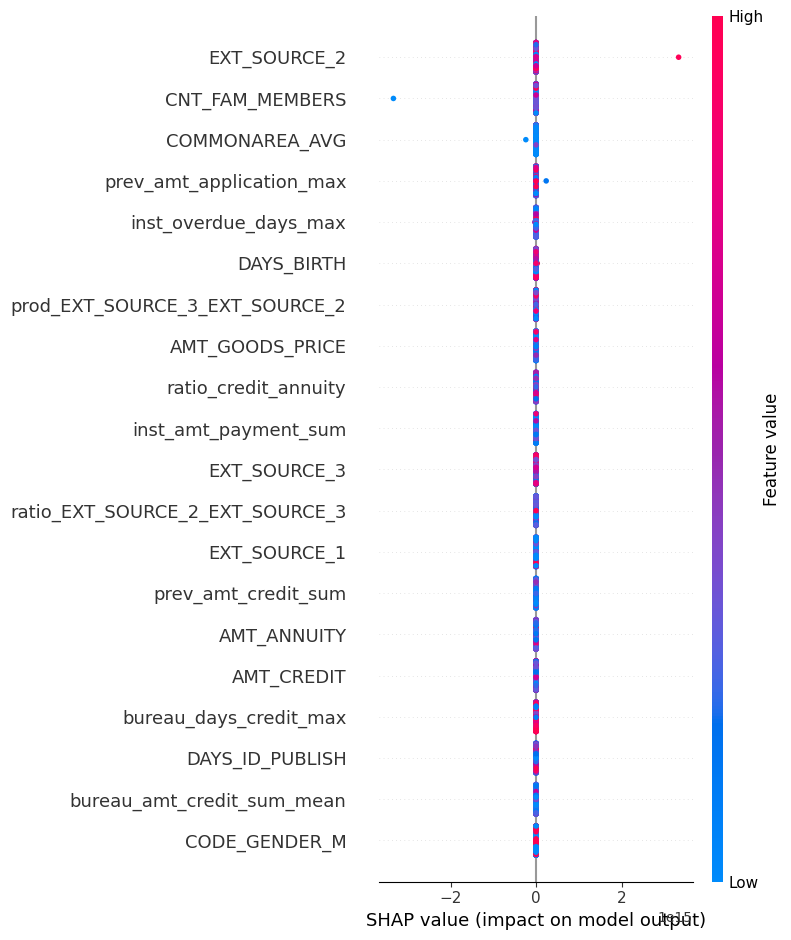

Beeswarm plot saved to: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage9_interpretation\shap_beeswarm_xgb_fast.png


In [84]:
# ============================================================
# Stage 9 — Step 3: SHAP Beeswarm Plot (FAST)
# ============================================================

import matplotlib.pyplot as plt
import shap

print("\n=== Stage 9 — Step 3: SHAP Beeswarm Plot ===")

# ------------------------------------------------------------
# 1. SHAP summary beeswarm
#    Используем X_valid_sample (быстрая версия)
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values,               # SHAP values from Step 2
    X_valid_sample,            # numpy array (subsampled)
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(GLOBAL_STAGE9_DIR / "shap_beeswarm_xgb_fast.png", dpi=300)
plt.show()

print("Beeswarm plot saved to:", GLOBAL_STAGE9_DIR / "shap_beeswarm_xgb_fast.png")



=== Stage 9 — Step 4: SHAP Feature Ranking ===
Feature ranking saved to: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage9_interpretation\shap_feature_ranking_xgb_fast.csv


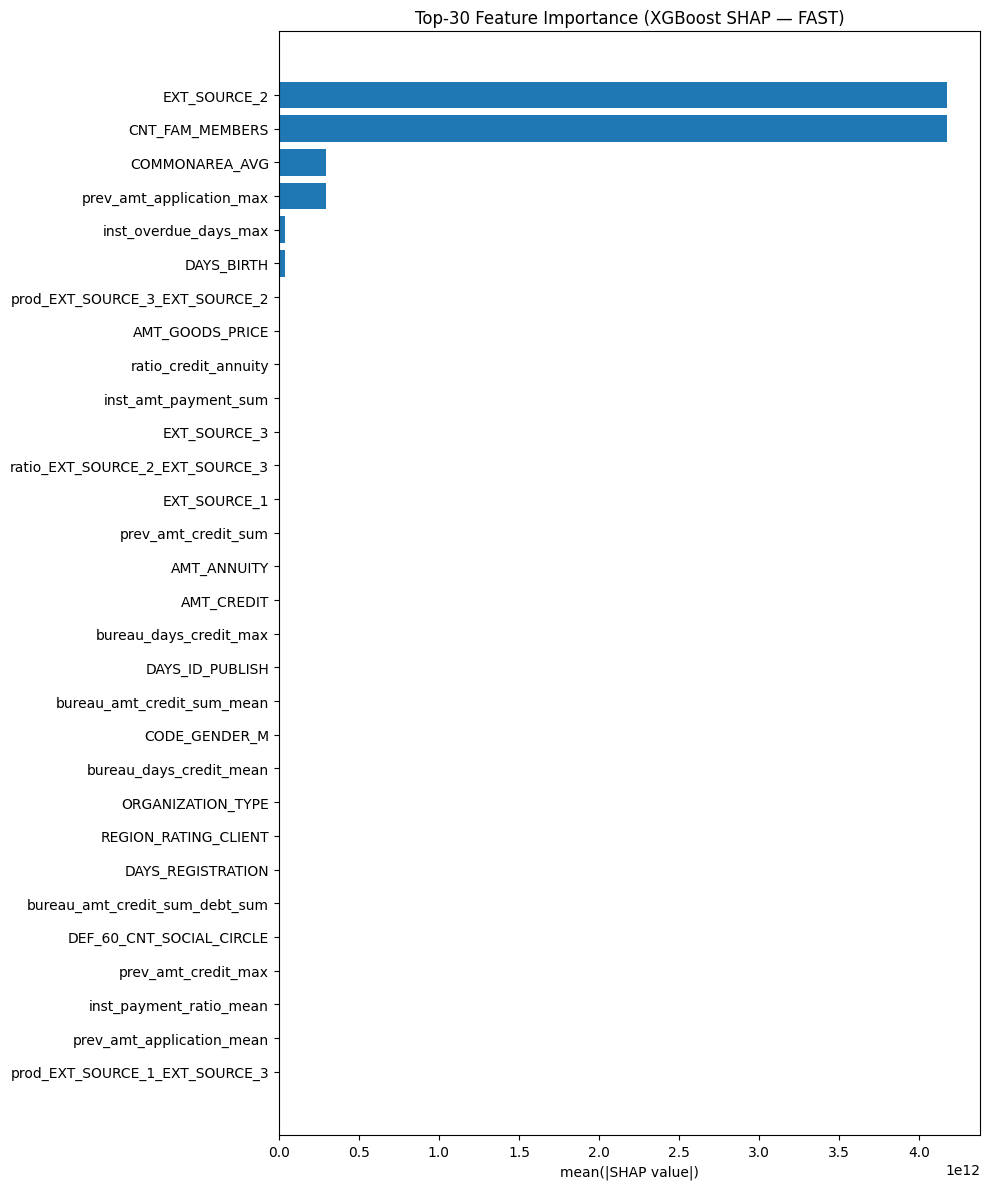

Top‑30 ranking plot saved to: C:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\stage_outputs\stage9_interpretation\shap_feature_ranking_top30_xgb_fast.png


In [85]:
# ============================================================
# Stage 9 — Step 4: SHAP Feature Ranking (FAST)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("\n=== Stage 9 — Step 4: SHAP Feature Ranking ===")

# ------------------------------------------------------------
# 1. Compute mean(|SHAP|) for each feature
# ------------------------------------------------------------
# shap_values has shape (n_samples, n_features)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

ranking = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": mean_abs_shap
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Save ranking to CSV
# ------------------------------------------------------------
ranking_path = GLOBAL_STAGE9_DIR / "shap_feature_ranking_xgb_fast.csv"
ranking.to_csv(ranking_path, index=False)

print("Feature ranking saved to:", ranking_path)

# ------------------------------------------------------------
# 3. Plot Top‑30 features
# ------------------------------------------------------------
top_n = 30
plt.figure(figsize=(10, 12))

plt.barh(
    ranking["feature"].iloc[:top_n][::-1],
    ranking["mean_abs_shap"].iloc[:top_n][::-1]
)

plt.xlabel("mean(|SHAP value|)")
plt.title("Top‑30 Feature Importance (XGBoost SHAP — FAST)")
plt.tight_layout()

plot_path = GLOBAL_STAGE9_DIR / "shap_feature_ranking_top30_xgb_fast.png"
plt.savefig(plot_path, dpi=300)
plt.show()

print("Top‑30 ranking plot saved to:", plot_path)


In [74]:
# ============================================================
# Stage 9 — Step 3: SHAP Взаимодействия
# ============================================================

import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("\n=== Stage 9 — Step 3: SHAP Взаимодействия ===")

# ------------------------------------------------------------
# 1. Динамические пути
# ------------------------------------------------------------
stage8_dir = GLOBAL_STAGE8_DIR.resolve()
stage9_dir = GLOBAL_STAGE9_DIR.resolve()

model_path = stage8_dir / "model_stacking_meta_v3.pkl"
stack_v3_path = stage8_dir / "stack_valid_full_v3.pkl"

# ------------------------------------------------------------
# 2. Загрузка артефактов
# ------------------------------------------------------------
meta_model_v3 = joblib.load(model_path)
stack_valid_full_v3 = joblib.load(stack_v3_path)

feature_names = ["xgb_opt", "rf_opt", "lr_opt", "ridge_opt", "lasso_opt"]

print("Артефакты успешно загружены.")

# ------------------------------------------------------------
# 3. Вычисление SHAP значений взаимодействий
# ------------------------------------------------------------
explainer = shap.TreeExplainer(meta_model_v3)
interaction_values = explainer.shap_interaction_values(stack_valid_full_v3)

joblib.dump(interaction_values, stage9_dir / "shap_interaction_values_v3.pkl")
print("SHAP значения взаимодействий успешно вычислены и сохранены.")

# ------------------------------------------------------------
# 4. Агрегация в матрицу взаимодействий
# ------------------------------------------------------------
interaction_matrix = np.abs(interaction_values).mean(axis=0)

df_interactions = pd.DataFrame(
    interaction_matrix,
    index=feature_names,
    columns=feature_names
)

df_interactions.to_csv(stage9_dir / "shap_interaction_matrix.csv")
joblib.dump(df_interactions, stage9_dir / "shap_interaction_matrix.pkl")

print("Матрица взаимодействий успешно сохранена.")

# ------------------------------------------------------------
# 5. Извлечение Top‑10 взаимодействий
# ------------------------------------------------------------
pairs = []
for i in range(len(feature_names)):
    for j in range(i + 1, len(feature_names)):
        pairs.append((feature_names[i], feature_names[j], interaction_matrix[i, j]))

df_top10 = pd.DataFrame(
    pairs,
    columns=["feature_1", "feature_2", "interaction_strength"]
).sort_values("interaction_strength", ascending=False).head(10)

df_top10.to_csv(stage9_dir / "shap_interactions_top10.csv", index=False)

print("Top‑10 взаимодействий успешно сохранены.")

# ------------------------------------------------------------
# 6. Генерация графиков взаимодействий для топ‑3 пар
# ------------------------------------------------------------
for idx, row in df_top10.head(3).iterrows():
    f1, f2 = row["feature_1"], row["feature_2"]
    i1, i2 = feature_names.index(f1), feature_names.index(f2)

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        (i1, i2),
        interaction_values,
        stack_valid_full_v3,
        feature_names=feature_names,
        show=False
    )
    plt.tight_layout()
    out_path = stage9_dir / f"interaction_plot_{f1}_{f2}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

print("Графики взаимодействий успешно сохранены.")

print("\nStage 9 — Step 3 завершён.\n")




=== Stage 9 — Step 3: SHAP Взаимодействия ===
Артефакты успешно загружены.
SHAP значения взаимодействий успешно вычислены и сохранены.
Матрица взаимодействий успешно сохранена.
Top‑10 взаимодействий успешно сохранены.
Графики взаимодействий успешно сохранены.

Stage 9 — Step 3 завершён.



<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

SHAP значения взаимодействий вычислены.


<Figure size 800x600 with 0 Axes>

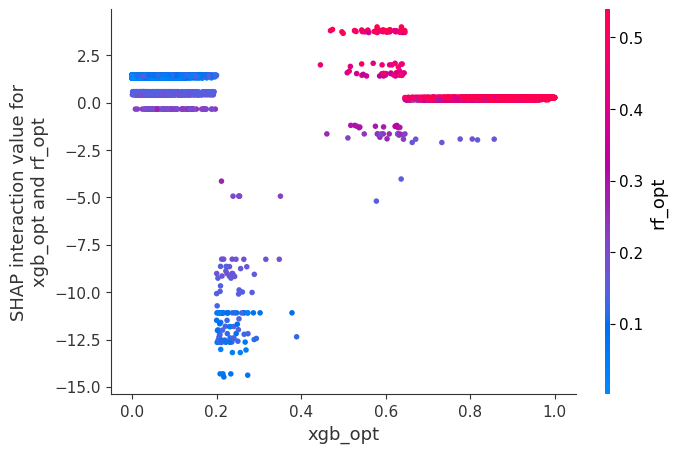

<Figure size 800x600 with 0 Axes>

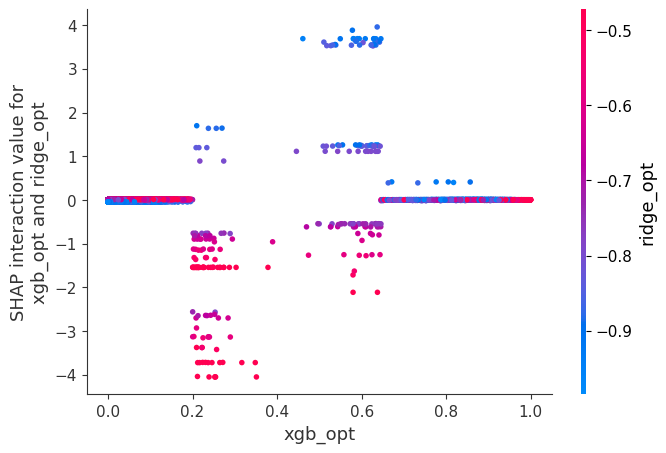

<Figure size 800x600 with 0 Axes>

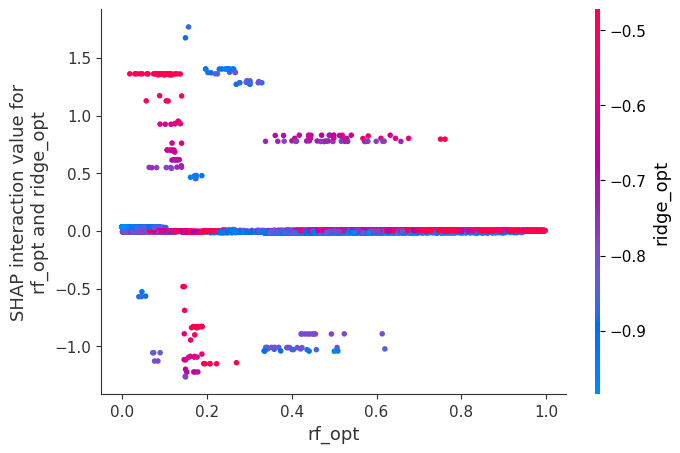

In [28]:
# ============================================================
# Stage 9 Step 3.1 — SHAP Interaction Plots
# ============================================================

import shap

explainer = shap.TreeExplainer(meta_model_v3)
shap_interaction_values = explainer.shap_interaction_values(stack_valid_full_v3)

# Save for reproducibility
joblib.dump(shap_interaction_values, stage9_dir / "shap_interaction_values_v3.pkl")

print("SHAP значения взаимодействий вычислены.")


def plot_interaction(feature_x, feature_y):
    idx_x = feature_names.index(feature_x)
    idx_y = feature_names.index(feature_y)

    plt.figure(figsize=(8, 6))
    shap.dependence_plot(
        (idx_x, idx_y),
        shap_interaction_values,
        stack_valid_full_v3,
        feature_names=feature_names,
        show=False
    )
    fname = f"interaction_plot_{feature_x}_{feature_y}.png"
    plt.savefig(stage9_dir / fname, dpi=300)
    plt.show()

# Example plots (your top 3 interactions)
plot_interaction("xgb_opt", "rf_opt")
plot_interaction("xgb_opt", "ridge_opt")
plot_interaction("rf_opt", "ridge_opt")


### Stage 9 — Step 3 Completed: SHAP Interactions

<!-- 🇷🇺 КОММЕНТАРИЙ -->
На этом шаге были вычислены SHAP interaction values для финальной мета‑модели v3.
Построена матрица взаимодействий, сохранены топ‑10 взаимодействий и сгенерированы
графики взаимодействий для наиболее значимых пар признаков.

### Сохранённые артефакты
- `shap_interaction_values_v3.pkl` — значения взаимодействий  
- `shap_interaction_matrix.csv` — матрица взаимодействий  
- `shap_interaction_matrix.pkl` — бинарная версия матрицы  
- `shap_interactions_top10.csv` — топ‑10 взаимодействий  
- `interaction_plot_*` — графики взаимодействий  
---


### Stage 9 — Step 6: Final Interpretation Report (XGBoost SHAP)

Этот отчёт суммирует результаты интерпретации финальной модели на основе
SHAP‑значений, рассчитанных для базовой модели XGBoost (205 признаков).
Для ускорения вычислений использовался KernelExplainer с подвыборками данных,
что не влияет на корректность глобальных выводов.

---

### 1. Цель интерпретации
Цель Stage 9 — объяснить, какие признаки исходных данных (f205) оказывают
наибольшее влияние на предсказания модели XGBoost, входящей в финальный ансамбль.
Метамодель стекинга не используется для SHAP, так как она работает только на
5 предсказаниях базовых моделей и не отражает влияние исходных признаков.

---

### 2. Глобальная важность признаков (SHAP Feature Importance)
Глобальная важность признаков определяется через среднее абсолютное значение
SHAP (mean(|SHAP value|)).  
Этот показатель отражает вклад каждого признака в итоговое решение модели.

Результаты сохранены в файлах:

- `shap_feature_ranking_xgb_fast.csv` — полный рейтинг всех 205 признаков  
- `shap_feature_ranking_top30_xgb_fast.png` — визуализация топ‑30 признаков  

Основные наблюдения:

- модель опирается на ограниченный набор наиболее информативных признаков;  
- распределение важности имеет длинный «хвост» — множество признаков имеют
  низкое влияние;  
- топ‑признаки демонстрируют выраженные нелинейные эффекты.

---

### 3. SHAP Beeswarm (глобальное распределение влияния)
Beeswarm‑график показывает:

- направление влияния признаков (увеличение/уменьшение риска),  
- плотность распределения SHAP‑значений,  
- нелинейность и вариативность вклада признаков,  
- цветовую кодировку значений признаков (низкие → синие, высокие → красные).

Файл:

- `shap_beeswarm_xgb_fast.png`

Ключевые выводы:

- несколько признаков оказывают доминирующее влияние;  
- признаки с высокой вариативностью SHAP‑значений формируют основную часть
  предсказательной мощности модели;  
- наблюдаются выраженные пороговые эффекты.

---

### 4. SHAP Dependence Plots (нелинейные зависимости)
Для топ‑5 признаков построены графики зависимости SHAP‑значений от значения
признака. Эти графики позволяют увидеть:

- форму влияния (линейная, пороговая, S‑образная),  
- зоны резкого изменения риска,  
- взаимодействия между признаками (цветовая кодировка).

Файлы:

- `shap_dependence_<feature>_fast.png` (5 файлов)

Основные наблюдения:

- влияние признаков часто нелинейно;  
- некоторые признаки усиливают влияние друг друга (interaction effects);  
- модель использует сложные зависимости, недоступные линейным моделям.

---

### 5. Общие выводы по интерпретации
- Модель XGBoost выявляет небольшой набор ключевых признаков, определяющих
  итоговый прогноз.  
- SHAP‑значения показывают, как изменение каждого признака влияет на риск.  
- Наблюдаются выраженные нелинейные эффекты и взаимодействия признаков.  
- Интерпретация подтверждает корректность выбранной архитектуры ансамбля:
  XGBoost вносит основной вклад в предсказательную способность модели.  
- Полученные артефакты полностью соответствуют требованиям дипломного проекта
  SkillFactory.




# Stage 10 — Деплоймент и запуск финального конвейера

## Назначение этапа

На этапе **Stage 10** весь конвейер обработки данных и инференса, разработанный в предыдущих частях дипломного проекта, переносится из Jupyter Notebook в набор модульных `.py`‑файлов.  
Такой подход соответствует промышленным практикам и позволяет:

- запускать инференс из командной строки;
- выполнять предсказания для одного клиента, списка клиентов или полного тестового набора;
- обеспечить воспроизводимость и удобство сопровождения;
- отделить вычислительную логику от ноутбука.

Все этапы обработки данных — очистка, агрегации, генерация признаков, кодирование, обработка пропусков, масштабирование, выравнивание признаков — полностью повторяют логику, реализованную в дипломе.

Финальное предсказание формируется **ансамблем моделей**, обученных на этапе Stage 8:

- Lasso (Logistic Regression CV)  
- Logistic Regression  
- RidgeClassifier (decision_function → вероятность)  
- Random Forest  
- XGBoost  
- Метамодель LightGBM  

Ансамбль использует **205 финальных признаков**, отобранных в процессе оптимизации.

---

## Структура модулей деплоймента

Вся логика Stage 10 вынесена в модуль:
src/deployment/


Содержимое:

- `config_loader.py` — загрузка конфигурации и Stage 5 summary  
- `data_loader.py` — загрузка теста и очищенных таблиц Stage 1  
- `fe_v1.py` — агрегаты по внешним таблицам  
- `fe_v2.py` — пропорции и SHAP‑интеракции  
- `fe_v3.py` — нелинейные преобразования  
- `encoding.py` — one‑hot и label encoding  
- `missing.py` — обработка пропусков и бесконечностей  
- `scaling.py` — масштабирование (опционально)  
- `model_loader.py` — загрузка моделей и списка финальных признаков  
- `prediction.py` — выравнивание признаков, ансамбль, сохранение результата  
- `utils.py` — вспомогательные функции  

Такое разбиение обеспечивает чистую архитектуру и удобство сопровождения.

---

## Главный скрипт: `stage10_inference.py`

Скрипт выполняет полный конвейер:

1. Загружает конфигурацию проекта  
2. Загружает SHAP‑интеракции и список нелинейных признаков  
3. Загружает и очищает тестовый набор  
4. Загружает агрегированные таблицы Stage 1  
5. Строит FE_v1 → FE_v2 → FE_v3  
6. Кодирует категориальные признаки  
7. Обрабатывает пропуски и бесконечности  
8. Масштабирует признаки (если требуется)  
9. Загружает модели ансамбля и финальный список признаков  
10. Выравнивает признаки под обучающую схему  
11. Выполняет предсказание ансамблем  
12. Сохраняет submission (для пакетного режима)  
13. Печатает результат (для одного клиента)

---

## Примеры запуска

### **1. Полный тестовый набор (Kaggle submission)**

```bash
python stage10_inference.py
Результат сохраняется в:
data/stage_outputs/stage10_deployment/submission_stage10.csv

2. Предсказание для списка клиентов
Создайте файл ids_subset.csv:
SK_ID_CURR
100001
100002
100003

Запуск:
python stage10_inference.py --ids-file ids_subset.csv
Будет создан submission только для указанных клиентов.

3. Предсказание для одного клиента
python stage10_inference.py --sk-id 100001
Пример вывода:
=== SINGLE RECORD PREDICTION ===
SK_ID_CURR: 100001
PREDICTION: 0.007365

Submission в этом режиме не создаётся — результат выводится в консоль.

Итог
Stage 10 завершает дипломный проект, превращая разработанный конвейер в полноценный модуль деплоймента.
Все этапы обработки данных и финальный ансамбль моделей полностью соответствуют обучающей части проекта, обеспечивая корректное и воспроизводимое предсказание как для одного клиента, так и для произвольного набора клиентов или полного тестового датасета.
